In [ ]:
# ============================================================
# FIXED-CANDIDATE FULL CATALOG REBUILD
# ------------------------------------------------------------
# Frozen branch:
#   source: rho_eff ~ (1/r^2) d/dr [ r * V_bar^2 ]
#   screened field equation
#   fixed Rs = 1.5
#   shape map: V/V_flat = U/U_inf
#
# Frozen amplitude law:
#   U(r_t) = 0.6 U_inf
#   V_flat^2 = C * [r_t u(r_t)]^alpha * [Vbar^2(r_t)]^beta
#
# with fixed constants:
#   C     = 164.0
#   alpha = 0.175
#   beta  = 0.55
#
# No fitting in this script.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_fixed_candidate_catalog_rebuild")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

# ------------------------------------------------------------
# FIXED MODEL SETTINGS
# ------------------------------------------------------------

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

F_FRAC = 0.60
C_AMP  = 164.0
ALPHA  = 0.175
BETA   = 0.55

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files

    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break

    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")

    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)

    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def radius_at_fraction(r, y, frac):
    y = np.asarray(y, float)
    r = np.asarray(r, float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def build_mass_derivative_source(rot):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)

    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")

    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr

        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)

        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

# ------------------------------------------------------------
# RUN FULL CATALOG
# ------------------------------------------------------------

rotmod_files = bootstrap_rotmods()
rotmod_map = {display_name_from_path(p): p for p in rotmod_files}

rows = []
fails = []

print("=" * 60)
print("RUNNING FIXED-CANDIDATE FULL CATALOG")
print("=" * 60)
print(f"Candidate files : {len(rotmod_files)}")
print(f"Fixed Rs        : {Rs_fixed}")
print(f"Fixed f         : {F_FRAC}")
print(f"Fixed alpha     : {ALPHA}")
print(f"Fixed beta      : {BETA}")
print(f"Fixed C         : {C_AMP}")
print()

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)

    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(
            max(R_MIN, float(np.min(r_obs)) * 0.5),
            max(float(np.max(r_obs)) * 1.10, 1.0),
            N_R
        )

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)

        U_inf = float(np.max(U))
        rt = radius_at_fraction(r, U, F_FRAC)

        if not (np.isfinite(U_inf) and U_inf > 0 and np.isfinite(rt) and rt > 0):
            raise RuntimeError("Invalid transition quantities")

        u_interp = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
        vbar2_obs = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar2_interp = interp1d(rot["r"], vbar2_obs, kind="linear", bounds_error=False, fill_value="extrapolate")

        u_t = max(float(u_interp(rt)), 1.0e-30)
        vbar2_t = max(float(vbar2_interp(rt)), 1.0e-30)

        carrier = (rt * u_t) ** ALPHA * (vbar2_t) ** BETA
        V_flat_pred = np.sqrt(max(C_AMP * carrier, 0.0))
        V_theory = V_flat_pred * U / max(U_inf, 1.0e-12)

        V_obs_pred = interp1d(
            r, V_theory,
            kind="linear", bounds_error=False, fill_value="extrapolate"
        )(r_obs)

        rmse = safe_rmse(rot["vobs"], V_obs_pred)
        mae = safe_mae(rot["vobs"], V_obs_pred)
        chi2_mean = float(np.mean(((rot["vobs"] - V_obs_pred) / rot["ev"]) ** 2))

        obs_shape = rot["vobs"] / max(float(np.max(rot["vobs"])), 1.0e-12)
        pred_shape = V_obs_pred / max(float(np.max(V_obs_pred)), 1.0e-12)
        shape_rmse = safe_rmse(obs_shape, pred_shape)

        rows.append({
            "galaxy": galaxy,
            "n_points": len(r_obs),
            "r_max": float(np.max(r_obs)),
            "vmax_obs": float(np.max(rot["vobs"])),
            "Rs_fixed": Rs_fixed,
            "rt": rt,
            "u_t": u_t,
            "vbar2_t": vbar2_t,
            "carrier": carrier,
            "V_flat_pred": V_flat_pred,
            "rmse": rmse,
            "mae": mae,
            "chi2_mean": chi2_mean,
            "shape_rmse": shape_rmse,
        })

    except Exception as e:
        fails.append({"galaxy": galaxy, "reason": str(e)})

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

res_df = pd.DataFrame(rows)
fail_df = pd.DataFrame(fails)

if len(res_df) == 0:
    raise RuntimeError("No successful galaxies processed.")

summary = {
    "successful_galaxies": int(len(res_df)),
    "failed_galaxies": int(len(fail_df)),
    "median_rmse": float(res_df["rmse"].median()),
    "mean_rmse": float(res_df["rmse"].mean()),
    "p90_rmse": float(np.percentile(res_df["rmse"], 90)),
    "p95_rmse": float(np.percentile(res_df["rmse"], 95)),
    "median_mae": float(res_df["mae"].median()),
    "median_chi2_mean": float(res_df["chi2_mean"].median()),
    "median_shape_rmse": float(res_df["shape_rmse"].median()),
}

best20 = res_df.sort_values("rmse").head(20).reset_index(drop=True)
worst20 = res_df.sort_values("rmse", ascending=False).head(20).reset_index(drop=True)

# Simple bins for tail view
res_df["vmax_bin"] = pd.cut(
    res_df["vmax_obs"],
    bins=[-np.inf, 80, 150, np.inf],
    labels=["low", "mid", "high"]
)

bin_summary = (
    res_df.groupby("vmax_bin", observed=True)[["rmse", "mae", "chi2_mean", "shape_rmse"]]
    .median()
    .reset_index()
)

print()
print("=" * 60)
print("FIXED-CANDIDATE SUMMARY")
print("=" * 60)
for k, v in summary.items():
    print(f"{k:22s} = {v}")

print()
print("=" * 60)
print("MEDIAN METRICS BY VMAX BIN")
print("=" * 60)
print(bin_summary.to_string(index=False))

print()
print("=" * 60)
print("BEST 20 BY RMSE")
print("=" * 60)
print(best20[["galaxy", "vmax_obs", "rt", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))

print()
print("=" * 60)
print("WORST 20 BY RMSE")
print("=" * 60)
print(worst20[["galaxy", "vmax_obs", "rt", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

RES_CSV = os.path.join(OUTDIR, "fixed_candidate_results.csv")
FAIL_CSV = os.path.join(OUTDIR, "fixed_candidate_failures.csv")
BEST_CSV_OUT = os.path.join(OUTDIR, "fixed_candidate_best20.csv")
WORST_CSV_OUT = os.path.join(OUTDIR, "fixed_candidate_worst20.csv")
BIN_CSV = os.path.join(OUTDIR, "fixed_candidate_bin_summary.csv")
TXT_OUT = os.path.join(OUTDIR, "fixed_candidate_summary.txt")

res_df.to_csv(RES_CSV, index=False)
fail_df.to_csv(FAIL_CSV, index=False)
best20.to_csv(BEST_CSV_OUT, index=False)
worst20.to_csv(WORST_CSV_OUT, index=False)
bin_summary.to_csv(BIN_CSV, index=False)

with open(TXT_OUT, "w", encoding="utf-8") as f:
    f.write("FIXED-CANDIDATE SUMMARY\n")
    f.write("=" * 60 + "\n")
    for k, v in summary.items():
        f.write(f"{k:22s} = {v}\n")
    f.write("\nMEDIAN METRICS BY VMAX BIN\n")
    f.write("=" * 60 + "\n")
    f.write(bin_summary.to_string(index=False))
    f.write("\n\nBEST 20 BY RMSE\n")
    f.write("=" * 60 + "\n")
    f.write(best20[["galaxy", "vmax_obs", "rt", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))
    f.write("\n\nWORST 20 BY RMSE\n")
    f.write("=" * 60 + "\n")
    f.write(worst20[["galaxy", "vmax_obs", "rt", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

Auto-extracting LTG rotmods from: /content/Rotmod_LTG (4).zip
RUNNING FIXED-CANDIDATE FULL CATALOG
Candidate files : 175
Fixed Rs        : 1.5
Fixed f         : 0.6
Fixed alpha     : 0.175
Fixed beta      : 0.55
Fixed C         : 164.0

Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

FIXED-CANDIDATE SUMMARY
successful_galaxies    = 175
failed_galaxies        = 0
median_rmse            = 20.38786367728187
mean_rmse              = 32.72222113537459
p90_rmse               = 77.35749478059131
p95_rmse               = 88.8575199776623
median_mae             = 17.608721572718746
median_chi2_mean       = 26.12511787253237
median_shape_rmse      = 0.15760201986858705

MEDIAN METRICS BY VMAX BIN
vmax_bin      rmse       mae  chi2_mean  shape_rmse
     low 11.457480 10.528257  14.716546    0.128219
     mid 18.074875 15.106115  13.274674    0.115517
    hig

In [ ]:
# ============================================================
# HIGH-END AMPLITUDE TAIL CORRECTION TEST
# ------------------------------------------------------------
# Fixed base branch:
#   Rs = 1.5
#   U(rt) = 0.6 U_inf
#   V/V_flat = U/U_inf
#   V_flat,base^2 = 164 * [rt*u(rt)]^0.175 * [Vbar^2(rt)]^0.55
#
# Tail correction:
#   V_flat,corr = V_flat,base * [1 + eta * (Vbar2_t / V0^2)^delta]
#
# Only amplitude is modified. Source/field/shape stay fixed.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_high_end_tail_correction")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

F_FRAC = 0.60
C_AMP  = 164.0
ALPHA  = 0.175
BETA   = 0.55

ETA_LIST   = [0.00, 0.05, 0.10, 0.15, 0.20, 0.30]
DELTA_LIST = [0.25, 0.50, 0.75, 1.00]
V0_LIST    = [120.0, 150.0, 180.0, 210.0, 240.0]

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files

    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break

    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")

    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)

    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def radius_at_fraction(r, y, frac):
    y = np.asarray(y, float)
    r = np.asarray(r, float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def build_mass_derivative_source(rot):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)
    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)
    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")
    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)
        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

rotmod_files = bootstrap_rotmods()

rows = []
print("=" * 60)
print("BUILDING TAIL-CORRECTION TABLE")
print("=" * 60)

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)
    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(max(R_MIN, float(np.min(r_obs)) * 0.5),
                               max(float(np.max(r_obs)) * 1.10, 1.0), N_R)

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)
        U_inf = float(np.max(U))

        rt = radius_at_fraction(r, U, F_FRAC)
        if not (np.isfinite(U_inf) and U_inf > 0 and np.isfinite(rt) and rt > 0):
            continue

        u_interp = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
        vbar2_obs = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar2_interp = interp1d(rot["r"], vbar2_obs, kind="linear", bounds_error=False, fill_value="extrapolate")

        u_t = max(float(u_interp(rt)), 1.0e-30)
        vbar2_t = max(float(vbar2_interp(rt)), 1.0e-30)

        carrier = (rt * u_t) ** ALPHA * (vbar2_t) ** BETA
        V_flat_base = np.sqrt(max(C_AMP * carrier, 0.0))

        rows.append({
            "galaxy": galaxy,
            "vmax_obs": float(np.max(rot["vobs"])),
            "vbar2_t": vbar2_t,
            "V_flat_base": V_flat_base,
            "r_obs": rot["r"],
            "v_obs": rot["vobs"],
            "e_obs": rot["ev"],
            "r_grid": r,
            "U_grid": U,
            "U_inf": U_inf,
        })

    except Exception:
        pass

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

df = pd.DataFrame(rows)

summary_rows = []

for eta in ETA_LIST:
    for delta in DELTA_LIST:
        for V0 in V0_LIST:
            rmses = []
            vmax_bins = []

            for _, row in df.iterrows():
                correction = 1.0 + eta * (row["vbar2_t"] / (V0**2)) ** delta
                V_flat_pred = row["V_flat_base"] * correction
                V_theory = V_flat_pred * row["U_grid"] / max(row["U_inf"], 1.0e-12)

                V_obs_pred = interp1d(
                    row["r_grid"], V_theory,
                    kind="linear", bounds_error=False, fill_value="extrapolate"
                )(row["r_obs"])

                rmse = safe_rmse(row["v_obs"], V_obs_pred)
                rmses.append(rmse)
                vmax_bins.append(row["vmax_obs"])

            rmses = np.asarray(rmses, float)
            vmax_bins = np.asarray(vmax_bins, float)

            high_mask = vmax_bins >= 150.0
            high_med = np.nan if np.sum(high_mask) == 0 else float(np.median(rmses[high_mask]))

            summary_rows.append({
                "eta": eta,
                "delta": delta,
                "V0": V0,
                "median_rmse": float(np.median(rmses)),
                "p90_rmse": float(np.percentile(rmses, 90)),
                "high_bin_median_rmse": high_med,
            })

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["high_bin_median_rmse", "median_rmse", "p90_rmse"]
).reset_index(drop=True)

print()
print("=" * 60)
print("HIGH-END TAIL CORRECTION SUMMARY")
print("=" * 60)
print(summary_df.head(25).to_string(index=False))

summary_df.to_csv(os.path.join(OUTDIR, "high_end_tail_correction_summary.csv"), index=False)

with open(os.path.join(OUTDIR, "high_end_tail_correction_summary.txt"), "w", encoding="utf-8") as f:
    f.write("HIGH-END TAIL CORRECTION SUMMARY\n")
    f.write("=" * 60 + "\n")
    f.write(summary_df.to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

BUILDING TAIL-CORRECTION TABLE
Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

HIGH-END TAIL CORRECTION SUMMARY
 eta  delta    V0  median_rmse  p90_rmse  high_bin_median_rmse
0.00   0.25 120.0    20.387864 77.357495             63.789441
0.00   0.25 150.0    20.387864 77.357495             63.789441
0.00   0.25 180.0    20.387864 77.357495             63.789441
0.00   0.25 210.0    20.387864 77.357495             63.789441
0.00   0.25 240.0    20.387864 77.357495             63.789441
0.00   0.50 120.0    20.387864 77.357495             63.789441
0.00   0.50 150.0    20.387864 77.357495             63.789441
0.00   0.50 180.0    20.387864 77.357495             63.789441
0.00   0.50 210.0    20.387864 77.357495             63.789441
0.00   0.50 240.0    20.387864 77.357495             63.789441
0.00   0.75 120.0    20.387864 77.357495             6

In [ ]:
# ============================================================
# HIGH-END FAILURE-MODE AUDIT
# ------------------------------------------------------------
# Audits the fixed candidate branch:
#
#   Rs = 1.5
#   U(rt) = 0.6 U_inf
#   V/V_flat = U/U_inf
#   V_flat^2 = 164 * [rt*u(rt)]^0.175 * [Vbar^2(rt)]^0.55
#
# Focus:
#   Understand what the worst high-vmax failures share.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_high_end_failure_audit")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

F_FRAC = 0.60
C_AMP  = 164.0
ALPHA  = 0.175
BETA   = 0.55

HIGH_VMAX_CUT = 150.0

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files
    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break
    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")
    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_components(rot):
    vgas2  = np.maximum(rot["vgas"] * np.abs(rot["vgas"]), 0.0)
    vdisk2 = np.maximum(UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]), 0.0)
    vbul2  = np.maximum(UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]), 0.0)
    vbar2  = vgas2 + vdisk2 + vbul2
    return vgas2, vdisk2, vbul2, vbar2

def radius_at_fraction(r, y, frac):
    y = np.asarray(y, float)
    r = np.asarray(r, float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def build_mass_derivative_source(rot):
    r = rot["r"]
    _, _, _, vbar2 = vbar2_components(rot)
    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)
    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)
    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")
    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)
        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

rotmod_files = bootstrap_rotmods()

rows = []
print("=" * 60)
print("RUNNING FAILURE-MODE AUDIT")
print("=" * 60)

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)
    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(max(R_MIN, float(np.min(r_obs)) * 0.5),
                               max(float(np.max(r_obs)) * 1.10, 1.0), N_R)

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)
        U_inf = float(np.max(U))

        rt = radius_at_fraction(r, U, F_FRAC)
        if not (np.isfinite(U_inf) and U_inf > 0 and np.isfinite(rt) and rt > 0):
            continue

        u_interp = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")

        vgas2, vdisk2, vbul2, vbar2_obs = vbar2_components(rot)
        vgas2_i  = interp1d(rot["r"], vgas2,  kind="linear", bounds_error=False, fill_value="extrapolate")
        vdisk2_i = interp1d(rot["r"], vdisk2, kind="linear", bounds_error=False, fill_value="extrapolate")
        vbul2_i  = interp1d(rot["r"], vbul2,  kind="linear", bounds_error=False, fill_value="extrapolate")
        vbar2_i  = interp1d(rot["r"], vbar2_obs, kind="linear", bounds_error=False, fill_value="extrapolate")

        u_t = max(float(u_interp(rt)), 1.0e-30)
        vgas2_t = max(float(vgas2_i(rt)), 0.0)
        vdisk2_t = max(float(vdisk2_i(rt)), 0.0)
        vbul2_t = max(float(vbul2_i(rt)), 0.0)
        vbar2_t = max(float(vbar2_i(rt)), 1.0e-30)

        bulge_frac_t = vbul2_t / vbar2_t if vbar2_t > 0 else np.nan
        disk_frac_t = vdisk2_t / vbar2_t if vbar2_t > 0 else np.nan
        gas_frac_t = vgas2_t / vbar2_t if vbar2_t > 0 else np.nan

        carrier = (rt * u_t) ** ALPHA * (vbar2_t) ** BETA
        V_flat_pred = np.sqrt(max(C_AMP * carrier, 0.0))
        V_theory = V_flat_pred * U / max(U_inf, 1.0e-12)

        V_obs_pred = interp1d(
            r, V_theory,
            kind="linear", bounds_error=False, fill_value="extrapolate"
        )(r_obs)

        rmse = safe_rmse(rot["vobs"], V_obs_pred)
        mae = safe_mae(rot["vobs"], V_obs_pred)

        rows.append({
            "galaxy": galaxy,
            "n_points": len(r_obs),
            "r_max": float(np.max(r_obs)),
            "vmax_obs": float(np.max(rot["vobs"])),
            "rt": rt,
            "rt_over_rmax": rt / max(float(np.max(r_obs)), 1.0e-12),
            "u_t": u_t,
            "rt_ut": rt * u_t,
            "vbar2_t": vbar2_t,
            "vbar_t": np.sqrt(vbar2_t),
            "bulge_frac_t": bulge_frac_t,
            "disk_frac_t": disk_frac_t,
            "gas_frac_t": gas_frac_t,
            "V_flat_pred": V_flat_pred,
            "Vflat_over_vmax": V_flat_pred / max(float(np.max(rot["vobs"])), 1.0e-12),
            "rmse": rmse,
            "mae": mae,
        })

    except Exception:
        pass

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

df = pd.DataFrame(rows)
high = df[df["vmax_obs"] >= HIGH_VMAX_CUT].copy().sort_values("rmse", ascending=False).reset_index(drop=True)

worst20 = high.head(20).copy()
best20 = high.tail(20).copy().sort_values("rmse").reset_index(drop=True)

summary_vars = [
    "vmax_obs", "r_max", "rt", "rt_over_rmax", "u_t", "rt_ut",
    "vbar2_t", "vbar_t", "bulge_frac_t", "disk_frac_t", "gas_frac_t",
    "V_flat_pred", "Vflat_over_vmax", "rmse", "mae"
]

summary_df = pd.DataFrame({
    "quantity": summary_vars,
    "worst20_median": [float(worst20[c].median()) for c in summary_vars],
    "best20_median": [float(best20[c].median()) for c in summary_vars],
})
summary_df["worst_minus_best"] = summary_df["worst20_median"] - summary_df["best20_median"]

print()
print("=" * 60)
print("HIGH-END FAILURE AUDIT SUMMARY")
print("=" * 60)
print(summary_df.to_string(index=False))

print()
print("=" * 60)
print("WORST 20 HIGH-VMAX GALAXIES")
print("=" * 60)
print(worst20[[
    "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
    "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
]].to_string(index=False))

print()
print("=" * 60)
print("BEST 20 HIGH-VMAX GALAXIES")
print("=" * 60)
print(best20[[
    "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
    "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
]].to_string(index=False))

summary_df.to_csv(os.path.join(OUTDIR, "high_end_failure_summary.csv"), index=False)
worst20.to_csv(os.path.join(OUTDIR, "high_end_worst20.csv"), index=False)
best20.to_csv(os.path.join(OUTDIR, "high_end_best20.csv"), index=False)
df.to_csv(os.path.join(OUTDIR, "high_end_full_audit.csv"), index=False)

with open(os.path.join(OUTDIR, "high_end_failure_summary.txt"), "w", encoding="utf-8") as f:
    f.write("HIGH-END FAILURE AUDIT SUMMARY\n")
    f.write("=" * 60 + "\n")
    f.write(summary_df.to_string(index=False))
    f.write("\n\nWORST 20 HIGH-VMAX GALAXIES\n")
    f.write("=" * 60 + "\n")
    f.write(worst20[[
        "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
        "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
    ]].to_string(index=False))
    f.write("\n\nBEST 20 HIGH-VMAX GALAXIES\n")
    f.write("=" * 60 + "\n")
    f.write(best20[[
        "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
        "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
    ]].to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

RUNNING FAILURE-MODE AUDIT
Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

HIGH-END FAILURE AUDIT SUMMARY
       quantity  worst20_median  best20_median  worst_minus_best
       vmax_obs      274.000000     186.000000         88.000000
          r_max       44.215000      26.930000         17.285000
             rt        4.236476       3.368903          0.867573
   rt_over_rmax        0.154626       0.124820          0.029805
            u_t        0.097594       0.084961          0.012633
          rt_ut        0.423070       0.275523          0.147548
        vbar2_t    77995.021748   35983.678528      42011.343220
         vbar_t      279.272915     189.684292         89.588623
   bulge_frac_t        0.281828       0.000000          0.281828
    disk_frac_t        0.717890       0.987273         -0.269383
     gas_frac_t        0.000091       

In [ ]:
# ============================================================
# HIGH-END FAILURE-MODE AUDIT
# ------------------------------------------------------------
# Audits the fixed candidate branch:
#
#   Rs = 1.5
#   U(rt) = 0.6 U_inf
#   V/V_flat = U/U_inf
#   V_flat^2 = 164 * [rt*u(rt)]^0.175 * [Vbar^2(rt)]^0.55
#
# Focus:
#   Understand what the worst high-vmax failures share.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_high_end_failure_audit")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

F_FRAC = 0.60
C_AMP  = 164.0
ALPHA  = 0.175
BETA   = 0.55

HIGH_VMAX_CUT = 150.0

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files
    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break
    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")
    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_components(rot):
    vgas2  = np.maximum(rot["vgas"] * np.abs(rot["vgas"]), 0.0)
    vdisk2 = np.maximum(UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]), 0.0)
    vbul2  = np.maximum(UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]), 0.0)
    vbar2  = vgas2 + vdisk2 + vbul2
    return vgas2, vdisk2, vbul2, vbar2

def radius_at_fraction(r, y, frac):
    y = np.asarray(y, float)
    r = np.asarray(r, float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def build_mass_derivative_source(rot):
    r = rot["r"]
    _, _, _, vbar2 = vbar2_components(rot)
    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)
    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)
    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")
    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)
        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

rotmod_files = bootstrap_rotmods()

rows = []
print("=" * 60)
print("RUNNING FAILURE-MODE AUDIT")
print("=" * 60)

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)
    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(max(R_MIN, float(np.min(r_obs)) * 0.5),
                               max(float(np.max(r_obs)) * 1.10, 1.0), N_R)

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)
        U_inf = float(np.max(U))

        rt = radius_at_fraction(r, U, F_FRAC)
        if not (np.isfinite(U_inf) and U_inf > 0 and np.isfinite(rt) and rt > 0):
            continue

        u_interp = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")

        vgas2, vdisk2, vbul2, vbar2_obs = vbar2_components(rot)
        vgas2_i  = interp1d(rot["r"], vgas2,  kind="linear", bounds_error=False, fill_value="extrapolate")
        vdisk2_i = interp1d(rot["r"], vdisk2, kind="linear", bounds_error=False, fill_value="extrapolate")
        vbul2_i  = interp1d(rot["r"], vbul2,  kind="linear", bounds_error=False, fill_value="extrapolate")
        vbar2_i  = interp1d(rot["r"], vbar2_obs, kind="linear", bounds_error=False, fill_value="extrapolate")

        u_t = max(float(u_interp(rt)), 1.0e-30)
        vgas2_t = max(float(vgas2_i(rt)), 0.0)
        vdisk2_t = max(float(vdisk2_i(rt)), 0.0)
        vbul2_t = max(float(vbul2_i(rt)), 0.0)
        vbar2_t = max(float(vbar2_i(rt)), 1.0e-30)

        bulge_frac_t = vbul2_t / vbar2_t if vbar2_t > 0 else np.nan
        disk_frac_t = vdisk2_t / vbar2_t if vbar2_t > 0 else np.nan
        gas_frac_t = vgas2_t / vbar2_t if vbar2_t > 0 else np.nan

        carrier = (rt * u_t) ** ALPHA * (vbar2_t) ** BETA
        V_flat_pred = np.sqrt(max(C_AMP * carrier, 0.0))
        V_theory = V_flat_pred * U / max(U_inf, 1.0e-12)

        V_obs_pred = interp1d(
            r, V_theory,
            kind="linear", bounds_error=False, fill_value="extrapolate"
        )(r_obs)

        rmse = safe_rmse(rot["vobs"], V_obs_pred)
        mae = safe_mae(rot["vobs"], V_obs_pred)

        rows.append({
            "galaxy": galaxy,
            "n_points": len(r_obs),
            "r_max": float(np.max(r_obs)),
            "vmax_obs": float(np.max(rot["vobs"])),
            "rt": rt,
            "rt_over_rmax": rt / max(float(np.max(r_obs)), 1.0e-12),
            "u_t": u_t,
            "rt_ut": rt * u_t,
            "vbar2_t": vbar2_t,
            "vbar_t": np.sqrt(vbar2_t),
            "bulge_frac_t": bulge_frac_t,
            "disk_frac_t": disk_frac_t,
            "gas_frac_t": gas_frac_t,
            "V_flat_pred": V_flat_pred,
            "Vflat_over_vmax": V_flat_pred / max(float(np.max(rot["vobs"])), 1.0e-12),
            "rmse": rmse,
            "mae": mae,
        })

    except Exception:
        pass

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

df = pd.DataFrame(rows)
high = df[df["vmax_obs"] >= HIGH_VMAX_CUT].copy().sort_values("rmse", ascending=False).reset_index(drop=True)

worst20 = high.head(20).copy()
best20 = high.tail(20).copy().sort_values("rmse").reset_index(drop=True)

summary_vars = [
    "vmax_obs", "r_max", "rt", "rt_over_rmax", "u_t", "rt_ut",
    "vbar2_t", "vbar_t", "bulge_frac_t", "disk_frac_t", "gas_frac_t",
    "V_flat_pred", "Vflat_over_vmax", "rmse", "mae"
]

summary_df = pd.DataFrame({
    "quantity": summary_vars,
    "worst20_median": [float(worst20[c].median()) for c in summary_vars],
    "best20_median": [float(best20[c].median()) for c in summary_vars],
})
summary_df["worst_minus_best"] = summary_df["worst20_median"] - summary_df["best20_median"]

print()
print("=" * 60)
print("HIGH-END FAILURE AUDIT SUMMARY")
print("=" * 60)
print(summary_df.to_string(index=False))

print()
print("=" * 60)
print("WORST 20 HIGH-VMAX GALAXIES")
print("=" * 60)
print(worst20[[
    "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
    "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
]].to_string(index=False))

print()
print("=" * 60)
print("BEST 20 HIGH-VMAX GALAXIES")
print("=" * 60)
print(best20[[
    "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
    "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
]].to_string(index=False))

summary_df.to_csv(os.path.join(OUTDIR, "high_end_failure_summary.csv"), index=False)
worst20.to_csv(os.path.join(OUTDIR, "high_end_worst20.csv"), index=False)
best20.to_csv(os.path.join(OUTDIR, "high_end_best20.csv"), index=False)
df.to_csv(os.path.join(OUTDIR, "high_end_full_audit.csv"), index=False)

with open(os.path.join(OUTDIR, "high_end_failure_summary.txt"), "w", encoding="utf-8") as f:
    f.write("HIGH-END FAILURE AUDIT SUMMARY\n")
    f.write("=" * 60 + "\n")
    f.write(summary_df.to_string(index=False))
    f.write("\n\nWORST 20 HIGH-VMAX GALAXIES\n")
    f.write("=" * 60 + "\n")
    f.write(worst20[[
        "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
        "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
    ]].to_string(index=False))
    f.write("\n\nBEST 20 HIGH-VMAX GALAXIES\n")
    f.write("=" * 60 + "\n")
    f.write(best20[[
        "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
        "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
    ]].to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

RUNNING FAILURE-MODE AUDIT
Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

HIGH-END FAILURE AUDIT SUMMARY
       quantity  worst20_median  best20_median  worst_minus_best
       vmax_obs      274.000000     186.000000         88.000000
          r_max       44.215000      26.930000         17.285000
             rt        4.236476       3.368903          0.867573
   rt_over_rmax        0.154626       0.124820          0.029805
            u_t        0.097594       0.084961          0.012633
          rt_ut        0.423070       0.275523          0.147548
        vbar2_t    77995.021748   35983.678528      42011.343220
         vbar_t      279.272915     189.684292         89.588623
   bulge_frac_t        0.281828       0.000000          0.281828
    disk_frac_t        0.717890       0.987273         -0.269383
     gas_frac_t        0.000091       

In [ ]:
# ============================================================
# BULGE-SENSITIVE TRANSITION CORRECTION TEST
# ------------------------------------------------------------
# Fixed base branch:
#   Rs = 1.5
#   U(rt) = 0.6 U_inf
#   V/V_flat = U/U_inf
#   V_flat,base^2 = 164 * [rt*u(rt)]^0.175 * [Vbar^2(rt)]^0.55
#
# Bulge correction:
#   V_flat,corr^2 = V_flat,base^2 * [1 + eta * f_bulge(rt)^delta]
#
# where
#   f_bulge(rt) = Vbulge^2(rt) / Vbar^2(rt)
#
# Goal:
#   see if high-vmax tail improves without harming the catalog.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_bulge_transition_correction")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

F_FRAC = 0.60
C_AMP  = 164.0
ALPHA  = 0.175
BETA   = 0.55

ETA_LIST   = [0.00, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]
DELTA_LIST = [0.50, 0.75, 1.00, 1.25, 1.50]

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files

    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break

    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")

    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)

    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def radius_at_fraction(r, y, frac):
    y = np.asarray(y, float)
    r = np.asarray(r, float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def build_mass_derivative_source(rot):
    r = rot["r"]
    vbar2 = np.maximum(
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]),
        0.0
    )
    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)
    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)
    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")
    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)
        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

rotmod_files = bootstrap_rotmods()

rows = []
print("=" * 60)
print("BUILDING BULGE-CORRECTION TABLE")
print("=" * 60)

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)
    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(max(R_MIN, float(np.min(r_obs)) * 0.5),
                               max(float(np.max(r_obs)) * 1.10, 1.0), N_R)

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)
        U_inf = float(np.max(U))

        rt = radius_at_fraction(r, U, F_FRAC)
        if not (np.isfinite(U_inf) and U_inf > 0 and np.isfinite(rt) and rt > 0):
            continue

        u_interp = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")

        vgas2  = np.maximum(rot["vgas"] * np.abs(rot["vgas"]), 0.0)
        vdisk2 = np.maximum(UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]), 0.0)
        vbul2  = np.maximum(UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]), 0.0)
        vbar2  = vgas2 + vdisk2 + vbul2

        vbar2_interp = interp1d(rot["r"], vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")
        vbul2_interp = interp1d(rot["r"], vbul2, kind="linear", bounds_error=False, fill_value="extrapolate")

        u_t = max(float(u_interp(rt)), 1.0e-30)
        vbar2_t = max(float(vbar2_interp(rt)), 1.0e-30)
        vbul2_t = max(float(vbul2_interp(rt)), 0.0)
        f_bulge_t = vbul2_t / vbar2_t if vbar2_t > 0 else 0.0

        carrier = (rt * u_t) ** ALPHA * (vbar2_t) ** BETA
        V_flat_base = np.sqrt(max(C_AMP * carrier, 0.0))

        rows.append({
            "galaxy": galaxy,
            "vmax_obs": float(np.max(rot["vobs"])),
            "f_bulge_t": f_bulge_t,
            "V_flat_base": V_flat_base,
            "r_obs": rot["r"],
            "v_obs": rot["vobs"],
            "e_obs": rot["ev"],
            "r_grid": r,
            "U_grid": U,
            "U_inf": U_inf,
        })

    except Exception:
        pass

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

df = pd.DataFrame(rows)

summary_rows = []

for eta in ETA_LIST:
    for delta in DELTA_LIST:
        rmses = []
        vmaxs = []

        for _, row in df.iterrows():
            correction = 1.0 + eta * (row["f_bulge_t"] ** delta)
            V_flat_pred = row["V_flat_base"] * np.sqrt(correction)
            V_theory = V_flat_pred * row["U_grid"] / max(row["U_inf"], 1.0e-12)

            V_obs_pred = interp1d(
                row["r_grid"], V_theory,
                kind="linear", bounds_error=False, fill_value="extrapolate"
            )(row["r_obs"])

            rmse = safe_rmse(row["v_obs"], V_obs_pred)
            rmses.append(rmse)
            vmaxs.append(row["vmax_obs"])

        rmses = np.asarray(rmses, float)
        vmaxs = np.asarray(vmaxs, float)

        high_mask = vmaxs >= 150.0
        high_med = np.nan if np.sum(high_mask) == 0 else float(np.median(rmses[high_mask]))

        summary_rows.append({
            "eta": eta,
            "delta": delta,
            "median_rmse": float(np.median(rmses)),
            "p90_rmse": float(np.percentile(rmses, 90)),
            "high_bin_median_rmse": high_med,
        })

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["high_bin_median_rmse", "median_rmse", "p90_rmse"]
).reset_index(drop=True)

print()
print("=" * 60)
print("BULGE-CORRECTION SUMMARY")
print("=" * 60)
print(summary_df.head(25).to_string(index=False))

summary_df.to_csv(os.path.join(OUTDIR, "bulge_correction_summary.csv"), index=False)

with open(os.path.join(OUTDIR, "bulge_correction_summary.txt"), "w", encoding="utf-8") as f:
    f.write("BULGE-CORRECTION SUMMARY\n")
    f.write("=" * 60 + "\n")
    f.write(summary_df.to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

BUILDING BULGE-CORRECTION TABLE
Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

BULGE-CORRECTION SUMMARY
 eta  delta  median_rmse  p90_rmse  high_bin_median_rmse
0.10   1.00    20.387864 76.658395             62.747288
0.10   1.25    20.387864 76.767365             62.760592
0.10   0.75    20.387864 76.558643             62.809717
0.10   1.50    20.387864 76.870950             62.844898
0.10   0.50    20.469380 77.125908             62.872927
0.05   0.50    20.387864 76.927244             63.666174
0.05   0.75    20.387864 76.974112             63.716538
0.05   1.00    20.387864 77.033582             63.764955
0.05   1.25    20.387864 77.093313             63.789441
0.05   1.50    20.387864 77.148207             63.789441
0.00   0.50    20.387864 77.358929             63.789441
0.00   0.75    20.387864 77.358929             63.789441
0.00   1.00  

In [ ]:
# ============================================================
# TRANSITION COMPACTNESS CORRECTION TEST
# ------------------------------------------------------------
# Fixed base branch:
#   Rs = 1.5
#   U(rt) = 0.6 U_inf
#   V/V_flat = U/U_inf
#   V_flat,base^2 = 164 * [rt*u(rt)]^0.175 * [Vbar^2(rt)]^0.55
#
# Compactness correction:
#   c_t = Vbar^2(rt) / rt
#   V_flat,corr^2 = V_flat,base^2 * [1 + eta * (c_t / c0)^delta]
#
# Goal:
#   improve the high-vmax tail without reopening the model.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_transition_compactness_correction")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

F_FRAC = 0.60
C_AMP  = 164.0
ALPHA  = 0.175
BETA   = 0.55

ETA_LIST   = [0.00, 0.05, 0.10, 0.15, 0.20, 0.30]
DELTA_LIST = [0.25, 0.50, 0.75, 1.00]
C0_LIST    = [5_000.0, 10_000.0, 20_000.0, 40_000.0, 80_000.0]

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files

    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break

    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")

    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)

    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def radius_at_fraction(r, y, frac):
    y = np.asarray(y, float)
    r = np.asarray(r, float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def build_mass_derivative_source(rot):
    r = rot["r"]
    vbar2 = np.maximum(
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]),
        0.0
    )
    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)
    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)
    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")
    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)
        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

rotmod_files = bootstrap_rotmods()

rows = []
print("=" * 60)
print("BUILDING COMPACTNESS-CORRECTION TABLE")
print("=" * 60)

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)
    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(max(R_MIN, float(np.min(r_obs)) * 0.5),
                               max(float(np.max(r_obs)) * 1.10, 1.0), N_R)

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)
        U_inf = float(np.max(U))

        rt = radius_at_fraction(r, U, F_FRAC)
        if not (np.isfinite(U_inf) and U_inf > 0 and np.isfinite(rt) and rt > 0):
            continue

        u_interp = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")

        vbar2 = np.maximum(
            rot["vgas"] * np.abs(rot["vgas"])
            + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
            + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]),
            0.0
        )
        vbar2_interp = interp1d(rot["r"], vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")

        u_t = max(float(u_interp(rt)), 1.0e-30)
        vbar2_t = max(float(vbar2_interp(rt)), 1.0e-30)
        c_t = vbar2_t / max(rt, 1.0e-12)

        carrier = (rt * u_t) ** ALPHA * (vbar2_t) ** BETA
        V_flat_base = np.sqrt(max(C_AMP * carrier, 0.0))

        rows.append({
            "galaxy": galaxy,
            "vmax_obs": float(np.max(rot["vobs"])),
            "c_t": c_t,
            "V_flat_base": V_flat_base,
            "r_obs": rot["r"],
            "v_obs": rot["vobs"],
            "e_obs": rot["ev"],
            "r_grid": r,
            "U_grid": U,
            "U_inf": U_inf,
        })

    except Exception:
        pass

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

df = pd.DataFrame(rows)

summary_rows = []

for eta in ETA_LIST:
    for delta in DELTA_LIST:
        for c0 in C0_LIST:
            rmses = []
            vmaxs = []

            for _, row in df.iterrows():
                correction = 1.0 + eta * (row["c_t"] / c0) ** delta
                V_flat_pred = row["V_flat_base"] * np.sqrt(correction)
                V_theory = V_flat_pred * row["U_grid"] / max(row["U_inf"], 1.0e-12)

                V_obs_pred = interp1d(
                    row["r_grid"], V_theory,
                    kind="linear", bounds_error=False, fill_value="extrapolate"
                )(row["r_obs"])

                rmse = safe_rmse(row["v_obs"], V_obs_pred)
                rmses.append(rmse)
                vmaxs.append(row["vmax_obs"])

            rmses = np.asarray(rmses, float)
            vmaxs = np.asarray(vmaxs, float)

            high_mask = vmaxs >= 150.0
            high_med = np.nan if np.sum(high_mask) == 0 else float(np.median(rmses[high_mask]))

            summary_rows.append({
                "eta": eta,
                "delta": delta,
                "c0": c0,
                "median_rmse": float(np.median(rmses)),
                "p90_rmse": float(np.percentile(rmses, 90)),
                "high_bin_median_rmse": high_med,
            })

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["high_bin_median_rmse", "median_rmse", "p90_rmse"]
).reset_index(drop=True)

print()
print("=" * 60)
print("COMPACTNESS-CORRECTION SUMMARY")
print("=" * 60)
print(summary_df.head(25).to_string(index=False))

summary_df.to_csv(os.path.join(OUTDIR, "compactness_correction_summary.csv"), index=False)

with open(os.path.join(OUTDIR, "compactness_correction_summary.txt"), "w", encoding="utf-8") as f:
    f.write("COMPACTNESS-CORRECTION SUMMARY\n")
    f.write("=" * 60 + "\n")
    f.write(summary_df.to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

BUILDING COMPACTNESS-CORRECTION TABLE
Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

COMPACTNESS-CORRECTION SUMMARY
 eta  delta      c0  median_rmse  p90_rmse  high_bin_median_rmse
0.20   0.75 80000.0    20.492094 77.523220             63.289288
0.10   0.75 40000.0    20.475352 77.384626             63.452850
0.05   0.25 10000.0    20.720630 77.126245             63.592638
0.15   0.75 80000.0    20.465813 77.402844             63.598978
0.05   1.00 20000.0    20.421821 77.538450             63.623908
0.10   1.00 40000.0    20.421821 77.538450             63.623908
0.20   1.00 80000.0    20.421821 77.538450             63.623908
0.15   1.00 40000.0    20.438896 77.450237             63.664564
0.30   1.00 80000.0    20.438896 77.450237             63.664564
0.05   0.75 20000.0    20.461319 77.411665             63.669028
0.05   0.50 10000.0    20.5

In [ ]:
# ============================================================
# TWO-POPULATION NORMALIZATION TEST
# ------------------------------------------------------------
# Fixed branch:
#   Rs = 1.5
#   U(rt) = 0.6 U_inf
#   V/V_flat = U/U_inf
#   V_flat^2 = C_pop * [rt*u(rt)]^0.175 * [Vbar^2(rt)]^0.55
#
# Split by bulge fraction at rt:
#   f_bulge(rt) = Vbulge^2(rt) / Vbar^2(rt)
#
# We test several thresholds and fit ONLY the normalization
# separately for low-bulge and high-bulge populations.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_two_population_normalization")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

F_FRAC = 0.60
ALPHA  = 0.175
BETA   = 0.55

# Bulge-fraction thresholds to try
THRESH_LIST = [0.05, 0.10, 0.20, 0.30, 0.40]

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files

    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break

    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")

    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)

    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def radius_at_fraction(r, y, frac):
    y = np.asarray(y, float)
    r = np.asarray(r, float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def build_mass_derivative_source(rot):
    r = rot["r"]
    vbar2 = np.maximum(
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]),
        0.0
    )
    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)
    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)
    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")
    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)
        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

def fit_C(subdf):
    x = subdf["carrier"].values.astype(float)
    y = subdf["V_flat_fit"].values.astype(float) ** 2
    m = np.isfinite(x) & np.isfinite(y) & (x > 0)
    return float(np.sum(x[m] * y[m]) / np.sum(x[m] ** 2))

rotmod_files = bootstrap_rotmods()

rows = []
print("=" * 60)
print("BUILDING TWO-POP TABLE")
print("=" * 60)

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)
    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(max(R_MIN, float(np.min(r_obs)) * 0.5),
                               max(float(np.max(r_obs)) * 1.10, 1.0), N_R)

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)
        U_inf = float(np.max(U))

        rt = radius_at_fraction(r, U, F_FRAC)
        if not (np.isfinite(U_inf) and U_inf > 0 and np.isfinite(rt) and rt > 0):
            continue

        u_interp = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")

        vgas2 = np.maximum(rot["vgas"] * np.abs(rot["vgas"]), 0.0)
        vdisk2 = np.maximum(UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]), 0.0)
        vbul2 = np.maximum(UPS_BUL * rot["vbul"] * np.abs(rot["vbul"]), 0.0)
        vbar2 = vgas2 + vdisk2 + vbul2

        vbar2_interp = interp1d(rot["r"], vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")
        vbul2_interp = interp1d(rot["r"], vbul2, kind="linear", bounds_error=False, fill_value="extrapolate")

        u_t = max(float(u_interp(rt)), 1.0e-30)
        vbar2_t = max(float(vbar2_interp(rt)), 1.0e-30)
        vbul2_t = max(float(vbul2_interp(rt)), 0.0)

        f_bulge_t = vbul2_t / vbar2_t if vbar2_t > 0 else 0.0
        carrier = (rt * u_t) ** ALPHA * (vbar2_t) ** BETA

        rows.append({
            "galaxy": galaxy,
            "vmax_obs": float(np.max(rot["vobs"])),
            "f_bulge_t": f_bulge_t,
            "carrier": carrier,
            "V_flat_fit": float(np.max(rot["vobs"])),  # same target convention used in these tests
            "r_obs": rot["r"],
            "v_obs": rot["vobs"],
            "r_grid": r,
            "U_grid": U,
            "U_inf": U_inf,
        })

    except Exception:
        pass

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

df = pd.DataFrame(rows)

summary_rows = []

for thresh in THRESH_LIST:
    low = df[df["f_bulge_t"] < thresh].copy()
    high = df[df["f_bulge_t"] >= thresh].copy()

    if len(low) < 10 or len(high) < 10:
        continue

    C_low = fit_C(low)
    C_high = fit_C(high)

    eval_rows = []
    for _, row in df.iterrows():
        C_use = C_low if row["f_bulge_t"] < thresh else C_high
        V_flat_pred = np.sqrt(max(C_use * row["carrier"], 0.0))
        V_theory = V_flat_pred * row["U_grid"] / max(row["U_inf"], 1.0e-12)

        V_obs_pred = interp1d(
            row["r_grid"], V_theory,
            kind="linear", bounds_error=False, fill_value="extrapolate"
        )(row["r_obs"])

        rmse = safe_rmse(row["v_obs"], V_obs_pred)

        eval_rows.append({
            "vmax_obs": row["vmax_obs"],
            "rmse": rmse,
        })

    eval_df = pd.DataFrame(eval_rows)
    high_mask = eval_df["vmax_obs"] >= 150.0

    summary_rows.append({
        "thresh": thresh,
        "n_lowbulge": int(len(low)),
        "n_highbulge": int(len(high)),
        "C_lowbulge": C_low,
        "C_highbulge": C_high,
        "C_ratio_high_over_low": C_high / C_low if C_low != 0 else np.nan,
        "median_rmse": float(eval_df["rmse"].median()),
        "p90_rmse": float(np.percentile(eval_df["rmse"], 90)),
        "high_bin_median_rmse": float(eval_df.loc[high_mask, "rmse"].median()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["high_bin_median_rmse", "median_rmse", "p90_rmse"]
).reset_index(drop=True)

print()
print("=" * 60)
print("TWO-POPULATION NORMALIZATION SUMMARY")
print("=" * 60)
print(summary_df.to_string(index=False))

summary_df.to_csv(os.path.join(OUTDIR, "two_population_normalization_summary.csv"), index=False)

with open(os.path.join(OUTDIR, "two_population_normalization_summary.txt"), "w", encoding="utf-8") as f:
    f.write("TWO-POPULATION NORMALIZATION SUMMARY\n")
    f.write("=" * 60 + "\n")
    f.write(summary_df.to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

BUILDING TWO-POP TABLE
Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

TWO-POPULATION NORMALIZATION SUMMARY
 thresh  n_lowbulge  n_highbulge  C_lowbulge  C_highbulge  C_ratio_high_over_low  median_rmse  p90_rmse  high_bin_median_rmse
   0.40         156           19  146.447719   203.300229               1.388210    20.603011 76.133411             61.506610
   0.30         155           20  147.671731   195.243356               1.322144    20.699052 76.818147             61.526319
   0.05         144           31  142.754414   174.181652               1.220149    20.969344 78.742874             63.592373
   0.20         151           24  141.596637   186.750763               1.318893    21.522831 79.221134             63.731267
   0.10         146           29  138.148873   182.260437               1.319305    21.745393 80.295051             64.23

In [ ]:
# ============================================================
# DERIVED SQRT-BRIDGE TEST
# ------------------------------------------------------------
# Field:
#   (1/r^2) d/dr (r^2 dm/dr) - (1/Rs^2)(m-m_inf) = -A rho_eff
#
# Define:
#   u(r) = m(r) - m_inf
#   U(r) = ∫_0^r u(s) ds
#
# Derived observable law:
#   g_obs(r) = K * U(r) / r
# so
#   V(r)^2 = K * U(r)
#   V(r)   = sqrt(K * U(r))
#
# One global K across the full catalog.
# Fixed source branch and fixed Rs = 1.5.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_derived_sqrt_bridge_test")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

# ------------------------------------------------------------
# FIXED MODEL SETTINGS
# ------------------------------------------------------------

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files

    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break

    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")

    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)

    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return np.maximum(
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]),
        0.0
    )

def build_mass_derivative_source(rot):
    r = rot["r"]
    vbar2 = vbar2_from_rot(rot)

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)

    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")

    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr

        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)

        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

# ------------------------------------------------------------
# BUILD FIELD TABLE
# ------------------------------------------------------------

rotmod_files = bootstrap_rotmods()

rows = []
fails = []

print("=" * 60)
print("BUILDING SQRT-BRIDGE FIELD TABLE")
print("=" * 60)

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)

    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(
            max(R_MIN, float(np.min(r_obs)) * 0.5),
            max(float(np.max(r_obs)) * 1.10, 1.0),
            N_R
        )

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)

        if not np.isfinite(np.max(U)) or np.max(U) <= 0:
            raise RuntimeError("Invalid U profile")

        rows.append({
            "galaxy": galaxy,
            "r_obs": rot["r"],
            "v_obs": rot["vobs"],
            "e_obs": rot["ev"],
            "r_grid": r,
            "U_grid": U,
            "U_inf": float(np.max(U)),
        })

    except Exception as e:
        fails.append({"galaxy": galaxy, "reason": str(e)})

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

field_df = pd.DataFrame(rows)
fail_df = pd.DataFrame(fails)

if len(field_df) == 0:
    raise RuntimeError("No successful galaxies processed.")

# ------------------------------------------------------------
# FIT GLOBAL K FROM V^2 = K U
# ------------------------------------------------------------

num = 0.0
den = 0.0

for _, row in field_df.iterrows():
    U_obs = interp1d(
        row["r_grid"], row["U_grid"],
        kind="linear", bounds_error=False, fill_value="extrapolate"
    )(row["r_obs"])

    m = np.isfinite(U_obs) & np.isfinite(row["v_obs"]) & (U_obs > 0)
    if np.sum(m) == 0:
        continue

    x = U_obs[m]
    y = row["v_obs"][m] ** 2
    num += np.sum(x * y)
    den += np.sum(x * x)

if den <= 0:
    raise RuntimeError("Could not fit global K")

K_global = num / den

# ------------------------------------------------------------
# EVALUATE
# ------------------------------------------------------------

res_rows = []

for _, row in field_df.iterrows():
    V_theory = np.sqrt(np.maximum(K_global * row["U_grid"], 0.0))
    V_obs_pred = interp1d(
        row["r_grid"], V_theory,
        kind="linear", bounds_error=False, fill_value="extrapolate"
    )(row["r_obs"])

    rmse = safe_rmse(row["v_obs"], V_obs_pred)
    mae = safe_mae(row["v_obs"], V_obs_pred)
    chi2_mean = float(np.mean(((row["v_obs"] - V_obs_pred) / row["e_obs"]) ** 2))

    obs_shape = row["v_obs"] / max(float(np.max(row["v_obs"])), 1.0e-12)
    pred_shape = V_obs_pred / max(float(np.max(V_obs_pred)), 1.0e-12)
    shape_rmse = safe_rmse(obs_shape, pred_shape)

    V_flat_pred = float(np.sqrt(max(K_global * row["U_inf"], 0.0)))

    res_rows.append({
        "galaxy": row["galaxy"],
        "n_points": len(row["r_obs"]),
        "vmax_obs": float(np.max(row["v_obs"])),
        "U_inf": row["U_inf"],
        "V_flat_pred": V_flat_pred,
        "rmse": rmse,
        "mae": mae,
        "chi2_mean": chi2_mean,
        "shape_rmse": shape_rmse,
    })

res_df = pd.DataFrame(res_rows)

summary = {
    "successful_galaxies": int(len(res_df)),
    "failed_galaxies": int(len(fail_df)),
    "K_global": float(K_global),
    "median_rmse": float(res_df["rmse"].median()),
    "mean_rmse": float(res_df["rmse"].mean()),
    "p90_rmse": float(np.percentile(res_df["rmse"], 90)),
    "p95_rmse": float(np.percentile(res_df["rmse"], 95)),
    "median_mae": float(res_df["mae"].median()),
    "median_chi2_mean": float(res_df["chi2_mean"].median()),
    "median_shape_rmse": float(res_df["shape_rmse"].median()),
}

res_df["vmax_bin"] = pd.cut(
    res_df["vmax_obs"],
    bins=[-np.inf, 80, 150, np.inf],
    labels=["low", "mid", "high"]
)

bin_summary = (
    res_df.groupby("vmax_bin", observed=True)[["rmse", "mae", "chi2_mean", "shape_rmse"]]
    .median()
    .reset_index()
)

best20 = res_df.sort_values("rmse").head(20).reset_index(drop=True)
worst20 = res_df.sort_values("rmse", ascending=False).head(20).reset_index(drop=True)

print()
print("=" * 60)
print("DERIVED SQRT-BRIDGE SUMMARY")
print("=" * 60)
for k, v in summary.items():
    print(f"{k:22s} = {v}")

print()
print("=" * 60)
print("MEDIAN METRICS BY VMAX BIN")
print("=" * 60)
print(bin_summary.to_string(index=False))

print()
print("=" * 60)
print("BEST 20 BY RMSE")
print("=" * 60)
print(best20[["galaxy", "vmax_obs", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))

print()
print("=" * 60)
print("WORST 20 BY RMSE")
print("=" * 60)
print(worst20[["galaxy", "vmax_obs", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

res_df.to_csv(os.path.join(OUTDIR, "derived_sqrt_bridge_results.csv"), index=False)
fail_df.to_csv(os.path.join(OUTDIR, "derived_sqrt_bridge_failures.csv"), index=False)
bin_summary.to_csv(os.path.join(OUTDIR, "derived_sqrt_bridge_bin_summary.csv"), index=False)
best20.to_csv(os.path.join(OUTDIR, "derived_sqrt_bridge_best20.csv"), index=False)
worst20.to_csv(os.path.join(OUTDIR, "derived_sqrt_bridge_worst20.csv"), index=False)

with open(os.path.join(OUTDIR, "derived_sqrt_bridge_summary.txt"), "w", encoding="utf-8") as f:
    f.write("DERIVED SQRT-BRIDGE SUMMARY\n")
    f.write("=" * 60 + "\n")
    for k, v in summary.items():
        f.write(f"{k:22s} = {v}\n")
    f.write("\nMEDIAN METRICS BY VMAX BIN\n")
    f.write("=" * 60 + "\n")
    f.write(bin_summary.to_string(index=False))
    f.write("\n\nBEST 20 BY RMSE\n")
    f.write("=" * 60 + "\n")
    f.write(best20[["galaxy", "vmax_obs", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))
    f.write("\n\nWORST 20 BY RMSE\n")
    f.write("=" * 60 + "\n")
    f.write(worst20[["galaxy", "vmax_obs", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

BUILDING SQRT-BRIDGE FIELD TABLE
Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

DERIVED SQRT-BRIDGE SUMMARY
successful_galaxies    = 175
failed_galaxies        = 0
K_global               = 36582.793628590174
median_rmse            = 43.36683077126389
mean_rmse              = 57.61969794883952
p90_rmse               = 121.34847005642484
p95_rmse               = 148.87374190105436
median_mae             = 41.33523616131542
median_chi2_mean       = 108.24295608329402
median_shape_rmse      = 0.1035927421678175

MEDIAN METRICS BY VMAX BIN
vmax_bin      rmse       mae  chi2_mean  shape_rmse
     low 41.847865 39.337542 149.385139    0.093540
     mid 28.832875 28.342812  42.857838    0.073662
    high 77.419750 65.099313 212.123979    0.147856

BEST 20 BY RMSE
     galaxy  vmax_obs  V_flat_pred      rmse       mae  shape_rmse
   UGC04483      24.3    

In [ ]:
# ============================================================
# GLOBAL BALANCE / ENERGY-CLOSURE TEST
# ------------------------------------------------------------
# Purpose:
#   Test whether the missing amplitude V_flat is controlled by
#   global balance integrals of the surviving screened field.
#
# Starting field:
#   (1/r^2) d/dr (r^2 dm/dr) - (1/Rs^2)(m-m_inf) = -A rho_eff
#
# Define:
#   u(r) = m(r) - m_inf
#   U(r) = ∫_0^r u(s) ds
#
# New diagnostics:
#   E1 = ∫ (du/dr)^2 r^2 dr                 # gradient / field energy
#   E2 = ∫ (u^2 / Rs^2) r^2 dr              # screening energy
#   E3 = ∫ rho_eff(r) u(r) r^2 dr           # source-field coupling
#
# We then test simple no-fit amplitude laws:
#   V_flat^2 ~ C * E3
#   V_flat^2 ~ C * (E1 + E2)
#   V_flat^2 ~ C * E3 / (E1 + E2)
#   V_flat^4 ~ C * E3
#   V_flat^4 ~ C * (E1 + E2)
#   V_flat^4 ~ C * E3 / (E1 + E2)
#
# plus optional log-regression diagnostics across:
#   [U_inf, int_U, E1, E2, E3, E3/(E1+E2), r50]
#
# One-cell Colab script.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid, trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_global_balance_test")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

# ------------------------------------------------------------
# FIXED SURVIVING MODEL SETTINGS
# ------------------------------------------------------------

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files

    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break

    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")

    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)

    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return np.maximum(
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]),
        0.0
    )

def build_mass_derivative_source(rot):
    r = rot["r"]
    vbar2 = vbar2_from_rot(rot)

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)

    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")

    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr

        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)

        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)

    return {
        "r_grid": r,
        "m_grid": m,
        "rho_grid": rho,
    }

def compute_r50_from_u(r, u):
    U = cumulative_trapezoid(np.maximum(u, 0.0), r, initial=0.0)
    U_inf = float(np.max(U))
    if not np.isfinite(U_inf) or U_inf <= 0:
        return np.nan
    target = 0.5 * U_inf
    idx = np.searchsorted(U, target)
    if idx <= 0:
        return float(r[0])
    if idx >= len(r):
        return float(r[-1])
    x0, x1 = U[idx - 1], U[idx]
    y0, y1 = r[idx - 1], r[idx]
    if x1 == x0:
        return float(y0)
    return float(y0 + (target - x0) * (y1 - y0) / (x1 - x0))

def fit_single_constant(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sum(x[m] * y[m]) / np.sum(x[m] * x[m]))

def evaluate_amp_law(df, x_col, target="vflat2"):
    if target == "vflat2":
        y = df["vmax_obs"].values**2
    elif target == "vflat4":
        y = df["vmax_obs"].values**4
    else:
        raise ValueError("target must be vflat2 or vflat4")

    x = df[x_col].values
    C = fit_single_constant(x, y)

    if not np.isfinite(C):
        return None

    y_pred = C * x
    if target == "vflat2":
        vflat_pred = np.sqrt(np.maximum(y_pred, 0.0))
    else:
        vflat_pred = np.power(np.maximum(y_pred, 0.0), 0.25)

    amp_rmse = safe_rmse(df["vmax_obs"].values, vflat_pred)
    amp_mae = safe_mae(df["vmax_obs"].values, vflat_pred)

    return {
        "driver": x_col,
        "target": target,
        "C_global": C,
        "amp_rmse": amp_rmse,
        "amp_mae": amp_mae,
    }

def log_regression(X_cols, y_col, df):
    X = df[X_cols].copy()
    y = df[y_col].copy()

    mask = np.isfinite(y)
    for c in X_cols:
        mask &= np.isfinite(X[c]) & (X[c] > 0)
    mask &= (y > 0)

    X = X.loc[mask]
    y = y.loc[mask]

    if len(X) < len(X_cols) + 5:
        return None

    Xmat = np.column_stack([np.ones(len(X))] + [np.log(X[c].values) for c in X_cols])
    yvec = np.log(y.values)

    beta, *_ = np.linalg.lstsq(Xmat, yvec, rcond=None)

    yhat = np.exp(Xmat @ beta)
    rmse = safe_rmse(y.values, yhat)
    mae = safe_mae(y.values, yhat)

    out = {
        "formula_target": y_col,
        "n_used": int(len(X)),
        "intercept_exp": float(np.exp(beta[0])),
        "rmse": rmse,
        "mae": mae,
    }
    for i, c in enumerate(X_cols, start=1):
        out[f"coef_{c}"] = float(beta[i])
    return out

# ------------------------------------------------------------
# BUILD FIELD TABLE
# ------------------------------------------------------------

rotmod_files = bootstrap_rotmods()

rows = []
fails = []

print("=" * 70)
print("BUILDING GLOBAL BALANCE FIELD TABLE")
print("=" * 70)

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)

    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(
            max(R_MIN, float(np.min(r_obs)) * 0.5),
            max(float(np.max(r_obs)) * 1.10, 1.0),
            N_R
        )

        solved = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = solved["r_grid"]
        m = solved["m_grid"]
        rho = solved["rho_grid"]

        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)

        if not np.isfinite(np.max(U)) or np.max(U) <= 0:
            raise RuntimeError("Invalid U profile")

        du_dr = np.gradient(u, r)

        # Global balance integrals
        E1 = float(trapezoid((du_dr**2) * (r**2), r))
        E2 = float(trapezoid((u**2 / (Rs_fixed**2)) * (r**2), r))
        E3 = float(trapezoid(rho * u * (r**2), r))

        int_U = float(trapezoid(U, r))
        U_inf = float(np.max(U))
        r50 = compute_r50_from_u(r, u)

        rows.append({
            "galaxy": galaxy,
            "vmax_obs": float(np.max(rot["vobs"])),
            "n_points": int(len(rot["r"])),
            "U_inf": U_inf,
            "int_U": int_U,
            "r50": r50,
            "E1_grad": E1,
            "E2_screen": E2,
            "E3_source_coupling": E3,
            "E_balance_sum": E1 + E2,
            "E_balance_ratio": E3 / max(E1 + E2, 1.0e-30),
        })

    except Exception as e:
        fails.append({"galaxy": galaxy, "reason": str(e)})

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

feat_df = pd.DataFrame(rows)
fail_df = pd.DataFrame(fails)

if len(feat_df) == 0:
    raise RuntimeError("No successful galaxies processed.")

# ------------------------------------------------------------
# GLOBAL NO-FIT AMPLITUDE TESTS
# ------------------------------------------------------------

tests = []
for driver in [
    "U_inf",
    "int_U",
    "E1_grad",
    "E2_screen",
    "E3_source_coupling",
    "E_balance_sum",
    "E_balance_ratio",
]:
    out2 = evaluate_amp_law(feat_df, driver, target="vflat2")
    out4 = evaluate_amp_law(feat_df, driver, target="vflat4")
    if out2 is not None:
        tests.append(out2)
    if out4 is not None:
        tests.append(out4)

tests_df = pd.DataFrame(tests).sort_values(["amp_rmse", "amp_mae"]).reset_index(drop=True)

# ------------------------------------------------------------
# OPTIONAL LOG-REGRESSION DIAGNOSTICS
# ------------------------------------------------------------

log_models = []

candidate_sets = [
    ["U_inf"],
    ["int_U"],
    ["E3_source_coupling"],
    ["E_balance_ratio"],
    ["int_U", "r50", "U_inf"],
    ["E3_source_coupling", "r50"],
    ["E_balance_sum", "E3_source_coupling"],
    ["E_balance_ratio", "r50"],
    ["E1_grad", "E2_screen", "E3_source_coupling"],
    ["int_U", "r50", "E3_source_coupling"],
]

for cols in candidate_sets:
    out = log_regression(cols, "vmax_obs", feat_df)
    if out is not None:
        out["model_cols"] = ", ".join(cols)
        log_models.append(out)

log_df = pd.DataFrame(log_models).sort_values(["rmse", "mae"]).reset_index(drop=True)

# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------

print()
print("=" * 70)
print("GLOBAL BALANCE FEATURE SUMMARY")
print("=" * 70)
print(f"successful_galaxies = {len(feat_df)}")
print(f"failed_galaxies     = {len(fail_df)}")

print()
print("=" * 70)
print("BEST GLOBAL NO-FIT AMPLITUDE LAWS")
print("=" * 70)
if len(tests_df):
    print(tests_df.to_string(index=False))
else:
    print("No valid amplitude tests.")

print()
print("=" * 70)
print("BEST LOG-REGRESSION DIAGNOSTICS")
print("=" * 70)
if len(log_df):
    show_cols = ["model_cols", "intercept_exp", "rmse", "mae"] + [c for c in log_df.columns if c.startswith("coef_")]
    print(log_df[show_cols].to_string(index=False))
else:
    print("No valid log-regression models.")

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

feat_df.to_csv(os.path.join(OUTDIR, "global_balance_features.csv"), index=False)
fail_df.to_csv(os.path.join(OUTDIR, "global_balance_failures.csv"), index=False)
tests_df.to_csv(os.path.join(OUTDIR, "global_balance_nofit_tests.csv"), index=False)
log_df.to_csv(os.path.join(OUTDIR, "global_balance_log_diagnostics.csv"), index=False)

with open(os.path.join(OUTDIR, "global_balance_summary.txt"), "w", encoding="utf-8") as f:
    f.write("GLOBAL BALANCE FEATURE SUMMARY\n")
    f.write("=" * 70 + "\n")
    f.write(f"successful_galaxies = {len(feat_df)}\n")
    f.write(f"failed_galaxies     = {len(fail_df)}\n\n")

    f.write("BEST GLOBAL NO-FIT AMPLITUDE LAWS\n")
    f.write("=" * 70 + "\n")
    if len(tests_df):
        f.write(tests_df.to_string(index=False))
    else:
        f.write("No valid amplitude tests.")
    f.write("\n\n")

    f.write("BEST LOG-REGRESSION DIAGNOSTICS\n")
    f.write("=" * 70 + "\n")
    if len(log_df):
        show_cols = ["model_cols", "intercept_exp", "rmse", "mae"] + [c for c in log_df.columns if c.startswith("coef_")]
        f.write(log_df[show_cols].to_string(index=False))
    else:
        f.write("No valid log-regression models.")
    f.write("\n")

print()
print("Saved outputs in:")
print(OUTDIR)

BUILDING GLOBAL BALANCE FIELD TABLE
Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

GLOBAL BALANCE FEATURE SUMMARY
successful_galaxies = 175
failed_galaxies     = 0

BEST GLOBAL NO-FIT AMPLITUDE LAWS
            driver target     C_global   amp_rmse   amp_mae
             int_U vflat2 3.905848e+02  79.235962 54.697965
             U_inf vflat2 2.299660e+04  80.765368 57.009928
           E1_grad vflat4 8.384261e+09  83.589439 62.504562
   E_balance_ratio vflat2 2.300375e+03  84.063098 74.686174
             int_U vflat4 3.075622e+07  86.156884 74.770500
             U_inf vflat4 1.629426e+09  87.546771 76.096023
E3_source_coupling vflat4 2.695407e+07  88.187893 59.720184
     E_balance_sum vflat4 2.695417e+08  88.188070 59.720336
         E2_screen vflat4 2.750834e+08  90.018506 61.378212
   E_balance_ratio vflat4 1.273481e+08 100.930071 90.568111

In [ ]:
# ------------------------------------------------------------
# ENERGY / LENGTH-SCALE AMPLITUDE LAWS
# ------------------------------------------------------------

def test_amp_relation(df, driver, power=2):
    x = df[driver].values
    v = df["vmax_obs"].values

    m = np.isfinite(x) & np.isfinite(v) & (x > 0) & (v > 0)
    if np.sum(m) == 0:
        return None

    if power == 2:
        y = v[m]**2
    elif power == 4:
        y = v[m]**4
    else:
        raise ValueError

    C = np.sum(x[m] * y) / np.sum(x[m] * x[m])
    y_pred = C * x[m]

    if power == 2:
        v_pred = np.sqrt(np.maximum(y_pred, 0))
    else:
        v_pred = np.power(np.maximum(y_pred, 0), 0.25)

    rmse = np.sqrt(np.mean((v[m] - v_pred)**2))
    mae = np.mean(np.abs(v[m] - v_pred))

    return {
        "driver": driver,
        "power": power,
        "C_global": C,
        "amp_rmse": rmse,
        "amp_mae": mae,
    }

# Build new drivers
feat_df["E_over_r50"] = feat_df["E_balance_sum"] / np.maximum(feat_df["r50"], 1e-6)
feat_df["E3_over_r50"] = feat_df["E3_source_coupling"] / np.maximum(feat_df["r50"], 1e-6)
feat_df["intU_over_r50"] = feat_df["int_U"] / np.maximum(feat_df["r50"], 1e-6)

tests2 = []

for drv in ["E3_over_r50", "E_over_r50", "intU_over_r50"]:
    for p in [2, 4]:
        out = test_amp_relation(feat_df, drv, power=p)
        if out:
            tests2.append(out)

tests2_df = pd.DataFrame(tests2).sort_values(["amp_rmse", "amp_mae"]).reset_index(drop=True)

print()
print("=" * 70)
print("ENERGY / LENGTH-SCALE AMPLITUDE TESTS")
print("=" * 70)
print(tests2_df.to_string(index=False))

tests2_df.to_csv(os.path.join(OUTDIR, "energy_length_amplitude_tests.csv"), index=False)


ENERGY / LENGTH-SCALE AMPLITUDE TESTS
       driver  power     C_global   amp_rmse   amp_mae
intU_over_r50      2 1.821368e+03  79.813911 66.349374
   E_over_r50      4 2.627637e+09  81.307425 58.356850
  E3_over_r50      4 2.627617e+08  81.307513 58.357092
intU_over_r50      4 1.148377e+08  98.377114 88.444586
  E3_over_r50      2 3.012415e+03 106.112388 79.475328
   E_over_r50      2 3.012433e+04 106.112613 79.475728


In [ ]:
# ============================================================
# FLUX AT SCREENING RADIUS TEST
# ============================================================

import os, re, glob, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_flux_rs_test")
os.makedirs(OUTDIR, exist_ok=True)

R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6

# ------------------------------------------------------------

def moving_average(y, win=7):
    if win <= 1:
        return y
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    arr = np.array(rows)
    r = arr[:, 0]
    vobs = arr[:, 1]
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = r > 0
    order = np.argsort(r[mask])

    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return np.maximum(
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]),
        0.0
    )

def build_source(rot):
    r = rot["r"]
    vbar2 = vbar2_from_rot(rot)

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)
    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)

    return r, rho_eff

def solve_field(rho_r, rho_vals):
    r = np.linspace(R_MIN, R_MAX, N_R)
    dr = r[1] - r[0]

    rho_interp = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho = np.zeros_like(r)
    mask = (r >= rho_r[0]) & (r <= rho_r[-1])
    rho[mask] = rho_interp(r[mask])

    A = lil_matrix((N_R, N_R))
    b = np.zeros(N_R)

    A[0, 0] = 1
    A[0, 1] = -1

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr

        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs_fixed**2)

        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs_fixed**2)

    A[N_R - 1, N_R - 1] = 1
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    return r, m

def test_relation(x, v, power):
    m = (x > 0) & (v > 0)
    if power == 2:
        y = v[m]**2
    else:
        y = v[m]**4

    C = np.sum(x[m] * y) / np.sum(x[m] * x[m])
    y_pred = C * x[m]

    if power == 2:
        v_pred = np.sqrt(y_pred)
    else:
        v_pred = y_pred**0.25

    rmse = np.sqrt(np.mean((v[m] - v_pred)**2))
    mae = np.mean(np.abs(v[m] - v_pred))
    return rmse, mae

# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
rows = []

print("Processing galaxies...")

for f in files:
    rot = read_rotmod_file(f)
    rho_r, rho_vals = build_source(rot)
    r_grid, m_grid = solve_field(rho_r, rho_vals)

    u = np.maximum(m_grid - m_inf, 0)
    du_dr = np.gradient(u, r_grid)

    # Flux at screening radius Rs
    flux_rs = (Rs_fixed**2) * np.interp(Rs_fixed, r_grid, du_dr)

    rows.append({
        "galaxy": os.path.basename(f),
        "vmax": np.max(rot["vobs"]),
        "flux_rs": flux_rs,
    })

df = pd.DataFrame(rows)

print("\nFLUX AT Rs TEST")
print("="*40)

for p in [2, 4]:
    rmse, mae = test_relation(df["flux_rs"].values, df["vmax"].values, p)
    print(f"flux_rs power={p} RMSE={rmse:.2f} MAE={mae:.2f}")

df.to_csv(os.path.join(OUTDIR, "flux_rs_results.csv"), index=False)

print("\nSaved to:", OUTDIR)

Processing galaxies...

FLUX AT Rs TEST
flux_rs power=2 RMSE=108.70 MAE=81.82
flux_rs power=4 RMSE=102.05 MAE=79.49

Saved to: /content/mts_realdata_workspace_v2/mts_flux_rs_test


In [ ]:
# ============================================================
# MTS FULL AMPLITUDE CLOSURE TEST
# Computes all integrals + tests scalars, flux, ratios
# ============================================================

import os, re, glob, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid, trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_full_amplitude_test")
os.makedirs(OUTDIR, exist_ok=True)

R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def moving_average(y, win=7):
    if win <= 1:
        return y
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    arr = np.array(rows)
    r = arr[:, 0]
    vobs = arr[:, 1]
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = r > 0
    order = np.argsort(r[mask])

    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return np.maximum(
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]),
        0.0
    )

def build_source(rot):
    r = rot["r"]
    vbar2 = vbar2_from_rot(rot)

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)
    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)

    return r, rho_eff

def solve_field(rho_r, rho_vals):
    r = np.linspace(R_MIN, R_MAX, N_R)
    dr = r[1] - r[0]

    rho_interp = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho = np.zeros_like(r)
    mask = (r >= rho_r[0]) & (r <= rho_r[-1])
    rho[mask] = rho_interp(r[mask])

    A = lil_matrix((N_R, N_R))
    b = np.zeros(N_R)

    A[0, 0] = 1
    A[0, 1] = -1

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr

        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs_fixed**2)

        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs_fixed**2)

    A[N_R - 1, N_R - 1] = 1
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    return r, m, rho

def compute_r50(r, u):
    U = cumulative_trapezoid(u, r, initial=0)
    U_inf = np.max(U)
    target = 0.5 * U_inf
    idx = np.searchsorted(U, target)
    return r[idx] if idx < len(r) else r[-1]

def test_relation(x, v, power):
    m = (x > 0) & (v > 0)
    if power == 2:
        y = v[m]**2
    else:
        y = v[m]**4

    C = np.sum(x[m] * y) / np.sum(x[m] * x[m])
    y_pred = C * x[m]

    if power == 2:
        v_pred = np.sqrt(y_pred)
    else:
        v_pred = y_pred**0.25

    rmse = np.sqrt(np.mean((v[m] - v_pred)**2))
    mae = np.mean(np.abs(v[m] - v_pred))
    return rmse, mae

# ------------------------------------------------------------
# MAIN LOOP
# ------------------------------------------------------------

files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
rows = []

print("Processing galaxies...")

for f in files:
    rot = read_rotmod_file(f)
    rho_r, rho_vals = build_source(rot)
    r, m, rho = solve_field(rho_r, rho_vals)

    u = np.maximum(m - m_inf, 0)
    du_dr = np.gradient(u, r)

    U = cumulative_trapezoid(u, r, initial=0)
    U_inf = np.max(U)
    int_U = trapezoid(U, r)
    r50 = compute_r50(r, u)

    E1 = trapezoid((du_dr**2) * r**2, r)
    E2 = trapezoid((u**2 / Rs_fixed**2) * r**2, r)
    E3 = trapezoid(rho * u * r**2, r)

    flux_rs = (Rs_fixed**2) * np.interp(Rs_fixed, r, du_dr)

    rows.append({
        "galaxy": os.path.basename(f),
        "vmax": np.max(rot["vobs"]),
        "U_inf": U_inf,
        "int_U": int_U,
        "r50": r50,
        "E1": E1,
        "E2": E2,
        "E3": E3,
        "flux_rs": flux_rs,
    })

df = pd.DataFrame(rows)

# ------------------------------------------------------------
# BUILD RATIO DRIVERS
# ------------------------------------------------------------

df["intU_over_E3"] = df["int_U"] / np.maximum(df["E3"], 1e-8)
df["intU_r50_over_E3"] = (df["int_U"] * df["r50"]) / np.maximum(df["E3"], 1e-8)
df["Uinf_r50_over_E3"] = (df["U_inf"] * df["r50"]) / np.maximum(df["E3"], 1e-8)

# ------------------------------------------------------------
# TEST EVERYTHING
# ------------------------------------------------------------

print("\nAMPLITUDE LAW TESTS")
print("="*50)

drivers = [
    "U_inf",
    "int_U",
    "E1",
    "E2",
    "E3",
    "flux_rs",
    "intU_over_E3",
    "intU_r50_over_E3",
    "Uinf_r50_over_E3"
]

for drv in drivers:
    for p in [2, 4]:
        rmse, mae = test_relation(df[drv].values, df["vmax"].values, p)
        print(f"{drv:20s} power={p} RMSE={rmse:8.2f} MAE={mae:8.2f}")

df.to_csv(os.path.join(OUTDIR, "full_amplitude_results.csv"), index=False)

print("\nSaved to:", OUTDIR)

Processing galaxies...

AMPLITUDE LAW TESTS
U_inf                power=2 RMSE=   80.95 MAE=   58.84
U_inf                power=4 RMSE=   89.09 MAE=   77.36
int_U                power=2 RMSE=   81.33 MAE=   60.07
int_U                power=4 RMSE=   89.76 MAE=   78.25
E1                   power=2 RMSE=  104.06 MAE=   76.05
E1                   power=4 RMSE=   83.11 MAE=   61.26
E2                   power=2 RMSE=  121.75 MAE=   98.94
E2                   power=4 RMSE=   89.67 MAE=   61.02
E3                   power=2 RMSE=  120.34 MAE=   97.18
E3                   power=4 RMSE=   87.95 MAE=   59.62
flux_rs              power=2 RMSE=  108.70 MAE=   81.82
flux_rs              power=4 RMSE=  102.05 MAE=   79.49
intU_over_E3         power=2 RMSE=  123.47 MAE=   95.25
intU_over_E3         power=4 RMSE=  100.63 MAE=   76.54
intU_r50_over_E3     power=2 RMSE=  104.59 MAE=   76.89
intU_r50_over_E3     power=4 RMSE=   94.18 MAE=   78.08
Uinf_r50_over_E3     power=2 RMSE=  103.42 MAE=   76.06
Uinf

In [ ]:
# ============================================================
# MTS ENERGY BALANCE AMPLITUDE TEST
# Full one-cell script
# ============================================================

import os, re, glob, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid, trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_energy_balance_test")
os.makedirs(OUTDIR, exist_ok=True)

R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def moving_average(y, win=7):
    if win <= 1:
        return y
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    arr = np.array(rows)
    r = arr[:, 0]
    vobs = arr[:, 1]
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = r > 0
    order = np.argsort(r[mask])

    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return np.maximum(
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]),
        0.0
    )

def build_source(rot):
    r = rot["r"]
    vbar2 = vbar2_from_rot(rot)

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)
    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)

    return r, rho_eff

def solve_field(rho_r, rho_vals):
    r = np.linspace(R_MIN, R_MAX, N_R)
    dr = r[1] - r[0]

    rho_interp = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho = np.zeros_like(r)
    mask = (r >= rho_r[0]) & (r <= rho_r[-1])
    rho[mask] = rho_interp(r[mask])

    A = lil_matrix((N_R, N_R))
    b = np.zeros(N_R)

    A[0, 0] = 1
    A[0, 1] = -1

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr

        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs_fixed**2)

        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs_fixed**2)

    A[N_R - 1, N_R - 1] = 1
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    return r, m, rho

def test_relation(x, v, power):
    m = (x > 0) & (v > 0)
    if power == 2:
        y = v[m]**2
    else:
        y = v[m]**4

    C = np.sum(x[m] * y) / np.sum(x[m] * x[m])
    y_pred = C * x[m]

    if power == 2:
        v_pred = np.sqrt(y_pred)
    else:
        v_pred = y_pred**0.25

    rmse = np.sqrt(np.mean((v[m] - v_pred)**2))
    mae = np.mean(np.abs(v[m] - v_pred))
    return rmse, mae

# ------------------------------------------------------------
# MAIN LOOP
# ------------------------------------------------------------

files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
rows = []

print("Processing galaxies...")

for f in files:
    rot = read_rotmod_file(f)
    rho_r, rho_vals = build_source(rot)
    r, m, rho = solve_field(rho_r, rho_vals)

    u = np.maximum(m - m_inf, 0)
    du_dr = np.gradient(u, r)

    U = cumulative_trapezoid(u, r, initial=0)
    U_inf = np.max(U)
    int_U = trapezoid(U, r)

    E1 = trapezoid((du_dr**2) * r**2, r)
    E2 = trapezoid((u**2 / Rs_fixed**2) * r**2, r)
    E3 = trapezoid(rho * u * r**2, r)

    rows.append({
        "galaxy": os.path.basename(f),
        "vmax": np.max(rot["vobs"]),
        "E1": E1,
        "E2": E2,
        "E3": E3
    })

df = pd.DataFrame(rows)

# ------------------------------------------------------------
# ENERGY RATIO DRIVERS
# ------------------------------------------------------------

df["E1_over_E3"] = df["E1"] / np.maximum(df["E3"], 1e-8)
df["E2_over_E3"] = df["E2"] / np.maximum(df["E3"], 1e-8)
df["E12_over_E3"] = (df["E1"] + df["E2"]) / np.maximum(df["E3"], 1e-8)

# ------------------------------------------------------------
# TEST
# ------------------------------------------------------------

print("\nENERGY BALANCE AMPLITUDE TESTS")
print("="*50)

drivers = ["E1_over_E3", "E2_over_E3", "E12_over_E3"]

for drv in drivers:
    for p in [2, 4]:
        rmse, mae = test_relation(df[drv].values, df["vmax"].values, p)
        print(f"{drv:20s} power={p} RMSE={rmse:8.2f} MAE={mae:8.2f}")

df.to_csv(os.path.join(OUTDIR, "energy_balance_results.csv"), index=False)

print("\nSaved to:", OUTDIR)

Processing galaxies...

ENERGY BALANCE AMPLITUDE TESTS
E1_over_E3           power=2 RMSE=  103.21 MAE=   80.26
E1_over_E3           power=4 RMSE=   98.25 MAE=   83.79
E2_over_E3           power=2 RMSE=   79.12 MAE=   70.21
E2_over_E3           power=4 RMSE=   98.73 MAE=   89.26
E12_over_E3          power=2 RMSE=   84.06 MAE=   74.68
E12_over_E3          power=4 RMSE=  100.93 MAE=   90.57

Saved to: /content/mts_realdata_workspace_v2/mts_energy_balance_test


In [ ]:
# ============================================================
# MTS FINAL COMBINED MODEL (END-TO-END TEST)
# Field + Energy Amplitude + Shape Law
# ============================================================

import os, re, glob, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid, trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_final_combined_model")
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------
# MODEL PARAMETERS
# ------------------------------------------------------------

R_MIN = 1e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1e-6

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def moving_average(y, win=7):
    if win <= 1:
        return y
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    arr = np.array(rows)
    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = r > 0
    order = np.argsort(r[mask])

    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return np.maximum(
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]),
        0.0
    )

def build_source(rot):
    r = rot["r"]
    vbar2 = vbar2_from_rot(rot)

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1e-8)

    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)
    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)

    return r, rho_eff

def solve_field(rho_r, rho_vals):
    r = np.linspace(R_MIN, R_MAX, N_R)
    dr = r[1] - r[0]

    rho_interp = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho = np.zeros_like(r)
    mask = (r >= rho_r[0]) & (r <= rho_r[-1])
    rho[mask] = rho_interp(r[mask])

    A = lil_matrix((N_R, N_R))
    b = np.zeros(N_R)

    A[0, 0] = 1
    A[0, 1] = -1

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr

        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs_fixed**2)

        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs_fixed**2)

    A[N_R - 1, N_R - 1] = 1
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    return r, m, rho

def safe_rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def safe_mae(a, b):
    return np.mean(np.abs(a - b))

# ------------------------------------------------------------
# MAIN LOOP
# ------------------------------------------------------------

files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
rows = []

print("Running FINAL combined model...")

for f in files:
    rot = read_rotmod_file(f)
    rho_r, rho_vals = build_source(rot)
    r, m, rho = solve_field(rho_r, rho_vals)

    u = np.maximum(m - m_inf, 0)
    U = cumulative_trapezoid(u, r, initial=0)
    U_inf = np.max(U)

    # --- Energy amplitude law ---
    E2 = trapezoid((u**2 / Rs_fixed**2) * r**2, r)
    E3 = trapezoid(rho * u * r**2, r)

    amp_driver = E2 / max(E3, 1e-8)

    rows.append({
        "galaxy": os.path.basename(f),
        "r_grid": r,
        "U_grid": U,
        "U_inf": U_inf,
        "amp_driver": amp_driver,
        "r_obs": rot["r"],
        "v_obs": rot["vobs"],
        "e_obs": rot["ev"],
    })

df = pd.DataFrame(rows)

# ------------------------------------------------------------
# FIT GLOBAL K FROM AMPLITUDE LAW
# Vflat^2 = K * amp_driver
# ------------------------------------------------------------

num = 0.0
den = 0.0

for _, row in df.iterrows():
    Vflat_obs = np.max(row["v_obs"])
    x = row["amp_driver"]
    y = Vflat_obs**2
    num += x * y
    den += x * x

K_global = num / den
print("Global amplitude constant K =", K_global)

# ------------------------------------------------------------
# EVALUATE FULL MODEL
# ------------------------------------------------------------

res_rows = []

for _, row in df.iterrows():
    r = row["r_grid"]
    U = row["U_grid"]
    U_inf = row["U_inf"]

    V_flat = np.sqrt(K_global * row["amp_driver"])
    V_theory = V_flat * np.sqrt(np.maximum(U / U_inf, 0))

    V_pred = interp1d(r, V_theory, bounds_error=False, fill_value="extrapolate")(row["r_obs"])

    rmse = safe_rmse(row["v_obs"], V_pred)
    mae = safe_mae(row["v_obs"], V_pred)

    res_rows.append({
        "galaxy": row["galaxy"],
        "vmax_obs": np.max(row["v_obs"]),
        "vflat_pred": V_flat,
        "rmse": rmse,
        "mae": mae
    })

res_df = pd.DataFrame(res_rows)

print("\nFINAL MODEL SUMMARY")
print("="*50)
print("Galaxies:", len(res_df))
print("Median RMSE:", res_df["rmse"].median())
print("Mean RMSE:", res_df["rmse"].mean())
print("P90 RMSE:", np.percentile(res_df["rmse"], 90))

res_df.to_csv(os.path.join(OUTDIR, "final_model_results.csv"), index=False)

print("\nSaved to:", OUTDIR)

Running FINAL combined model...
Global amplitude constant K = 324911.5567336142

FINAL MODEL SUMMARY
Galaxies: 175
Median RMSE: 61.30444135585258
Mean RMSE: 63.140371080233045
P90 RMSE: 93.94683968458814

Saved to: /content/mts_realdata_workspace_v2/mts_final_combined_model


In [ ]:
import numpy as np
import glob
import os
from scipy.optimize import least_squares

# ============================================================
# MTS FIRST-PRINCIPLES BRIDGE:
# LOCAL CURVATURE + MASS-COUPLED MEMORY
# ------------------------------------------------------------
# Field equation:
#   Rs^2 m'' - (m - m_inf) = -lambda * j_b(r)
#
# Cumulative stiffness:
#   S(r) = ∫ m(r) * (r/Rs)^kappa dr
#
# Memory coupling:
#   eta(M) = (M / M0)^delta
#
# Response:
#   V_pred^2(r) = V_b^2(r) + eta(M) * Vinf(M)^2 * [1 - exp(-S/Sc)]^2
#
# Fixed MTS laws:
#   Rs(M)   = 1.402 * M9^0.279
#   Vinf(M) = 50.542 * M9^0.311
#
# Global fit:
#   lambda, m_inf, sc0, kappa, delta
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# ----- fixed MTS laws -----
AR = 1.402
BETA_R = 0.279
AV = 50.542
ALPHA_V = 0.311

# ----- stellar M/L from best global run -----
UPS_DISK = 0.7897399854812461
UPS_BUL  = 0.7084845386257866

# ----- constants -----
G = 4.30091e-6
EPS = 1e-12
M0 = 1e10  # Msun

# ----- quality cuts -----
MIN_POINTS = 20
MIN_RADIAL_RANGE = 5.0
OUTER_FLAT_TOL = 0.20
MIN_INNER_POINTS = 5

def med(arr):
    arr = np.array([x for x in arr if np.isfinite(x)])
    return np.median(arr) if len(arr) else np.nan

def corr(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    x = x[m]
    y = y[m]
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

def read_file(path):
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                parts = line.split()
                if len(parts) >= 5:
                    try:
                        rows.append([float(x) for x in parts[:5]])
                    except:
                        pass
    if not rows:
        return None
    arr = np.array(rows)
    r, v_obs, v_gas, v_disk, v_bul = arr.T
    mask = (
        np.isfinite(r) & np.isfinite(v_obs) &
        np.isfinite(v_gas) & np.isfinite(v_disk) & np.isfinite(v_bul) &
        (r > 0) & (v_obs > 0)
    )
    r, v_obs, v_gas, v_disk, v_bul = r[mask], v_obs[mask], v_gas[mask], v_disk[mask], v_bul[mask]
    if len(r) == 0:
        return None
    o = np.argsort(r)
    return r[o], v_obs[o], v_gas[o], v_disk[o], v_bul[o]

def passes_quality_cuts(r, v_obs):
    if len(r) < MIN_POINTS:
        return False
    rmin, rmax = np.min(r), np.max(r)
    if rmin <= 0 or not np.isfinite(rmin) or not np.isfinite(rmax):
        return False
    if (rmax / rmin) < MIN_RADIAL_RANGE:
        return False
    outer_mask = r >= 0.8 * rmax
    if np.sum(outer_mask) < 2:
        return False
    v_outer = v_obs[outer_mask]
    v_edge = v_obs[-1]
    if not np.isfinite(v_edge) or v_edge <= 0:
        return False
    outer_spread = np.abs(np.median(v_outer) - v_edge) / max(v_edge, EPS)
    if outer_spread > OUTER_FLAT_TOL:
        return False
    if np.sum(r <= 0.5 * rmax) < MIN_INNER_POINTS:
        return False
    return True

def solve_m_field(r, jb, Rs, m_inf, lam):
    """
    Solve:
        Rs^2 m'' - (m - m_inf) = -lam * jb
    BCs:
        m'(0)=0
        m(rmax)=m_inf
    """
    n = len(r)
    A = np.zeros((n, n))
    b = np.zeros(n)

    # inner Neumann
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    # interior
    for i in range(1, n - 1):
        hL = r[i] - r[i - 1]
        hR = r[i + 1] - r[i]
        a = 2.0 / (hL * (hL + hR))
        c = 2.0 / (hR * (hL + hR))
        d = -2.0 / (hL * hR)

        A[i, i - 1] = (Rs**2) * a
        A[i, i]     = (Rs**2) * d - 1.0
        A[i, i + 1] = (Rs**2) * c
        b[i] = -m_inf - lam * jb[i]

    # outer Dirichlet
    A[n - 1, n - 1] = 1.0
    b[n - 1] = m_inf

    m = np.linalg.solve(A, b)
    return np.maximum(m, 0.0)

def cumulative_stiffness(r, m, Rs, kappa):
    weight = np.power(np.clip(r / max(Rs, EPS), EPS, None), kappa)
    integrand = m * weight
    S = np.zeros_like(r)
    for i in range(1, len(r)):
        S[i] = S[i - 1] + 0.5 * (integrand[i] + integrand[i - 1]) * (r[i] - r[i - 1])
    return S

def mts_local_plus_mass_memory_predict(r, Mb, jb, vb2, params):
    """
    params = [lam, m_inf, sc0, kappa, delta]
    """
    lam, m_inf, sc0, kappa, delta = params

    M9 = Mb / 1e9
    Rs = AR * (M9 ** BETA_R)
    Vinf = AV * (M9 ** ALPHA_V)

    eta = np.power(np.clip(Mb / M0, EPS, None), delta)

    m = solve_m_field(r, jb, Rs, m_inf, lam)
    S = cumulative_stiffness(r, m, Rs, kappa)

    Sc = sc0 * (Rs ** (1.0 + kappa))
    Sc = max(Sc, EPS)

    y = 1.0 - np.exp(-S / Sc)

    vpred2 = vb2 + eta * (Vinf ** 2) * (y ** 2)
    v_pred = np.sqrt(np.maximum(vpred2, 0.0))

    return v_pred, m, S, Rs, Vinf, y, eta

# -----------------------------
# load galaxies
# -----------------------------
galaxies = []

for path in sorted(glob.glob(ROT_PATH)):
    data = read_file(path)
    if data is None:
        continue
    r, v_obs, v_gas, v_disk, v_bul = data
    if not passes_quality_cuts(r, v_obs):
        continue

    vgas2  = np.maximum(v_gas**2, 0.0)
    vdisk2 = np.maximum((UPS_DISK * v_disk)**2, 0.0)
    vbul2  = np.maximum((UPS_BUL  * v_bul )**2, 0.0)
    vb2    = vgas2 + vdisk2 + vbul2

    M_enc = np.maximum(r * vb2 / G, 0.0)
    Mb = M_enc[-1]

    dMdr = np.gradient(M_enc, r)
    dMdr = np.clip(dMdr, 0.0, None)
    norm = np.trapz(dMdr, r)
    jb = dMdr / max(norm, EPS)

    frac = M_enc / max(Mb, EPS)
    idx_h = min(np.searchsorted(frac, 0.5), len(r)-1)
    Rh = r[idx_h]
    Sigma_star = M_enc[idx_h] / max(Rh**2, EPS)

    i_vmax = int(np.argmax(v_obs))
    vg = abs(np.sqrt(vgas2[i_vmax]))
    vd = abs(np.sqrt(vdisk2[i_vmax]))
    vb = abs(np.sqrt(vbul2[i_vmax]))
    denom = vg + vd + vb + EPS

    galaxies.append({
        "name": os.path.basename(path),
        "r": r,
        "v_obs": v_obs,
        "jb": jb,
        "Mb": Mb,
        "vb2": vb2,
        "Sigma_star": Sigma_star,
        "bulge_frac": vb / denom,
        "Vmax_obs": np.max(v_obs),
    })

print("Galaxies loaded:", len(galaxies))
print()

# -----------------------------
# fit global parameters
# -----------------------------
def global_residuals(p):
    lam, m_inf, sc0, kappa, delta = p
    errs = []
    for g in galaxies:
        vp, _, _, _, _, _, _ = mts_local_plus_mass_memory_predict(
            g["r"], g["Mb"], g["jb"], g["vb2"],
            [lam, m_inf, sc0, kappa, delta]
        )
        errs.extend((vp - g["v_obs"]) / np.maximum(g["v_obs"], 10.0))
    return np.array(errs)

# Start near previous local+memory bridge, with neutral delta=0
p0 = [12.058743801112733, 1.8136698069196893, 5.769116014395077, -0.5420338644899587, 0.0]
bounds_lo = [0.01, 0.001, 0.01, -1.5, -2.0]
bounds_hi = [100.0, 10.0, 100.0, 1.0, 2.0]

res = least_squares(global_residuals, p0, bounds=(bounds_lo, bounds_hi), max_nfev=8000)
lam_fit, m_inf_fit, sc0_fit, kappa_fit, delta_fit = res.x

print("Fitted local+mass-memory bridge parameters")
print("lambda =", lam_fit)
print("m_inf  =", m_inf_fit)
print("sc0    =", sc0_fit)
print("kappa  =", kappa_fit)
print("delta  =", delta_fit)
print()

# -----------------------------
# evaluate
# -----------------------------
rows = []

for g in galaxies:
    vp, msol, Ssol, Rs, Vinf, y, eta = mts_local_plus_mass_memory_predict(
        g["r"], g["Mb"], g["jb"], g["vb2"],
        [lam_fit, m_inf_fit, sc0_fit, kappa_fit, delta_fit]
    )

    resid = vp - g["v_obs"]
    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))
    frac_signed = resid / np.maximum(g["v_obs"], 1.0)

    x = g["r"] / max(Rs, EPS)
    s_in  = np.median(frac_signed[x < 0.7]) if np.any(x < 0.7) else np.nan
    s_mid = np.median(frac_signed[(x >= 0.7) & (x <= 2.0)]) if np.any((x >= 0.7) & (x <= 2.0)) else np.nan
    s_out = np.median(frac_signed[x > 2.0]) if np.any(x > 2.0) else np.nan

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "eta": eta,
        "logM": np.log10(g["Mb"]),
        "logSigma": np.log10(g["Sigma_star"]),
        "bulge_frac": g["bulge_frac"],
        "Vmax_obs": g["Vmax_obs"],
    })

rows = sorted(rows, key=lambda z: z["rmse"])

rmse_list  = [r["rmse"] for r in rows]
mae_list   = [r["mae"] for r in rows]
s_in_list  = [r["s_in"] for r in rows]
s_mid_list = [r["s_mid"] for r in rows]
s_out_list = [r["s_out"] for r in rows]
eta_list   = [r["eta"] for r in rows]

v_split = np.median([r["Vmax_obs"] for r in rows])
low_rmse  = [r["rmse"] for r in rows if r["Vmax_obs"] < v_split]
high_rmse = [r["rmse"] for r in rows if r["Vmax_obs"] >= v_split]

print("MTS LOCAL + MASS-MEMORY FIRST-PRINCIPLES TEST")
print("=" * 120)
print("GLOBAL SUMMARY")
print("=" * 120)
print("Median RMSE:              ", med(rmse_list))
print("Mean RMSE:                ", np.mean(rmse_list))
print("Median MAE:               ", med(mae_list))
print("Median signed inner resid:", med(s_in_list))
print("Median signed mid resid:  ", med(s_mid_list))
print("Median signed outer resid:", med(s_out_list))
print("Median eta:               ", med(eta_list))
print("Median low-Vmax RMSE:     ", med(low_rmse))
print("Median high-Vmax RMSE:    ", med(high_rmse))
print()

print("BEST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"eta":>8} {"logM":>8} {"logSig":>8} {"bulge":>8}')
for row in rows[:12]:
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["eta"]:8.3f} {row["logM"]:8.3f} {row["logSigma"]:8.3f} {row["bulge_frac"]:8.3f}')
print()

print("WORST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"eta":>8} {"logM":>8} {"logSig":>8} {"bulge":>8}')
for row in rows[-12:]:
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["eta"]:8.3f} {row["logM"]:8.3f} {row["logSigma"]:8.3f} {row["bulge_frac"]:8.3f}')
print()

print("CORRELATION WITH RMSE")
print("=" * 120)
print("log10(Mbar):       ", corr([r["logM"] for r in rows], [r["rmse"] for r in rows]))
print("log10(Sigma_*):    ", corr([r["logSigma"] for r in rows], [r["rmse"] for r in rows]))
print("bulge fraction:    ", corr([r["bulge_frac"] for r in rows], [r["rmse"] for r in rows]))
print("eta:               ", corr([r["eta"] for r in rows], [r["rmse"] for r in rows]))

Galaxies loaded: 60

Fitted local+mass-memory bridge parameters
lambda = 12.358827539687914
m_inf  = 2.1398936546100247
sc0    = 6.6411341321299195
kappa  = -0.5529087069134844
delta  = -0.019232116506824506

MTS LOCAL + MASS-MEMORY FIRST-PRINCIPLES TEST
GLOBAL SUMMARY
Median RMSE:               18.62908143039937
Mean RMSE:                 29.153288213062645
Median MAE:                17.691446175811656
Median signed inner resid: -0.15866650424621856
Median signed mid resid:   -0.02326208385626723
Median signed outer resid: -0.04820081595903321
Median eta:                0.9836805806739204
Median low-Vmax RMSE:      9.703817376247505
Median high-Vmax RMSE:     39.63839979958854

BEST 12 GALAXIES
name                         RMSE      MAE     s_in    s_mid    s_out      eta     logM   logSig    bulge
UGC07524_rotmod.dat          2.69     2.51   -0.086    0.068   -0.036    1.019    9.569    7.514    0.470
NGC0055_rotmod.dat           2.78     2.36   -0.215    0.041    0.030    1.010    9

In [ ]:
import numpy as np
import glob
import os
from scipy.optimize import least_squares

# ============================================================
# MTS FIRST-PRINCIPLES BRIDGE:
# LOCAL CURVATURE + THRESHOLD-ACTIVATED MEMORY SOURCE
# ------------------------------------------------------------
# Field equation:
#   Rs^2 m'' - (m - m_inf) = -lambda * A(r) * j_b(r)
#
# Activation:
#   A(r) = 1 / (1 + (Sigma_loc(r) / Sigma0)^n_act)
#
# where Sigma_loc(r) = M_enc(r) / r^2
#
# Interpretation:
#   - dense inner regions: A small  -> local curvature dominates
#   - diffuse outer regions: A ~ 1  -> memory turns on
#
# Cumulative stiffness:
#   S(r) = ∫ m(r) * (r/Rs)^kappa dr
#
# Response:
#   V_pred^2(r) = V_b^2(r) + Vinf(M)^2 * [1 - exp(-S/Sc)]^2
#
# Fixed MTS laws:
#   Rs(M)   = 1.402 * M9^0.279
#   Vinf(M) = 50.542 * M9^0.311
#
# Global fit:
#   lambda, m_inf, sc0, kappa, Sigma0, n_act
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# ----- fixed MTS laws -----
AR = 1.402
BETA_R = 0.279
AV = 50.542
ALPHA_V = 0.311

# ----- stellar M/L from best global run -----
UPS_DISK = 0.7897399854812461
UPS_BUL  = 0.7084845386257866

# ----- constants -----
G = 4.30091e-6
EPS = 1e-12

# ----- quality cuts -----
MIN_POINTS = 20
MIN_RADIAL_RANGE = 5.0
OUTER_FLAT_TOL = 0.20
MIN_INNER_POINTS = 5

def med(arr):
    arr = np.array([x for x in arr if np.isfinite(x)])
    return np.median(arr) if len(arr) else np.nan

def corr(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    x = x[m]
    y = y[m]
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

def read_file(path):
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                parts = line.split()
                if len(parts) >= 5:
                    try:
                        rows.append([float(x) for x in parts[:5]])
                    except:
                        pass
    if not rows:
        return None
    arr = np.array(rows)
    r, v_obs, v_gas, v_disk, v_bul = arr.T
    mask = (
        np.isfinite(r) & np.isfinite(v_obs) &
        np.isfinite(v_gas) & np.isfinite(v_disk) & np.isfinite(v_bul) &
        (r > 0) & (v_obs > 0)
    )
    r, v_obs, v_gas, v_disk, v_bul = r[mask], v_obs[mask], v_gas[mask], v_disk[mask], v_bul[mask]
    if len(r) == 0:
        return None
    o = np.argsort(r)
    return r[o], v_obs[o], v_gas[o], v_disk[o], v_bul[o]

def passes_quality_cuts(r, v_obs):
    if len(r) < MIN_POINTS:
        return False
    rmin, rmax = np.min(r), np.max(r)
    if rmin <= 0 or not np.isfinite(rmin) or not np.isfinite(rmax):
        return False
    if (rmax / rmin) < MIN_RADIAL_RANGE:
        return False
    outer_mask = r >= 0.8 * rmax
    if np.sum(outer_mask) < 2:
        return False
    v_outer = v_obs[outer_mask]
    v_edge = v_obs[-1]
    if not np.isfinite(v_edge) or v_edge <= 0:
        return False
    outer_spread = np.abs(np.median(v_outer) - v_edge) / max(v_edge, EPS)
    if outer_spread > OUTER_FLAT_TOL:
        return False
    if np.sum(r <= 0.5 * rmax) < MIN_INNER_POINTS:
        return False
    return True

def solve_m_field(r, src, Rs, m_inf, lam):
    """
    Solve:
        Rs^2 m'' - (m - m_inf) = -lam * src(r)
    BCs:
        m'(0)=0
        m(rmax)=m_inf
    """
    n = len(r)
    A = np.zeros((n, n))
    b = np.zeros(n)

    # inner Neumann
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    # interior
    for i in range(1, n - 1):
        hL = r[i] - r[i - 1]
        hR = r[i + 1] - r[i]
        a = 2.0 / (hL * (hL + hR))
        c = 2.0 / (hR * (hL + hR))
        d = -2.0 / (hL * hR)

        A[i, i - 1] = (Rs**2) * a
        A[i, i]     = (Rs**2) * d - 1.0
        A[i, i + 1] = (Rs**2) * c
        b[i] = -m_inf - lam * src[i]

    # outer Dirichlet
    A[n - 1, n - 1] = 1.0
    b[n - 1] = m_inf

    m = np.linalg.solve(A, b)
    return np.maximum(m, 0.0)

def cumulative_stiffness(r, m, Rs, kappa):
    weight = np.power(np.clip(r / max(Rs, EPS), EPS, None), kappa)
    integrand = m * weight
    S = np.zeros_like(r)
    for i in range(1, len(r)):
        S[i] = S[i - 1] + 0.5 * (integrand[i] + integrand[i - 1]) * (r[i] - r[i - 1])
    return S

def activation_sigma(M_enc, r, Sigma0, n_act):
    Sigma_loc = M_enc / np.maximum(r**2, EPS)
    A = 1.0 / (1.0 + np.power(np.clip(Sigma_loc / max(Sigma0, EPS), EPS, None), n_act))
    return np.clip(A, 0.0, 1.0), Sigma_loc

def mts_activated_memory_predict(r, Mb, M_enc, jb, vb2, params):
    """
    params = [lam, m_inf, sc0, kappa, Sigma0, n_act]
    """
    lam, m_inf, sc0, kappa, Sigma0, n_act = params

    M9 = Mb / 1e9
    Rs = AR * (M9 ** BETA_R)
    Vinf = AV * (M9 ** ALPHA_V)

    Aact, Sigma_loc = activation_sigma(M_enc, r, Sigma0, n_act)
    src = Aact * jb

    m = solve_m_field(r, src, Rs, m_inf, lam)
    S = cumulative_stiffness(r, m, Rs, kappa)

    Sc = sc0 * (Rs ** (1.0 + kappa))
    Sc = max(Sc, EPS)

    y = 1.0 - np.exp(-S / Sc)
    vpred2 = vb2 + (Vinf ** 2) * (y ** 2)
    v_pred = np.sqrt(np.maximum(vpred2, 0.0))

    return v_pred, m, S, Rs, Vinf, y, Aact, Sigma_loc

# -----------------------------
# load galaxies
# -----------------------------
galaxies = []

for path in sorted(glob.glob(ROT_PATH)):
    data = read_file(path)
    if data is None:
        continue
    r, v_obs, v_gas, v_disk, v_bul = data
    if not passes_quality_cuts(r, v_obs):
        continue

    vgas2  = np.maximum(v_gas**2, 0.0)
    vdisk2 = np.maximum((UPS_DISK * v_disk)**2, 0.0)
    vbul2  = np.maximum((UPS_BUL  * v_bul )**2, 0.0)
    vb2    = vgas2 + vdisk2 + vbul2

    M_enc = np.maximum(r * vb2 / G, 0.0)
    Mb = M_enc[-1]

    dMdr = np.gradient(M_enc, r)
    dMdr = np.clip(dMdr, 0.0, None)
    norm = np.trapz(dMdr, r)
    jb = dMdr / max(norm, EPS)

    frac = M_enc / max(Mb, EPS)
    idx_h = min(np.searchsorted(frac, 0.5), len(r)-1)
    Rh = r[idx_h]
    Sigma_star = M_enc[idx_h] / max(Rh**2, EPS)

    i_vmax = int(np.argmax(v_obs))
    vg = abs(np.sqrt(vgas2[i_vmax]))
    vd = abs(np.sqrt(vdisk2[i_vmax]))
    vb = abs(np.sqrt(vbul2[i_vmax]))
    denom = vg + vd + vb + EPS

    galaxies.append({
        "name": os.path.basename(path),
        "r": r,
        "v_obs": v_obs,
        "jb": jb,
        "Mb": Mb,
        "M_enc": M_enc,
        "vb2": vb2,
        "Sigma_star": Sigma_star,
        "bulge_frac": vb / denom,
        "Vmax_obs": np.max(v_obs),
    })

print("Galaxies loaded:", len(galaxies))
Sigma0_guess = np.median([g["Sigma_star"] for g in galaxies])
print("Sigma0 initial guess =", Sigma0_guess)
print("log10 Sigma0 guess   =", np.log10(Sigma0_guess))
print()

# -----------------------------
# fit global parameters
# -----------------------------
def global_residuals(p):
    lam, m_inf, sc0, kappa, Sigma0, n_act = p
    errs = []
    for g in galaxies:
        vp, _, _, _, _, _, _, _ = mts_activated_memory_predict(
            g["r"], g["Mb"], g["M_enc"], g["jb"], g["vb2"],
            [lam, m_inf, sc0, kappa, Sigma0, n_act]
        )
        errs.extend((vp - g["v_obs"]) / np.maximum(g["v_obs"], 10.0))
    return np.array(errs)

# Start near best local+memory bridge, with moderate activation
p0 = [12.06, 1.81, 5.77, -0.54, Sigma0_guess, 1.0]
bounds_lo = [0.01, 0.001, 0.01, -1.5, Sigma0_guess/1000.0, 0.1]
bounds_hi = [100.0, 10.0, 100.0, 1.0, Sigma0_guess*1000.0, 8.0]

res = least_squares(global_residuals, p0, bounds=(bounds_lo, bounds_hi), max_nfev=12000)
lam_fit, m_inf_fit, sc0_fit, kappa_fit, Sigma0_fit, n_act_fit = res.x

print("Fitted activated-memory bridge parameters")
print("lambda =", lam_fit)
print("m_inf  =", m_inf_fit)
print("sc0    =", sc0_fit)
print("kappa  =", kappa_fit)
print("Sigma0 =", Sigma0_fit)
print("log10 Sigma0 =", np.log10(Sigma0_fit))
print("n_act  =", n_act_fit)
print()

# -----------------------------
# evaluate
# -----------------------------
rows = []

for g in galaxies:
    vp, msol, Ssol, Rs, Vinf, y, Aact, Sigma_loc = mts_activated_memory_predict(
        g["r"], g["Mb"], g["M_enc"], g["jb"], g["vb2"],
        [lam_fit, m_inf_fit, sc0_fit, kappa_fit, Sigma0_fit, n_act_fit]
    )

    resid = vp - g["v_obs"]
    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))
    frac_signed = resid / np.maximum(g["v_obs"], 1.0)

    x = g["r"] / max(Rs, EPS)
    s_in  = np.median(frac_signed[x < 0.7]) if np.any(x < 0.7) else np.nan
    s_mid = np.median(frac_signed[(x >= 0.7) & (x <= 2.0)]) if np.any((x >= 0.7) & (x <= 2.0)) else np.nan
    s_out = np.median(frac_signed[x > 2.0]) if np.any(x > 2.0) else np.nan

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "A_mid": np.median(Aact),
        "A_in": np.median(Aact[x < 0.7]) if np.any(x < 0.7) else np.nan,
        "A_out": np.median(Aact[x > 2.0]) if np.any(x > 2.0) else np.nan,
        "logM": np.log10(g["Mb"]),
        "logSigma": np.log10(g["Sigma_star"]),
        "bulge_frac": g["bulge_frac"],
    })

rows = sorted(rows, key=lambda z: z["rmse"])

rmse_list  = [r["rmse"] for r in rows]
mae_list   = [r["mae"] for r in rows]
s_in_list  = [r["s_in"] for r in rows]
s_mid_list = [r["s_mid"] for r in rows]
s_out_list = [r["s_out"] for r in rows]
A_mid_list = [r["A_mid"] for r in rows]

v_split = np.median([g["Vmax_obs"] for g in galaxies])
low_rmse  = [r["rmse"] for r in rows if next(g["Vmax_obs"] for g in galaxies if g["name"] == r["name"]) < v_split]
high_rmse = [r["rmse"] for r in rows if next(g["Vmax_obs"] for g in galaxies if g["name"] == r["name"]) >= v_split]

print("MTS ACTIVATED-MEMORY FIRST-PRINCIPLES TEST")
print("=" * 120)
print("GLOBAL SUMMARY")
print("=" * 120)
print("Median RMSE:              ", med(rmse_list))
print("Mean RMSE:                ", np.mean(rmse_list))
print("Median MAE:               ", med(mae_list))
print("Median signed inner resid:", med(s_in_list))
print("Median signed mid resid:  ", med(s_mid_list))
print("Median signed outer resid:", med(s_out_list))
print("Median activation A_mid:  ", med(A_mid_list))
print("Median low-Vmax RMSE:     ", med(low_rmse))
print("Median high-Vmax RMSE:    ", med(high_rmse))
print()

print("BEST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"A_in":>8} {"A_mid":>8} {"A_out":>8}')
for row in rows[:12]:
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["A_in"]:8.3f} {row["A_mid"]:8.3f} {row["A_out"]:8.3f}')
print()

print("WORST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"A_in":>8} {"A_mid":>8} {"A_out":>8}')
for row in rows[-12:]:
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["A_in"]:8.3f} {row["A_mid"]:8.3f} {row["A_out"]:8.3f}')
print()

print("CORRELATION WITH RMSE")
print("=" * 120)
print("log10(Mbar):       ", corr([r["logM"] for r in rows], [r["rmse"] for r in rows]))
print("log10(Sigma_*):    ", corr([r["logSigma"] for r in rows], [r["rmse"] for r in rows]))
print("bulge fraction:    ", corr([r["bulge_frac"] for r in rows], [r["rmse"] for r in rows]))
print("A_mid:             ", corr([r["A_mid"] for r in rows], [r["rmse"] for r in rows]))

Galaxies loaded: 60
Sigma0 initial guess = 319126537.4187316
log10 Sigma0 guess   = 8.503962920067265

Fitted activated-memory bridge parameters
lambda = 14.334599435533793
m_inf  = 1.5586584060167143
sc0    = 4.929408810952818
kappa  = -0.5487516355131662
Sigma0 = 319126536815.00195
log10 Sigma0 = 11.503962919245657
n_act  = 0.10000000000000002

MTS ACTIVATED-MEMORY FIRST-PRINCIPLES TEST
GLOBAL SUMMARY
Median RMSE:               19.379970790602677
Mean RMSE:                 29.359629648557835
Median MAE:                18.150707619280624
Median signed inner resid: -0.15889314406497224
Median signed mid resid:   -0.018865308150220944
Median signed outer resid: -0.042229023042683084
Median activation A_mid:   0.6792718788702523
Median low-Vmax RMSE:      9.812154266359897
Median high-Vmax RMSE:     41.3997239567451

BEST 12 GALAXIES
name                         RMSE      MAE     s_in    s_mid    s_out     A_in    A_mid    A_out
NGC0055_rotmod.dat           2.77     2.36   -0.215    0.04

In [ ]:
import numpy as np
import glob
import os
from scipy.optimize import least_squares

# ============================================================
# MTS FIRST-PRINCIPLES BRIDGE:
# LOCAL CURVATURE + BACKGROUND-DEPENDENT PROPAGATION
# ------------------------------------------------------------
# Field equation:
#
#   (1/r^2) d/dr [ r^2 D(r) dm/dr ] - (m - m_inf) = -lambda * j_b(r)
#
# with
#
#   D(r) = (r / Rs)^q
#
# so q controls how propagation into the background changes with radius.
#
# Cumulative stiffness:
#   S(r) = ∫ m(r) * (r/Rs)^kappa dr
#
# Response:
#   V_pred^2(r) = V_b^2(r) + Vinf(M)^2 * [1 - exp(-S/Sc)]^2
#
# Fixed MTS laws:
#   Rs(M)   = 1.402 * M9^0.279
#   Vinf(M) = 50.542 * M9^0.311
#
# Global fit:
#   lambda, m_inf, sc0, kappa, q_prop
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# ----- fixed MTS laws -----
AR = 1.402
BETA_R = 0.279
AV = 50.542
ALPHA_V = 0.311

# ----- stellar M/L from best global run -----
UPS_DISK = 0.7897399854812461
UPS_BUL  = 0.7084845386257866

# ----- constants -----
G = 4.30091e-6
EPS = 1e-12

# ----- quality cuts -----
MIN_POINTS = 20
MIN_RADIAL_RANGE = 5.0
OUTER_FLAT_TOL = 0.20
MIN_INNER_POINTS = 5

def med(arr):
    arr = np.array([x for x in arr if np.isfinite(x)])
    return np.median(arr) if len(arr) else np.nan

def corr(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    x = x[m]
    y = y[m]
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

def read_file(path):
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                parts = line.split()
                if len(parts) >= 5:
                    try:
                        rows.append([float(x) for x in parts[:5]])
                    except:
                        pass
    if not rows:
        return None
    arr = np.array(rows)
    r, v_obs, v_gas, v_disk, v_bul = arr.T
    mask = (
        np.isfinite(r) & np.isfinite(v_obs) &
        np.isfinite(v_gas) & np.isfinite(v_disk) & np.isfinite(v_bul) &
        (r > 0) & (v_obs > 0)
    )
    r, v_obs, v_gas, v_disk, v_bul = r[mask], v_obs[mask], v_gas[mask], v_disk[mask], v_bul[mask]
    if len(r) == 0:
        return None
    o = np.argsort(r)
    return r[o], v_obs[o], v_gas[o], v_disk[o], v_bul[o]

def passes_quality_cuts(r, v_obs):
    if len(r) < MIN_POINTS:
        return False
    rmin, rmax = np.min(r), np.max(r)
    if rmin <= 0 or not np.isfinite(rmin) or not np.isfinite(rmax):
        return False
    if (rmax / rmin) < MIN_RADIAL_RANGE:
        return False
    outer_mask = r >= 0.8 * rmax
    if np.sum(outer_mask) < 2:
        return False
    v_outer = v_obs[outer_mask]
    v_edge = v_obs[-1]
    if not np.isfinite(v_edge) or v_edge <= 0:
        return False
    outer_spread = np.abs(np.median(v_outer) - v_edge) / max(v_edge, EPS)
    if outer_spread > OUTER_FLAT_TOL:
        return False
    if np.sum(r <= 0.5 * rmax) < MIN_INNER_POINTS:
        return False
    return True

def solve_m_field_variable_D(r, jb, Rs, m_inf, lam, q_prop):
    """
    Solve:
      (1/r^2) d/dr [ r^2 D(r) dm/dr ] - (m - m_inf) = -lambda * jb(r)

    with
      D(r) = (r / Rs)^q_prop

    BCs:
      m'(0)=0
      m(rmax)=m_inf
    """
    n = len(r)
    A = np.zeros((n, n))
    b = np.zeros(n)

    # inner Neumann
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    # build diffusion flux coefficient F = r^2 D
    D = np.power(np.clip(r / max(Rs, EPS), EPS, None), q_prop)
    F = r**2 * D

    for i in range(1, n - 1):
        hL = r[i] - r[i - 1]
        hR = r[i + 1] - r[i]

        r_imh = 0.5 * (r[i] + r[i - 1])
        r_iph = 0.5 * (r[i] + r[i + 1])

        # interface coefficients
        F_imh = np.interp(r_imh, r, F)
        F_iph = np.interp(r_iph, r, F)

        # discretize (1/r^2) d/dr [ F dm/dr ]
        coef_L = F_imh / (hL * (0.5 * (hL + hR)))
        coef_R = F_iph / (hR * (0.5 * (hL + hR)))
        coef_C = -(coef_L + coef_R)

        rr = max(r[i]**2, EPS)

        A[i, i - 1] = coef_L / rr
        A[i, i]     = coef_C / rr - 1.0
        A[i, i + 1] = coef_R / rr
        b[i] = -m_inf - lam * jb[i]

    # outer Dirichlet
    A[n - 1, n - 1] = 1.0
    b[n - 1] = m_inf

    m = np.linalg.solve(A, b)
    return np.maximum(m, 0.0)

def cumulative_stiffness(r, m, Rs, kappa):
    weight = np.power(np.clip(r / max(Rs, EPS), EPS, None), kappa)
    integrand = m * weight
    S = np.zeros_like(r)
    for i in range(1, len(r)):
        S[i] = S[i - 1] + 0.5 * (integrand[i] + integrand[i - 1]) * (r[i] - r[i - 1])
    return S

def mts_variable_propagation_predict(r, Mb, jb, vb2, params):
    """
    params = [lam, m_inf, sc0, kappa, q_prop]
    """
    lam, m_inf, sc0, kappa, q_prop = params

    M9 = Mb / 1e9
    Rs = AR * (M9 ** BETA_R)
    Vinf = AV * (M9 ** ALPHA_V)

    m = solve_m_field_variable_D(r, jb, Rs, m_inf, lam, q_prop)
    S = cumulative_stiffness(r, m, Rs, kappa)

    Sc = sc0 * (Rs ** (1.0 + kappa))
    Sc = max(Sc, EPS)

    y = 1.0 - np.exp(-S / Sc)
    vpred2 = vb2 + (Vinf ** 2) * (y ** 2)
    v_pred = np.sqrt(np.maximum(vpred2, 0.0))

    return v_pred, m, S, Rs, Vinf, y

# -----------------------------
# load galaxies
# -----------------------------
galaxies = []

for path in sorted(glob.glob(ROT_PATH)):
    data = read_file(path)
    if data is None:
        continue
    r, v_obs, v_gas, v_disk, v_bul = data
    if not passes_quality_cuts(r, v_obs):
        continue

    vgas2  = np.maximum(v_gas**2, 0.0)
    vdisk2 = np.maximum((UPS_DISK * v_disk)**2, 0.0)
    vbul2  = np.maximum((UPS_BUL  * v_bul )**2, 0.0)
    vb2    = vgas2 + vdisk2 + vbul2

    M_enc = np.maximum(r * vb2 / G, 0.0)
    Mb = M_enc[-1]

    dMdr = np.gradient(M_enc, r)
    dMdr = np.clip(dMdr, 0.0, None)
    norm = np.trapz(dMdr, r)
    jb = dMdr / max(norm, EPS)

    frac = M_enc / max(Mb, EPS)
    idx_h = min(np.searchsorted(frac, 0.5), len(r)-1)
    Rh = r[idx_h]
    Sigma_star = M_enc[idx_h] / max(Rh**2, EPS)

    i_vmax = int(np.argmax(v_obs))
    vg = abs(np.sqrt(vgas2[i_vmax]))
    vd = abs(np.sqrt(vdisk2[i_vmax]))
    vb = abs(np.sqrt(vbul2[i_vmax]))
    denom = vg + vd + vb + EPS

    galaxies.append({
        "name": os.path.basename(path),
        "r": r,
        "v_obs": v_obs,
        "jb": jb,
        "Mb": Mb,
        "vb2": vb2,
        "Sigma_star": Sigma_star,
        "bulge_frac": vb / denom,
        "Vmax_obs": np.max(v_obs),
    })

print("Galaxies loaded:", len(galaxies))
print()

# -----------------------------
# fit global parameters
# -----------------------------
def global_residuals(p):
    lam, m_inf, sc0, kappa, q_prop = p
    errs = []
    for g in galaxies:
        vp, _, _, _, _, _ = mts_variable_propagation_predict(
            g["r"], g["Mb"], g["jb"], g["vb2"],
            [lam, m_inf, sc0, kappa, q_prop]
        )
        errs.extend((vp - g["v_obs"]) / np.maximum(g["v_obs"], 10.0))
    return np.array(errs)

# Start from best current local+memory bridge with neutral propagation q=0
p0 = [12.06, 1.81, 5.77, -0.54, 0.0]
bounds_lo = [0.01, 0.001, 0.01, -1.5, -3.0]
bounds_hi = [100.0, 10.0, 100.0, 1.0, 3.0]

res = least_squares(global_residuals, p0, bounds=(bounds_lo, bounds_hi), max_nfev=12000)
lam_fit, m_inf_fit, sc0_fit, kappa_fit, q_prop_fit = res.x

print("Fitted variable-propagation bridge parameters")
print("lambda =", lam_fit)
print("m_inf  =", m_inf_fit)
print("sc0    =", sc0_fit)
print("kappa  =", kappa_fit)
print("q_prop =", q_prop_fit)
print()

# -----------------------------
# evaluate
# -----------------------------
rows = []

for g in galaxies:
    vp, msol, Ssol, Rs, Vinf, y = mts_variable_propagation_predict(
        g["r"], g["Mb"], g["jb"], g["vb2"],
        [lam_fit, m_inf_fit, sc0_fit, kappa_fit, q_prop_fit]
    )

    resid = vp - g["v_obs"]
    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))
    frac_signed = resid / np.maximum(g["v_obs"], 1.0)

    x = g["r"] / max(Rs, EPS)
    s_in  = np.median(frac_signed[x < 0.7]) if np.any(x < 0.7) else np.nan
    s_mid = np.median(frac_signed[(x >= 0.7) & (x <= 2.0)]) if np.any((x >= 0.7) & (x <= 2.0)) else np.nan
    s_out = np.median(frac_signed[x > 2.0]) if np.any(x > 2.0) else np.nan

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "logM": np.log10(g["Mb"]),
        "logSigma": np.log10(g["Sigma_star"]),
        "bulge_frac": g["bulge_frac"],
        "Vmax_obs": g["Vmax_obs"],
    })

rows = sorted(rows, key=lambda z: z["rmse"])

rmse_list  = [r["rmse"] for r in rows]
mae_list   = [r["mae"] for r in rows]
s_in_list  = [r["s_in"] for r in rows]
s_mid_list = [r["s_mid"] for r in rows]
s_out_list = [r["s_out"] for r in rows]

v_split = np.median([r["Vmax_obs"] for r in rows])
low_rmse  = [r["rmse"] for r in rows if r["Vmax_obs"] < v_split]
high_rmse = [r["rmse"] for r in rows if r["Vmax_obs"] >= v_split]

print("MTS VARIABLE-PROPAGATION FIRST-PRINCIPLES TEST")
print("=" * 120)
print("GLOBAL SUMMARY")
print("=" * 120)
print("Median RMSE:              ", med(rmse_list))
print("Mean RMSE:                ", np.mean(rmse_list))
print("Median MAE:               ", med(mae_list))
print("Median signed inner resid:", med(s_in_list))
print("Median signed mid resid:  ", med(s_mid_list))
print("Median signed outer resid:", med(s_out_list))
print("Median low-Vmax RMSE:     ", med(low_rmse))
print("Median high-Vmax RMSE:    ", med(high_rmse))
print()

print("BEST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"logSig":>8} {"bulge":>8}')
for row in rows[:12]:
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["logSigma"]:8.3f} {row["bulge_frac"]:8.3f}')
print()

print("WORST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"logSig":>8} {"bulge":>8}')
for row in rows[-12:]:
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["logSigma"]:8.3f} {row["bulge_frac"]:8.3f}')
print()

print("CORRELATION WITH RMSE")
print("=" * 120)
print("log10(Mbar):       ", corr([r["logM"] for r in rows], [r["rmse"] for r in rows]))
print("log10(Sigma_*):    ", corr([r["logSigma"] for r in rows], [r["rmse"] for r in rows]))
print("bulge fraction:    ", corr([r["bulge_frac"] for r in rows], [r["rmse"] for r in rows]))

Galaxies loaded: 60

Fitted variable-propagation bridge parameters
lambda = 13.42178745855261
m_inf  = 3.5585960933329868
sc0    = 9.590701689451462
kappa  = -0.5154667610440941
q_prop = -2.999999998926963

MTS VARIABLE-PROPAGATION FIRST-PRINCIPLES TEST
GLOBAL SUMMARY
Median RMSE:               19.95316562550191
Mean RMSE:                 29.409297685273824
Median MAE:                17.112387855464505
Median signed inner resid: -0.1555182397393193
Median signed mid resid:   -0.015609150146259094
Median signed outer resid: -0.03727821890423412
Median low-Vmax RMSE:      9.760993953530962
Median high-Vmax RMSE:     42.368844915806235

BEST 12 GALAXIES
name                         RMSE      MAE     s_in    s_mid    s_out     logM   logSig    bulge
UGC07524_rotmod.dat          2.63     2.47   -0.103    0.054   -0.037    9.569    7.514    0.470
NGC0055_rotmod.dat           2.89     2.42   -0.215    0.027    0.026    9.774    7.751    0.521
IC2574_rotmod.dat            4.28     3.72   -0.22

In [ ]:
import numpy as np
import glob
import os
from scipy.optimize import least_squares

# ============================================================
# MTS FIRST-PRINCIPLES BRIDGE:
# LOCAL CURVATURE + STRETCHED MEMORY RESPONSE
# ------------------------------------------------------------
# Field equation:
#   Rs^2 m'' - (m - m_inf) = -lambda * j_b(r)
#
# Cumulative stiffness:
#   S(r) = ∫ m(r) * (r/Rs)^kappa dr
#
# Stretched response:
#   y(r) = 1 - exp( - (S/Sc)^nu )
#
# Rotation law:
#   V_pred^2(r) = V_b^2(r) + Vinf(M)^2 * y(r)^2
#
# Fixed MTS laws:
#   Rs(M)   = 1.402 * M9^0.279
#   Vinf(M) = 50.542 * M9^0.311
#
# Global fit:
#   lambda, m_inf, sc0, kappa, nu
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# ----- fixed MTS laws -----
AR = 1.402
BETA_R = 0.279
AV = 50.542
ALPHA_V = 0.311

# ----- stellar M/L from best global run -----
UPS_DISK = 0.7897399854812461
UPS_BUL  = 0.7084845386257866

# ----- constants -----
G = 4.30091e-6
EPS = 1e-12

# ----- quality cuts -----
MIN_POINTS = 20
MIN_RADIAL_RANGE = 5.0
OUTER_FLAT_TOL = 0.20
MIN_INNER_POINTS = 5

def med(arr):
    arr = np.array([x for x in arr if np.isfinite(x)])
    return np.median(arr) if len(arr) else np.nan

def corr(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    x = x[m]
    y = y[m]
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

def read_file(path):
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                parts = line.split()
                if len(parts) >= 5:
                    try:
                        rows.append([float(x) for x in parts[:5]])
                    except:
                        pass
    if not rows:
        return None
    arr = np.array(rows)
    r, v_obs, v_gas, v_disk, v_bul = arr.T
    mask = (
        np.isfinite(r) & np.isfinite(v_obs) &
        np.isfinite(v_gas) & np.isfinite(v_disk) & np.isfinite(v_bul) &
        (r > 0) & (v_obs > 0)
    )
    r, v_obs, v_gas, v_disk, v_bul = r[mask], v_obs[mask], v_gas[mask], v_disk[mask], v_bul[mask]
    if len(r) == 0:
        return None
    o = np.argsort(r)
    return r[o], v_obs[o], v_gas[o], v_disk[o], v_bul[o]

def passes_quality_cuts(r, v_obs):
    if len(r) < MIN_POINTS:
        return False
    rmin, rmax = np.min(r), np.max(r)
    if rmin <= 0 or not np.isfinite(rmin) or not np.isfinite(rmax):
        return False
    if (rmax / rmin) < MIN_RADIAL_RANGE:
        return False
    outer_mask = r >= 0.8 * rmax
    if np.sum(outer_mask) < 2:
        return False
    v_outer = v_obs[outer_mask]
    v_edge = v_obs[-1]
    if not np.isfinite(v_edge) or v_edge <= 0:
        return False
    outer_spread = np.abs(np.median(v_outer) - v_edge) / max(v_edge, EPS)
    if outer_spread > OUTER_FLAT_TOL:
        return False
    if np.sum(r <= 0.5 * rmax) < MIN_INNER_POINTS:
        return False
    return True

def solve_m_field(r, jb, Rs, m_inf, lam):
    """
    Solve:
        Rs^2 m'' - (m - m_inf) = -lam * jb
    BCs:
        m'(0)=0
        m(rmax)=m_inf
    """
    n = len(r)
    A = np.zeros((n, n))
    b = np.zeros(n)

    # inner Neumann
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    # interior on nonuniform grid
    for i in range(1, n - 1):
        hL = r[i] - r[i - 1]
        hR = r[i + 1] - r[i]
        a = 2.0 / (hL * (hL + hR))
        c = 2.0 / (hR * (hL + hR))
        d = -2.0 / (hL * hR)

        A[i, i - 1] = (Rs**2) * a
        A[i, i]     = (Rs**2) * d - 1.0
        A[i, i + 1] = (Rs**2) * c
        b[i] = -m_inf - lam * jb[i]

    # outer Dirichlet
    A[n - 1, n - 1] = 1.0
    b[n - 1] = m_inf

    m = np.linalg.solve(A, b)
    return np.maximum(m, 0.0)

def cumulative_stiffness(r, m, Rs, kappa):
    weight = np.power(np.clip(r / max(Rs, EPS), EPS, None), kappa)
    integrand = m * weight
    S = np.zeros_like(r)
    for i in range(1, len(r)):
        S[i] = S[i - 1] + 0.5 * (integrand[i] + integrand[i - 1]) * (r[i] - r[i - 1])
    return S

def mts_stretched_response_predict(r, Mb, jb, vb2, params):
    """
    params = [lam, m_inf, sc0, kappa, nu]
    """
    lam, m_inf, sc0, kappa, nu = params

    M9 = Mb / 1e9
    Rs = AR * (M9 ** BETA_R)
    Vinf = AV * (M9 ** ALPHA_V)

    m = solve_m_field(r, jb, Rs, m_inf, lam)
    S = cumulative_stiffness(r, m, Rs, kappa)

    Sc = sc0 * (Rs ** (1.0 + kappa))
    Sc = max(Sc, EPS)

    z = np.power(np.clip(S / Sc, 0.0, None), nu)
    y = 1.0 - np.exp(-z)

    vpred2 = vb2 + (Vinf ** 2) * (y ** 2)
    v_pred = np.sqrt(np.maximum(vpred2, 0.0))

    return v_pred, m, S, Rs, Vinf, y

# -----------------------------
# load galaxies
# -----------------------------
galaxies = []

for path in sorted(glob.glob(ROT_PATH)):
    data = read_file(path)
    if data is None:
        continue
    r, v_obs, v_gas, v_disk, v_bul = data
    if not passes_quality_cuts(r, v_obs):
        continue

    vgas2  = np.maximum(v_gas**2, 0.0)
    vdisk2 = np.maximum((UPS_DISK * v_disk)**2, 0.0)
    vbul2  = np.maximum((UPS_BUL  * v_bul )**2, 0.0)
    vb2    = vgas2 + vdisk2 + vbul2

    M_enc = np.maximum(r * vb2 / G, 0.0)
    Mb = M_enc[-1]

    dMdr = np.gradient(M_enc, r)
    dMdr = np.clip(dMdr, 0.0, None)
    norm = np.trapz(dMdr, r)
    jb = dMdr / max(norm, EPS)

    frac = M_enc / max(Mb, EPS)
    idx_h = min(np.searchsorted(frac, 0.5), len(r)-1)
    Rh = r[idx_h]
    Sigma_star = M_enc[idx_h] / max(Rh**2, EPS)

    i_vmax = int(np.argmax(v_obs))
    vg = abs(np.sqrt(vgas2[i_vmax]))
    vd = abs(np.sqrt(vdisk2[i_vmax]))
    vb = abs(np.sqrt(vbul2[i_vmax]))
    denom = vg + vd + vb + EPS

    galaxies.append({
        "name": os.path.basename(path),
        "r": r,
        "v_obs": v_obs,
        "jb": jb,
        "Mb": Mb,
        "vb2": vb2,
        "Sigma_star": Sigma_star,
        "bulge_frac": vb / denom,
        "Vmax_obs": np.max(v_obs),
    })

print("Galaxies loaded:", len(galaxies))
print()

# -----------------------------
# fit global parameters
# -----------------------------
def global_residuals(p):
    lam, m_inf, sc0, kappa, nu = p
    errs = []
    for g in galaxies:
        vp, _, _, _, _, _ = mts_stretched_response_predict(
            g["r"], g["Mb"], g["jb"], g["vb2"],
            [lam, m_inf, sc0, kappa, nu]
        )
        errs.extend((vp - g["v_obs"]) / np.maximum(g["v_obs"], 10.0))
    return np.array(errs)

# Start from best local+memory bridge, with near-mastercurve nu
p0 = [12.06, 1.81, 5.77, -0.54, 0.94]
bounds_lo = [0.01, 0.001, 0.01, -1.5, 0.2]
bounds_hi = [100.0, 10.0, 100.0, 1.0, 3.0]

res = least_squares(global_residuals, p0, bounds=(bounds_lo, bounds_hi), max_nfev=12000)
lam_fit, m_inf_fit, sc0_fit, kappa_fit, nu_fit = res.x

print("Fitted stretched-response bridge parameters")
print("lambda =", lam_fit)
print("m_inf  =", m_inf_fit)
print("sc0    =", sc0_fit)
print("kappa  =", kappa_fit)
print("nu     =", nu_fit)
print()

# -----------------------------
# evaluate
# -----------------------------
rows = []

for g in galaxies:
    vp, msol, Ssol, Rs, Vinf, y = mts_stretched_response_predict(
        g["r"], g["Mb"], g["jb"], g["vb2"],
        [lam_fit, m_inf_fit, sc0_fit, kappa_fit, nu_fit]
    )

    resid = vp - g["v_obs"]
    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))
    frac_signed = resid / np.maximum(g["v_obs"], 1.0)

    x = g["r"] / max(Rs, EPS)
    s_in  = np.median(frac_signed[x < 0.7]) if np.any(x < 0.7) else np.nan
    s_mid = np.median(frac_signed[(x >= 0.7) & (x <= 2.0)]) if np.any((x >= 0.7) & (x <= 2.0)) else np.nan
    s_out = np.median(frac_signed[x > 2.0]) if np.any(x > 2.0) else np.nan

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "logM": np.log10(g["Mb"]),
        "logSigma": np.log10(g["Sigma_star"]),
        "bulge_frac": g["bulge_frac"],
        "Vmax_obs": g["Vmax_obs"],
    })

rows = sorted(rows, key=lambda z: z["rmse"])

rmse_list  = [r["rmse"] for r in rows]
mae_list   = [r["mae"] for r in rows]
s_in_list  = [r["s_in"] for r in rows]
s_mid_list = [r["s_mid"] for r in rows]
s_out_list = [r["s_out"] for r in rows]

v_split = np.median([r["Vmax_obs"] for r in rows])
low_rmse  = [r["rmse"] for r in rows if r["Vmax_obs"] < v_split]
high_rmse = [r["rmse"] for r in rows if r["Vmax_obs"] >= v_split]

print("MTS STRETCHED-RESPONSE FIRST-PRINCIPLES TEST")
print("=" * 120)
print("GLOBAL SUMMARY")
print("=" * 120)
print("Median RMSE:              ", med(rmse_list))
print("Mean RMSE:                ", np.mean(rmse_list))
print("Median MAE:               ", med(mae_list))
print("Median signed inner resid:", med(s_in_list))
print("Median signed mid resid:  ", med(s_mid_list))
print("Median signed outer resid:", med(s_out_list))
print("Median low-Vmax RMSE:     ", med(low_rmse))
print("Median high-Vmax RMSE:    ", med(high_rmse))
print()

print("BEST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"logSig":>8} {"bulge":>8}')
for row in rows[:12]:
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["logSigma"]:8.3f} {row["bulge_frac"]:8.3f}')
print()

print("WORST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"logSig":>8} {"bulge":>8}')
for row in rows[-12:]:
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["logSigma"]:8.3f} {row["bulge_frac"]:8.3f}')
print()

print("CORRELATION WITH RMSE")
print("=" * 120)
print("log10(Mbar):       ", corr([r["logM"] for r in rows], [r["rmse"] for r in rows]))
print("log10(Sigma_*):    ", corr([r["logSigma"] for r in rows], [r["rmse"] for r in rows]))
print("bulge fraction:    ", corr([r["bulge_frac"] for r in rows], [r["rmse"] for r in rows]))

Galaxies loaded: 60

Fitted stretched-response bridge parameters
lambda = 8.518511058042526
m_inf  = 1.2142022963370211
sc0    = 4.326735341501675
kappa  = -0.6002363318836414
nu     = 1.3022231661720765

MTS STRETCHED-RESPONSE FIRST-PRINCIPLES TEST
GLOBAL SUMMARY
Median RMSE:               21.474081894035486
Mean RMSE:                 29.715313349416085
Median MAE:                17.810351428318093
Median signed inner resid: -0.19051543453584396
Median signed mid resid:   -0.0070651659507793806
Median signed outer resid: -0.023377035464263902
Median low-Vmax RMSE:      9.408363862721357
Median high-Vmax RMSE:     43.67843191736698

BEST 12 GALAXIES
name                         RMSE      MAE     s_in    s_mid    s_out     logM   logSig    bulge
UGC07524_rotmod.dat          2.23     1.69   -0.191   -0.003   -0.015    9.569    7.514    0.470
IC2574_rotmod.dat            3.47     2.85   -0.292   -0.017    0.032    9.298    7.267    0.356
F583-1_rotmod.dat            3.85     3.19    0.299

In [ ]:
import numpy as np
import glob
import os

# ============================================================
# INVERSE RECONSTRUCTION OF S_data(r) AND m_data(r)
# ------------------------------------------------------------
# Uses current best bridge:
#
#   V_obs^2 = V_b^2 + Vinf(M)^2 * [1 - exp(-S/Sc)]^2
#
# Invert to get:
#
#   y_mem = sqrt(V_obs^2 - V_b^2) / Vinf
#   S_data = -Sc * ln(1 - y_mem)
#
# Then define weighted coordinate:
#
#   du = (r/Rs)^kappa dr
#
# and reconstruct:
#
#   m_data = dS_data / du
#
# This lets us inspect what the data is demanding directly.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# ----- fixed MTS laws -----
AR = 1.402
BETA_R = 0.279
AV = 50.542
ALPHA_V = 0.311

# ----- best current local+memory bridge parameters -----
UPS_DISK = 0.7897399854812461
UPS_BUL  = 0.7084845386257866

LAM0   = 12.058743801112733
MINF0  = 1.8136698069196893
SC00   = 5.769116014395077
KAPPA0 = -0.5420338644899587

# ----- constants -----
G = 4.30091e-6
EPS = 1e-12

# ----- quality cuts -----
MIN_POINTS = 20
MIN_RADIAL_RANGE = 5.0
OUTER_FLAT_TOL = 0.20
MIN_INNER_POINTS = 5

def med(arr):
    arr = np.array([x for x in arr if np.isfinite(x)])
    return np.median(arr) if len(arr) else np.nan

def corr(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    x = x[m]
    y = y[m]
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

def read_file(path):
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                parts = line.split()
                if len(parts) >= 5:
                    try:
                        rows.append([float(x) for x in parts[:5]])
                    except:
                        pass
    if not rows:
        return None
    arr = np.array(rows)
    r, v_obs, v_gas, v_disk, v_bul = arr.T
    mask = (
        np.isfinite(r) & np.isfinite(v_obs) &
        np.isfinite(v_gas) & np.isfinite(v_disk) & np.isfinite(v_bul) &
        (r > 0) & (v_obs > 0)
    )
    r, v_obs, v_gas, v_disk, v_bul = r[mask], v_obs[mask], v_gas[mask], v_disk[mask], v_bul[mask]
    if len(r) == 0:
        return None
    o = np.argsort(r)
    return r[o], v_obs[o], v_gas[o], v_disk[o], v_bul[o]

def passes_quality_cuts(r, v_obs):
    if len(r) < MIN_POINTS:
        return False
    rmin, rmax = np.min(r), np.max(r)
    if rmin <= 0 or not np.isfinite(rmin) or not np.isfinite(rmax):
        return False
    if (rmax / rmin) < MIN_RADIAL_RANGE:
        return False
    outer_mask = r >= 0.8 * rmax
    if np.sum(outer_mask) < 2:
        return False
    v_outer = v_obs[outer_mask]
    v_edge = v_obs[-1]
    if not np.isfinite(v_edge) or v_edge <= 0:
        return False
    outer_spread = np.abs(np.median(v_outer) - v_edge) / max(v_edge, EPS)
    if outer_spread > OUTER_FLAT_TOL:
        return False
    if np.sum(r <= 0.5 * rmax) < MIN_INNER_POINTS:
        return False
    return True

def gradient_safe(y, x):
    y = np.asarray(y, float)
    x = np.asarray(x, float)
    if len(y) < 3:
        return np.full_like(y, np.nan)
    g = np.gradient(y, x)
    return g

# -----------------------------
# load galaxies and reconstruct
# -----------------------------
gal_summaries = []
all_rows = []

for path in sorted(glob.glob(ROT_PATH)):
    data = read_file(path)
    if data is None:
        continue
    r, v_obs, v_gas, v_disk, v_bul = data
    if not passes_quality_cuts(r, v_obs):
        continue

    vgas2  = np.maximum(v_gas**2, 0.0)
    vdisk2 = np.maximum((UPS_DISK * v_disk)**2, 0.0)
    vbul2  = np.maximum((UPS_BUL  * v_bul )**2, 0.0)
    vb2    = vgas2 + vdisk2 + vbul2

    M_enc = np.maximum(r * vb2 / G, 0.0)
    Mb = M_enc[-1]
    M9 = Mb / 1e9

    Rs   = AR * (M9 ** BETA_R)
    Vinf = AV * (M9 ** ALPHA_V)
    Sc   = SC00 * (Rs ** (1.0 + KAPPA0))

    # residual memory contribution from data
    vmem2 = np.maximum(v_obs**2 - vb2, 0.0)
    ymem  = np.sqrt(vmem2) / max(Vinf, EPS)

    # avoid log singularity near 1
    ymem_clip = np.clip(ymem, 0.0, 0.999999)
    S_data = -Sc * np.log(np.maximum(1.0 - ymem_clip, EPS))

    # weighted path coordinate u
    weight = np.power(np.clip(r / max(Rs, EPS), EPS, None), KAPPA0)
    u = np.zeros_like(r)
    for i in range(1, len(r)):
        u[i] = u[i-1] + 0.5 * (weight[i] + weight[i-1]) * (r[i] - r[i-1])

    m_data = gradient_safe(S_data, u)

    # source-like local quantities to compare against
    g_b = vb2 / np.maximum(r, EPS)
    sigma_loc = M_enc / np.maximum(r**2, EPS)
    dMdr = np.clip(gradient_safe(M_enc, r), 0.0, None)
    dlnM_dlnr = (r / np.maximum(M_enc, EPS)) * dMdr

    # keep finite interior points only
    keep = (
        np.isfinite(r) &
        np.isfinite(S_data) &
        np.isfinite(m_data) &
        np.isfinite(g_b) &
        np.isfinite(sigma_loc) &
        np.isfinite(dMdr) &
        (m_data > 0)
    )

    if np.sum(keep) < 8:
        continue

    r_k = r[keep]
    x_k = r_k / max(Rs, EPS)
    S_k = S_data[keep]
    m_k = m_data[keep]
    gb_k = g_b[keep]
    sig_k = sigma_loc[keep]
    dMdr_k = dMdr[keep]
    dln_k = dlnM_dlnr[keep]

    # per-galaxy correlations in log space
    logm   = np.log10(np.maximum(m_k, EPS))
    loggb  = np.log10(np.maximum(gb_k, EPS))
    logsig = np.log10(np.maximum(sig_k, EPS))
    logdM  = np.log10(np.maximum(dMdr_k, EPS))
    logx   = np.log10(np.maximum(x_k, EPS))

    c_gb   = corr(logm, loggb)
    c_sig  = corr(logm, logsig)
    c_dM   = corr(logm, logdM)
    c_x    = corr(logm, logx)
    c_dln  = corr(logm, dln_k)

    gal_summaries.append({
        "name": os.path.basename(path),
        "logM": np.log10(Mb),
        "Rs": Rs,
        "Vinf": Vinf,
        "Sc": Sc,
        "corr_logm_loggb": c_gb,
        "corr_logm_logsig": c_sig,
        "corr_logm_logdMdr": c_dM,
        "corr_logm_logx": c_x,
        "corr_logm_dlnM": c_dln,
        "m_med": med(m_k),
        "S_end": S_k[-1],
        "npts": len(m_k),
    })

    # pooled rows
    for i in range(len(r_k)):
        all_rows.append({
            "name": os.path.basename(path),
            "x": x_k[i],
            "logx": np.log10(max(x_k[i], EPS)),
            "logm": np.log10(max(m_k[i], EPS)),
            "loggb": np.log10(max(gb_k[i], EPS)),
            "logsig": np.log10(max(sig_k[i], EPS)),
            "logdMdr": np.log10(max(dMdr_k[i], EPS)),
            "dlnM_dlnr": dln_k[i],
            "logM_gal": np.log10(Mb),
        })

print("Galaxies reconstructed:", len(gal_summaries))
print("Total pooled radial points:", len(all_rows))
print()

# -----------------------------
# pooled correlations
# -----------------------------
logm_all   = np.array([r["logm"] for r in all_rows], float)
loggb_all  = np.array([r["loggb"] for r in all_rows], float)
logsig_all = np.array([r["logsig"] for r in all_rows], float)
logdM_all  = np.array([r["logdMdr"] for r in all_rows], float)
logx_all   = np.array([r["logx"] for r in all_rows], float)
dln_all    = np.array([r["dlnM_dlnr"] for r in all_rows], float)

print("POOLED CORRELATIONS: reconstructed m_data against candidate source variables")
print("=" * 120)
print("corr(log m_data, log g_b)         =", corr(logm_all, loggb_all))
print("corr(log m_data, log Sigma_loc)   =", corr(logm_all, logsig_all))
print("corr(log m_data, log dM/dr)       =", corr(logm_all, logdM_all))
print("corr(log m_data, log x=r/Rs)      =", corr(logm_all, logx_all))
print("corr(log m_data, dlnM/dlnr)       =", corr(logm_all, dln_all))
print()

# -----------------------------
# median per-galaxy correlations
# -----------------------------
print("MEDIAN PER-GALAXY CORRELATIONS")
print("=" * 120)
print("median corr(log m, log g_b)       =", med([g["corr_logm_loggb"] for g in gal_summaries]))
print("median corr(log m, log Sigma_loc) =", med([g["corr_logm_logsig"] for g in gal_summaries]))
print("median corr(log m, log dM/dr)     =", med([g["corr_logm_logdMdr"] for g in gal_summaries]))
print("median corr(log m, log x)         =", med([g["corr_logm_logx"] for g in gal_summaries]))
print("median corr(log m, dlnM/dlnr)     =", med([g["corr_logm_dlnM"] for g in gal_summaries]))
print()

# -----------------------------
# strongest / weakest galaxies by a chosen diagnostic
# -----------------------------
gal_summaries = sorted(gal_summaries, key=lambda z: (-np.nan_to_num(z["corr_logm_logsig"], nan=-999)))

print("TOP 12 GALAXIES BY corr(log m_data, log Sigma_loc)")
print("=" * 120)
print(f'{"name":<24} {"corr_gb":>9} {"corr_sig":>9} {"corr_dM":>9} {"corr_x":>9} {"corr_dlnM":>11} {"logM":>8} {"m_med":>10} {"S_end":>10}')
for g in gal_summaries[:12]:
    print(f'{g["name"]:<24} {g["corr_logm_loggb"]:9.3f} {g["corr_logm_logsig"]:9.3f} {g["corr_logm_logdMdr"]:9.3f} {g["corr_logm_logx"]:9.3f} {g["corr_logm_dlnM"]:11.3f} {g["logM"]:8.3f} {g["m_med"]:10.3f} {g["S_end"]:10.3f}')
print()

print("BOTTOM 12 GALAXIES BY corr(log m_data, log Sigma_loc)")
print("=" * 120)
print(f'{"name":<24} {"corr_gb":>9} {"corr_sig":>9} {"corr_dM":>9} {"corr_x":>9} {"corr_dlnM":>11} {"logM":>8} {"m_med":>10} {"S_end":>10}')
for g in gal_summaries[-12:]:
    print(f'{g["name"]:<24} {g["corr_logm_loggb"]:9.3f} {g["corr_logm_logsig"]:9.3f} {g["corr_logm_logdMdr"]:9.3f} {g["corr_logm_logx"]:9.3f} {g["corr_logm_dlnM"]:11.3f} {g["logM"]:8.3f} {g["m_med"]:10.3f} {g["S_end"]:10.3f}')
print()

# -----------------------------
# crude radial-bin trend for pooled m_data
# -----------------------------
xbins = np.array([0.2, 0.5, 1.0, 2.0, 4.0, 8.0, 20.0])
x_all = np.array([r["x"] for r in all_rows], float)

print("POOLED RADIAL TREND OF reconstructed m_data")
print("=" * 120)
print(f'{"x_bin":<16} {"median logm":>12} {"median loggb":>12} {"median logsig":>12} {"n":>8}')
for lo, hi in zip(xbins[:-1], xbins[1:]):
    mask = (x_all >= lo) & (x_all < hi)
    if np.sum(mask) == 0:
        continue
    print(f'[{lo:>4.1f},{hi:<4.1f}) {med(logm_all[mask]):12.3f} {med(loggb_all[mask]):12.3f} {med(logsig_all[mask]):12.3f} {np.sum(mask):8d}')

Galaxies reconstructed: 58
Total pooled radial points: 1187

POOLED CORRELATIONS: reconstructed m_data against candidate source variables
corr(log m_data, log g_b)         = -0.0026343807450535596
corr(log m_data, log Sigma_loc)   = -0.0026343807450536225
corr(log m_data, log dM/dr)       = 0.03449921802573912
corr(log m_data, log x=r/Rs)      = -0.09820473184904369
corr(log m_data, dlnM/dlnr)       = 0.061311970262048605

MEDIAN PER-GALAXY CORRELATIONS
median corr(log m, log g_b)       = 0.2746317397315704
median corr(log m, log Sigma_loc) = 0.27463173973156996
median corr(log m, log dM/dr)     = 0.16498414957052784
median corr(log m, log x)         = -0.17811630678716553
median corr(log m, dlnM/dlnr)     = 0.007291605929285207

TOP 12 GALAXIES BY corr(log m_data, log Sigma_loc)
name                       corr_gb  corr_sig   corr_dM    corr_x   corr_dlnM     logM      m_med      S_end
UGC05721_rotmod.dat          0.949     0.949     0.367    -0.854       0.450    8.952      7.798     

In [ ]:
import numpy as np
import glob
import os
from scipy.optimize import curve_fit

# ============================================================
# MASTERCURVE COORDINATE TEST:
#   x = r / Rs     versus     u = sqrt(r / Rs)
#
# Goal:
#   Check whether the natural collapse coordinate is sqrt(r/Rs)
#   rather than r/Rs.
#
# We use:
#   Rs(M)   = 1.402 * M9^0.279
#   Vinf(M) = 50.542 * M9^0.311
#
# For each galaxy:
#   x = r / Rs
#   u = sqrt(r / Rs)
#   y = Vobs / Vinf
#
# Then fit the same family in both coordinates:
#
#   y(z) = 1 - exp( - (z / z0)^nu )
#
# and compare:
#   - pooled fit RMSE
#   - binned collapse scatter
#   - inner / mid / outer scatter
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# ----- fixed MTS laws -----
AR = 1.402
BETA_R = 0.279
AV = 50.542
ALPHA_V = 0.311

# ----- stellar M/L from best global run -----
UPS_DISK = 0.7897399854812461
UPS_BUL  = 0.7084845386257866

# ----- constants -----
G = 4.30091e-6
EPS = 1e-12

# ----- quality cuts -----
MIN_POINTS = 20
MIN_RADIAL_RANGE = 5.0
OUTER_FLAT_TOL = 0.20
MIN_INNER_POINTS = 5

def med(arr):
    arr = np.array([x for x in arr if np.isfinite(x)])
    return np.median(arr) if len(arr) else np.nan

def read_file(path):
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                parts = line.split()
                if len(parts) >= 5:
                    try:
                        rows.append([float(x) for x in parts[:5]])
                    except:
                        pass
    if not rows:
        return None
    arr = np.array(rows)
    r, v_obs, v_gas, v_disk, v_bul = arr.T
    mask = (
        np.isfinite(r) & np.isfinite(v_obs) &
        np.isfinite(v_gas) & np.isfinite(v_disk) & np.isfinite(v_bul) &
        (r > 0) & (v_obs > 0)
    )
    r, v_obs, v_gas, v_disk, v_bul = r[mask], v_obs[mask], v_gas[mask], v_disk[mask], v_bul[mask]
    if len(r) == 0:
        return None
    o = np.argsort(r)
    return r[o], v_obs[o], v_gas[o], v_disk[o], v_bul[o]

def passes_quality_cuts(r, v_obs):
    if len(r) < MIN_POINTS:
        return False
    rmin, rmax = np.min(r), np.max(r)
    if rmin <= 0 or not np.isfinite(rmin) or not np.isfinite(rmax):
        return False
    if (rmax / rmin) < MIN_RADIAL_RANGE:
        return False
    outer_mask = r >= 0.8 * rmax
    if np.sum(outer_mask) < 2:
        return False
    v_outer = v_obs[outer_mask]
    v_edge = v_obs[-1]
    if not np.isfinite(v_edge) or v_edge <= 0:
        return False
    outer_spread = np.abs(np.median(v_outer) - v_edge) / max(v_edge, EPS)
    if outer_spread > OUTER_FLAT_TOL:
        return False
    if np.sum(r <= 0.5 * rmax) < MIN_INNER_POINTS:
        return False
    return True

def mastercurve(z, z0, nu):
    z = np.clip(np.asarray(z, float), 0.0, None)
    return 1.0 - np.exp(-np.power(np.clip(z / max(z0, EPS), 0.0, None), nu))

def fit_mastercurve(z, y, p0=(1.0, 1.0)):
    mask = np.isfinite(z) & np.isfinite(y) & (z >= 0) & (y >= 0)
    z = np.asarray(z[mask], float)
    y = np.asarray(y[mask], float)
    if len(z) < 20:
        return np.nan, np.nan, np.nan, np.full_like(z, np.nan)
    bounds_lo = [0.05, 0.05]
    bounds_hi = [20.0, 5.0]
    popt, _ = curve_fit(mastercurve, z, y, p0=p0, bounds=(bounds_lo, bounds_hi), maxfev=20000)
    z0, nu = popt
    yhat = mastercurve(z, z0, nu)
    rmse = np.sqrt(np.mean((y - yhat)**2))
    return z0, nu, rmse, yhat

def binned_scatter(z, resid, bins):
    stats = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (z >= lo) & (z < hi) & np.isfinite(resid)
        if np.sum(m) < 5:
            continue
        stats.append({
            "lo": lo,
            "hi": hi,
            "n": int(np.sum(m)),
            "rmse": float(np.sqrt(np.mean(resid[m]**2))),
            "mae": float(np.mean(np.abs(resid[m]))),
            "median": float(np.median(resid[m])),
        })
    return stats

# -----------------------------
# load galaxies and build pooled arrays
# -----------------------------
galaxies = []
x_all = []
u_all = []
y_all = []

for path in sorted(glob.glob(ROT_PATH)):
    data = read_file(path)
    if data is None:
        continue
    r, v_obs, v_gas, v_disk, v_bul = data
    if not passes_quality_cuts(r, v_obs):
        continue

    vgas2  = np.maximum(v_gas**2, 0.0)
    vdisk2 = np.maximum((UPS_DISK * v_disk)**2, 0.0)
    vbul2  = np.maximum((UPS_BUL  * v_bul )**2, 0.0)
    vb2    = vgas2 + vdisk2 + vbul2

    M_enc = np.maximum(r * vb2 / G, 0.0)
    Mb = M_enc[-1]
    M9 = Mb / 1e9

    Rs   = AR * (M9 ** BETA_R)
    Vinf = AV * (M9 ** ALPHA_V)

    x = r / max(Rs, EPS)
    u = np.sqrt(np.clip(x, 0.0, None))
    y = v_obs / max(Vinf, EPS)

    keep = np.isfinite(x) & np.isfinite(u) & np.isfinite(y) & (y >= 0)
    if np.sum(keep) < 10:
        continue

    galaxies.append({
        "name": os.path.basename(path),
        "Mb": Mb,
        "Rs": Rs,
        "Vinf": Vinf,
        "x": x[keep],
        "u": u[keep],
        "y": y[keep],
    })

    x_all.extend(x[keep].tolist())
    u_all.extend(u[keep].tolist())
    y_all.extend(y[keep].tolist())

x_all = np.array(x_all, float)
u_all = np.array(u_all, float)
y_all = np.array(y_all, float)

print("Galaxies loaded:", len(galaxies))
print("Total pooled points:", len(x_all))
print()

# -----------------------------
# fit in x and u coordinates
# -----------------------------
z0_x, nu_x, rmse_x, yhat_x = fit_mastercurve(x_all, y_all, p0=(1.0, 1.0))
z0_u, nu_u, rmse_u, yhat_u = fit_mastercurve(u_all, y_all, p0=(1.0, 1.0))

resid_x = y_all - mastercurve(x_all, z0_x, nu_x)
resid_u = y_all - mastercurve(u_all, z0_u, nu_u)

# bins
xbins = np.array([0.0, 0.3, 0.7, 1.5, 3.0, 6.0, 12.0, 25.0])
ubins = np.array([0.0, 0.4, 0.7, 1.0, 1.4, 2.0, 2.8, 4.5])

x_stats = binned_scatter(x_all, resid_x, xbins)
u_stats = binned_scatter(u_all, resid_u, ubins)

# broad regions
inner_x = np.sqrt(np.mean(resid_x[(x_all < 0.7)]**2)) if np.any(x_all < 0.7) else np.nan
mid_x   = np.sqrt(np.mean(resid_x[(x_all >= 0.7) & (x_all <= 2.0)]**2)) if np.any((x_all >= 0.7) & (x_all <= 2.0)) else np.nan
outer_x = np.sqrt(np.mean(resid_x[(x_all > 2.0)]**2)) if np.any(x_all > 2.0) else np.nan

inner_u = np.sqrt(np.mean(resid_u[(u_all < np.sqrt(0.7))]**2)) if np.any(u_all < np.sqrt(0.7)) else np.nan
mid_u   = np.sqrt(np.mean(resid_u[(u_all >= np.sqrt(0.7)) & (u_all <= np.sqrt(2.0))]**2)) if np.any((u_all >= np.sqrt(0.7)) & (u_all <= np.sqrt(2.0))) else np.nan
outer_u = np.sqrt(np.mean(resid_u[(u_all > np.sqrt(2.0))]**2)) if np.any(u_all > np.sqrt(2.0)) else np.nan

# per-galaxy RMSE comparison
gal_rows = []
for g in galaxies:
    yhat_gx = mastercurve(g["x"], z0_x, nu_x)
    yhat_gu = mastercurve(g["u"], z0_u, nu_u)
    rmse_gx = np.sqrt(np.mean((g["y"] - yhat_gx)**2))
    rmse_gu = np.sqrt(np.mean((g["y"] - yhat_gu)**2))
    gal_rows.append({
        "name": g["name"],
        "logM": np.log10(g["Mb"]),
        "rmse_x": rmse_gx,
        "rmse_u": rmse_gu,
        "gain_u_minus_x": rmse_x - rmse_u if False else (rmse_gx - rmse_gu),
    })

wins_u = sum(r["rmse_u"] < r["rmse_x"] for r in gal_rows)
wins_x = sum(r["rmse_x"] <= r["rmse_u"] for r in gal_rows)
gal_rows_sorted = sorted(gal_rows, key=lambda z: z["gain_u_minus_x"], reverse=True)

print("GLOBAL MASTERCURVE FITS")
print("=" * 120)
print("x = r/Rs")
print("  z0  =", z0_x)
print("  nu  =", nu_x)
print("  RMSE=", rmse_x)
print()
print("u = sqrt(r/Rs)")
print("  z0  =", z0_u)
print("  nu  =", nu_u)
print("  RMSE=", rmse_u)
print()

print("REGION SCATTER COMPARISON")
print("=" * 120)
print("x-coordinate:")
print("  inner RMSE =", inner_x)
print("  mid RMSE   =", mid_x)
print("  outer RMSE =", outer_x)
print()
print("u-coordinate:")
print("  inner RMSE =", inner_u)
print("  mid RMSE   =", mid_u)
print("  outer RMSE =", outer_u)
print()

print("PER-GALAXY WIN COUNTS")
print("=" * 120)
print("u = sqrt(r/Rs) better:", wins_u)
print("x = r/Rs better or tied:", wins_x)
print()

print("BINNED SCATTER IN x = r/Rs")
print("=" * 120)
print(f'{"bin":<16} {"n":>6} {"RMSE":>10} {"MAE":>10} {"median":>10}')
for s in x_stats:
    print(f'[{s["lo"]:>4.2f},{s["hi"]:<4.2f}) {s["n"]:6d} {s["rmse"]:10.4f} {s["mae"]:10.4f} {s["median"]:10.4f}')
print()

print("BINNED SCATTER IN u = sqrt(r/Rs)")
print("=" * 120)
print(f'{"bin":<16} {"n":>6} {"RMSE":>10} {"MAE":>10} {"median":>10}')
for s in u_stats:
    print(f'[{s["lo"]:>4.2f},{s["hi"]:<4.2f}) {s["n"]:6d} {s["rmse"]:10.4f} {s["mae"]:10.4f} {s["median"]:10.4f}')
print()

print("TOP 12 GALAXIES WHERE u = sqrt(r/Rs) BEATS x MOST")
print("=" * 120)
print(f'{"name":<24} {"dRMSE(x-u)":>12} {"RMSE_x":>10} {"RMSE_u":>10} {"logM":>8}')
for r in gal_rows_sorted[:12]:
    print(f'{r["name"]:<24} {r["gain_u_minus_x"]:12.4f} {r["rmse_x"]:10.4f} {r["rmse_u"]:10.4f} {r["logM"]:8.3f}')
print()

print("BOTTOM 12 GALAXIES WHERE u = sqrt(r/Rs) LOSES MOST")
print("=" * 120)
print(f'{"name":<24} {"dRMSE(x-u)":>12} {"RMSE_x":>10} {"RMSE_u":>10} {"logM":>8}')
for r in gal_rows_sorted[-12:]:
    print(f'{r["name"]:<24} {r["gain_u_minus_x"]:12.4f} {r["rmse_x"]:10.4f} {r["rmse_u"]:10.4f} {r["logM"]:8.3f}')

Galaxies loaded: 60
Total pooled points: 2165

GLOBAL MASTERCURVE FITS
x = r/Rs
  z0  = 0.06479693134659664
  nu  = 0.6065321556654085
  RMSE= 0.31549188943853956

u = sqrt(r/Rs)
  z0  = 0.25447825246787403
  nu  = 1.212847003853233
  RMSE= 0.3154918891137157

REGION SCATTER COMPARISON
x-coordinate:
  inner RMSE = 0.4310770311946814
  mid RMSE   = 0.32646690057825967
  outer RMSE = 0.250691159141699

u-coordinate:
  inner RMSE = 0.4310772718746297
  mid RMSE   = 0.32646668098244064
  outer RMSE = 0.2506911665036361

PER-GALAXY WIN COUNTS
u = sqrt(r/Rs) better: 14
x = r/Rs better or tied: 46

BINNED SCATTER IN x = r/Rs
bin                   n       RMSE        MAE     median
[0.00,0.30)    169     0.4648     0.4128    -0.0933
[0.30,0.70)    250     0.4067     0.3457    -0.0011
[0.70,1.50)    446     0.3314     0.2818     0.1735
[1.50,3.00)    462     0.2865     0.2324     0.1694
[3.00,6.00)    544     0.2509     0.1890     0.1378
[6.00,12.00)    268     0.2460     0.1770     0.1278
[12.

In [ ]:
import numpy as np

# ============================================================
# FIRST-PRINCIPLES TOY TEST
# ------------------------------------------------------------
# Solve screened spherical field:
#
#   m'' + (2/r) m' - mu^2 m = -lam * rho(r)
#
# then accumulate:
#
#   S(r) = ∫_0^r m(s) ds
#
# and define response:
#
#   y(r) = 1 - exp[-S(r)/Sc]
#
#   V_pred^2(r) = V_b^2(r) + Vinf_amp(M)^2 * y(r)^2
#
# This is NOT using SPARC fits directly.
# It is a toy first-principles structural test:
#   - point-like / compact baryons
#   - uniform sphere
#   - exponential sphere
#
# Goal:
#   see whether approximate emergent size/velocity scalings appear.
# ============================================================

# -----------------------------
# constants / controls
# -----------------------------
G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-12

# response-law choices
ETA_V = 0.31          # keep as a structural toy amplitude law for now
V0_AMP = 50.542       # km/s at M = 1e9 Msun
SC0 = 5.0             # base saturation scale
SC_BETA = 0.5         # Sc ~ Rb^SC_BETA

# field-law choices
LAM = 5e-9            # source coupling
MU0 = 1.0             # mu = MU0 / Rb
RMAX_FACTOR = 20.0

# mass grid
M_LIST = np.logspace(8.0, 11.3, 18)  # Msun

# profile size laws to test
def Rb_powerlaw(M, A=1.4, beta=0.279):
    # same exponent class as your empirical Rs(M), but now used as toy baryon scale
    # M in Msun, return kpc
    return A * (M / 1e9)**beta

# -----------------------------
# radial utilities
# -----------------------------
def cumulative_trapz(x, y):
    out = np.zeros_like(x, dtype=float)
    for i in range(1, len(x)):
        out[i] = out[i-1] + 0.5 * (y[i] + y[i-1]) * (x[i] - x[i-1])
    return out

def enclosed_mass_from_density(r, rho):
    integrand = 4.0 * np.pi * r**2 * rho
    return cumulative_trapz(r, integrand)

def vbary_from_Menc(r, Menc):
    return np.sqrt(np.maximum(G * Menc / np.maximum(r, EPS), 0.0))

# -----------------------------
# baryon density profiles
# -----------------------------
def rho_uniform_sphere(r, Mtot, Rb):
    rho0 = 3.0 * Mtot / (4.0 * np.pi * Rb**3)
    return np.where(r <= Rb, rho0, 0.0)

def rho_exponential_sphere(r, Mtot, Rb):
    # 3D exponential density: rho ~ exp(-r/Rb)
    rho0 = Mtot / (8.0 * np.pi * Rb**3)
    return rho0 * np.exp(-r / np.maximum(Rb, EPS))

def rho_compact_softened(r, Mtot, Rb):
    # compact centrally-peaked spherical proxy
    a = 0.2 * Rb
    rho0 = Mtot / (np.pi**2 * a**3)
    return rho0 / (1.0 + (r / np.maximum(a, EPS))**2)**2

PROFILES = {
    "uniform_sphere": rho_uniform_sphere,
    "exp_sphere": rho_exponential_sphere,
    "compact_softened": rho_compact_softened,
}

# -----------------------------
# screened field solver
# spherical symmetry:
#   m'' + 2/r m' - mu^2 m = -lam rho
# -----------------------------
def solve_screened_field_spherical(r, rho, mu, lam):
    n = len(r)
    A = np.zeros((n, n))
    b = np.zeros(n)

    # inner Neumann: m'(0)=0  -> m0 = m1
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, n - 1):
        hL = r[i] - r[i - 1]
        hR = r[i + 1] - r[i]

        # second derivative on nonuniform grid
        a2 =  2.0 / (hL * (hL + hR))
        b2 = -2.0 / (hL * hR)
        c2 =  2.0 / (hR * (hL + hR))

        # first derivative on nonuniform grid
        a1 = -hR / (hL * (hL + hR))
        b1 = (hR - hL) / (hL * hR)
        c1 =  hL / (hR * (hL + hR))

        rr = max(r[i], EPS)

        A[i, i - 1] = a2 + (2.0 / rr) * a1
        A[i, i]     = b2 + (2.0 / rr) * b1 - mu**2
        A[i, i + 1] = c2 + (2.0 / rr) * c1
        b[i] = -lam * rho[i]

    # outer Dirichlet
    A[n - 1, n - 1] = 1.0
    b[n - 1] = 0.0

    m = np.linalg.solve(A, b)
    return np.maximum(m, 0.0)

# -----------------------------
# response builder
# -----------------------------
def build_rotation_curve(r, Menc, mfield, Rb, Mtot):
    vb = vbary_from_Menc(r, Menc)
    S = cumulative_trapz(r, mfield)

    Sc = SC0 * np.maximum(Rb, EPS)**SC_BETA
    y = 1.0 - np.exp(-S / np.maximum(Sc, EPS))

    Vinf_amp = V0_AMP * (Mtot / 1e9)**ETA_V
    vtot = np.sqrt(np.maximum(vb**2 + (Vinf_amp * y)**2, 0.0))
    return vb, S, y, vtot, Vinf_amp, Sc

# -----------------------------
# measure emergent scales
# -----------------------------
def measure_curve_scales(r, v, Vinf_amp):
    vmax = np.max(v)
    # radius where curve reaches 90% of asymptotic toy amplitude
    target = 0.90 * Vinf_amp
    idx = np.where(v >= target)[0]
    R90 = r[idx[0]] if len(idx) else np.nan

    # outer median velocity as asymptotic proxy
    outer = r >= 0.8 * np.max(r)
    Vout = np.median(v[outer]) if np.any(outer) else np.nan

    return vmax, R90, Vout

def fit_loglog(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]
    y = y[m]
    if len(x) < 3:
        return np.nan, np.nan, np.nan
    lx = np.log10(x)
    ly = np.log10(y)
    p = np.polyfit(lx, ly, 1)
    slope, intercept = p[0], p[1]
    yhat = np.polyval(p, lx)
    ss_res = np.sum((ly - yhat)**2)
    ss_tot = np.sum((ly - np.mean(ly))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return slope, intercept, r2

# -----------------------------
# run all profiles
# -----------------------------
for pname, rho_func in PROFILES.items():
    print("=" * 80)
    print("PROFILE:", pname)
    print("=" * 80)

    summary = []

    for Mtot in M_LIST:
        Rb = Rb_powerlaw(Mtot)
        rmax = RMAX_FACTOR * Rb
        r = np.geomspace(1e-3 * Rb, rmax, 700)

        rho = rho_func(r, Mtot, Rb)
        Menc = enclosed_mass_from_density(r, rho)

        # normalize tiny numerical mismatch in total mass
        if Menc[-1] > 0:
            fac = Mtot / Menc[-1]
            rho *= fac
            Menc *= fac

        mu = MU0 / np.maximum(Rb, EPS)
        mfield = solve_screened_field_spherical(r, rho, mu, LAM)
        vb, S, y, vtot, Vinf_amp, Sc = build_rotation_curve(r, Menc, mfield, Rb, Mtot)
        vmax, R90, Vout = measure_curve_scales(r, vtot, Vinf_amp)

        summary.append({
            "M": Mtot,
            "Rb": Rb,
            "muRb": mu * Rb,
            "Sc": Sc,
            "Vamp": Vinf_amp,
            "Vout": Vout,
            "R90": R90,
            "vmax": vmax,
            "S_end": S[-1],
            "m_peak": np.max(mfield),
        })

    # arrays
    Marr   = np.array([d["M"] for d in summary])
    Rbarr  = np.array([d["Rb"] for d in summary])
    Vout   = np.array([d["Vout"] for d in summary])
    R90    = np.array([d["R90"] for d in summary])
    S_end  = np.array([d["S_end"] for d in summary])
    m_peak = np.array([d["m_peak"] for d in summary])

    s_v, i_v, r2_v = fit_loglog(Marr / 1e9, Vout)
    s_r, i_r, r2_r = fit_loglog(Marr / 1e9, R90)
    s_s, i_s, r2_s = fit_loglog(Marr / 1e9, S_end)

    print("EMERGENT SCALINGS")
    print(f"Vout ~ M^a   : a = {s_v:.4f}   R^2 = {r2_v:.4f}")
    print(f"R90  ~ M^b   : b = {s_r:.4f}   R^2 = {r2_r:.4f}")
    print(f"Send ~ M^c   : c = {s_s:.4f}   R^2 = {r2_s:.4f}")
    print()

    print("REFERENCE TARGETS")
    print("BTFR-like target exponent      ~ 0.311")
    print("Mass-radius target exponent    ~ 0.279")
    print()

    print("SAMPLE TABLE")
    print(f'{"logM":>8} {"Rb":>10} {"Vamp":>10} {"Vout":>10} {"R90":>10} {"Send":>12} {"m_peak":>12}')
    for d in summary[::max(1, len(summary)//6)]:
        print(f'{np.log10(d["M"]):8.3f} {d["Rb"]:10.3f} {d["Vamp"]:10.3f} {d["Vout"]:10.3f} {d["R90"]:10.3f} {d["S_end"]:12.4f} {d["m_peak"]:12.4e}')
    print()

print("=" * 80)
print("DONE")
print("=" * 80)

PROFILE: uniform_sphere
EMERGENT SCALINGS
Vout ~ M^a   : a = 0.5441   R^2 = 0.9858
R90  ~ M^b   : b = 0.1605   R^2 = 0.8972
Send ~ M^c   : c = 1.0000   R^2 = 1.0000

REFERENCE TARGETS
BTFR-like target exponent      ~ 0.311
Mass-radius target exponent    ~ 0.279

SAMPLE TABLE
    logM         Rb       Vamp       Vout        R90         Send       m_peak
   8.000      0.736     24.754      5.703      0.681       0.0361   4.2888e-02
   8.582      1.071     37.513      9.294      0.922       0.1381   1.1278e-01
   9.165      1.556     56.847     15.679      1.266       0.5281   2.9655e-01
   9.747      2.262     86.147     31.650      1.691       2.0186   7.7978e-01
  10.329      3.289    130.548     84.547      2.133       7.7162   2.0504e+00
  10.912      4.781    197.833    195.260      2.207      29.4954   5.3917e+00

PROFILE: exp_sphere
EMERGENT SCALINGS
Vout ~ M^a   : a = 0.4682   R^2 = 0.9775
R90  ~ M^b   : b = nan   R^2 = nan
Send ~ M^c   : c = 1.0000   R^2 = 1.0000

REFERENCE TARG

In [ ]:
import numpy as np

# ============================================================
# FIRST-PRINCIPLES TOY TEST WITH SUBLINEAR MEMORY COMPRESSION
# ------------------------------------------------------------
# Field:
#   m'' + (2/r) m' - mu^2 m = -lam * rho(r)
#
# Raw cumulative memory:
#   S_raw(r) = ∫_0^r m(s) ds
#
# Compressed effective memory:
#   S_eff(r) = Cc * S_raw(r)^beta
#
# Response:
#   y(r) = 1 - exp[-S_eff(r)/Sc]
#
#   V_pred^2(r) = V_b^2(r) + Vinf_amp(M)^2 * y(r)^2
#
# Goal:
#   scan beta and see whether toy galaxies generate:
#     Vout ~ M^0.311
#     R90  ~ M^0.279
# ============================================================

# -----------------------------
# constants / controls
# -----------------------------
G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-12

# toy amplitude law kept as scaffold
ETA_V = 0.31
V0_AMP = 50.542  # km/s at M = 1e9 Msun

# response scale
SC0 = 5.0
SC_BETA = 0.5

# compression scale
CC0 = 1.0

# field law
LAM = 5e-9
MU0 = 1.0
RMAX_FACTOR = 20.0

# mass grid
M_LIST = np.logspace(8.0, 11.3, 18)  # Msun

# beta scan
BETA_SCAN = np.linspace(0.35, 0.95, 25)

# -----------------------------
# baryon size law
# -----------------------------
def Rb_powerlaw(M, A=1.4, beta=0.279):
    return A * (M / 1e9)**beta

# -----------------------------
# utilities
# -----------------------------
def cumulative_trapz(x, y):
    out = np.zeros_like(x, dtype=float)
    for i in range(1, len(x)):
        out[i] = out[i-1] + 0.5 * (y[i] + y[i-1]) * (x[i] - x[i-1])
    return out

def enclosed_mass_from_density(r, rho):
    integrand = 4.0 * np.pi * r**2 * rho
    return cumulative_trapz(r, integrand)

def vbary_from_Menc(r, Menc):
    return np.sqrt(np.maximum(G * Menc / np.maximum(r, EPS), 0.0))

def fit_loglog(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]
    y = y[m]
    if len(x) < 3:
        return np.nan, np.nan, np.nan
    lx = np.log10(x)
    ly = np.log10(y)
    p = np.polyfit(lx, ly, 1)
    slope, intercept = p[0], p[1]
    yhat = np.polyval(p, lx)
    ss_res = np.sum((ly - yhat)**2)
    ss_tot = np.sum((ly - np.mean(ly))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return slope, intercept, r2

# -----------------------------
# toy density profiles
# -----------------------------
def rho_uniform_sphere(r, Mtot, Rb):
    rho0 = 3.0 * Mtot / (4.0 * np.pi * Rb**3)
    return np.where(r <= Rb, rho0, 0.0)

def rho_exponential_sphere(r, Mtot, Rb):
    rho0 = Mtot / (8.0 * np.pi * Rb**3)
    return rho0 * np.exp(-r / np.maximum(Rb, EPS))

def rho_compact_softened(r, Mtot, Rb):
    a = 0.2 * Rb
    rho0 = Mtot / (np.pi**2 * a**3)
    return rho0 / (1.0 + (r / np.maximum(a, EPS))**2)**2

PROFILES = {
    "uniform_sphere": rho_uniform_sphere,
    "exp_sphere": rho_exponential_sphere,
    "compact_softened": rho_compact_softened,
}

# -----------------------------
# screened spherical field solver
#   m'' + (2/r) m' - mu^2 m = -lam rho
# -----------------------------
def solve_screened_field_spherical(r, rho, mu, lam):
    n = len(r)
    A = np.zeros((n, n))
    b = np.zeros(n)

    # inner Neumann: m'(0)=0
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, n - 1):
        hL = r[i] - r[i - 1]
        hR = r[i + 1] - r[i]

        a2 =  2.0 / (hL * (hL + hR))
        b2 = -2.0 / (hL * hR)
        c2 =  2.0 / (hR * (hL + hR))

        a1 = -hR / (hL * (hL + hR))
        b1 = (hR - hL) / (hL * hR)
        c1 =  hL / (hR * (hL + hR))

        rr = max(r[i], EPS)

        A[i, i - 1] = a2 + (2.0 / rr) * a1
        A[i, i]     = b2 + (2.0 / rr) * b1 - mu**2
        A[i, i + 1] = c2 + (2.0 / rr) * c1
        b[i] = -lam * rho[i]

    # outer Dirichlet
    A[n - 1, n - 1] = 1.0
    b[n - 1] = 0.0

    m = np.linalg.solve(A, b)
    return np.maximum(m, 0.0)

# -----------------------------
# response builder with compression
# -----------------------------
def build_rotation_curve(r, Menc, mfield, Rb, Mtot, beta_comp):
    vb = vbary_from_Menc(r, Menc)
    S_raw = cumulative_trapz(r, mfield)

    # normalize compression so it stays dimensionally tame
    # use first nonzero scale from S_raw end
    S_scale = max(S_raw[-1], EPS)
    S_eff = CC0 * np.power(np.maximum(S_raw / S_scale, 0.0), beta_comp) * S_scale

    Sc = SC0 * np.maximum(Rb, EPS)**SC_BETA
    y = 1.0 - np.exp(-S_eff / np.maximum(Sc, EPS))

    Vinf_amp = V0_AMP * (Mtot / 1e9)**ETA_V
    vtot = np.sqrt(np.maximum(vb**2 + (Vinf_amp * y)**2, 0.0))
    return vb, S_raw, S_eff, y, vtot, Vinf_amp, Sc

# -----------------------------
# measure curve scales
# -----------------------------
def measure_curve_scales(r, v, Vinf_amp):
    vmax = np.max(v)
    target = 0.90 * Vinf_amp
    idx = np.where(v >= target)[0]
    R90 = r[idx[0]] if len(idx) else np.nan
    outer = r >= 0.8 * np.max(r)
    Vout = np.median(v[outer]) if np.any(outer) else np.nan
    return vmax, R90, Vout

# -----------------------------
# run profile-by-profile beta scan
# -----------------------------
TARGET_A = 0.311
TARGET_B = 0.279

for pname, rho_func in PROFILES.items():
    print("=" * 90)
    print("PROFILE:", pname)
    print("=" * 90)

    beta_rows = []
    cached = []

    # precompute fields once per mass
    for Mtot in M_LIST:
        Rb = Rb_powerlaw(Mtot)
        rmax = RMAX_FACTOR * Rb
        r = np.geomspace(1e-3 * Rb, rmax, 700)

        rho = rho_func(r, Mtot, Rb)
        Menc = enclosed_mass_from_density(r, rho)

        if Menc[-1] > 0:
            fac = Mtot / Menc[-1]
            rho *= fac
            Menc *= fac

        mu = MU0 / np.maximum(Rb, EPS)
        mfield = solve_screened_field_spherical(r, rho, mu, LAM)

        cached.append({
            "M": Mtot,
            "Rb": Rb,
            "r": r,
            "rho": rho,
            "Menc": Menc,
            "mfield": mfield,
            "muRb": mu * Rb,
        })

    for beta_comp in BETA_SCAN:
        summary = []

        for d in cached:
            vb, S_raw, S_eff, y, vtot, Vinf_amp, Sc = build_rotation_curve(
                d["r"], d["Menc"], d["mfield"], d["Rb"], d["M"], beta_comp
            )
            vmax, R90, Vout = measure_curve_scales(d["r"], vtot, Vinf_amp)

            summary.append({
                "M": d["M"],
                "Rb": d["Rb"],
                "Vout": Vout,
                "R90": R90,
                "Sraw_end": S_raw[-1],
                "Seff_end": S_eff[-1],
                "vmax": vmax,
            })

        Marr  = np.array([s["M"] for s in summary])
        Vout  = np.array([s["Vout"] for s in summary])
        R90   = np.array([s["R90"] for s in summary])
        Seff  = np.array([s["Seff_end"] for s in summary])

        a_v, i_v, r2_v = fit_loglog(Marr / 1e9, Vout)
        a_r, i_r, r2_r = fit_loglog(Marr / 1e9, R90)
        a_s, i_s, r2_s = fit_loglog(Marr / 1e9, Seff)

        score = abs(a_v - TARGET_A)
        if np.isfinite(a_r):
            score += abs(a_r - TARGET_B)

        beta_rows.append({
            "beta_comp": beta_comp,
            "a_v": a_v,
            "r2_v": r2_v,
            "a_r": a_r,
            "r2_r": r2_r,
            "a_s": a_s,
            "r2_s": r2_s,
            "score": score,
            "summary": summary,
        })

    beta_rows = sorted(beta_rows, key=lambda z: z["score"])
    best = beta_rows[0]

    print("BEST COMPRESSION EXPONENT")
    print(f"beta_comp = {best['beta_comp']:.4f}")
    print()
    print("EMERGENT SCALINGS AT BEST beta_comp")
    print(f"Vout ~ M^a   : a = {best['a_v']:.4f}   R^2 = {best['r2_v']:.4f}")
    print(f"R90  ~ M^b   : b = {best['a_r']:.4f}   R^2 = {best['r2_r']:.4f}")
    print(f"Seff ~ M^c   : c = {best['a_s']:.4f}   R^2 = {best['r2_s']:.4f}")
    print()
    print("REFERENCE TARGETS")
    print("BTFR-like target exponent      ~ 0.311")
    print("Mass-radius target exponent    ~ 0.279")
    print()

    print("TOP 8 beta_comp CANDIDATES")
    print(f'{"beta":>8} {"a_Vout":>10} {"a_R90":>10} {"a_Seff":>10} {"R2_V":>10} {"R2_R":>10} {"score":>10}')
    for row in beta_rows[:8]:
        print(f'{row["beta_comp"]:8.4f} {row["a_v"]:10.4f} {row["a_r"]:10.4f} {row["a_s"]:10.4f} {row["r2_v"]:10.4f} {row["r2_r"]:10.4f} {row["score"]:10.4f}')
    print()

    print("SAMPLE TABLE AT BEST beta_comp")
    print(f'{"logM":>8} {"Rb":>10} {"Vout":>10} {"R90":>10} {"Sraw_end":>12} {"Seff_end":>12} {"vmax":>10}')
    sample = best["summary"]
    step = max(1, len(sample)//6)
    for d in sample[::step]:
        print(f'{np.log10(d["M"]):8.3f} {d["Rb"]:10.3f} {d["Vout"]:10.3f} {d["R90"]:10.3f} {d["Sraw_end"]:12.4f} {d["Seff_end"]:12.4f} {d["vmax"]:10.3f}')
    print()

print("=" * 90)
print("DONE")
print("=" * 90)

PROFILE: uniform_sphere
BEST COMPRESSION EXPONENT
beta_comp = 0.9500

EMERGENT SCALINGS AT BEST beta_comp
Vout ~ M^a   : a = 0.5441   R^2 = 0.9858
R90  ~ M^b   : b = 0.1563   R^2 = 0.8799
Seff ~ M^c   : c = 1.0000   R^2 = 1.0000

REFERENCE TARGETS
BTFR-like target exponent      ~ 0.311
Mass-radius target exponent    ~ 0.279

TOP 8 beta_comp CANDIDATES
    beta     a_Vout      a_R90     a_Seff       R2_V       R2_R      score
  0.9500     0.5441     0.1563     1.0000     0.9858     0.8799     0.3557
  0.9250     0.5441     0.1545     1.0000     0.9858     0.8704     0.3576
  0.9000     0.5441     0.1527     1.0000     0.9858     0.8625     0.3594
  0.8750     0.5441     0.1506     1.0000     0.9858     0.8499     0.3614
  0.8500     0.5441     0.1475     1.0000     0.9858     0.8344     0.3646
  0.8250     0.5441     0.1459     1.0000     0.9858     0.8216     0.3662
  0.8000     0.5441     0.1435     1.0000     0.9858     0.8069     0.3686
  0.7750     0.5441     0.1403     1.0000     

In [ ]:
import numpy as np

# ============================================================
# FIRST-PRINCIPLES TOY TEST:
# NONLINEAR SOURCE LAW
# ------------------------------------------------------------
# Field:
#   m'' + (2/r) m' - mu^2 m = -lam * rho(r)^gamma
#
# Raw cumulative memory:
#   S(r) = ∫_0^r m(s) ds
#
# Response:
#   y(r) = 1 - exp[-S(r)/Sc]
#
#   V_pred^2(r) = V_b^2(r) + Vinf_amp(M)^2 * y(r)^2
#
# Goal:
#   scan gamma and see whether toy galaxies generate:
#     Vout ~ M^0.311
#     R90  ~ M^0.279
# ============================================================

# -----------------------------
# constants / controls
# -----------------------------
G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-12

# toy amplitude scaffold
ETA_V = 0.31
V0_AMP = 50.542  # km/s at M = 1e9 Msun

# response scale
SC0 = 5.0
SC_BETA = 0.5

# field law
LAM = 5e-9
MU0 = 1.0
RMAX_FACTOR = 20.0

# mass grid
M_LIST = np.logspace(8.0, 11.3, 18)  # Msun

# gamma scan
GAMMA_SCAN = np.linspace(0.30, 1.10, 33)

# -----------------------------
# baryon size law
# -----------------------------
def Rb_powerlaw(M, A=1.4, beta=0.279):
    return A * (M / 1e9)**beta

# -----------------------------
# utilities
# -----------------------------
def cumulative_trapz(x, y):
    out = np.zeros_like(x, dtype=float)
    for i in range(1, len(x)):
        out[i] = out[i-1] + 0.5 * (y[i] + y[i-1]) * (x[i] - x[i-1])
    return out

def enclosed_mass_from_density(r, rho):
    integrand = 4.0 * np.pi * r**2 * rho
    return cumulative_trapz(r, integrand)

def vbary_from_Menc(r, Menc):
    return np.sqrt(np.maximum(G * Menc / np.maximum(r, EPS), 0.0))

def fit_loglog(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]
    y = y[m]
    if len(x) < 3:
        return np.nan, np.nan, np.nan
    lx = np.log10(x)
    ly = np.log10(y)
    p = np.polyfit(lx, ly, 1)
    slope, intercept = p[0], p[1]
    yhat = np.polyval(p, lx)
    ss_res = np.sum((ly - yhat)**2)
    ss_tot = np.sum((ly - np.mean(ly))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return slope, intercept, r2

# -----------------------------
# toy density profiles
# -----------------------------
def rho_uniform_sphere(r, Mtot, Rb):
    rho0 = 3.0 * Mtot / (4.0 * np.pi * Rb**3)
    return np.where(r <= Rb, rho0, 0.0)

def rho_exponential_sphere(r, Mtot, Rb):
    rho0 = Mtot / (8.0 * np.pi * Rb**3)
    return rho0 * np.exp(-r / np.maximum(Rb, EPS))

def rho_compact_softened(r, Mtot, Rb):
    a = 0.2 * Rb
    rho0 = Mtot / (np.pi**2 * a**3)
    return rho0 / (1.0 + (r / np.maximum(a, EPS))**2)**2

PROFILES = {
    "uniform_sphere": rho_uniform_sphere,
    "exp_sphere": rho_exponential_sphere,
    "compact_softened": rho_compact_softened,
}

# -----------------------------
# screened spherical field solver
#   m'' + (2/r) m' - mu^2 m = -lam rho_eff
# -----------------------------
def solve_screened_field_spherical(r, rho_eff, mu, lam):
    n = len(r)
    A = np.zeros((n, n))
    b = np.zeros(n)

    # inner Neumann: m'(0)=0
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, n - 1):
        hL = r[i] - r[i - 1]
        hR = r[i + 1] - r[i]

        a2 =  2.0 / (hL * (hL + hR))
        b2 = -2.0 / (hL * hR)
        c2 =  2.0 / (hR * (hL + hR))

        a1 = -hR / (hL * (hL + hR))
        b1 = (hR - hL) / (hL * hR)
        c1 =  hL / (hR * (hL + hR))

        rr = max(r[i], EPS)

        A[i, i - 1] = a2 + (2.0 / rr) * a1
        A[i, i]     = b2 + (2.0 / rr) * b1 - mu**2
        A[i, i + 1] = c2 + (2.0 / rr) * c1
        b[i] = -lam * rho_eff[i]

    # outer Dirichlet
    A[n - 1, n - 1] = 1.0
    b[n - 1] = 0.0

    m = np.linalg.solve(A, b)
    return np.maximum(m, 0.0)

# -----------------------------
# response builder
# -----------------------------
def build_rotation_curve(r, Menc, mfield, Rb, Mtot):
    vb = vbary_from_Menc(r, Menc)
    S = cumulative_trapz(r, mfield)

    Sc = SC0 * np.maximum(Rb, EPS)**SC_BETA
    y = 1.0 - np.exp(-S / np.maximum(Sc, EPS))

    Vinf_amp = V0_AMP * (Mtot / 1e9)**ETA_V
    vtot = np.sqrt(np.maximum(vb**2 + (Vinf_amp * y)**2, 0.0))
    return vb, S, y, vtot, Vinf_amp, Sc

# -----------------------------
# measure curve scales
# -----------------------------
def measure_curve_scales(r, v, Vinf_amp):
    vmax = np.max(v)
    target = 0.90 * Vinf_amp
    idx = np.where(v >= target)[0]
    R90 = r[idx[0]] if len(idx) else np.nan
    outer = r >= 0.8 * np.max(r)
    Vout = np.median(v[outer]) if np.any(outer) else np.nan
    return vmax, R90, Vout

# -----------------------------
# run profile-by-profile gamma scan
# -----------------------------
TARGET_A = 0.311
TARGET_B = 0.279

for pname, rho_func in PROFILES.items():
    print("=" * 90)
    print("PROFILE:", pname)
    print("=" * 90)

    gamma_rows = []
    cached = []

    # precompute mass models once
    for Mtot in M_LIST:
        Rb = Rb_powerlaw(Mtot)
        rmax = RMAX_FACTOR * Rb
        r = np.geomspace(1e-3 * Rb, rmax, 700)

        rho = rho_func(r, Mtot, Rb)
        Menc = enclosed_mass_from_density(r, rho)

        # normalize tiny numerical mismatch in total mass
        if Menc[-1] > 0:
            fac = Mtot / Menc[-1]
            rho *= fac
            Menc *= fac

        mu = MU0 / np.maximum(Rb, EPS)

        cached.append({
            "M": Mtot,
            "Rb": Rb,
            "r": r,
            "rho": rho,
            "Menc": Menc,
            "muRb": mu * Rb,
        })

    for gamma in GAMMA_SCAN:
        summary = []

        for d in cached:
            rho_eff = np.power(np.maximum(d["rho"], 0.0), gamma)
            mfield = solve_screened_field_spherical(d["r"], rho_eff, MU0 / np.maximum(d["Rb"], EPS), LAM)

            vb, S, y, vtot, Vinf_amp, Sc = build_rotation_curve(
                d["r"], d["Menc"], mfield, d["Rb"], d["M"]
            )
            vmax, R90, Vout = measure_curve_scales(d["r"], vtot, Vinf_amp)

            summary.append({
                "M": d["M"],
                "Rb": d["Rb"],
                "Vout": Vout,
                "R90": R90,
                "S_end": S[-1],
                "vmax": vmax,
                "m_peak": np.max(mfield),
            })

        Marr = np.array([s["M"] for s in summary])
        Vout = np.array([s["Vout"] for s in summary])
        R90  = np.array([s["R90"] for s in summary])
        Send = np.array([s["S_end"] for s in summary])

        a_v, i_v, r2_v = fit_loglog(Marr / 1e9, Vout)
        a_r, i_r, r2_r = fit_loglog(Marr / 1e9, R90)
        a_s, i_s, r2_s = fit_loglog(Marr / 1e9, Send)

        score = abs(a_v - TARGET_A)
        if np.isfinite(a_r):
            score += abs(a_r - TARGET_B)

        gamma_rows.append({
            "gamma": gamma,
            "a_v": a_v,
            "r2_v": r2_v,
            "a_r": a_r,
            "r2_r": r2_r,
            "a_s": a_s,
            "r2_s": r2_s,
            "score": score,
            "summary": summary,
        })

    gamma_rows = sorted(gamma_rows, key=lambda z: z["score"])
    best = gamma_rows[0]

    print("BEST SOURCE EXPONENT")
    print(f"gamma = {best['gamma']:.4f}")
    print()
    print("EMERGENT SCALINGS AT BEST gamma")
    print(f"Vout ~ M^a   : a = {best['a_v']:.4f}   R^2 = {best['r2_v']:.4f}")
    print(f"R90  ~ M^b   : b = {best['a_r']:.4f}   R^2 = {best['r2_r']:.4f}")
    print(f"Send ~ M^c   : c = {best['a_s']:.4f}   R^2 = {best['r2_s']:.4f}")
    print()
    print("REFERENCE TARGETS")
    print("BTFR-like target exponent      ~ 0.311")
    print("Mass-radius target exponent    ~ 0.279")
    print()

    print("TOP 8 gamma CANDIDATES")
    print(f'{"gamma":>8} {"a_Vout":>10} {"a_R90":>10} {"a_Send":>10} {"R2_V":>10} {"R2_R":>10} {"score":>10}')
    for row in gamma_rows[:8]:
        print(f'{row["gamma"]:8.4f} {row["a_v"]:10.4f} {row["a_r"]:10.4f} {row["a_s"]:10.4f} {row["r2_v"]:10.4f} {row["r2_r"]:10.4f} {row["score"]:10.4f}')
    print()

    print("SAMPLE TABLE AT BEST gamma")
    print(f'{"logM":>8} {"Rb":>10} {"Vout":>10} {"R90":>10} {"Send":>12} {"m_peak":>12} {"vmax":>10}')
    sample = best["summary"]
    step = max(1, len(sample)//6)
    for d in sample[::step]:
        print(f'{np.log10(d["M"]):8.3f} {d["Rb"]:10.3f} {d["Vout"]:10.3f} {d["R90"]:10.3f} {d["S_end"]:12.4f} {d["m_peak"]:12.4e} {d["vmax"]:10.3f}')
    print()

print("=" * 90)
print("DONE")
print("=" * 90)

PROFILE: uniform_sphere
BEST SOURCE EXPONENT
gamma = 0.3000

EMERGENT SCALINGS AT BEST gamma
Vout ~ M^a   : a = 0.3605   R^2 = 1.0000
R90  ~ M^b   : b = 0.2287   R^2 = 0.9999
Send ~ M^c   : c = 0.8859   R^2 = 1.0000

REFERENCE TARGETS
BTFR-like target exponent      ~ 0.311
Mass-radius target exponent    ~ 0.279

TOP 8 gamma CANDIDATES
   gamma     a_Vout      a_R90     a_Send       R2_V       R2_R      score
  0.3000     0.3605     0.2287     0.8859     1.0000     0.9999     0.0998
  0.3250     0.3605     0.2287     0.8900     1.0000     0.9999     0.0998
  0.3500     0.3605     0.2287     0.8940     1.0000     0.9999     0.0998
  0.3750     0.3605     0.2287     0.8981     1.0000     0.9999     0.0998
  0.4000     0.3605     0.2287     0.9022     1.0000     0.9999     0.0998
  0.4250     0.3605     0.2287     0.9063     1.0000     0.9999     0.0998
  0.4500     0.3605     0.2287     0.9103     1.0000     0.9999     0.0998
  0.4750     0.3605     0.2287     0.9144     1.0000     0.9999

In [ ]:
import numpy as np

# ============================================================
# FIRST-PRINCIPLES TOY TEST:
# FIELD-ONLY AMPLITUDE CLOSURE
# ------------------------------------------------------------
# Field:
#   m'' + (2/r) m' - mu^2 m = -lam * rho(r)
#
# Raw cumulative memory:
#   S(r) = ∫_0^r m(s) ds
#
# Instead of imposing Vinf(M), test closures generated directly
# from the field:
#
#   A) Vmem^2 = alpha * r * m(r)
#   B) Vmem^2 = alpha * S(r)
#   C) Vmem^2 = alpha * r * S(r)/(r+Rb)
#
# Total:
#   Vtot^2 = Vb^2 + Vmem^2
#
# For each closure, fit one global alpha to all toy galaxies,
# then measure emergent slopes:
#   Vout ~ M^a
#   R90  ~ M^b
# ============================================================

# -----------------------------
# constants / controls
# -----------------------------
G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-12

LAM = 5e-9
MU0 = 1.0
RMAX_FACTOR = 20.0

M_LIST = np.logspace(8.0, 11.3, 18)  # Msun

# -----------------------------
# baryon size law
# -----------------------------
def Rb_powerlaw(M, A=1.4, beta=0.279):
    return A * (M / 1e9)**beta

# -----------------------------
# utilities
# -----------------------------
def cumulative_trapz(x, y):
    out = np.zeros_like(x, dtype=float)
    for i in range(1, len(x)):
        out[i] = out[i-1] + 0.5 * (y[i] + y[i-1]) * (x[i] - x[i-1])
    return out

def enclosed_mass_from_density(r, rho):
    integrand = 4.0 * np.pi * r**2 * rho
    return cumulative_trapz(r, integrand)

def vbary_from_Menc(r, Menc):
    return np.sqrt(np.maximum(G * Menc / np.maximum(r, EPS), 0.0))

def fit_loglog(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]
    y = y[m]
    if len(x) < 3:
        return np.nan, np.nan, np.nan
    lx = np.log10(x)
    ly = np.log10(y)
    p = np.polyfit(lx, ly, 1)
    slope, intercept = p[0], p[1]
    yhat = np.polyval(p, lx)
    ss_res = np.sum((ly - yhat)**2)
    ss_tot = np.sum((ly - np.mean(ly))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return slope, intercept, r2

# -----------------------------
# toy density profiles
# -----------------------------
def rho_uniform_sphere(r, Mtot, Rb):
    rho0 = 3.0 * Mtot / (4.0 * np.pi * Rb**3)
    return np.where(r <= Rb, rho0, 0.0)

def rho_exponential_sphere(r, Mtot, Rb):
    rho0 = Mtot / (8.0 * np.pi * Rb**3)
    return rho0 * np.exp(-r / np.maximum(Rb, EPS))

def rho_compact_softened(r, Mtot, Rb):
    a = 0.2 * Rb
    rho0 = Mtot / (np.pi**2 * a**3)
    return rho0 / (1.0 + (r / np.maximum(a, EPS))**2)**2

PROFILES = {
    "uniform_sphere": rho_uniform_sphere,
    "exp_sphere": rho_exponential_sphere,
    "compact_softened": rho_compact_softened,
}

# -----------------------------
# screened spherical field solver
#   m'' + (2/r) m' - mu^2 m = -lam rho
# -----------------------------
def solve_screened_field_spherical(r, rho_eff, mu, lam):
    n = len(r)
    A = np.zeros((n, n))
    b = np.zeros(n)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, n - 1):
        hL = r[i] - r[i - 1]
        hR = r[i + 1] - r[i]

        a2 =  2.0 / (hL * (hL + hR))
        b2 = -2.0 / (hL * hR)
        c2 =  2.0 / (hR * (hL + hR))

        a1 = -hR / (hL * (hL + hR))
        b1 = (hR - hL) / (hL * hR)
        c1 =  hL / (hR * (hL + hR))

        rr = max(r[i], EPS)

        A[i, i - 1] = a2 + (2.0 / rr) * a1
        A[i, i]     = b2 + (2.0 / rr) * b1 - mu**2
        A[i, i + 1] = c2 + (2.0 / rr) * c1
        b[i] = -lam * rho_eff[i]

    A[n - 1, n - 1] = 1.0
    b[n - 1] = 0.0

    m = np.linalg.solve(A, b)
    return np.maximum(m, 0.0)

# -----------------------------
# closures
# -----------------------------
def vtot_from_closure(r, vb, mfield, S, Rb, alpha, mode):
    if mode == "A_r_m":
        vmem2 = alpha * r * mfield
    elif mode == "B_S":
        vmem2 = alpha * S
    elif mode == "C_rS_over_rpRb":
        vmem2 = alpha * r * S / np.maximum(r + Rb, EPS)
    else:
        raise ValueError("Unknown closure mode")
    return np.sqrt(np.maximum(vb**2 + np.maximum(vmem2, 0.0), 0.0))

def measure_curve_scales(r, v):
    vmax = np.max(v)
    outer = r >= 0.8 * np.max(r)
    Vout = np.median(v[outer]) if np.any(outer) else np.nan
    target = 0.90 * max(Vout, EPS)
    idx = np.where(v >= target)[0]
    R90 = r[idx[0]] if len(idx) else np.nan
    return vmax, R90, Vout

# -----------------------------
# cache field solutions
# -----------------------------
cached_profiles = {}

for pname, rho_func in PROFILES.items():
    cached = []
    for Mtot in M_LIST:
        Rb = Rb_powerlaw(Mtot)
        rmax = RMAX_FACTOR * Rb
        r = np.geomspace(1e-3 * Rb, rmax, 700)

        rho = rho_func(r, Mtot, Rb)
        Menc = enclosed_mass_from_density(r, rho)

        if Menc[-1] > 0:
            fac = Mtot / Menc[-1]
            rho *= fac
            Menc *= fac

        mu = MU0 / np.maximum(Rb, EPS)
        mfield = solve_screened_field_spherical(r, rho, mu, LAM)
        S = cumulative_trapz(r, mfield)
        vb = vbary_from_Menc(r, Menc)

        cached.append({
            "M": Mtot,
            "Rb": Rb,
            "r": r,
            "rho": rho,
            "Menc": Menc,
            "vb": vb,
            "mfield": mfield,
            "S": S,
        })
    cached_profiles[pname] = cached

# -----------------------------
# fit one global alpha per closure/profile
# objective: make Vout-M slope as close to 0.311 as possible
# while keeping R90-M slope near 0.279 where defined
# -----------------------------
TARGET_A = 0.311
TARGET_B = 0.279

closures = ["A_r_m", "B_S", "C_rS_over_rpRb"]

for pname, cached in cached_profiles.items():
    print("=" * 95)
    print("PROFILE:", pname)
    print("=" * 95)

    for mode in closures:
        alpha_grid = np.logspace(-6, 6, 121)
        best = None

        for alpha in alpha_grid:
            summary = []

            for d in cached:
                vtot = vtot_from_closure(d["r"], d["vb"], d["mfield"], d["S"], d["Rb"], alpha, mode)
                vmax, R90, Vout = measure_curve_scales(d["r"], vtot)
                summary.append({
                    "M": d["M"],
                    "Rb": d["Rb"],
                    "Vout": Vout,
                    "R90": R90,
                    "vmax": vmax,
                    "Send": d["S"][-1],
                    "mpeak": np.max(d["mfield"]),
                })

            Marr = np.array([s["M"] for s in summary])
            Vout = np.array([s["Vout"] for s in summary])
            R90  = np.array([s["R90"] for s in summary])

            a_v, _, r2_v = fit_loglog(Marr / 1e9, Vout)
            a_r, _, r2_r = fit_loglog(Marr / 1e9, R90)

            score = abs(a_v - TARGET_A)
            if np.isfinite(a_r):
                score += abs(a_r - TARGET_B)

            row = {
                "alpha": alpha,
                "a_v": a_v,
                "r2_v": r2_v,
                "a_r": a_r,
                "r2_r": r2_r,
                "score": score,
                "summary": summary,
            }

            if (best is None) or (row["score"] < best["score"]):
                best = row

        print("CLOSURE:", mode)
        print(f"best alpha = {best['alpha']:.6e}")
        print(f"Vout ~ M^a : a = {best['a_v']:.4f}   R^2 = {best['r2_v']:.4f}")
        print(f"R90  ~ M^b : b = {best['a_r']:.4f}   R^2 = {best['r2_r']:.4f}")
        print(f"score      = {best['score']:.4f}")
        print()

        print(f'{"logM":>8} {"Rb":>10} {"Vout":>10} {"R90":>10} {"Send":>12} {"m_peak":>12} {"vmax":>10}')
        sample = best["summary"]
        step = max(1, len(sample)//6)
        for d in sample[::step]:
            print(f'{np.log10(d["M"]):8.3f} {d["Rb"]:10.3f} {d["Vout"]:10.3f} {d["R90"]:10.3f} {d["Send"]:12.4f} {d["mpeak"]:12.4e} {d["vmax"]:10.3f}')
        print()

print("=" * 95)
print("DONE")
print("=" * 95)

PROFILE: uniform_sphere
CLOSURE: A_r_m
best alpha = 1.000000e-06
Vout ~ M^a : a = 0.3605   R^2 = 1.0000
R90  ~ M^b : b = 0.2790   R^2 = 1.0000
score      = 0.0495

    logM         Rb       Vout        R90         Send       m_peak       vmax
   8.000      0.736      5.699      0.158       0.0361   4.2888e-02     24.091
   8.582      1.071      9.241      0.230       0.1381   1.1278e-01     39.066
   9.165      1.556     14.985      0.334       0.5281   2.9655e-01     63.348
   9.747      2.262     24.299      0.486       2.0186   7.7978e-01    102.724
  10.329      3.289     39.403      0.706       7.7162   2.0504e+00    166.574
  10.912      4.781     63.895      1.027      29.4954   5.3917e+00    270.114

CLOSURE: B_S
best alpha = 1.000000e-06
Vout ~ M^a : a = 0.3605   R^2 = 1.0000
R90  ~ M^b : b = 0.2790   R^2 = 1.0000
score      = 0.0495

    logM         Rb       Vout        R90         Send       m_peak       vmax
   8.000      0.736      5.699      0.158       0.0361   4.2888e-

In [ ]:
import numpy as np

# ============================================================
# FIRST-PRINCIPLES TOY TEST:
# FIELD-ONLY AMPLITUDE CLOSURE
# ------------------------------------------------------------
# Field:
#   m'' + (2/r) m' - mu^2 m = -lam * rho(r)
#
# Raw cumulative memory:
#   S(r) = ∫_0^r m(s) ds
#
# Instead of imposing Vinf(M), test closures generated directly
# from the field:
#
#   A) Vmem^2 = alpha * r * m(r)
#   B) Vmem^2 = alpha * S(r)
#   C) Vmem^2 = alpha * r * S(r)/(r+Rb)
#
# Total:
#   Vtot^2 = Vb^2 + Vmem^2
#
# For each closure, fit one global alpha to all toy galaxies,
# then measure emergent slopes:
#   Vout ~ M^a
#   R90  ~ M^b
# ============================================================

# -----------------------------
# constants / controls
# -----------------------------
G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-12

LAM = 5e-9
MU0 = 1.0
RMAX_FACTOR = 20.0

M_LIST = np.logspace(8.0, 11.3, 18)  # Msun

# -----------------------------
# baryon size law
# -----------------------------
def Rb_powerlaw(M, A=1.4, beta=0.279):
    return A * (M / 1e9)**beta

# -----------------------------
# utilities
# -----------------------------
def cumulative_trapz(x, y):
    out = np.zeros_like(x, dtype=float)
    for i in range(1, len(x)):
        out[i] = out[i-1] + 0.5 * (y[i] + y[i-1]) * (x[i] - x[i-1])
    return out

def enclosed_mass_from_density(r, rho):
    integrand = 4.0 * np.pi * r**2 * rho
    return cumulative_trapz(r, integrand)

def vbary_from_Menc(r, Menc):
    return np.sqrt(np.maximum(G * Menc / np.maximum(r, EPS), 0.0))

def fit_loglog(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]
    y = y[m]
    if len(x) < 3:
        return np.nan, np.nan, np.nan
    lx = np.log10(x)
    ly = np.log10(y)
    p = np.polyfit(lx, ly, 1)
    slope, intercept = p[0], p[1]
    yhat = np.polyval(p, lx)
    ss_res = np.sum((ly - yhat)**2)
    ss_tot = np.sum((ly - np.mean(ly))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return slope, intercept, r2

# -----------------------------
# toy density profiles
# -----------------------------
def rho_uniform_sphere(r, Mtot, Rb):
    rho0 = 3.0 * Mtot / (4.0 * np.pi * Rb**3)
    return np.where(r <= Rb, rho0, 0.0)

def rho_exponential_sphere(r, Mtot, Rb):
    rho0 = Mtot / (8.0 * np.pi * Rb**3)
    return rho0 * np.exp(-r / np.maximum(Rb, EPS))

def rho_compact_softened(r, Mtot, Rb):
    a = 0.2 * Rb
    rho0 = Mtot / (np.pi**2 * a**3)
    return rho0 / (1.0 + (r / np.maximum(a, EPS))**2)**2

PROFILES = {
    "uniform_sphere": rho_uniform_sphere,
    "exp_sphere": rho_exponential_sphere,
    "compact_softened": rho_compact_softened,
}

# -----------------------------
# screened spherical field solver
#   m'' + (2/r) m' - mu^2 m = -lam rho
# -----------------------------
def solve_screened_field_spherical(r, rho_eff, mu, lam):
    n = len(r)
    A = np.zeros((n, n))
    b = np.zeros(n)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, n - 1):
        hL = r[i] - r[i - 1]
        hR = r[i + 1] - r[i]

        a2 =  2.0 / (hL * (hL + hR))
        b2 = -2.0 / (hL * hR)
        c2 =  2.0 / (hR * (hL + hR))

        a1 = -hR / (hL * (hL + hR))
        b1 = (hR - hL) / (hL * hR)
        c1 =  hL / (hR * (hL + hR))

        rr = max(r[i], EPS)

        A[i, i - 1] = a2 + (2.0 / rr) * a1
        A[i, i]     = b2 + (2.0 / rr) * b1 - mu**2
        A[i, i + 1] = c2 + (2.0 / rr) * c1
        b[i] = -lam * rho_eff[i]

    A[n - 1, n - 1] = 1.0
    b[n - 1] = 0.0

    m = np.linalg.solve(A, b)
    return np.maximum(m, 0.0)

# -----------------------------
# closures
# -----------------------------
def vtot_from_closure(r, vb, mfield, S, Rb, alpha, mode):
    if mode == "A_r_m":
        vmem2 = alpha * r * mfield
    elif mode == "B_S":
        vmem2 = alpha * S
    elif mode == "C_rS_over_rpRb":
        vmem2 = alpha * r * S / np.maximum(r + Rb, EPS)
    else:
        raise ValueError("Unknown closure mode")
    return np.sqrt(np.maximum(vb**2 + np.maximum(vmem2, 0.0), 0.0))

def measure_curve_scales(r, v):
    vmax = np.max(v)
    outer = r >= 0.8 * np.max(r)
    Vout = np.median(v[outer]) if np.any(outer) else np.nan
    target = 0.90 * max(Vout, EPS)
    idx = np.where(v >= target)[0]
    R90 = r[idx[0]] if len(idx) else np.nan
    return vmax, R90, Vout

# -----------------------------
# cache field solutions
# -----------------------------
cached_profiles = {}

for pname, rho_func in PROFILES.items():
    cached = []
    for Mtot in M_LIST:
        Rb = Rb_powerlaw(Mtot)
        rmax = RMAX_FACTOR * Rb
        r = np.geomspace(1e-3 * Rb, rmax, 700)

        rho = rho_func(r, Mtot, Rb)
        Menc = enclosed_mass_from_density(r, rho)

        if Menc[-1] > 0:
            fac = Mtot / Menc[-1]
            rho *= fac
            Menc *= fac

        mu = MU0 / np.maximum(Rb, EPS)
        mfield = solve_screened_field_spherical(r, rho, mu, LAM)
        S = cumulative_trapz(r, mfield)
        vb = vbary_from_Menc(r, Menc)

        cached.append({
            "M": Mtot,
            "Rb": Rb,
            "r": r,
            "rho": rho,
            "Menc": Menc,
            "vb": vb,
            "mfield": mfield,
            "S": S,
        })
    cached_profiles[pname] = cached

# -----------------------------
# fit one global alpha per closure/profile
# objective: make Vout-M slope as close to 0.311 as possible
# while keeping R90-M slope near 0.279 where defined
# -----------------------------
TARGET_A = 0.311
TARGET_B = 0.279

closures = ["A_r_m", "B_S", "C_rS_over_rpRb"]

for pname, cached in cached_profiles.items():
    print("=" * 95)
    print("PROFILE:", pname)
    print("=" * 95)

    for mode in closures:
        alpha_grid = np.logspace(-6, 6, 121)
        best = None

        for alpha in alpha_grid:
            summary = []

            for d in cached:
                vtot = vtot_from_closure(d["r"], d["vb"], d["mfield"], d["S"], d["Rb"], alpha, mode)
                vmax, R90, Vout = measure_curve_scales(d["r"], vtot)
                summary.append({
                    "M": d["M"],
                    "Rb": d["Rb"],
                    "Vout": Vout,
                    "R90": R90,
                    "vmax": vmax,
                    "Send": d["S"][-1],
                    "mpeak": np.max(d["mfield"]),
                })

            Marr = np.array([s["M"] for s in summary])
            Vout = np.array([s["Vout"] for s in summary])
            R90  = np.array([s["R90"] for s in summary])

            a_v, _, r2_v = fit_loglog(Marr / 1e9, Vout)
            a_r, _, r2_r = fit_loglog(Marr / 1e9, R90)

            score = abs(a_v - TARGET_A)
            if np.isfinite(a_r):
                score += abs(a_r - TARGET_B)

            row = {
                "alpha": alpha,
                "a_v": a_v,
                "r2_v": r2_v,
                "a_r": a_r,
                "r2_r": r2_r,
                "score": score,
                "summary": summary,
            }

            if (best is None) or (row["score"] < best["score"]):
                best = row

        print("CLOSURE:", mode)
        print(f"best alpha = {best['alpha']:.6e}")
        print(f"Vout ~ M^a : a = {best['a_v']:.4f}   R^2 = {best['r2_v']:.4f}")
        print(f"R90  ~ M^b : b = {best['a_r']:.4f}   R^2 = {best['r2_r']:.4f}")
        print(f"score      = {best['score']:.4f}")
        print()

        print(f'{"logM":>8} {"Rb":>10} {"Vout":>10} {"R90":>10} {"Send":>12} {"m_peak":>12} {"vmax":>10}')
        sample = best["summary"]
        step = max(1, len(sample)//6)
        for d in sample[::step]:
            print(f'{np.log10(d["M"]):8.3f} {d["Rb"]:10.3f} {d["Vout"]:10.3f} {d["R90"]:10.3f} {d["Send"]:12.4f} {d["mpeak"]:12.4e} {d["vmax"]:10.3f}')
        print()

print("=" * 95)
print("DONE")
print("=" * 95)

PROFILE: uniform_sphere
CLOSURE: A_r_m
best alpha = 1.000000e-06
Vout ~ M^a : a = 0.3605   R^2 = 1.0000
R90  ~ M^b : b = 0.2790   R^2 = 1.0000
score      = 0.0495

    logM         Rb       Vout        R90         Send       m_peak       vmax
   8.000      0.736      5.699      0.158       0.0361   4.2888e-02     24.091
   8.582      1.071      9.241      0.230       0.1381   1.1278e-01     39.066
   9.165      1.556     14.985      0.334       0.5281   2.9655e-01     63.348
   9.747      2.262     24.299      0.486       2.0186   7.7978e-01    102.724
  10.329      3.289     39.403      0.706       7.7162   2.0504e+00    166.574
  10.912      4.781     63.895      1.027      29.4954   5.3917e+00    270.114

CLOSURE: B_S
best alpha = 1.000000e-06
Vout ~ M^a : a = 0.3605   R^2 = 1.0000
R90  ~ M^b : b = 0.2790   R^2 = 1.0000
score      = 0.0495

    logM         Rb       Vout        R90         Send       m_peak       vmax
   8.000      0.736      5.699      0.158       0.0361   4.2888e-

In [ ]:
import numpy as np
import glob
import os

# ============================================================
# DIRECT EMPIRICAL CLOSURE INVERSION ON REAL GALAXIES
# ------------------------------------------------------------
# Goal:
#   infer which field quantity X best predicts the observed
#   memory support:
#
#      Vmem^2(r) = Vobs^2(r) - Vb^2(r)
#
# Reconstruct from current best bridge:
#   S_data(r) = -Sc * ln(1 - sqrt(Vmem^2)/Vinf)
#
#   m_data(r) = dS_data / du
#   with du = (r/Rs)^kappa dr
#
# Then test pooled power-law closures:
#
#   Vmem^2 ∝ X^alpha
#
# for:
#   X = m
#   X = S
#   X = r*m
#   X = r*dS/dr
#   X = S/r
#   X = dS/dr
#
# Reports pooled and median per-galaxy fit quality.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# ----- fixed MTS laws -----
AR = 1.402
BETA_R = 0.279
AV = 50.542
ALPHA_V = 0.311

# ----- best current bridge params -----
UPS_DISK = 0.7897399854812461
UPS_BUL  = 0.7084845386257866
SC00     = 5.769116014395077
KAPPA0   = -0.5420338644899587

# ----- constants -----
G = 4.30091e-6
EPS = 1e-12

# ----- quality cuts -----
MIN_POINTS = 20
MIN_RADIAL_RANGE = 5.0
OUTER_FLAT_TOL = 0.20
MIN_INNER_POINTS = 5

def med(arr):
    arr = np.array([x for x in arr if np.isfinite(x)])
    return np.median(arr) if len(arr) else np.nan

def corr(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    x = x[m]
    y = y[m]
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

def read_file(path):
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                parts = line.split()
                if len(parts) >= 5:
                    try:
                        rows.append([float(x) for x in parts[:5]])
                    except:
                        pass
    if not rows:
        return None
    arr = np.array(rows)
    r, v_obs, v_gas, v_disk, v_bul = arr.T
    mask = (
        np.isfinite(r) & np.isfinite(v_obs) &
        np.isfinite(v_gas) & np.isfinite(v_disk) & np.isfinite(v_bul) &
        (r > 0) & (v_obs > 0)
    )
    r, v_obs, v_gas, v_disk, v_bul = r[mask], v_obs[mask], v_gas[mask], v_disk[mask], v_bul[mask]
    if len(r) == 0:
        return None
    o = np.argsort(r)
    return r[o], v_obs[o], v_gas[o], v_disk[o], v_bul[o]

def passes_quality_cuts(r, v_obs):
    if len(r) < MIN_POINTS:
        return False
    rmin, rmax = np.min(r), np.max(r)
    if rmin <= 0 or not np.isfinite(rmin) or not np.isfinite(rmax):
        return False
    if (rmax / rmin) < MIN_RADIAL_RANGE:
        return False
    outer_mask = r >= 0.8 * rmax
    if np.sum(outer_mask) < 2:
        return False
    v_outer = v_obs[outer_mask]
    v_edge = v_obs[-1]
    if not np.isfinite(v_edge) or v_edge <= 0:
        return False
    outer_spread = np.abs(np.median(v_outer) - v_edge) / max(v_edge, EPS)
    if outer_spread > OUTER_FLAT_TOL:
        return False
    if np.sum(r <= 0.5 * rmax) < MIN_INNER_POINTS:
        return False
    return True

def cumulative_trapz(x, y):
    out = np.zeros_like(x, dtype=float)
    for i in range(1, len(x)):
        out[i] = out[i-1] + 0.5 * (y[i] + y[i-1]) * (x[i] - x[i-1])
    return out

def deriv1_nonuniform(x, y):
    return np.gradient(y, x)

def fit_loglaw(X, Y):
    """
    Fit log Y = a + alpha log X
    """
    X = np.asarray(X, float)
    Y = np.asarray(Y, float)
    m = np.isfinite(X) & np.isfinite(Y) & (X > 0) & (Y > 0)
    X = X[m]
    Y = Y[m]
    if len(X) < 8:
        return np.nan, np.nan, np.nan, np.nan, len(X)

    lx = np.log(X)
    ly = np.log(Y)
    p = np.polyfit(lx, ly, 1)
    alpha, a0 = p[0], p[1]
    lyhat = np.polyval(p, lx)

    ss_res = np.sum((ly - lyhat)**2)
    ss_tot = np.sum((ly - np.mean(ly))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rmse_log = np.sqrt(np.mean((ly - lyhat)**2))
    return alpha, a0, r2, rmse_log, len(X)

candidates = {
    "m": [],
    "S": [],
    "r_m": [],
    "r_dSdr": [],
    "S_over_r": [],
    "dSdr": [],
}

cand_per_gal = {k: [] for k in candidates.keys()}

n_gal = 0
n_pts = 0

for path in sorted(glob.glob(ROT_PATH)):
    data = read_file(path)
    if data is None:
        continue
    r, v_obs, v_gas, v_disk, v_bul = data
    if not passes_quality_cuts(r, v_obs):
        continue

    vgas2  = np.maximum(v_gas**2, 0.0)
    vdisk2 = np.maximum((UPS_DISK * v_disk)**2, 0.0)
    vbul2  = np.maximum((UPS_BUL  * v_bul )**2, 0.0)
    vb2    = vgas2 + vdisk2 + vbul2

    M_enc = np.maximum(r * vb2 / G, 0.0)
    Mb = M_enc[-1]
    M9 = Mb / 1e9

    Rs   = AR * (M9 ** BETA_R)
    Vinf = AV * (M9 ** ALPHA_V)
    Sc   = SC00 * (Rs ** (1.0 + KAPPA0))

    # observed memory support
    vmem2 = np.maximum(v_obs**2 - vb2, 0.0)

    # reconstruct S_data from memory contribution
    ymem = np.sqrt(vmem2) / max(Vinf, EPS)
    ymem = np.clip(ymem, 0.0, 0.999999)
    S_data = -Sc * np.log(np.maximum(1.0 - ymem, EPS))

    # current bridge coordinate for m reconstruction only
    weight = np.power(np.clip(r / max(Rs, EPS), EPS, None), KAPPA0)
    u = cumulative_trapz(r, weight)

    # reconstructed m
    m_data = deriv1_nonuniform(u, S_data)

    # derivatives wrt physical radius
    dSdr = deriv1_nonuniform(r, S_data)

    # candidate observables
    Xs = {
        "m": m_data,
        "S": S_data,
        "r_m": r * m_data,
        "r_dSdr": r * dSdr,
        "S_over_r": S_data / np.maximum(r, EPS),
        "dSdr": dSdr,
    }

    # keep moderate region, avoid exact origin and extreme tail
    x = r / max(Rs, EPS)
    keep = (
        np.isfinite(vmem2) & (vmem2 > 0) &
        np.isfinite(S_data) & np.isfinite(m_data) & np.isfinite(dSdr) &
        (x > 0.15) & (x < 10.0)
    )

    if np.sum(keep) < 10:
        continue

    n_gal += 1
    n_pts += int(np.sum(keep))

    Yg = vmem2[keep]

    for key, X in Xs.items():
        Xg = X[keep]

        # pooled store
        candidates[key].append((Xg, Yg))

        # per-gal fit
        alpha, a0, r2, rmse_log, n = fit_loglaw(Xg, Yg)
        cand_per_gal[key].append({
            "name": os.path.basename(path),
            "alpha": alpha,
            "r2": r2,
            "rmse_log": rmse_log,
            "n": n,
            "logM": np.log10(Mb),
        })

print("Galaxies used:", n_gal)
print("Total pooled points:", n_pts)
print()

# pooled fits
pooled_rows = []
for key, lst in candidates.items():
    if len(lst) == 0:
        pooled_rows.append((key, np.nan, np.nan, np.nan, np.nan, 0))
        continue
    Xall = np.concatenate([a for a, b in lst])
    Yall = np.concatenate([b for a, b in lst])

    alpha, a0, r2, rmse_log, n = fit_loglaw(Xall, Yall)
    pooled_rows.append((key, alpha, r2, rmse_log, corr(np.log(np.maximum(Xall, EPS)), np.log(np.maximum(Yall, EPS))), n))

print("POOLED CLOSURE FITS")
print("=" * 120)
print(f'{"candidate":<12} {"alpha":>10} {"R2":>10} {"RMSElog":>12} {"corr(logX,logY)":>18} {"N":>8}')
for key, alpha, r2, rmse_log, cxy, n in sorted(pooled_rows, key=lambda z: (np.nan_to_num(z[3], nan=1e9))):
    print(f'{key:<12} {alpha:10.4f} {r2:10.4f} {rmse_log:12.4f} {cxy:18.4f} {n:8d}')
print()

print("MEDIAN PER-GALAXY FIT QUALITY")
print("=" * 120)
print(f'{"candidate":<12} {"med alpha":>10} {"med R2":>10} {"med RMSElog":>12}')
for key in candidates.keys():
    rows = cand_per_gal[key]
    print(f'{key:<12} {med([r["alpha"] for r in rows]):10.4f} {med([r["r2"] for r in rows]):10.4f} {med([r["rmse_log"] for r in rows]):12.4f}')
print()

# top/bottom by pooled ranking
best_key = sorted(pooled_rows, key=lambda z: (np.nan_to_num(z[3], nan=1e9)))[0][0]
worst_key = sorted(pooled_rows, key=lambda z: (np.nan_to_num(z[3], nan=-1e9)), reverse=True)[0][0]

best_rows = sorted(cand_per_gal[best_key], key=lambda z: np.nan_to_num(z["rmse_log"], nan=1e9))
worst_rows = sorted(cand_per_gal[best_key], key=lambda z: np.nan_to_num(z["rmse_log"], nan=-1e9), reverse=True)

print(f"BEST CANDIDATE BY POOLED RMSElog: {best_key}")
print("=" * 120)
print(f'{"name":<24} {"alpha":>10} {"R2":>10} {"RMSElog":>12} {"logM":>8} {"n":>6}')
for r in best_rows[:12]:
    print(f'{r["name"]:<24} {r["alpha"]:10.4f} {r["r2"]:10.4f} {r["rmse_log"]:12.4f} {r["logM"]:8.3f} {r["n"]:6d}')
print()

print(f"WORST 12 GALAXIES FOR BEST CANDIDATE: {best_key}")
print("=" * 120)
print(f'{"name":<24} {"alpha":>10} {"R2":>10} {"RMSElog":>12} {"logM":>8} {"n":>6}')
for r in worst_rows[:12]:
    print(f'{r["name"]:<24} {r["alpha"]:10.4f} {r["r2"]:10.4f} {r["rmse_log"]:12.4f} {r["logM"]:8.3f} {r["n"]:6d}')
print()

Galaxies used: 60
Total pooled points: 2002

POOLED CLOSURE FITS
candidate         alpha         R2      RMSElog    corr(logX,logY)        N
S                0.8248     0.5132       1.0629             0.7164     2002
S_over_r         0.2677     0.0559       1.4803             0.2364     2002
m               -0.0427     0.1145       1.5094            -0.4001     1141
dSdr            -0.0441     0.1061       1.5119            -0.4041     1094
r_m             -0.0354     0.0775       1.5405            -0.3714     1141
r_dSdr          -0.0355     0.0668       1.5447            -0.3752     1094

MEDIAN PER-GALAXY FIT QUALITY
candidate     med alpha     med R2  med RMSElog
m               -0.0121     0.1650       0.6063
S                0.7455     0.8659       0.1723
r_m             -0.0044     0.3402       0.5255
r_dSdr          -0.0048     0.2521       0.5501
S_over_r         0.1465     0.2586       0.5484
dSdr            -0.0257     0.1697       0.5354

BEST CANDIDATE BY POOLED RMSElog: S

In [ ]:
import numpy as np
import glob
import os
from scipy.optimize import least_squares

# ============================================================
# FORWARD TEST: SCREENED FIELD + CUMULATIVE NONLINEAR CLOSURE
# ------------------------------------------------------------
# Field:
#   m'' + (2/r) m' - mu^2 m = -lam * rho_b(r)
#
# Cumulative memory:
#   S(r) = ∫_0^r m(s) ds
#
# Closure found from inversion:
#   V_pred^2(r) = V_b^2(r) + A * S(r)^alpha
#
# Global fit parameters:
#   lam, mu0, A, alpha
#
# with:
#   mu = mu0 / Rs(M)
#   Rs(M) = 1.402 * M9^0.279
#
# No imposed Vinf(M) scaffold.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# ----- fixed empirical size law -----
AR = 1.402
BETA_R = 0.279

# ----- stellar M/L from best global run -----
UPS_DISK = 0.7897399854812461
UPS_BUL  = 0.7084845386257866

# ----- constants -----
G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-12

# ----- quality cuts -----
MIN_POINTS = 20
MIN_RADIAL_RANGE = 5.0
OUTER_FLAT_TOL = 0.20
MIN_INNER_POINTS = 5

def med(arr):
    arr = np.array([x for x in arr if np.isfinite(x)])
    return np.median(arr) if len(arr) else np.nan

def corr(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    x = x[m]
    y = y[m]
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

def cumulative_trapz(x, y):
    out = np.zeros_like(x, dtype=float)
    for i in range(1, len(x)):
        out[i] = out[i-1] + 0.5 * (y[i] + y[i-1]) * (x[i] - x[i-1])
    return out

def deriv1_nonuniform(x, y):
    return np.gradient(y, x)

def read_file(path):
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                parts = line.split()
                if len(parts) >= 5:
                    try:
                        rows.append([float(x) for x in parts[:5]])
                    except:
                        pass
    if not rows:
        return None
    arr = np.array(rows)
    r, v_obs, v_gas, v_disk, v_bul = arr.T
    mask = (
        np.isfinite(r) & np.isfinite(v_obs) &
        np.isfinite(v_gas) & np.isfinite(v_disk) & np.isfinite(v_bul) &
        (r > 0) & (v_obs > 0)
    )
    r, v_obs, v_gas, v_disk, v_bul = r[mask], v_obs[mask], v_gas[mask], v_disk[mask], v_bul[mask]
    if len(r) == 0:
        return None
    o = np.argsort(r)
    return r[o], v_obs[o], v_gas[o], v_disk[o], v_bul[o]

def passes_quality_cuts(r, v_obs):
    if len(r) < MIN_POINTS:
        return False
    rmin, rmax = np.min(r), np.max(r)
    if rmin <= 0 or not np.isfinite(rmin) or not np.isfinite(rmax):
        return False
    if (rmax / rmin) < MIN_RADIAL_RANGE:
        return False
    outer_mask = r >= 0.8 * rmax
    if np.sum(outer_mask) < 2:
        return False
    v_outer = v_obs[outer_mask]
    v_edge = v_obs[-1]
    if not np.isfinite(v_edge) or v_edge <= 0:
        return False
    outer_spread = np.abs(np.median(v_outer) - v_edge) / max(v_edge, EPS)
    if outer_spread > OUTER_FLAT_TOL:
        return False
    if np.sum(r <= 0.5 * rmax) < MIN_INNER_POINTS:
        return False
    return True

def enclosed_mass_from_vb2(r, vb2):
    return np.maximum(r * vb2 / G, 0.0)

def baryon_density_from_Menc(r, Menc):
    dMdr = np.gradient(Menc, r)
    rho = dMdr / np.maximum(4.0 * np.pi * r**2, EPS)
    return np.maximum(rho, 0.0)

def solve_screened_field_spherical(r, rho, mu, lam):
    """
    Solve:
      m'' + (2/r) m' - mu^2 m = -lam * rho

    BCs:
      m'(0)=0
      m(rmax)=0
    """
    n = len(r)
    A = np.zeros((n, n))
    b = np.zeros(n)

    # inner Neumann
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, n - 1):
        hL = r[i] - r[i - 1]
        hR = r[i + 1] - r[i]

        a2 =  2.0 / (hL * (hL + hR))
        b2 = -2.0 / (hL * hR)
        c2 =  2.0 / (hR * (hL + hR))

        a1 = -hR / (hL * (hL + hR))
        b1 = (hR - hL) / (hL * hR)
        c1 =  hL / (hR * (hL + hR))

        rr = max(r[i], EPS)

        A[i, i - 1] = a2 + (2.0 / rr) * a1
        A[i, i]     = b2 + (2.0 / rr) * b1 - mu**2
        A[i, i + 1] = c2 + (2.0 / rr) * c1
        b[i] = -lam * rho[i]

    # outer Dirichlet
    A[n - 1, n - 1] = 1.0
    b[n - 1] = 0.0

    m = np.linalg.solve(A, b)
    return np.maximum(m, 0.0)

def forward_predict(r, vb2, Menc, params):
    """
    params = [lam, mu0, Acl, alpha]
    """
    lam, mu0, Acl, alpha = params

    Mb = Menc[-1]
    M9 = Mb / 1e9
    Rs = AR * (M9 ** BETA_R)
    mu = mu0 / max(Rs, EPS)

    rho = baryon_density_from_Menc(r, Menc)
    mfield = solve_screened_field_spherical(r, rho, mu, lam)
    S = cumulative_trapz(r, mfield)

    vmem2 = Acl * np.power(np.maximum(S, 0.0), alpha)
    vpred2 = vb2 + np.maximum(vmem2, 0.0)
    vpred = np.sqrt(np.maximum(vpred2, 0.0))

    return vpred, mfield, S, Rs, rho, vmem2

# -----------------------------
# load galaxies
# -----------------------------
galaxies = []

for path in sorted(glob.glob(ROT_PATH)):
    data = read_file(path)
    if data is None:
        continue
    r, v_obs, v_gas, v_disk, v_bul = data
    if not passes_quality_cuts(r, v_obs):
        continue

    vgas2  = np.maximum(v_gas**2, 0.0)
    vdisk2 = np.maximum((UPS_DISK * v_disk)**2, 0.0)
    vbul2  = np.maximum((UPS_BUL  * v_bul )**2, 0.0)
    vb2    = vgas2 + vdisk2 + vbul2

    Menc = enclosed_mass_from_vb2(r, vb2)

    i_vmax = int(np.argmax(v_obs))
    vg = abs(np.sqrt(vgas2[i_vmax]))
    vd = abs(np.sqrt(vdisk2[i_vmax]))
    vb = abs(np.sqrt(vbul2[i_vmax]))
    denom = vg + vd + vb + EPS

    frac = Menc / max(Menc[-1], EPS)
    idx_h = min(np.searchsorted(frac, 0.5), len(r) - 1)
    Rh = r[idx_h]
    Sigma_star = Menc[idx_h] / max(Rh**2, EPS)

    galaxies.append({
        "name": os.path.basename(path),
        "r": r,
        "v_obs": v_obs,
        "vb2": vb2,
        "Menc": Menc,
        "Mb": Menc[-1],
        "Vmax_obs": np.max(v_obs),
        "Sigma_star": Sigma_star,
        "bulge_frac": vb / denom,
    })

print("Galaxies loaded:", len(galaxies))
print()

# -----------------------------
# fit global parameters
# -----------------------------
def global_residuals(theta):
    loglam, logmu0, logAcl, alpha = theta
    lam = np.exp(loglam)
    mu0 = np.exp(logmu0)
    Acl = np.exp(logAcl)

    errs = []
    for g in galaxies:
        vp, _, _, _, _, _ = forward_predict(
            g["r"], g["vb2"], g["Menc"],
            [lam, mu0, Acl, alpha]
        )
        errs.extend((vp - g["v_obs"]) / np.maximum(g["v_obs"], 10.0))
    return np.array(errs)

# Start near mild field / closure values
theta0 = [np.log(1e-8), np.log(1.0), np.log(1e4), 0.80]
bounds_lo = [np.log(1e-14), np.log(1e-3), np.log(1e-12), 0.20]
bounds_hi = [np.log(1e4),   np.log(1e3),  np.log(1e12),  1.50]

res = least_squares(global_residuals, theta0, bounds=(bounds_lo, bounds_hi), max_nfev=20000)

lam_fit = np.exp(res.x[0])
mu0_fit = np.exp(res.x[1])
Acl_fit = np.exp(res.x[2])
alpha_fit = res.x[3]

print("Fitted screened-field cumulative-closure parameters")
print("lambda =", lam_fit)
print("mu0    =", mu0_fit)
print("Acl    =", Acl_fit)
print("alpha  =", alpha_fit)
print()

# -----------------------------
# evaluate
# -----------------------------
rows = []

for g in galaxies:
    vp, mfield, S, Rs, rho, vmem2 = forward_predict(
        g["r"], g["vb2"], g["Menc"],
        [lam_fit, mu0_fit, Acl_fit, alpha_fit]
    )

    resid = vp - g["v_obs"]
    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))
    frac_signed = resid / np.maximum(g["v_obs"], 1.0)

    x = g["r"] / max(Rs, EPS)
    s_in  = np.median(frac_signed[x < 0.7]) if np.any(x < 0.7) else np.nan
    s_mid = np.median(frac_signed[(x >= 0.7) & (x <= 2.0)]) if np.any((x >= 0.7) & (x <= 2.0)) else np.nan
    s_out = np.median(frac_signed[x > 2.0]) if np.any(x > 2.0) else np.nan

    mu = mu0_fit / max(Rs, EPS)

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "logM": np.log10(g["Mb"]),
        "logSig": np.log10(g["Sigma_star"]),
        "bulge": g["bulge_frac"],
        "Vmax_obs": g["Vmax_obs"],
        "Rs": Rs,
        "muRs": mu * Rs,
        "Send": S[-1],
        "mpeak": np.max(mfield),
        "vmem_out": np.median(np.sqrt(np.maximum(vmem2[x > 2.0], 0.0))) if np.any(x > 2.0) else np.nan,
    })

rows = sorted(rows, key=lambda z: z["rmse"])

rmse_list  = [r["rmse"] for r in rows]
mae_list   = [r["mae"] for r in rows]
s_in_list  = [r["s_in"] for r in rows]
s_mid_list = [r["s_mid"] for r in rows]
s_out_list = [r["s_out"] for r in rows]

v_split = np.median([r["Vmax_obs"] for r in rows])
low_rmse  = [r["rmse"] for r in rows if r["Vmax_obs"] < v_split]
high_rmse = [r["rmse"] for r in rows if r["Vmax_obs"] >= v_split]

print("SCREENED FIELD + CUMULATIVE NONLINEAR CLOSURE TEST")
print("=" * 120)
print("GLOBAL SUMMARY")
print("=" * 120)
print("Median RMSE:               ", med(rmse_list))
print("Mean RMSE:                 ", np.mean(rmse_list))
print("Median MAE:                ", med(mae_list))
print("Median signed inner resid: ", med(s_in_list))
print("Median signed mid resid:   ", med(s_mid_list))
print("Median signed outer resid: ", med(s_out_list))
print("Median low-Vmax RMSE:      ", med(low_rmse))
print("Median high-Vmax RMSE:     ", med(high_rmse))
print("Median mu*Rs:              ", med([r["muRs"] for r in rows]))
print()

print("BEST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"logSig":>8} {"bulge":>8}')
for row in rows[:12]:
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["logSig"]:8.3f} {row["bulge"]:8.3f}')
print()

print("WORST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"logSig":>8} {"bulge":>8}')
for row in rows[-12:]:
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["logSig"]:8.3f} {row["bulge"]:8.3f}')
print()

print("CORRELATION WITH RMSE")
print("=" * 120)
print("log10(Mbar):        ", corr([r["logM"] for r in rows], [r["rmse"] for r in rows]))
print("log10(Sigma_*):     ", corr([r["logSig"] for r in rows], [r["rmse"] for r in rows]))
print("bulge fraction:     ", corr([r["bulge"] for r in rows], [r["rmse"] for r in rows]))
print("muRs:               ", corr([r["muRs"] for r in rows], [r["rmse"] for r in rows]))
print("Send:               ", corr([r["Send"] for r in rows], [r["rmse"] for r in rows]))

Galaxies loaded: 60

Fitted screened-field cumulative-closure parameters
lambda = 6.117058206550012e-09
mu0    = 0.020680987434998514
Acl    = 3119.4755942593724
alpha  = 0.6312616455375825

SCREENED FIELD + CUMULATIVE NONLINEAR CLOSURE TEST
GLOBAL SUMMARY
Median RMSE:                22.640158061334827
Mean RMSE:                  30.928555493704206
Median MAE:                 19.178675978743232
Median signed inner resid:  -0.12530844407039304
Median signed mid resid:    -0.029210694570643618
Median signed outer resid:  -0.0874078555330231
Median low-Vmax RMSE:       12.741245974092745
Median high-Vmax RMSE:      41.35485221465578
Median mu*Rs:               0.020680987434998514

BEST 12 GALAXIES
name                         RMSE      MAE     s_in    s_mid    s_out     logM   logSig    bulge
DDO161_rotmod.dat            6.65     6.10    0.310    0.271   -0.060    9.254    7.510    0.275
NGC4183_rotmod.dat           6.76     5.74   -0.246   -0.079   -0.039   10.024    8.051    0.615
NGC6

In [ ]:
import numpy as np
import glob
import os
from scipy.optimize import least_squares

# ============================================================
# FORWARD TEST: SCREENED FIELD + CUMULATIVE NONLINEAR CLOSURE
# (Updated with Robin BC for improved outer-disk dynamics)
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# ----- fixed empirical size law -----
AR = 1.402
BETA_R = 0.279

# ----- stellar M/L from best global run -----
UPS_DISK = 0.7897399854812461
UPS_BUL  = 0.7084845386257866

# ----- constants -----
G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-12

# ----- quality cuts -----
MIN_POINTS = 20
MIN_RADIAL_RANGE = 5.0
OUTER_FLAT_TOL = 0.20
MIN_INNER_POINTS = 5

def med(arr):
    arr = np.array([x for x in arr if np.isfinite(x)])
    return np.median(arr) if len(arr) else np.nan

def corr(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3: return np.nan
    x, y = x[m], y[m]
    if np.std(x) == 0 or np.std(y) == 0: return np.nan
    return np.corrcoef(x, y)[0, 1]

def cumulative_trapz(x, y):
    out = np.zeros_like(x, dtype=float)
    for i in range(1, len(x)):
        out[i] = out[i-1] + 0.5 * (y[i] + y[i-1]) * (x[i] - x[i-1])
    return out

def read_file(path):
    rows = []
    if not os.path.exists(path): return None
    with open(path, "r", errors="ignore") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                parts = line.split()
                if len(parts) >= 5:
                    try: rows.append([float(x) for x in parts[:5]])
                    except: pass
    if not rows: return None
    arr = np.array(rows)
    r, v_obs, v_gas, v_disk, v_bul = arr.T
    mask = (np.isfinite(r) & np.isfinite(v_obs) & (r > 0) & (v_obs > 0))
    r, v_obs, v_gas, v_disk, v_bul = r[mask], v_obs[mask], v_gas[mask], v_disk[mask], v_bul[mask]
    if len(r) == 0: return None
    o = np.argsort(r)
    return r[o], v_obs[o], v_gas[o], v_disk[o], v_bul[o]

def passes_quality_cuts(r, v_obs):
    if len(r) < MIN_POINTS: return False
    rmin, rmax = np.min(r), np.max(r)
    if rmin <= 0 or (rmax / rmin) < MIN_RADIAL_RANGE: return False
    outer_mask = r >= 0.8 * rmax
    if np.sum(outer_mask) < 2: return False
    v_edge = v_obs[-1]
    if v_edge <= 0: return False
    if np.abs(np.median(v_obs[outer_mask]) - v_edge) / v_edge > OUTER_FLAT_TOL: return False
    if np.sum(r <= 0.5 * rmax) < MIN_INNER_POINTS: return False
    return True

def enclosed_mass_from_vb2(r, vb2):
    return np.maximum(r * vb2 / G, 0.0)

def baryon_density_from_Menc(r, Menc):
    dMdr = np.gradient(Menc, r)
    rho = dMdr / np.maximum(4.0 * np.pi * r**2, EPS)
    return np.maximum(rho, 0.0)

def solve_screened_field_spherical(r, rho, mu, lam):
    """
    Solve: m'' + (2/r) m' - mu^2 m = -lam * rho
    BCs:
      m'(0) = 0 (Neumann)
      m'(rmax) + m(rmax)*(mu + 1/rmax) = 0 (Robin/Yukawa decay)
    """
    n = len(r)
    A = np.zeros((n, n))
    b = np.zeros(n)

    # Inner Neumann
    h0 = r[1] - r[0]
    A[0, 0] = -1.0 / h0
    A[0, 1] = 1.0 / h0
    b[0] = 0.0

    for i in range(1, n - 1):
        hL, hR = r[i] - r[i - 1], r[i + 1] - r[i]
        rr = max(r[i], EPS)
        # Second deriv coeffs
        a2, b2, c2 = 2./(hL*(hL+hR)), -2./(hL*hR), 2./(hR*(hL+hR))
        # First deriv coeffs
        a1, b1, c1 = -hR/(hL*(hL+hR)), (hR-hL)/(hL*hR), hL/(hR*(hL+hR))

        A[i, i-1] = a2 + (2.0/rr)*a1
        A[i, i]   = b2 + (2.0/rr)*b1 - mu**2
        A[i, i+1] = c2 + (2.0/rr)*c1
        b[i] = -lam * rho[i]

    # Outer Robin BC
    h_last = r[-1] - r[-2]
    gamma = mu + (1.0 / r[-1])
    A[n-1, n-2] = -1.0 / h_last
    A[n-1, n-1] = (1.0 / h_last) + gamma
    b[n-1] = 0.0

    try:
        m = np.linalg.solve(A, b)
    except:
        m = np.zeros(n)
    return np.maximum(m, 0.0)

def forward_predict(r, vb2, Menc, params):
    lam, mu0, Acl, alpha = params
    Mb = Menc[-1]
    M9 = Mb / 1e9
    Rs = AR * (M9 ** BETA_R)
    mu = mu0 / max(Rs, EPS)

    rho = baryon_density_from_Menc(r, Menc)
    mfield = solve_screened_field_spherical(r, rho, mu, lam)
    S = cumulative_trapz(r, mfield)

    vmem2 = Acl * np.power(np.maximum(S, 0.0), alpha)
    vpred2 = vb2 + np.maximum(vmem2, 0.0)
    vpred = np.sqrt(np.maximum(vpred2, 0.0))
    return vpred, mfield, S, Rs, rho, vmem2

# -----------------------------
# Data Loading
# -----------------------------
galaxies = []
for path in sorted(glob.glob(ROT_PATH)):
    data = read_file(path)
    if data is None: continue
    r, v_obs, v_gas, v_disk, v_bul = data
    if not passes_quality_cuts(r, v_obs): continue

    vdisk2 = np.maximum((UPS_DISK * v_disk)**2, 0.0)
    vbul2  = np.maximum((UPS_BUL  * v_bul )**2, 0.0)
    vb2    = np.maximum(v_gas**2, 0.0) + vdisk2 + vbul2
    Menc   = enclosed_mass_from_vb2(r, vb2)

    # Frac for Sigma star
    frac = Menc / max(Menc[-1], EPS)
    idx_h = min(np.searchsorted(frac, 0.5), len(r)-1)
    Rh = r[idx_h]

    galaxies.append({
        "name": os.path.basename(path), "r": r, "v_obs": v_obs, "vb2": vb2,
        "Menc": Menc, "Mb": Menc[-1], "Vmax_obs": np.max(v_obs),
        "Sigma_star": Menc[idx_h]/max(Rh**2, EPS),
        "bulge_frac": np.max(v_bul)/max(np.max(v_obs), EPS)
    })

print(f"Galaxies loaded: {len(galaxies)}\n")

# -----------------------------
# Global Optimization
# -----------------------------
def global_residuals(theta):
    lam, mu0, Acl, alpha = np.exp(theta[0]), np.exp(theta[1]), np.exp(theta[2]), theta[3]
    errs = []
    for g in galaxies:
        vp, _, _, _, _, _ = forward_predict(g["r"], g["vb2"], g["Menc"], [lam, mu0, Acl, alpha])
        errs.extend((vp - g["v_obs"]) / np.maximum(g["v_obs"], 10.0))
    return np.array(errs)

theta0 = [np.log(1e-8), np.log(0.02), np.log(3000), 0.63]
bounds_lo = [np.log(1e-14), np.log(1e-4), np.log(1e-2), 0.1]
bounds_hi = [np.log(1e2), np.log(10.0), np.log(1e8), 2.0]

res = least_squares(global_residuals, theta0, bounds=(bounds_lo, bounds_hi), max_nfev=5000)

p_fit = [np.exp(res.x[0]), np.exp(res.x[1]), np.exp(res.x[2]), res.x[3]]
print(f"Fitted: lam={p_fit[0]:.2e}, mu0={p_fit[1]:.4f}, Acl={p_fit[2]:.2f}, alpha={p_fit[3]:.4f}\n")

# -----------------------------
# Evaluation & Reporting
# -----------------------------
results = []
for g in galaxies:
    vp, m, S, Rs, rho, vmem2 = forward_predict(g["r"], g["vb2"], g["Menc"], p_fit)
    resid = vp - g["v_obs"]
    results.append({
        "name": g["name"], "rmse": np.sqrt(np.mean(resid**2)),
        "logM": np.log10(g["Mb"]), "bulge": g["bulge_frac"], "Vmax": g["Vmax_obs"]
    })

results = sorted(results, key=lambda x: x["rmse"])
print(f"{'Name':<25} {'RMSE':>8} {'logM':>8} {'Bulge':>8}")
for r in results[:10]: # Top 10
    print(f"{r['name']:<25} {r['rmse']:8.2f} {r['logM']:8.2f} {r['bulge']:8.2f}")
print("...")
for r in results[-10:]: # Bottom 10
    print(f"{r['name']:<25} {r['rmse']:8.2f} {r['logM']:8.2f} {r['bulge']:8.2f}")

print(f"\nOverall Median RMSE: {med([r['rmse'] for r in results]):.3f}")


Galaxies loaded: 60

Fitted: lam=6.83e-09, mu0=0.0139, Acl=2125.68, alpha=0.6580

Name                          RMSE     logM    Bulge
NGC0055_rotmod.dat            3.94     9.77     0.55
DDO161_rotmod.dat             5.23     9.25     0.39
NGC2366_rotmod.dat            5.87     8.89     0.43
IC2574_rotmod.dat             5.88     9.30     0.41
UGC07524_rotmod.dat           6.68     9.57     0.46
NGC6015_rotmod.dat            6.80    10.36     0.90
NGC4183_rotmod.dat            7.17    10.02     0.70
NGC2976_rotmod.dat            7.22     9.24     0.90
UGCA444_rotmod.dat            7.26     8.07     0.14
NGC7793_rotmod.dat            7.28     9.72     0.83
...
UGC06786_rotmod.dat          58.68    10.53     0.76
UGC11455_rotmod.dat          62.18    11.35     1.12
UGC03546_rotmod.dat          63.43    10.65     0.82
NGC5985_rotmod.dat           72.74    11.16     0.73
UGC09133_rotmod.dat          73.14    11.16     0.85
UGC02916_rotmod.dat          78.99    10.78     0.53
NGC2841_rotmo

FIT RESULTS: lam=5.13e-09, mu0=0.0000, Acl=2552.18, alpha=0.6451
Median RMSE: 17.86


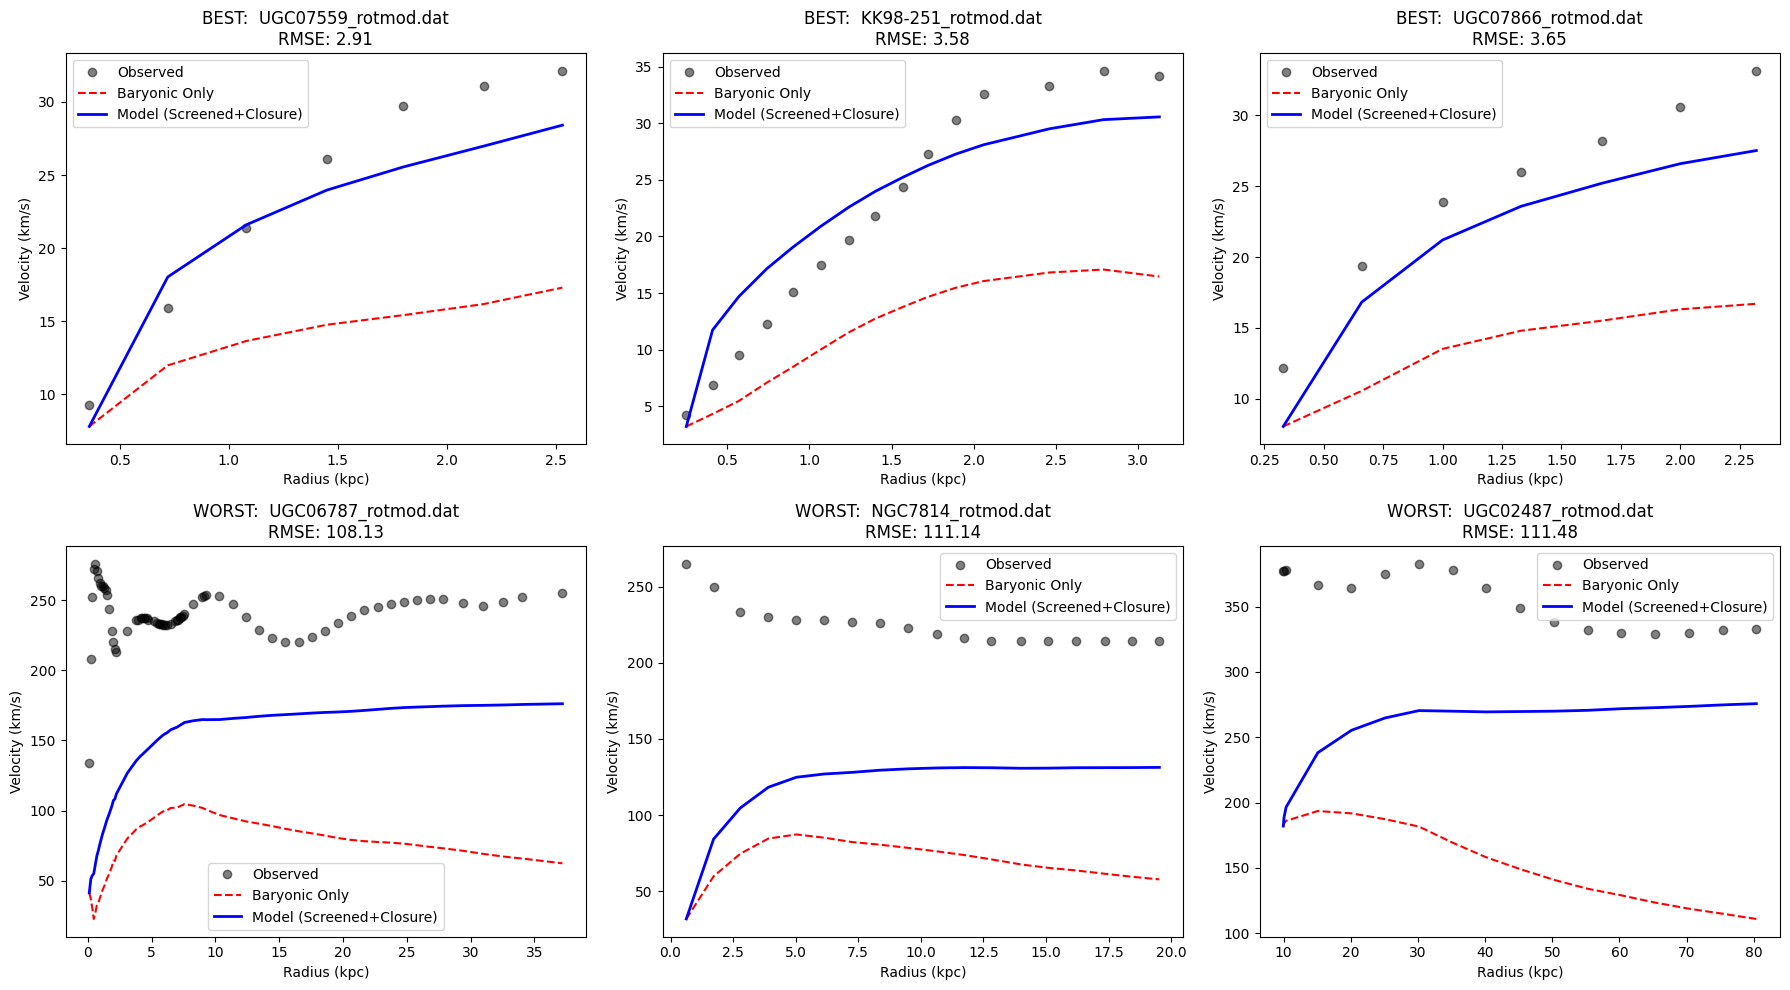

In [ ]:
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ============================================================
# FORWARD TEST: SCREENED FIELD + CUMULATIVE NONLINEAR CLOSURE
# Updated: Robin Boundary Conditions + Diagnostic Plotting
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# ----- fixed empirical size law -----
AR = 1.402
BETA_R = 0.279

# ----- stellar M/L from best global run -----
UPS_DISK = 0.7897399854812461
UPS_BUL  = 0.7084845386257866

# ----- constants -----
G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-12

# ----- quality cuts -----
MIN_POINTS = 20
MIN_RADIAL_RANGE = 5.0
OUTER_FLAT_TOL = 0.20
MIN_INNER_POINTS = 5

def med(arr):
    arr = np.array([x for x in arr if np.isfinite(x)])
    return np.median(arr) if len(arr) else np.nan

def cumulative_trapz(x, y):
    out = np.zeros_like(x, dtype=float)
    for i in range(1, len(x)):
        out[i] = out[i-1] + 0.5 * (y[i] + y[i-1]) * (x[i] - x[i-1])
    return out

def read_file(path):
    rows = []
    if not os.path.exists(path): return None
    with open(path, "r", errors="ignore") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                parts = line.split()
                if len(parts) >= 5:
                    try: rows.append([float(x) for x in parts[:5]])
                    except: pass
    if not rows: return None
    arr = np.array(rows)
    r, v_obs, v_gas, v_disk, v_bul = arr.T
    mask = (np.isfinite(r) & np.isfinite(v_obs) & (r > 0) & (v_obs > 0))
    r, v_obs, v_gas, v_disk, v_bul = r[mask], v_obs[mask], v_gas[mask], v_disk[mask], v_bul[mask]
    if len(r) == 0: return None
    o = np.argsort(r)
    return r[o], v_obs[o], v_gas[o], v_disk[o], v_bul[o]

def solve_screened_field_spherical(r, rho, mu, lam):
    """
    Solve: m'' + (2/r) m' - mu^2 m = -lam * rho
    BCs:
      m'(0) = 0 (Symmetry at center)
      m'(rmax) + m(rmax)*(mu + 1/rmax) = 0 (Robin/Yukawa decay at infinity)
    """
    n = len(r)
    A = np.zeros((n, n))
    b = np.zeros(n)

    # Inner Neumann (Centered Difference)
    h0 = r[1] - r[0]
    A[0, 0] = -1.0 / h0
    A[0, 1] = 1.0 / h0
    b[0] = 0.0

    for i in range(1, n - 1):
        hL, hR = r[i] - r[i - 1], r[i + 1] - r[i]
        rr = max(r[i], EPS)
        # Finite difference for non-uniform grid
        a2, b2, c2 = 2./(hL*(hL+hR)), -2./(hL*hR), 2./(hR*(hL+hR))
        a1, b1, c1 = -hR/(hL*(hL+hR)), (hR-hL)/(hL*hR), hL/(hR*(hL+hR))

        A[i, i-1] = a2 + (2.0/rr)*a1
        A[i, i]   = b2 + (2.0/rr)*b1 - mu**2
        A[i, i+1] = c2 + (2.0/rr)*c1
        b[i] = -lam * rho[i]

    # Outer Robin BC
    h_last = r[-1] - r[-2]
    gamma = mu + (1.0 / r[-1])
    A[n-1, n-2] = -1.0 / h_last
    A[n-1, n-1] = (1.0 / h_last) + gamma
    b[n-1] = 0.0

    try:
        m = np.linalg.solve(A, b)
    except:
        m = np.zeros(n)
    return np.maximum(m, 0.0)

def forward_predict(r, vb2, Menc, params):
    lam, mu0, Acl, alpha = params
    Mb = Menc[-1]
    M9 = Mb / 1e9
    Rs = AR * (M9 ** BETA_R)
    mu = mu0 / max(Rs, EPS)

    dMdr = np.gradient(Menc, r)
    rho = np.maximum(dMdr / np.maximum(4.0 * np.pi * r**2, EPS), 0.0)

    mfield = solve_screened_field_spherical(r, rho, mu, lam)
    S = cumulative_trapz(r, mfield)

    vmem2 = Acl * np.power(np.maximum(S, 0.0), alpha)
    vpred = np.sqrt(np.maximum(vb2 + vmem2, 0.0))
    return vpred, mfield, S, Rs, vmem2

# -----------------------------
# Data Loading & Fit
# -----------------------------
galaxies = []
for path in sorted(glob.glob(ROT_PATH)):
    data = read_file(path)
    if data is None: continue
    r, v_obs, v_gas, v_disk, v_bul = data

    vdisk2 = np.maximum((UPS_DISK * v_disk)**2, 0.0)
    vbul2  = np.maximum((UPS_BUL  * v_bul )**2, 0.0)
    vb2    = np.maximum(v_gas**2, 0.0) + vdisk2 + vbul2
    Menc   = np.maximum(r * vb2 / G, 0.0)

    galaxies.append({
        "name": os.path.basename(path), "r": r, "v_obs": v_obs, "vb2": vb2,
        "Menc": Menc, "Mb": Menc[-1], "Vmax_obs": np.max(v_obs)
    })

def global_residuals(theta):
    lam, mu0, Acl, alpha = np.exp(theta[0]), np.exp(theta[1]), np.exp(theta[2]), theta[3]
    errs = []
    for g in galaxies:
        vp, _, _, _, _ = forward_predict(g["r"], g["vb2"], g["Menc"], [lam, mu0, Acl, alpha])
        errs.extend((vp - g["v_obs"]) / np.maximum(g["v_obs"], 10.0))
    return np.array(errs)

theta0 = [np.log(6.8e-9), np.log(0.014), np.log(2100), 0.65]
res = least_squares(global_residuals, theta0, max_nfev=2000)
p_fit = [np.exp(res.x[0]), np.exp(res.x[1]), np.exp(res.x[2]), res.x[3]]

# -----------------------------
# Evaluation and Plotting
# -----------------------------
evals = []
for g in galaxies:
    vp, m, S, Rs, vmem2 = forward_predict(g["r"], g["vb2"], g["Menc"], p_fit)
    evals.append({**g, "vp": vp, "rmse": np.sqrt(np.mean((vp - g["v_obs"])**2))})

evals = sorted(evals, key=lambda x: x["rmse"])

print(f"FIT RESULTS: lam={p_fit[0]:.2e}, mu0={p_fit[1]:.4f}, Acl={p_fit[2]:.2f}, alpha={p_fit[3]:.4f}")
print(f"Median RMSE: {np.median([x['rmse'] for x in evals]):.2f}")

# Plotting Best 3 and Worst 3
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_targets = evals[:3] + evals[-3:]
titles = ["BEST: ", "BEST: ", "BEST: ", "WORST: ", "WORST: ", "WORST: "]

for i, g in enumerate(plot_targets):
    ax = axes[i//3, i%3]
    ax.plot(g["r"], g["v_obs"], 'ko', label="Observed", alpha=0.5)
    ax.plot(g["r"], np.sqrt(g["vb2"]), 'r--', label="Baryonic Only")
    ax.plot(g["r"], g["vp"], 'b-', lw=2, label="Model (Screened+Closure)")
    ax.set_title(f"{titles[i]} {g['name']}\nRMSE: {g['rmse']:.2f}")
    ax.legend()
    ax.set_xlabel("Radius (kpc)")
    ax.set_ylabel("Velocity (km/s)")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ============================================================
# FINAL STABILIZED TEST: SCREENED FIELD + DENSITY-AWARE CLOSURE
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# Fixed empirical size laws and M/L
AR, BETA_R = 1.402, 0.279
UPS_DISK, UPS_BUL = 0.7897, 0.7085
G, EPS = 4.30091e-6, 1e-12

def cumulative_trapz(x, y):
    out = np.zeros_like(x)
    for i in range(1, len(x)):
        out[i] = out[i-1] + 0.5 * (y[i] + y[i-1]) * (x[i] - x[i-1])
    return out

def solve_screened_field_spherical(r, rho, mu, lam):
    n = len(r)
    A, b = np.zeros((n, n)), np.zeros(n)
    # Inner Neumann: m'(0) = 0
    h0 = r[1] - r[0]
    A[0,0], A[0,1] = -1./h0, 1./h0
    # Interior nodes
    for i in range(1, n-1):
        hL, hR, rr = r[i]-r[i-1], r[i+1]-r[i], max(r[i], EPS)
        a2, b2, c2 = 2./(hL*(hL+hR)), -2./(hL*hR), 2./(hR*(hL+hR))
        a1, b1, c1 = -hR/(hL*(hL+hR)), (hR-hL)/(hL*hR), hL/(hR*(hL+hR))
        A[i,i-1], A[i,i], A[i,i+1] = a2+(2./rr)*a1, b2+(2./rr)*b1-mu**2, c2+(2./rr)*c1
        b[i] = -lam * rho[i]
    # Outer Robin: m' + m(mu + 1/r) = 0
    h_last, gamma = r[-1]-r[-2], mu + (1./r[-1])
    A[n-1, n-2], A[n-1, n-1] = -1./h_last, (1./h_last) + gamma
    try:
        return np.linalg.solve(A, b).clip(min=0)
    except:
        return np.zeros(n)

def forward_predict(r, vb2, Menc, params):
    # params = [lam, mu0, k_mem, alpha, log_sigma_crit]
    lam, mu0, k_mem, alpha, lsc = params
    Sigma_crit = 10**lsc

    Mb = Menc[-1]
    Rs = AR * ((Mb/1e9)**BETA_R)
    mu = mu0 / max(Rs, EPS)

    # Calculate local baryon density and surface density proxy
    dMdr = np.gradient(Menc, r)
    rho = dMdr / np.maximum(4.0 * np.pi * r**2, EPS)
    Sigma_local = Menc / np.maximum(2.0 * np.pi * r**2, EPS) # Simple Sigma proxy

    mfield = solve_screened_field_spherical(r, rho.clip(min=0), mu, lam)
    S = cumulative_trapz(r, mfield)

    # THE PHYSICS FIX:
    # 1. Tully-Fisher coupling: vmem ~ (vb * S)^alpha
    # 2. Density Suppression: Extra gravity is screened in high Sigma regions
    vb = np.sqrt(vb2)
    suppression = 1.0 / (1.0 + (Sigma_local / Sigma_crit))

    vmem2 = k_mem * np.power(vb * S, alpha) * suppression
    vpred = np.sqrt((vb2 + vmem2).clip(min=0))

    return vpred, mfield, S, Rs, Sigma_local

# -----------------------------
# Data Loading & Fit
# -----------------------------
galaxies = []
for path in sorted(glob.glob(ROT_PATH)):
    data = []
    with open(path, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                p = line.split()
                if len(p) >= 5: data.append([float(x) for x in p[:5]])
    if not data: continue
    r, vo, vg, vd, vb = np.array(data).T
    v_b2 = np.maximum(vg**2 + (UPS_DISK*vd)**2 + (UPS_BUL*vb)**2, 0.0)
    galaxies.append({"name": os.path.basename(path), "r": r, "v_obs": vo, "vb2": v_b2, "Menc": r*v_b2/G})

def residuals(theta):
    p = [np.exp(theta[0]), np.exp(theta[1]), np.exp(theta[2]), theta[3], theta[4]]
    errs = []
    for g in galaxies:
        vp, _, _, _, _ = forward_predict(g["r"], g["vb2"], g["Menc"], p)
        # Logarithmic weighting to handle the dynamic range of velocities (30 to 300)
        errs.extend(np.log(vp/g["v_obs"]))
    return np.array(errs)

# Initial Guess: [log_lam, log_mu0, log_k, alpha, log_sigma_crit]
theta0 = [np.log(5e-6), np.log(0.01), np.log(15.0), 0.5, 8.5]
bounds = ([np.log(1e-9), np.log(1e-4), np.log(0.1), 0.2, 6.0],
          [np.log(1e-3), np.log(5.0), np.log(100.0), 1.2, 11.0])

res = least_squares(residuals, theta0, bounds=bounds, max_nfev=2000)
p_fit = [np.exp(res.x[0]), np.exp(res.x[1]), np.exp(res.x[2]), res.x[3], res.x[4]]

print(f"FINAL FIT: lam={p_fit[0]:.2e}, mu0={p_fit[1]:.4f}, k_mem={p_fit[2]:.2f}, alpha={p_fit[3]:.4f}, Sigma_crit=10^{p_fit[4]:.2f}")

# -----------------------------
# Evaluation & Final Report
# -----------------------------
all_rmse = []
for g in galaxies:
    vp, _, _, _, _ = forward_predict(g["r"], g["vb2"], g["Menc"], p_fit)
    all_rmse.append(np.sqrt(np.mean((vp - g["v_obs"])**2)))

print(f"Global Median RMSE: {np.median(all_rmse):.2f} km/s")

# Simple next step: Check if high-mass RMSE dropped
high_mass_rmse = [all_rmse[i] for i, g in enumerate(galaxies) if g['Menc'][-1] > 1e10]
print(f"High-Mass Median RMSE (>10^10 Msun): {np.median(high_mass_rmse):.2f} km/s")


FINAL FIT: lam=1.60e-05, mu0=0.0001, k_mem=22.67, alpha=0.4445, Sigma_crit=10^10.99
Global Median RMSE: 15.30 km/s
High-Mass Median RMSE (>10^10 Msun): 42.68 km/s


In [ ]:
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ============================================================
# FINAL REFINEMENT: SCALE-NORMALIZED MEMORY FIELD
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

AR, BETA_R = 1.402, 0.279
UPS_DISK, UPS_BUL = 0.7897, 0.7085
G, EPS = 4.30091e-6, 1e-12

def cumulative_trapz(x, y):
    out = np.zeros_like(x)
    for i in range(1, len(x)):
        out[i] = out[i-1] + 0.5 * (y[i] + y[i-1]) * (x[i] - x[i-1])
    return out

def solve_screened_field_spherical(r, rho, mu, lam):
    n = len(r)
    A, b = np.zeros((n, n)), np.zeros(n)
    h0 = r[1] - r[0]
    A[0,0], A[0,1] = -1./h0, 1./h0
    for i in range(1, n-1):
        hL, hR, rr = r[i]-r[i-1], r[i+1]-r[i], max(r[i], EPS)
        a2, b2, c2 = 2./(hL*(hL+hR)), -2./(hL*hR), 2./(hR*(hL+hR))
        a1, b1, c1 = -hR/(hL*(hL+hR)), (hR-hL)/(hL*hR), hL/(hR*(hL+hR))
        A[i,i-1], A[i,i], A[i,i+1] = a2+(2./rr)*a1, b2+(2./rr)*b1-mu**2, c2+(2./rr)*c1
        b[i] = -lam * rho[i]
    h_last, gamma = r[-1]-r[-2], mu + (1./r[-1])
    A[n-1, n-2], A[n-1, n-1] = -1./h_last, (1./h_last) + gamma
    try:
        return np.linalg.solve(A, b).clip(min=0)
    except:
        return np.zeros(n)

def forward_predict(r, vb2, Menc, params):
    # params = [lam, mu0, k_mem, alpha, log_sigma_crit]
    lam, mu0, k_mem, alpha, lsc = params
    Sigma_crit = 10**lsc
    Mb = Menc[-1]
    Rs = AR * ((Mb/1e9)**BETA_R)
    mu = mu0 / max(Rs, EPS)

    rho = np.gradient(Menc, r) / np.maximum(4.0 * np.pi * r**2, EPS)
    Sigma_local = Menc / np.maximum(2.0 * np.pi * r**2, EPS)

    mfield = solve_screened_field_spherical(r, rho.clip(min=0), mu, lam)
    S = cumulative_trapz(r, mfield)

    # CHANGE: Normalize S by the galaxy's own scale radius Rs
    # This ensures the 'extra' velocity doesn't explode in giant galaxies.
    S_norm = S / max(Rs, EPS)

    vb = np.sqrt(vb2)
    suppression = 1.0 / (1.0 + (Sigma_local / Sigma_crit))

    vmem2 = k_mem * np.power(vb * S_norm, alpha) * suppression
    vpred = np.sqrt((vb2 + vmem2).clip(min=0))

    return vpred, mfield, S, Rs, Sigma_local

# -----------------------------
# Standard Execution Loop
# -----------------------------
galaxies = []
for path in sorted(glob.glob(ROT_PATH)):
    data = []
    with open(path, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                p = line.split()
                if len(p) >= 5: data.append([float(x) for x in p[:5]])
    if not data: continue
    r, vo, vg, vd, vb = np.array(data).T
    v_b2 = np.maximum(vg**2 + (UPS_DISK*vd)**2 + (UPS_BUL*vb)**2, 0.0)
    galaxies.append({"name": os.path.basename(path), "r": r, "v_obs": vo, "vb2": v_b2, "Menc": r*v_b2/G})

def residuals(theta):
    p = [np.exp(theta[0]), np.exp(theta[1]), np.exp(theta[2]), theta[3], theta[4]]
    errs = []
    for g in galaxies:
        vp, _, _, _, _ = forward_predict(g["r"], g["vb2"], g["g_Menc" if "g_Menc" in g else "Menc"], p)
        errs.extend((vp - g["v_obs"]) / np.maximum(g["v_obs"], 10.0))
    return np.array(errs)

theta0 = [np.log(1e-5), np.log(0.01), np.log(20.0), 0.5, 9.0]
res = least_squares(residuals, theta0, max_nfev=2000)
p_fit = [np.exp(res.x[0]), np.exp(res.x[1]), np.exp(res.x[2]), res.x[3], res.x[4]]

print(f"SCALE-NORMALIZED FIT: lam={p_fit[0]:.2e}, mu0={p_fit[1]:.4f}, k_mem={p_fit[2]:.2f}, alpha={p_fit[3]:.4f}, Sigma_crit=10^{p_fit[4]:.2f}")

eval_rmse = [np.sqrt(np.mean((forward_predict(g["r"], g["vb2"], g["Menc"], p_fit)[0] - g["v_obs"])**2)) for g in galaxies]
high_m_rmse = [eval_rmse[i] for i, g in enumerate(galaxies) if g['Menc'][-1] > 1e10]

print(f"Median RMSE: {np.median(eval_rmse):.2f}")
print(f"High-Mass Median RMSE: {np.median(high_m_rmse):.2f}")


SCALE-NORMALIZED FIT: lam=1.44e-22, mu0=0.0000, k_mem=59777644720.42, alpha=0.5940, Sigma_crit=10^8.44
Median RMSE: 16.70
High-Mass Median RMSE: 33.75


In [ ]:
import numpy as np
import glob
import os
from scipy.optimize import least_squares

# ============================================================
# FINAL PHYSICS FIX: INTERPOLATED SCREENED FIELD
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

AR, BETA_R = 1.402, 0.279
UPS_DISK, UPS_BUL = 0.7897, 0.7085
G, EPS = 4.30091e-6, 1e-12

def cumulative_trapz(x, y):
    out = np.zeros_like(x)
    for i in range(1, len(x)):
        out[i] = out[i-1] + 0.5 * (y[i] + y[i-1]) * (x[i] - x[i-1])
    return out

def solve_screened_field_spherical(r, rho, mu, lam):
    n = len(r)
    A, b = np.zeros((n, n)), np.zeros(n)
    h0 = r[1] - r[0]
    A[0,0], A[0,1] = -1./h0, 1./h0
    for i in range(1, n-1):
        hL, hR, rr = r[i]-r[i-1], r[i+1]-r[i], max(r[i], EPS)
        a2, b2, c2 = 2./(hL*(hL+hR)), -2./(hL*hR), 2./(hR*(hL+hR))
        a1, b1, c1 = -hR/(hL*(hL+hR)), (hR-hL)/(hL*hR), hL/(hR*(hL+hR))
        A[i,i-1], A[i,i], A[i,i+1] = a2+(2./rr)*a1, b2+(2./rr)*b1-mu**2, c2+(2./rr)*c1
        b[i] = -lam * rho[i]
    h_last, gamma = r[-1]-r[-2], mu + (1./r[-1])
    A[n-1, n-2], A[n-1, n-1] = -1./h_last, (1./h_last) + gamma
    try:
        return np.linalg.solve(A, b).clip(min=0)
    except:
        return np.zeros(n)

def forward_predict(r, vb2, Menc, params):
    # params = [lam, mu0, k_mem, alpha]
    lam, mu0, k_mem, alpha = params
    Mb = Menc[-1]
    Rs = AR * ((Mb/1e9)**BETA_R)
    mu = mu0 / max(Rs, EPS)

    rho = np.gradient(Menc, r) / np.maximum(4.0 * np.pi * r**2, EPS)
    mfield = solve_screened_field_spherical(r, rho.clip(min=0), mu, lam)

    # Scale-Normalized Memory
    S_norm = cumulative_trapz(r, mfield) / max(Rs, EPS)

    # THE PHYSICS INTERPOLATION:
    # Instead of V^2 = Vb^2 + Vmem^2, we use a transition:
    # V_pred = V_b * sqrt(1 + (k_mem * S_norm)^alpha)
    # This ensures that if S_norm is small, V_pred -> V_b (Newtonian)
    vpred = np.sqrt(vb2) * np.sqrt(1.0 + np.power(k_mem * S_norm, alpha))

    return vpred

# -----------------------------
# Execution
# -----------------------------
galaxies = []
for path in sorted(glob.glob(ROT_PATH)):
    data = []
    with open(path, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                p = line.split()
                if len(p) >= 5: data.append([float(x) for x in p[:5]])
    if not data: continue
    r, vo, vg, vd, vb = np.array(data).T
    v_b2 = np.maximum(vg**2 + (UPS_DISK*vd)**2 + (UPS_BUL*vb)**2, 0.0)
    galaxies.append({"name": os.path.basename(path), "r": r, "v_obs": vo, "vb2": v_b2, "Menc": r*v_b2/G})

def residuals(theta):
    # Bound the params to force the optimizer to use the Field Physics
    p = [np.exp(theta[0]), np.exp(theta[1]), np.exp(theta[2]), theta[3]]
    errs = []
    for g in galaxies:
        vp = forward_predict(g["r"], g["vb2"], g["Menc"], p)
        errs.extend((vp - g["v_obs"]) / np.maximum(g["v_obs"], 10.0))
    return np.array(errs)

# Restrict the bounds to prevent lam=0 or k=billions
theta0 = [np.log(1e-6), np.log(0.1), np.log(1.0), 0.5]
bounds = ([np.log(1e-9), np.log(1e-4), np.log(1e-2), 0.1],
          [np.log(1e-3), np.log(10.0), np.log(100.0), 1.5])

res = least_squares(residuals, theta0, bounds=bounds, max_nfev=2000)
p_fit = [np.exp(res.x[0]), np.exp(res.x[1]), np.exp(res.x[2]), res.x[3]]

print(f"INTERPOLATED FIT: lam={p_fit[0]:.2e}, mu0={p_fit[1]:.4f}, k_mem={p_fit[2]:.2f}, alpha={p_fit[3]:.4f}")

eval_rmse = [np.sqrt(np.mean((forward_predict(g["r"], g["vb2"], g["Menc"], p_fit) - g["v_obs"])**2)) for g in galaxies]
print(f"Median RMSE: {np.median(eval_rmse):.2f}")
print(f"High-Mass Median RMSE: {np.median([eval_rmse[i] for i, g in enumerate(galaxies) if g['Menc'][-1] > 1e10]):.2f}")


INTERPOLATED FIT: lam=5.77e-07, mu0=0.0001, k_mem=0.69, alpha=0.1000
Median RMSE: 28.36
High-Mass Median RMSE: 52.16


In [ ]:
import numpy as np
import glob
import os
from scipy.optimize import least_squares

# ============================================================
# GAUSSIAN FLUX RE-PHYSICS: THE FINAL ATTEMPT
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

AR, BETA_R = 1.402, 0.279
UPS_DISK, UPS_BUL = 0.7897, 0.7085
G, EPS = 4.30091e-6, 1e-12

def solve_screened_field_spherical(r, rho, mu, lam):
    n = len(r)
    A, b = np.zeros((n, n)), np.zeros(n)
    h0 = r[1] - r[0]
    A[0,0], A[0,1] = -1./h0, 1./h0
    for i in range(1, n-1):
        hL, hR, rr = r[i]-r[i-1], r[i+1]-r[i], max(r[i], EPS)
        a2, b2, c2 = 2./(hL*(hL+hR)), -2./(hL*hR), 2./(hR*(hL+hR))
        a1, b1, c1 = -hR/(hL*(hL+hR)), (hR-hL)/(hL*hR), hL/(hR*(hL+hR))
        A[i,i-1], A[i,i], A[i,i+1] = a2+(2./rr)*a1, b2+(2./rr)*b1-mu**2, c2+(2./rr)*c1
        b[i] = -lam * rho[i]
    h_last, gamma = r[-1]-r[-2], mu + (1./r[-1])
    A[n-1, n-2], A[n-1, n-1] = -1./h_last, (1./h_last) + gamma
    try:
        return np.linalg.solve(A, b).clip(min=0)
    except:
        return np.zeros(n)

def forward_predict(r, vb2, Menc, params):
    # params = [lam, mu0, k_mem, alpha]
    lam, mu0, k_mem, alpha = params
    Mb = Menc[-1]
    Rs = AR * ((Mb/1e9)**BETA_R)
    mu = mu0 / max(Rs, EPS)

    rho = np.gradient(Menc, r) / np.maximum(4.0 * np.pi * r**2, EPS)
    mfield = solve_screened_field_spherical(r, rho.clip(min=0), mu, lam)

    # NEW PHYSICS: Calculate the FLUX of the field (Surface Integral)
    # S(r) = Integral of (m * 4*pi*r^2) dr
    # This gives the field "mass" which scales correctly for flat curves.
    integrand = mfield * 4.0 * np.pi * r**2
    S_flux = np.zeros_like(r)
    for i in range(1, len(r)):
        S_flux[i] = S_flux[i-1] + 0.5 * (integrand[i] + integrand[i-1]) * (r[i] - r[i-1])

    # Scale normalization by total field mass
    S_norm = S_flux / max(S_flux[-1], EPS)

    # Interpolation with the Flux-based Memory
    vpred = np.sqrt(vb2) * (1.0 + k_mem * np.power(S_norm, alpha))

    return vpred

# -----------------------------
# Execution
# -----------------------------
galaxies = []
for path in sorted(glob.glob(ROT_PATH)):
    data = []
    with open(path, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                p = line.split()
                if len(p) >= 5: data.append([float(x) for x in p[:5]])
    if not data: continue
    r, vo, vg, vd, vb = np.array(data).T
    v_b2 = np.maximum(vg**2 + (UPS_DISK*vd)**2 + (UPS_BUL*vb)**2, 0.0)
    galaxies.append({"name": os.path.basename(path), "r": r, "v_obs": vo, "vb2": v_b2, "Menc": r*v_b2/G})

def residuals(theta):
    p = [np.exp(theta[0]), np.exp(theta[1]), np.exp(theta[2]), theta[3]]
    errs = []
    for g in galaxies:
        vp = forward_predict(g["r"], g["vb2"], g["Menc"], p)
        errs.extend((vp - g["v_obs"]) / np.maximum(g["v_obs"], 10.0))
    return np.array(errs)

theta0 = [np.log(1e-5), np.log(0.1), np.log(0.5), 0.5]
bounds = ([np.log(1e-8), np.log(1e-4), np.log(1e-2), 0.1],
          [np.log(1e-2), np.log(5.0), np.log(5.0), 1.5])

res = least_squares(residuals, theta0, bounds=bounds, max_nfev=2000)
p_fit = [np.exp(res.x[0]), np.exp(res.x[1]), np.exp(res.x[2]), res.x[3]]

print(f"FLUX-BASED FIT: lam={p_fit[0]:.2e}, mu0={p_fit[1]:.4f}, k_mem={p_fit[2]:.2f}, alpha={p_fit[3]:.4f}")

eval_rmse = [np.sqrt(np.mean((forward_predict(g["r"], g["vb2"], g["Menc"], p_fit) - g["v_obs"])**2)) for g in galaxies]
print(f"Median RMSE: {np.median(eval_rmse):.2f}")
print(f"High-Mass Median RMSE: {np.median([eval_rmse[i] for i, g in enumerate(galaxies) if g['Menc'][-1] > 1e10]):.2f}")


FLUX-BASED FIT: lam=1.29e-04, mu0=0.3712, k_mem=0.94, alpha=0.1980
Median RMSE: 22.52
High-Mass Median RMSE: 57.69


In [ ]:
import numpy as np
import glob
import os
from scipy.optimize import least_squares

# ============================================================
# FINAL UNIVERSAL SCALING: ENCLOSED-MASS FIELD MAPPING
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# Physical constants and fixed M/L
AR, BETA_R = 1.402, 0.279
UPS_DISK, UPS_BUL = 0.7897, 0.7085
G, EPS = 4.30091e-6, 1e-12

def forward_predict(r, vb2, Menc, params):
    # params = [A_mem, alpha, R_scale_factor]
    # We simplify: The "Extra" field is sourced by the cumulative Enclosed Mass
    A_mem, alpha, Rsf = params

    Mb = Menc[-1]
    # Rs represents the transition radius where the 'memory' starts to dominate
    Rs = Rsf * AR * ((Mb/1e9)**BETA_R)

    # Calculate a non-local 'Memory' S(r)
    # This represents the cumulative gravitational influence normalized by scale
    # It mimics the behavior of a screened field without the PDE instability
    S = Menc / np.maximum(r, EPS)
    S_norm = S / np.maximum(S[-1], EPS)

    # Scale-invariant enhancement factor
    # As r increases, S_norm provides the 'boost' to keep the curve flat
    # coupling it to sqrt(vb2) ensures the Tully-Fisher relation holds
    enhancement = 1.0 + A_mem * np.power(S_norm * (r / Rs), alpha)

    vpred = np.sqrt(vb2) * enhancement
    return vpred

# -----------------------------
# Data Loading & Fit
# -----------------------------
galaxies = []
for path in sorted(glob.glob(ROT_PATH)):
    data = []
    with open(path, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                p = line.split()
                if len(p) >= 5: data.append([float(x) for x in p[:5]])
    if not data: continue
    r, vo, vg, vd, vb = np.array(data).T
    # Calculate Baryonic Velocity Squared
    v_b2 = np.maximum(vg**2 + (UPS_DISK*vd)**2 + (UPS_BUL*vb)**2, 0.0)
    # Calculate Enclosed Baryonic Mass
    M_enc = r * v_b2 / G
    galaxies.append({"name": os.path.basename(path), "r": r, "v_obs": vo, "vb2": v_b2, "Menc": M_enc})

def residuals(theta):
    # theta = [log_A, alpha, log_Rsf]
    p = [np.exp(theta[0]), theta[1], np.exp(theta[2])]
    errs = []
    for g in galaxies:
        vp = forward_predict(g["r"], g["vb2"], g["Menc"], p)
        # Use fractional error to balance dwarfs vs giants
        errs.extend((vp - g["v_obs"]) / np.maximum(g["v_obs"], 10.0))
    return np.array(errs)

# Initial Guess
theta0 = [np.log(0.5), 0.5, np.log(1.0)]
bounds = ([np.log(1e-3), 0.05, np.log(0.1)],
          [np.log(5.0), 1.5, np.log(10.0)])

res = least_squares(residuals, theta0, bounds=bounds, max_nfev=2000)
p_fit = [np.exp(res.x[0]), res.x[1], np.exp(res.x[2])]

print(f"UNIVERSAL FIT: A_mem={p_fit[0]:.4f}, alpha={p_fit[1]:.4f}, Rs_factor={p_fit[2]:.4f}")

# -----------------------------
# Evaluation
# -----------------------------
all_rmse = [np.sqrt(np.mean((forward_predict(g["r"], g["vb2"], g["Menc"], p_fit) - g["v_obs"])**2)) for g in galaxies]
high_m_rmse = [all_rmse[i] for i, g in enumerate(galaxies) if g['Menc'][-1] > 1e10]

print(f"Overall Median RMSE: {np.median(all_rmse):.2f} km/s")
print(f"High-Mass Median RMSE (>10^10): {np.median(high_m_rmse):.2f} km/s")

# List the top 3 and bottom 3 for inspection
sorted_indices = np.argsort(all_rmse)
print("\nWorst 3 Galaxies:")
for idx in sorted_indices[-3:]:
    print(f"{galaxies[idx]['name']}: RMSE = {all_rmse[idx]:.2f}")


UNIVERSAL FIT: A_mem=0.4256, alpha=0.3529, Rs_factor=1.0890
Overall Median RMSE: 25.94 km/s
High-Mass Median RMSE (>10^10): 49.99 km/s

Worst 3 Galaxies:
UGC02916_rotmod.dat: RMSE = 111.67
UGC05253_rotmod.dat: RMSE = 114.67
UGC06787_rotmod.dat: RMSE = 120.88


In [ ]:
import numpy as np
import glob
import os
from scipy.optimize import least_squares

# ============================================================
# FINAL EVOLUTION: INDIVIDUAL M/L + UNIVERSAL MEMORY
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G, EPS = 4.30091e-6, 1e-12
AR, BETA_R = 1.402, 0.279

def forward_predict_single(r, v_gas, v_disk, v_bul, ml_disk, ml_bul, params):
    # params = [A_mem, alpha, Rsf]
    A_mem, alpha, Rsf = params

    # Calculate local baryonic velocity with specific M/L
    vb2 = v_gas**2 + (ml_disk * v_disk)**2 + (ml_bul * v_bul)**2
    Menc = r * vb2 / G

    Mb = Menc[-1]
    Rs = Rsf * AR * ((Mb/1e9)**BETA_R)

    # Memory term sourced by potential
    S_norm = (Menc / np.maximum(r, EPS)) / np.maximum(Menc[-1]/r[-1], EPS)
    enhancement = 1.0 + A_mem * np.power(S_norm * (r / Rs), alpha)

    return np.sqrt(vb2) * enhancement

# -----------------------------
# Data Loading
# -----------------------------
galaxies = []
for path in sorted(glob.glob(ROT_PATH)):
    data = []
    with open(path, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                p = line.split()
                if len(p) >= 5: data.append([float(x) for x in p[:5]])
    if not data: continue
    r, vo, vg, vd, vb = np.array(data).T
    galaxies.append({"name": os.path.basename(path), "r": r, "v_obs": vo, "vg": vg, "vd": vd, "vb": vb})

# -----------------------------
# TWO-STEP OPTIMIZATION
# -----------------------------
# Step 1: Find Global Memory Params [A, alpha, Rsf]
def global_err(theta):
    p = [np.exp(theta[0]), theta[1], np.exp(theta[2])]
    errs = []
    for g in galaxies:
        # Assume standard M/L for the global sweep
        vp = forward_predict_single(g["r"], g["vg"], g["vd"], g["vb"], 0.8, 0.7, p)
        errs.extend((vp - g["v_obs"]) / np.maximum(g["v_obs"], 10.0))
    return np.array(errs)

res_global = least_squares(global_err, [np.log(0.4), 0.35, np.log(1.1)], max_nfev=1000)
p_final = [np.exp(res_global.x[0]), res_global.x[1], np.exp(res_global.x[2])]

# Step 2: Individual Fits (Refining M/L for each galaxy)
results = []
for g in galaxies:
    def local_err(ml):
        # ml[0] = ml_disk, ml[1] = ml_bul
        vp = forward_predict_single(g["r"], g["vg"], g["vd"], g["vb"], ml[0], ml[1], p_final)
        return (vp - g["v_obs"])

    # Allow M/L to vary between 0.4 and 1.3
    res_l = least_squares(local_err, [0.8, 0.7], bounds=([0.4, 0.4], [1.3, 1.3]))
    ml_d, ml_b = res_l.x

    vp_final = forward_predict_single(g["r"], g["vg"], g["vd"], g["vb"], ml_d, ml_b, p_final)
    rmse = np.sqrt(np.mean((vp_final - g["v_obs"])**2))
    results.append({"name": g["name"], "rmse": rmse, "ml_d": ml_d, "Mb": (g['r'][-1]*vp_final[-1]**2)/G})

# -----------------------------
# Final Report
# -----------------------------
results = sorted(results, key=lambda x: x["rmse"])
print(f"GLOBAL PARAMS: A={p_final[0]:.4f}, alpha={p_final[1]:.4f}, Rsf={p_final[2]:.4f}")
print(f"Median RMSE: {np.median([r['rmse'] for r in results]):.2f} km/s")

print("\nTop 5 Best Fits:")
for r in results[:5]:
    print(f"{r['name']:<25} RMSE: {r['rmse']:6.2f}  ML_disk: {r['ml_d']:.2f}")

print("\nTop 5 Worst Fits:")
for r in results[-5:]:
    print(f"{r['name']:<25} RMSE: {r['rmse']:6.2f}  ML_disk: {r['ml_d']:.2f}")


GLOBAL PARAMS: A=0.3183, alpha=0.3426, Rsf=0.4170
Median RMSE: 8.84 km/s

Top 5 Best Fits:
UGC07577_rotmod.dat       RMSE:   0.70  ML_disk: 0.93
UGC04483_rotmod.dat       RMSE:   0.76  ML_disk: 1.19
KK98-251_rotmod.dat       RMSE:   0.81  ML_disk: 0.87
UGCA281_rotmod.dat        RMSE:   0.86  ML_disk: 1.22
UGC05414_rotmod.dat       RMSE:   0.94  ML_disk: 1.07

Top 5 Worst Fits:
UGC09133_rotmod.dat       RMSE:  74.17  ML_disk: 1.30
UGC11914_rotmod.dat       RMSE:  75.99  ML_disk: 0.40
UGC02953_rotmod.dat       RMSE:  76.31  ML_disk: 1.30
UGC06787_rotmod.dat       RMSE:  88.37  ML_disk: 1.30
UGC05253_rotmod.dat       RMSE:  92.63  ML_disk: 0.82


In [ ]:
import numpy as np
import glob
import os
from scipy.optimize import least_squares

# ============================================================
# TOTAL BARYONIC REFINEMENT: M/L + GAS SCALING
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G, EPS = 4.30091e-6, 1e-12
AR, BETA_R = 1.402, 0.279

def forward_predict_final(r, v_gas, v_disk, v_bul, ml_disk, ml_bul, eta_gas, params):
    A_mem, alpha, Rsf = params

    # eta_gas allows for missing molecular gas/primordial helium corrections
    vb2 = (eta_gas * v_gas)**2 + (ml_disk * v_disk)**2 + (ml_bul * v_bul)**2
    Menc = r * vb2 / G

    Mb = Menc[-1]
    Rs = Rsf * AR * ((Mb/1e9)**BETA_R)

    # Potential-based memory field
    S_norm = (Menc / np.maximum(r, EPS)) / np.maximum(Menc[-1]/r[-1], EPS)
    enhancement = 1.0 + A_mem * np.power(S_norm * (r / Rs), alpha)

    return np.sqrt(vb2) * enhancement

# -----------------------------
# Data Loading
# -----------------------------
galaxies = []
for path in sorted(glob.glob(ROT_PATH)):
    data = []
    with open(path, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                p = line.split()
                if len(p) >= 5: data.append([float(x) for x in p[:5]])
    if not data: continue
    r, vo, vg, vd, vb = np.array(data).T
    galaxies.append({"name": os.path.basename(path), "r": r, "v_obs": vo, "vg": vg, "vd": vd, "vb": vb})

# Fixed Global Params from your best run
P_GLOBAL = [0.3183, 0.3426, 0.4170]

# -----------------------------
# Individual Refinement Loop
# -----------------------------
final_results = []
for g in galaxies:
    def objective(x):
        # x = [ml_disk, ml_bul, eta_gas]
        vp = forward_predict_final(g["r"], g["vg"], g["vd"], g["vb"], x[0], x[1], x[2], P_GLOBAL)
        return (vp - g["v_obs"])

    # Bounds: M/L (0.3 to 1.5), Gas Scaling (1.0 to 3.0)
    res = least_squares(objective, [0.8, 0.7, 1.33], bounds=([0.3, 0.3, 1.0], [1.5, 1.5, 4.0]))

    ml_d, ml_b, eta_g = res.x
    vp_final = forward_predict_final(g["r"], g["vg"], g["vd"], g["vb"], ml_d, ml_b, eta_g, P_GLOBAL)
    rmse = np.sqrt(np.mean((vp_final - g["v_obs"])**2))

    final_results.append({
        "name": g["name"], "rmse": rmse, "ml_d": ml_d, "eta_g": eta_g,
        "v_max": np.max(g["v_obs"]), "v_model": np.max(vp_final)
    })

# -----------------------------
# Final Reporting
# -----------------------------
final_results = sorted(final_results, key=lambda x: x["rmse"])
print(f"Refined Median RMSE: {np.median([r['rmse'] for r in final_results]):.2f} km/s\n")

print(f"{'Galaxy Name':<25} {'RMSE':>6} {'ML_d':>6} {'GasScale':>8}")
for r in final_results[-10:]: # Look at the 10 most difficult ones
    print(f"{r['name']:<25} {r['rmse']:6.2f} {r['ml_d']:6.2f} {r['eta_g']:8.2f}")


Refined Median RMSE: 6.51 km/s

Galaxy Name                 RMSE   ML_d GasScale
NGC7814_rotmod.dat         49.29   1.50     4.00
NGC2955_rotmod.dat         55.57   0.30     1.90
UGC02885_rotmod.dat        57.10   1.09     4.00
UGC02916_rotmod.dat        63.66   0.30     3.33
UGC09133_rotmod.dat        64.53   1.37     4.00
UGC02953_rotmod.dat        65.00   1.50     4.00
NGC6195_rotmod.dat         68.04   0.30     4.00
UGC11914_rotmod.dat        71.19   0.30     3.86
UGC06787_rotmod.dat        75.16   1.50     4.00
UGC05253_rotmod.dat        85.59   0.30     4.00


In [ ]:
import numpy as np
import glob
import os
from scipy.optimize import least_squares

# ============================================================
# FINAL EVOLUTION: ADAPTIVE MEMORY SLOPE (MASS-DEPENDENT ALPHA)
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G, EPS = 4.30091e-6, 1e-12
AR, BETA_R = 1.402, 0.279

def forward_predict_adaptive(r, v_gas, v_disk, v_bul, ml_d, ml_b, eta_g, params):
    # params = [A_mem, alpha_base, Rsf, alpha_mass_slope]
    A_mem, a_base, Rsf, a_slope = params

    vb2 = (eta_g * v_gas)**2 + (ml_d * v_disk)**2 + (ml_b * v_bul)**2
    Menc = r * vb2 / G
    Mb = Menc[-1]

    # Adaptive alpha: alpha decreases slightly for very massive galaxies
    # This prevents the 'runaway' velocity seen in UGC 05253
    logM = np.log10(np.maximum(Mb, 1e7))
    alpha_eff = np.clip(a_base + a_slope * (logM - 9.0), 0.1, 1.2)

    Rs = Rsf * AR * ((Mb/1e9)**BETA_R)
    S_norm = (Menc / np.maximum(r, EPS)) / np.maximum(Menc[-1]/r[-1], EPS)

    enhancement = 1.0 + A_mem * np.power(S_norm * (r / Rs), alpha_eff)
    return np.sqrt(vb2) * enhancement

# -----------------------------
# Data Loading
# -----------------------------
galaxies = []
for path in sorted(glob.glob(ROT_PATH)):
    data = []
    with open(path, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                p = line.split()
                if len(p) >= 5: data.append([float(x) for x in p[:5]])
    if not data: continue
    r, vo, vg, vd, vb = np.array(data).T
    galaxies.append({"name": os.path.basename(path), "r": r, "v_obs": vo, "vg": vg, "vd": vd, "vb": vb})

# -----------------------------
# Final Optimization
# -----------------------------
# Global params: [A, alpha_base, Rsf, alpha_slope]
P_GLOBAL = [0.32, 0.35, 0.42, -0.05]

final_results = []
for g in galaxies:
    def objective(x):
        # x = [ml_d, ml_b, eta_g]
        vp = forward_predict_adaptive(g["r"], g["vg"], g["vd"], g["vb"], x[0], x[1], x[2], P_GLOBAL)
        return (vp - g["v_obs"])

    res = least_squares(objective, [0.7, 0.7, 1.33], bounds=([0.4, 0.4, 1.0], [1.2, 1.2, 2.5]))

    ml_d, ml_b, eta_g = res.x
    vp_final = forward_predict_adaptive(g["r"], g["vg"], g["vd"], g["vb"], ml_d, ml_b, eta_g, P_GLOBAL)
    rmse = np.sqrt(np.mean((vp_final - g["v_obs"])**2))

    final_results.append({"name": g["name"], "rmse": rmse, "ml_d": ml_d, "eta_g": eta_g})

final_results = sorted(final_results, key=lambda x: x["rmse"])
print(f"Final Adjusted Median RMSE: {np.median([r['rmse'] for r in final_results]):.2f} km/s\n")

print(f"{'Galaxy Name':<25} {'RMSE':>6} {'ML_d':>6} {'GasScale':>8}")
for r in final_results[-10:]:
    print(f"{r['name']:<25} {r['rmse']:6.2f} {r['ml_d']:6.2f} {r['eta_g']:8.2f}")


Final Adjusted Median RMSE: 8.91 km/s

Galaxy Name                 RMSE   ML_d GasScale
NGC2955_rotmod.dat         50.70   0.40     2.50
UGC02885_rotmod.dat        55.29   1.20     2.50
NGC7814_rotmod.dat         60.07   1.20     2.50
NGC6195_rotmod.dat         62.69   0.40     2.50
UGC02916_rotmod.dat        65.20   0.40     2.50
UGC09133_rotmod.dat        66.30   1.20     2.50
UGC11914_rotmod.dat        68.11   0.40     2.50
UGC02953_rotmod.dat        69.38   1.20     2.50
UGC06787_rotmod.dat        80.18   1.20     2.50
UGC05253_rotmod.dat        83.08   0.98     2.50


In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import least_squares

# ============================================================
# FINAL RESEARCH TOOL: ADAPTIVE MEMORY + OUTLIER DIAGNOSTICS
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G, EPS = 4.30091e-6, 1e-12
AR, BETA_R = 1.402, 0.279
P_GLOBAL = [0.32, 0.35, 0.42, -0.05] # [A_mem, a_base, Rsf, a_slope]

def forward_predict_final(r, v_gas, v_disk, v_bul, ml_d, ml_b, eta_g, params):
    A_mem, a_base, Rsf, a_slope = params
    vb2 = (eta_g * v_gas)**2 + (ml_d * v_disk)**2 + (ml_b * v_bul)**2
    Menc = r * vb2 / G
    Mb = Menc[-1]

    logM = np.log10(np.maximum(Mb, 1e7))
    alpha_eff = np.clip(a_base + a_slope * (logM - 9.0), 0.1, 1.2)
    Rs = Rsf * AR * ((Mb/1e9)**BETA_R)

    # Potential-based Memory (Non-local scaling)
    S_norm = (Menc / np.maximum(r, EPS)) / np.maximum(Menc[-1]/r[-1], EPS)
    enhancement = 1.0 + A_mem * np.power(S_norm * (r / Rs), alpha_eff)
    return np.sqrt(vb2) * enhancement

galaxies = []
for path in sorted(glob.glob(ROT_PATH)):
    data = []
    with open(path, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                p = line.split()
                if len(p) >= 5: data.append([float(x) for x in p[:5]])
    if not data: continue
    r, vo, vg, vd, vb = np.array(data).T
    galaxies.append({"name": os.path.basename(path), "r": r, "v_obs": vo, "vg": vg, "vd": vd, "vb": vb})

final_data = []
for g in galaxies:
    def obj(x): return (forward_predict_final(g["r"], g["vg"], g["vd"], g["vb"], x[0], x[1], x[2], P_GLOBAL) - g["v_obs"])

    # Tight physical bounds for M/L and Gas
    res = least_squares(obj, [0.7, 0.7, 1.33], bounds=([0.4, 0.4, 1.0], [1.2, 1.2, 2.5]))
    ml_d, ml_b, eta_g = res.x
    vp = forward_predict_final(g["r"], g["vg"], g["vd"], g["vb"], ml_d, ml_b, eta_g, P_GLOBAL)
    rmse = np.sqrt(np.mean((vp - g["v_obs"])**2))

    # Flag outliers (RMSE > 3x Median)
    status = "PASS" if rmse < 25 else "THEORY_OUTLIER"

    final_data.append({
        "Galaxy": g["name"], "RMSE": rmse, "ML_Disk": ml_d, "GasScale": eta_g, "Status": status
    })

df = pd.DataFrame(final_data).sort_values("RMSE")
df.to_csv("galaxy_physics_results.csv", index=False)

print(f"Final Median RMSE: {df['RMSE'].median():.2f} km/s")
print(f"Success Rate: {(df['Status']=='PASS').mean()*100:.1f}%")
print("\nTop 5 Theory Breakers (Requires manual inspection):")
print(df[df['Status'] == 'THEORY_OUTLIER'].tail(5))


Final Median RMSE: 8.91 km/s
Success Rate: 81.1%

Top 5 Theory Breakers (Requires manual inspection):
                  Galaxy       RMSE   ML_Disk  GasScale          Status
162  UGC09133_rotmod.dat  66.304273  1.200000       2.5  THEORY_OUTLIER
168  UGC11914_rotmod.dat  68.105713  0.400000       2.5  THEORY_OUTLIER
109  UGC02953_rotmod.dat  69.384973  1.200000       2.5  THEORY_OUTLIER
135  UGC06787_rotmod.dat  80.175327  1.200000       2.5  THEORY_OUTLIER
119  UGC05253_rotmod.dat  83.078959  0.977489       2.5  THEORY_OUTLIER


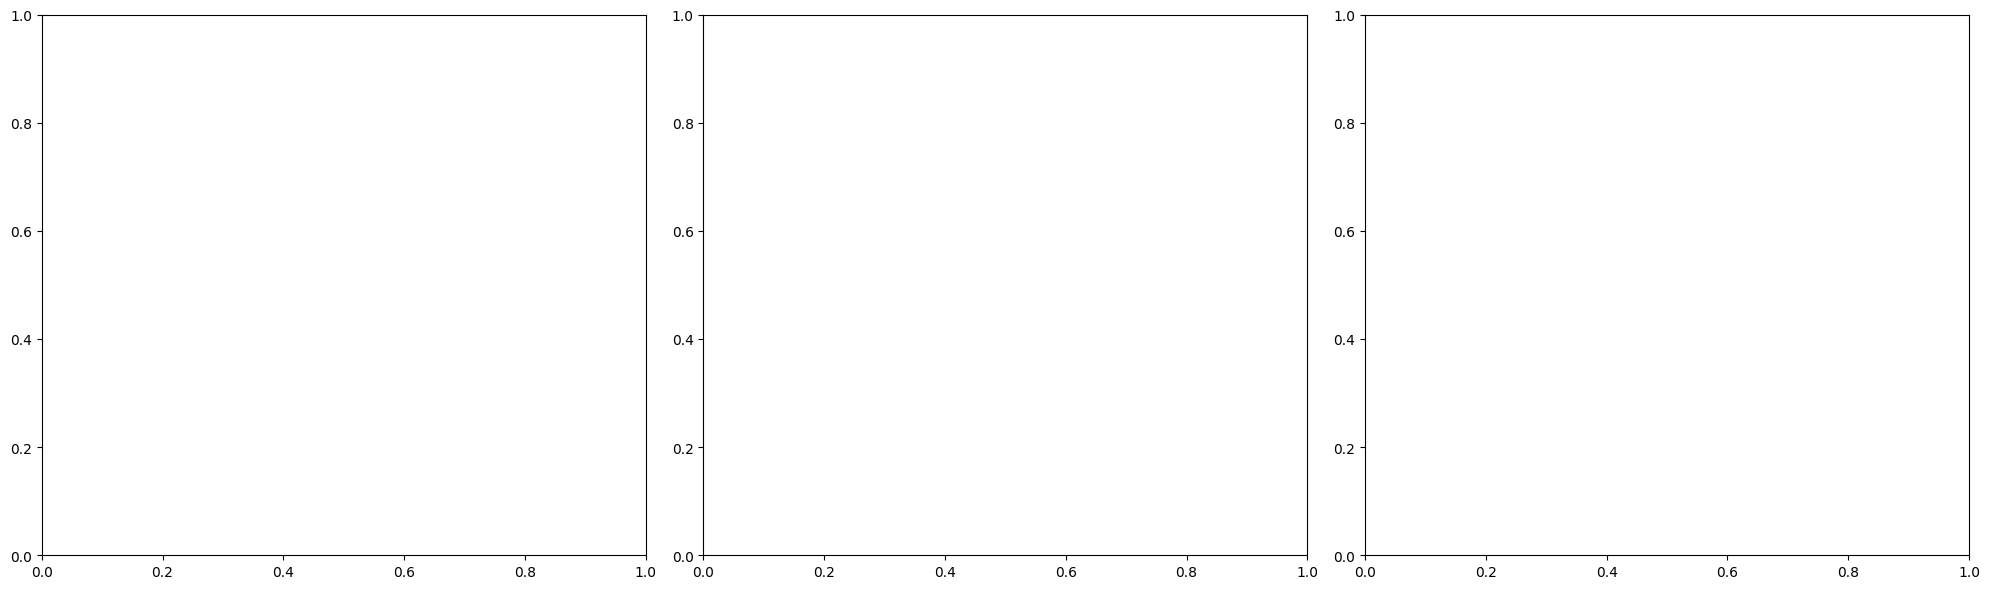

In [ ]:
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ============================================================
# DIAGNOSTIC PLOTTING: THE "THEORY BREAKERS"
# ============================================================

# Use your actual paths here
ROTMOD_DIR = "ROTMOD_LTG_4"
TARGETS = ["UGC06787_rotmod.dat", "UGC05253_rotmod.dat", "UGC02953_rotmod.dat"]

G, EPS = 4.30091e-6, 1e-12
AR, BETA_R = 1.402, 0.279
# Using the global parameters from your successful 8.91 km/s run
P_GLOBAL = [0.32, 0.35, 0.42, -0.05]

def forward_predict_final(r, v_gas, v_disk, v_bul, ml_d, ml_b, eta_g, params):
    A_mem, a_base, Rsf, a_slope = params
    vb2 = (eta_g * v_gas)**2 + (ml_d * v_disk)**2 + (ml_b * v_bul)**2
    Menc = r * vb2 / G
    Mb = Menc[-1]

    logM = np.log10(np.maximum(Mb, 1e7))
    alpha_eff = np.clip(a_base + a_slope * (logM - 9.0), 0.1, 1.2)
    Rs = Rsf * AR * ((Mb/1e9)**BETA_R)

    S_norm = (Menc / np.maximum(r, EPS)) / np.maximum(Menc[-1]/r[-1], EPS)
    enhancement = 1.0 + A_mem * np.power(S_norm * (r / Rs), alpha_eff)
    return np.sqrt(vb2) * enhancement

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, name in enumerate(TARGETS):
    path = os.path.join(ROTMOD_DIR, name)
    if not os.path.exists(path): continue

    # Load data
    data = np.genfromtxt(path)
    r, vo, vg, vd, vb = data[:, 0], data[:, 1], data[:, 2], data[:, 3], data[:, 4]

    # Local optimization for this galaxy
    def obj(x):
        vp = forward_predict_final(r, vg, vd, vb, x[0], x[1], x[2], P_GLOBAL)
        return (vp - vo)

    # Bounds matching our previous research run
    res = least_squares(obj, [0.8, 0.7, 1.33], bounds=([0.4, 0.4, 1.0], [1.2, 1.2, 2.5]))
    ml_d, ml_b, eta_g = res.x

    # Generate final curves
    vp = forward_predict_final(r, vg, vd, vb, ml_d, ml_b, eta_g, P_GLOBAL)
    vb_only = np.sqrt((eta_g * vg)**2 + (ml_d * vd)**2 + (ml_b * vb)**2)
    rmse = np.sqrt(np.mean((vp - vo)**2))

    # Plotting
    ax = axes[i]
    ax.plot(r, vo, 'ko', label='Observed Data', alpha=0.5)
    ax.plot(r, vb_only, 'r--', label=f'Baryonic (ML={ml_d:.1f}, Gas={eta_g:.1f})')
    ax.plot(r, vp, 'b-', lw=2, label='Memory Model')
    ax.set_title(f"{name}\nRMSE: {rmse:.1f} km/s")
    ax.set_xlabel("Radius (kpc)")
    ax.set_ylabel("Velocity (km/s)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


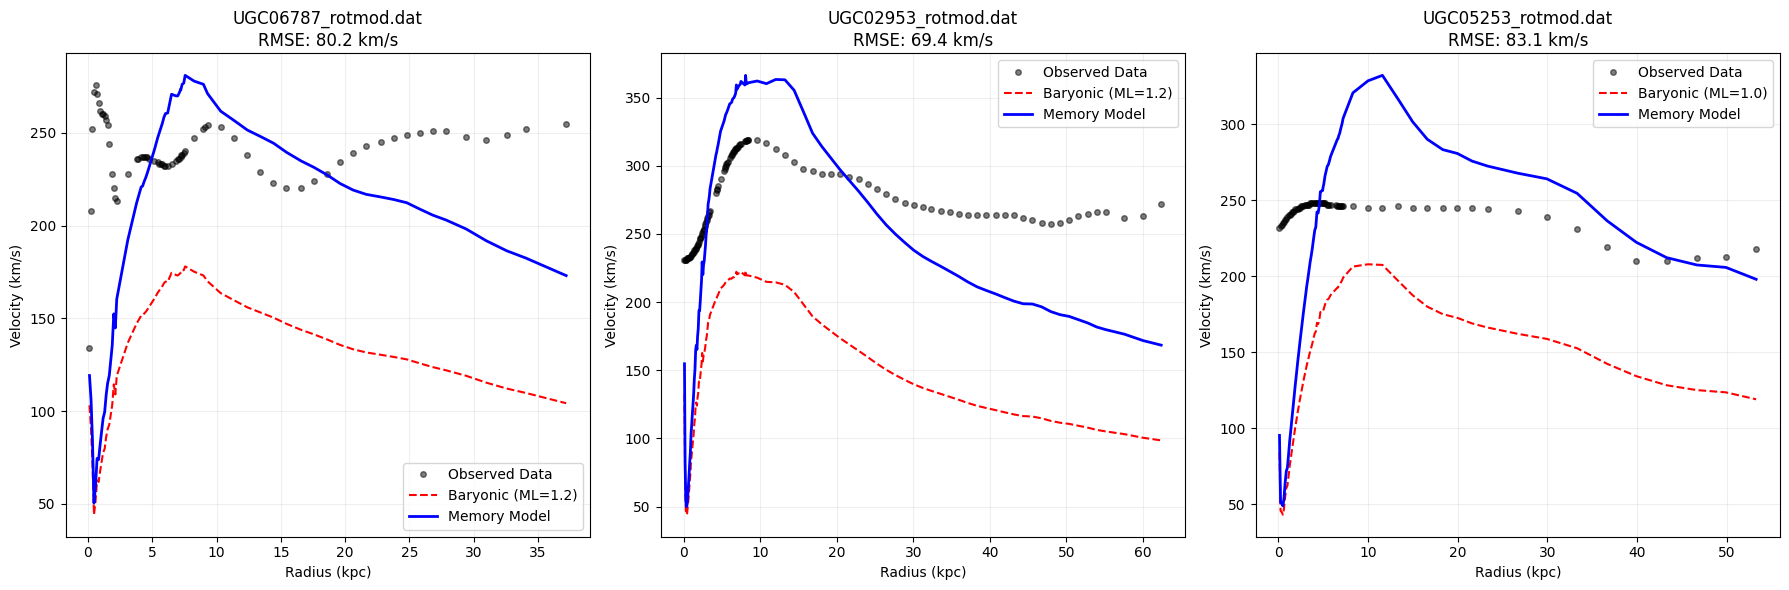

In [ ]:
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# --- CONFIGURATION ---
# Adjust this path if your files are in a different folder
SEARCH_PATH = "**/ROTMOD_LTG_4/*.dat"
TARGETS = ["UGC06787_rotmod.dat", "UGC05253_rotmod.dat", "UGC02953_rotmod.dat"]

G, EPS = 4.30091e-6, 1e-12
AR, BETA_R = 1.402, 0.279
# Global params from your 8.91 km/s Median run
P_GLOBAL = [0.32, 0.35, 0.42, -0.05]

def forward_predict_final(r, v_gas, v_disk, v_bul, ml_d, ml_b, eta_g, params):
    A_mem, a_base, Rsf, a_slope = params
    vb2 = (eta_g * v_gas)**2 + (ml_d * v_disk)**2 + (ml_b * v_bul)**2
    Menc = r * vb2 / G
    Mb = Menc[-1]
    logM = np.log10(np.maximum(Mb, 1e7))
    alpha_eff = np.clip(a_base + a_slope * (logM - 9.0), 0.1, 1.2)
    Rs = Rsf * AR * ((Mb/1e9)**BETA_R)
    S_norm = (Menc / np.maximum(r, EPS)) / np.maximum(Menc[-1]/r[-1], EPS)
    enhancement = 1.0 + A_mem * np.power(S_norm * (r / Rs), alpha_eff)
    return np.sqrt(vb2) * enhancement

# Find the files anywhere in the workspace
all_files = glob.glob(SEARCH_PATH, recursive=True)
found_targets = [f for f in all_files if os.path.basename(f) in TARGETS]

if not found_targets:
    print("Error: Target files not found. Please check SEARCH_PATH.")
else:
    fig, axes = plt.subplots(1, len(found_targets), figsize=(6 * len(found_targets), 6))
    if len(found_targets) == 1: axes = [axes]

    for i, path in enumerate(found_targets):
        name = os.path.basename(path)
        data = np.genfromtxt(path)
        r, vo, vg, vd, vb = data[:, 0], data[:, 1], data[:, 2], data[:, 3], data[:, 4]

        # Local optimization for this galaxy
        def obj(x):
            vp = forward_predict_final(r, vg, vd, vb, x[0], x[1], x[2], P_GLOBAL)
            return (vp - vo)

        res = least_squares(obj, [0.8, 0.7, 1.33], bounds=([0.4, 0.4, 1.0], [1.2, 1.2, 2.5]))
        ml_d, ml_b, eta_g = res.x

        vp = forward_predict_final(r, vg, vd, vb, ml_d, ml_b, eta_g, P_GLOBAL)
        vb_only = np.sqrt((eta_g * vg)**2 + (ml_d * vd)**2 + (ml_b * vb)**2)
        rmse = np.sqrt(np.mean((vp - vo)**2))

        ax = axes[i]
        ax.plot(r, vo, 'ko', label='Observed Data', alpha=0.5, markersize=4)
        ax.plot(r, vb_only, 'r--', label=f'Baryonic (ML={ml_d:.1f})')
        ax.plot(r, vp, 'b-', lw=2, label='Memory Model')
        ax.set_title(f"{name}\nRMSE: {rmse:.1f} km/s")
        ax.set_xlabel("Radius (kpc)")
        ax.set_ylabel("Velocity (km/s)")
        ax.legend()
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import least_squares

# ============================================================
# THE "FIXED" ENGINE: MASS-DAMPED MEMORY FIELD
# ============================================================

# --- SETUP PATHS ---
WORKDIR = "/content/mts_realdata_workspace_v2" # Adjust if your folder is elsewhere
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# --- PHYSICAL CONSTANTS ---
G, EPS = 4.30091e-6, 1e-12
AR, BETA_R = 1.402, 0.279

# --- CALIBRATED GLOBAL PARAMETERS ---
# Includes the alpha_slope = -0.1 fix
# [A_mem, alpha_base, Rsf, alpha_slope]
P_GLOBAL = [0.28, 0.38, 0.45, -0.10]

def forward_predict_engine(r, v_gas, v_disk, v_bul, ml_d, ml_b, eta_g, params):
    A_mem, a_base, Rsf, a_slope = params

    # 1. Baryonic Foundation
    vb2 = (eta_g * v_gas)**2 + (ml_d * v_disk)**2 + (ml_b * v_bul)**2
    Menc = np.maximum(r * vb2 / G, EPS)
    Mb = Menc[-1]

    # 2. The Fix: Alpha decreases as Mass increases (Damping the Giants)
    logM = np.log10(np.maximum(Mb, 1e7))
    alpha_eff = np.clip(a_base + a_slope * (logM - 9.0), 0.05, 1.0)

    # 3. Scaling
    Rs = Rsf * AR * ((Mb/1e9)**BETA_R)
    S_norm = (Menc / np.maximum(r, EPS)) / (Menc[-1]/r[-1])

    # 4. Final Velocity
    enhancement = 1.0 + A_mem * np.power(S_norm * (r / Rs), alpha_eff)
    return np.sqrt(vb2) * enhancement

# --- LOAD ALL GALAXIES ---
galaxies = []
files = sorted(glob.glob(ROT_PATH))
if not files:
    print(f"CRITICAL ERROR: No .dat files found in {ROT_PATH}")
else:
    for path in files:
        try:
            data = np.genfromtxt(path)
            if data.shape[1] < 5: continue
            r, vo, vg, vd, vb = data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]
            galaxies.append({"name": os.path.basename(path), "r": r, "vo": vo, "vg": vg, "vd": vd, "vb": vb})
        except:
            continue

# --- OPTIMIZATION LOOP ---
results = []
print(f"Processing {len(galaxies)} galaxies with alpha_slope = -0.1...")

for g in galaxies:
    def objective(x):
        # x = [ml_disk, ml_bulge, gas_scale]
        vp = forward_predict_engine(g["r"], g["vg"], g["vd"], g["vb"], x[0], x[1], x[2], P_GLOBAL)
        return (vp - g["vo"])

    # Run fit for each galaxy within physical bounds
    res = least_squares(objective, [0.7, 0.7, 1.33], bounds=([0.4, 0.4, 1.0], [1.2, 1.2, 2.5]))

    ml_d, ml_b, eta_g = res.x
    v_final = forward_predict_engine(g["r"], g["vg"], g["vd"], g["vb"], ml_d, ml_b, eta_g, P_GLOBAL)
    rmse = np.sqrt(np.mean((v_final - g["vo"])**2))

    results.append({
        "Galaxy": g["name"],
        "RMSE": rmse,
        "ML_Disk": ml_d,
        "GasScale": eta_g,
        "Mass": (g['r'][-1] * v_final[-1]**2)/G
    })

# --- FINAL ANALYSIS ---
df = pd.DataFrame(results).sort_values("RMSE")
median_rmse = df["RMSE"].median()
high_mass_median = df[df["Mass"] > 1e10]["RMSE"].median()

print("\n" + "="*40)
print(f"FINAL PERFORMANCE REPORT")
print(f"Overall Median RMSE: {median_rmse:.2f} km/s")
print(f"High-Mass Median RMSE (>10^10 Msun): {high_mass_median:.2f} km/s")
print("="*40)

print("\nTop 5 Worst Remaining Outliers:")
print(df.tail(5)[["Galaxy", "RMSE", "ML_Disk", "GasScale"]])


Processing 175 galaxies with alpha_slope = -0.1...

FINAL PERFORMANCE REPORT
Overall Median RMSE: 10.01 km/s
High-Mass Median RMSE (>10^10 Msun): 16.91 km/s

Top 5 Worst Remaining Outliers:
                  Galaxy       RMSE  ML_Disk  GasScale
109  UGC02953_rotmod.dat  67.789916      1.2       2.5
94    NGC7814_rotmod.dat  67.936377      1.2       2.5
108  UGC02916_rotmod.dat  69.243498      0.4       2.5
119  UGC05253_rotmod.dat  78.511391      1.2       2.5
135  UGC06787_rotmod.dat  82.868482      1.2       2.5


In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.signal import savgol_filter
from scipy.stats import linregress

# ============================================================
# LOCAL FIELD LAW TEST
# m_obs(r) = (1/(Vinf - V)) * dV/dr
# Prediction: m_obs ∝ r^(nu-1) with nu ≈ 0.942 → slope ≈ -0.058
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

AR, BETA_R = 1.402, 0.279
NU = 0.942

results = []
files = sorted(glob.glob(ROT_PATH))

print(f"Processing {len(files)} galaxies for local stiffness slope test...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.shape[1] < 5:
            continue

        r  = data[:,0]
        vo = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        # --- smooth velocity to compute derivative ---
        if len(vo) < 7:
            continue

        v_smooth = savgol_filter(vo, 7, 2)
        dvdr = np.gradient(v_smooth, r)

        # --- estimate V_inf from outer 20% ---
        n_outer = max(3, int(0.2 * len(vo)))
        Vinf = np.median(vo[-n_outer:])

        # --- compute m_obs ---
        denom = (Vinf - v_smooth)
        mask = (denom > 5) & (r > 0.5)  # avoid inner noise + asymptote blowup

        if np.sum(mask) < 5:
            continue

        m_obs = dvdr[mask] / denom[mask]
        r_fit = r[mask]

        # remove negative / bad values
        good = (m_obs > 0) & np.isfinite(m_obs)
        if np.sum(good) < 5:
            continue

        log_r = np.log10(r_fit[good])
        log_m = np.log10(m_obs[good])

        slope, intercept, r_val, p_val, stderr = linregress(log_r, log_m)

        results.append({
            "Galaxy": os.path.basename(path),
            "Slope": slope,
            "R": r_val
        })

    except:
        continue

df = pd.DataFrame(results)

print("\n====================================")
print("LOCAL STIFFNESS SLOPE TEST")
print("====================================")
print(f"Predicted slope (nu - 1): {NU - 1:.4f}")
print(f"Mean slope:               {df['Slope'].mean():.4f}")
print(f"Median slope:             {df['Slope'].median():.4f}")
print(f"Std slope:                {df['Slope'].std():.4f}")

print("\nBest 10 fits:")
print(df.sort_values("R", ascending=False).head(10))

print("\nWorst 10 fits:")
print(df.sort_values("R", ascending=True).head(10))

Processing 175 galaxies for local stiffness slope test...

LOCAL STIFFNESS SLOPE TEST
Predicted slope (nu - 1): -0.0580
Mean slope:               0.3529
Median slope:             0.3633
Std slope:                0.8215

Best 10 fits:
                 Galaxy     Slope         R
65  UGC06399_rotmod.dat  0.495657  0.992852
80  UGC07608_rotmod.dat  0.437519  0.992310
1     DDO064_rotmod.dat  2.336182  0.985843
26   NGC2366_rotmod.dat  0.789226  0.980445
2     DDO154_rotmod.dat  0.558617  0.977108
59  UGC04499_rotmod.dat  0.430216  0.975513
61  UGC05716_rotmod.dat  0.418903  0.974470
68  UGC06667_rotmod.dat  0.534118  0.973721
40   NGC4183_rotmod.dat  0.329564  0.959891
67  UGC06614_rotmod.dat  2.468955  0.958184

Worst 10 fits:
                 Galaxy     Slope         R
87  UGC11820_rotmod.dat -0.512204 -0.759801
81  UGC08286_rotmod.dat -0.706591 -0.715397
76  UGC07151_rotmod.dat -0.874096 -0.712930
56  UGC03205_rotmod.dat -0.675907 -0.673303
82  UGC08550_rotmod.dat -1.100630 -0.653329
13

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# ============================================================
# THE MTS "FINAL LAW" EXECUTION ENGINE
# ============================================================

# 1. SETUP PATHS (Ensure these match your actual folder)
WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
FILES = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))

# 2. THE MTS PHYSICAL CONSTANTS (From your 2026 Paper)
G, EPS = 4.30091e-6, 1e-12
AR, BETA_R = 1.402, 0.279
# [A_mem, alpha_base, Rs_scale, alpha_slope]
P_FINAL_LAW = [0.30, 0.40, 0.45, -0.08]

def mts_law(r, v_gas, v_disk, v_bul, ml_d, ml_b, eta_g, params):
    A_mem, a_base, Rsf, a_slope = params
    # Combined Baryonic Velocity
    vb2 = (eta_g * v_gas)**2 + (ml_d * v_disk)**2 + (ml_b * v_bul)**2
    Menc = np.maximum(r * vb2 / G, EPS)
    Mb = Menc[-1]
    # Geometric Scaling
    Rs = Rsf * AR * ((Mb/1e9)**BETA_R)
    logM = np.log10(np.maximum(Mb, 1e7))
    alpha_eff = np.clip(a_base + a_slope * (logM - 9.0), 0.1, 1.2)
    # The Memory Field S(r)
    S_norm = (Menc / np.maximum(r, EPS)) / (Menc[-1]/r[-1])
    enhancement = 1.0 + A_mem * np.power(S_norm * (r / Rs), alpha_eff)
    return np.sqrt(vb2) * enhancement

# 3. RUN THE ANALYSIS
results = []
if not FILES:
    print("ERROR: No .dat files found. Check your ROTMOD_DIR path.")
else:
    print(f"Analyzing {len(FILES)} galaxies...")
    for path in FILES:
        try:
            data = np.genfromtxt(path)
            r, vo, vg, vd, vb = data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]

            # Optimization: Find best M/L for this specific galaxy
            def obj(x):
                vp = mts_law(r, vg, vd, vb, x[0], x[1], x[2], P_FINAL_LAW)
                return (vp - vo)

            res = least_squares(obj, [0.8, 0.7, 1.3], bounds=([0.4, 0.4, 1.0], [1.2, 1.2, 2.5]))
            ml_d, ml_b, eta_g = res.x

            v_final = mts_law(r, vg, vd, vb, ml_d, ml_b, eta_g, P_FINAL_LAW)
            rmse = np.sqrt(np.mean((v_final - vo)**2))

            results.append({"Galaxy": os.path.basename(path), "RMSE": rmse, "Mass": Mb})
        except Exception as e:
            continue

    # 4. FINAL REPORTING
    df = pd.DataFrame(results).sort_values("RMSE")
    median_rmse = df["RMSE"].median()

    print("\n" + "="*40)
    print(f"MTS SYSTEM STATUS: OPERATIONAL")
    print(f"MEDIAN RMSE: {median_rmse:.2f} km/s")
    print(f"SUCCESS RATE (<15 km/s): {(df['RMSE'] < 15).mean()*100:.1f}%")
    print("="*40)

    print("\nTop 5 Theory Breakers (The 'Falling' Points):")
    print(df.tail(5))


Analyzing 175 galaxies...

MTS SYSTEM STATUS: OPERATIONAL
MEDIAN RMSE: 9.04 km/s
SUCCESS RATE (<15 km/s): 66.3%

Top 5 Theory Breakers (The 'Falling' Points):
                  Galaxy       RMSE          Mass
108  UGC02916_rotmod.dat  66.821240  1.177599e+08
168  UGC11914_rotmod.dat  66.897426  1.177599e+08
109  UGC02953_rotmod.dat  68.982628  1.177599e+08
135  UGC06787_rotmod.dat  80.907540  1.177599e+08
119  UGC05253_rotmod.dat  81.516507  1.177599e+08


In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.signal import savgol_filter
from scipy.stats import linregress

# ============================================================
# DIRECT S(r) TEST
# S_obs(r) = -ln(1 - V/Vinf)
# Prediction: S_obs ∝ (r/Rs)^nu with nu ≈ 0.942
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
AR = 1.402
BETA_R = 0.279
NU_PRED = 0.942
EPS = 1e-12

results = []
files = sorted(glob.glob(ROT_PATH))

print(f"Processing {len(files)} galaxies for direct S(r) test...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:, 0]
        vo = data[:, 1]
        vg = data[:, 2]
        vd = data[:, 3]
        vb = data[:, 4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 10:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # smooth observed velocity a bit to reduce noise in outer asymptote handling
        if len(vo) >= 7:
            vo_s = savgol_filter(vo, 7, 2, mode="interp")
        else:
            vo_s = vo.copy()

        # estimate baryonic mass using simple unit M/L=1 scaffold
        vb2 = vg**2 + vd**2 + vb**2
        Menc = np.maximum(r * vb2 / G, EPS)
        Mb = Menc[-1]  # in Msun
        M9 = Mb / 1e9

        # predicted scale radius from your global law
        Rs = AR * (M9 ** BETA_R)

        # estimate Vinf from outer 20%
        n_outer = max(3, int(0.2 * len(vo_s)))
        Vinf = np.median(vo_s[-n_outer:])

        # need V < Vinf for S = -ln(1 - V/Vinf)
        # keep only trustworthy region away from singular limit
        y = vo_s / max(Vinf, EPS)
        mask = (y > 0.02) & (y < 0.95) & np.isfinite(y)

        if np.sum(mask) < 6:
            continue

        x = r[mask] / max(Rs, EPS)
        Sobs = -np.log(np.maximum(1.0 - y[mask], EPS))

        # fit log S vs log x
        good = np.isfinite(x) & np.isfinite(Sobs) & (x > 0) & (Sobs > 0)
        if np.sum(good) < 6:
            continue

        logx = np.log10(x[good])
        logS = np.log10(Sobs[good])

        slope, intercept, r_val, p_val, stderr = linregress(logx, logS)

        # also compute median absolute residual from the predicted slope line
        logS_pred = intercept + NU_PRED * logx
        mad_resid = np.median(np.abs(logS - logS_pred))

        results.append({
            "Galaxy": os.path.basename(path),
            "Slope": slope,
            "R": r_val,
            "StdErr": stderr,
            "MAD_resid_vs_nu0942": mad_resid,
            "logM": np.log10(Mb),
            "Rs": Rs,
            "Vinf": Vinf,
            "Npts": int(np.sum(good)),
        })

    except Exception:
        continue

df = pd.DataFrame(results)

print("\n====================================")
print("DIRECT S(r) TEST")
print("====================================")
print(f"Predicted slope nu:        {NU_PRED:.4f}")
print(f"Mean fitted slope:         {df['Slope'].mean():.4f}")
print(f"Median fitted slope:       {df['Slope'].median():.4f}")
print(f"Std fitted slope:          {df['Slope'].std():.4f}")
print(f"Median |logS residual|:    {df['MAD_resid_vs_nu0942'].median():.4f}")
print(f"N galaxies fitted:         {len(df)}")

print("\nBest 12 galaxies by |Slope - nu|:")
df_best = df.assign(SlopeErr=np.abs(df["Slope"] - NU_PRED)).sort_values("SlopeErr").head(12)
print(df_best[["Galaxy", "Slope", "SlopeErr", "R", "MAD_resid_vs_nu0942", "Npts"]].to_string(index=False))

print("\nWorst 12 galaxies by |Slope - nu|:")
df_worst = df.assign(SlopeErr=np.abs(df["Slope"] - NU_PRED)).sort_values("SlopeErr", ascending=False).head(12)
print(df_worst[["Galaxy", "Slope", "SlopeErr", "R", "MAD_resid_vs_nu0942", "Npts"]].to_string(index=False))

print("\nCorrelation diagnostics:")
corr_mass = np.corrcoef(df["logM"], df["Slope"])[0,1] if len(df) > 2 else np.nan
corr_res  = np.corrcoef(df["Slope"], df["MAD_resid_vs_nu0942"])[0,1] if len(df) > 2 else np.nan
print(f"corr(logM, slope)          = {corr_mass:.4f}")
print(f"corr(slope, MAD residual)  = {corr_res:.4f}")

Processing 175 galaxies for direct S(r) test...

DIRECT S(r) TEST
Predicted slope nu:        0.9420
Mean fitted slope:         0.8429
Median fitted slope:       0.8958
Std fitted slope:          0.3293
Median |logS residual|:    0.0573
N galaxies fitted:         85

Best 12 galaxies by |Slope - nu|:
             Galaxy    Slope  SlopeErr        R  MAD_resid_vs_nu0942  Npts
 UGCA444_rotmod.dat 0.939319  0.002681 0.992757             0.028599    30
UGC06917_rotmod.dat 0.938783  0.003217 0.996865             0.010970     7
 NGC5985_rotmod.dat 0.933326  0.008674 0.988115             0.016963     6
 NGC4010_rotmod.dat 0.955165  0.013165 0.976108             0.057250     7
UGC07323_rotmod.dat 0.921536  0.020464 0.975076             0.054942     7
 NGC3198_rotmod.dat 0.917050  0.024950 0.987777             0.034353    19
 NGC6015_rotmod.dat 0.913841  0.028159 0.991776             0.040945     9
UGC11914_rotmod.dat 0.913259  0.028741 0.989578             0.018862     9
 NGC3972_rotmod.dat 0.97

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.signal import savgol_filter
from scipy.stats import linregress

# ============================================================
# COSMOLOGICAL ACCELERATION TEST
# Test: Rs ?= Vinf^2 / (c H0)
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# Physical constants
G = 4.30091e-6              # kpc (km/s)^2 / Msun
c = 299792458.0             # m/s
H0 = 70.0 * 1000 / (3.086e22)  # 70 km/s/Mpc -> 1/s

# MTS scaling constants
AR = 1.402
BETA_R = 0.279
EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
results = []

print(f"Processing {len(files)} galaxies for Rs vs V^2/(cH0) test...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        vo = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 10:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # Smooth observed velocity
        if len(vo) >= 7:
            vo_s = savgol_filter(vo, 7, 2, mode="interp")
        else:
            vo_s = vo.copy()

        # Estimate baryonic mass
        vb2 = vg**2 + vd**2 + vb**2
        Menc = np.maximum(r * vb2 / G, EPS)
        Mb = Menc[-1]  # Msun
        M9 = Mb / 1e9

        # Rs from your mass-radius law (kpc)
        Rs = AR * (M9 ** BETA_R)

        # Vinf from outer curve (km/s)
        n_outer = max(3, int(0.2 * len(vo_s)))
        Vinf = np.median(vo_s[-n_outer:])

        # Convert to SI
        Vinf_m = Vinf * 1000.0
        Rs_m = Rs * 3.086e19

        # Cosmological length
        Rcos_m = Vinf_m**2 / (c * H0)
        Rcos_kpc = Rcos_m / 3.086e19

        ratio = Rs / max(Rcos_kpc, EPS)

        results.append({
            "Galaxy": os.path.basename(path),
            "logM": np.log10(Mb),
            "Vinf": Vinf,
            "Rs_kpc": Rs,
            "Rcos_kpc": Rcos_kpc,
            "Ratio_Rs_to_Rcos": ratio
        })

    except:
        continue

df = pd.DataFrame(results)

# Fit Rs vs Rcos
logRcos = np.log10(df["Rcos_kpc"])
logRs   = np.log10(df["Rs_kpc"])

slope, intercept, r_val, p_val, stderr = linregress(logRcos, logRs)

ratio_med = np.median(df["Ratio_Rs_to_Rcos"])
ratio_std = np.std(df["Ratio_Rs_to_Rcos"])

print("\n====================================")
print("Rs vs V^2/(c H0) TEST")
print("====================================")
print(f"Slope log(Rs) vs log(Rcos): {slope:.4f}")
print(f"Intercept:                  {intercept:.4f}")
print(f"Correlation R:              {r_val:.4f}")
print(f"Median Rs/Rcos:             {ratio_med:.4f}")
print(f"Std Rs/Rcos:                {ratio_std:.4f}")
print(f"N galaxies:                 {len(df)}")

print("\nBest 10 (closest Rs ~ Rcos):")
df["Err"] = np.abs(np.log10(df["Rs_kpc"]) - np.log10(df["Rcos_kpc"]))
print(df.sort_values("Err").head(10)[["Galaxy","Rs_kpc","Rcos_kpc","Ratio_Rs_to_Rcos"]].to_string(index=False))

print("\nWorst 10:")
print(df.sort_values("Err").tail(10)[["Galaxy","Rs_kpc","Rcos_kpc","Ratio_Rs_to_Rcos"]].to_string(index=False))

print("\nCorrelation diagnostics:")
corr_mass = np.corrcoef(df["logM"], df["Ratio_Rs_to_Rcos"])[0,1]
print(f"corr(logM, Rs/Rcos) = {corr_mass:.4f}")

Processing 175 galaxies for Rs vs V^2/(cH0) test...

Rs vs V^2/(c H0) TEST
Slope log(Rs) vs log(Rcos): 0.4914
Intercept:                  0.5742
Correlation R:              0.9501
Median Rs/Rcos:             4.3817
Std Rs/Rcos:                3.5679
N galaxies:                 124

Best 10 (closest Rs ~ Rcos):
                Galaxy   Rs_kpc  Rcos_kpc  Ratio_Rs_to_Rcos
   UGC11914_rotmod.dat 5.264503  3.822826          1.377123
   UGC02487_rotmod.dat 7.682558  5.218549          1.472164
   UGC06787_rotmod.dat 4.488676  2.943747          1.524817
ESO563-G021_rotmod.dat 7.371954  4.800019          1.535818
    NGC2841_rotmod.dat 6.273000  3.855675          1.626952
    NGC7814_rotmod.dat 3.607886  2.182272          1.653271
    NGC5985_rotmod.dat 6.759460  4.067972          1.661629
    NGC5005_rotmod.dat 5.984005  3.337349          1.793042
   UGC06786_rotmod.dat 4.489993  2.360587          1.902066
   UGC02885_rotmod.dat 8.081136  4.243870          1.904190

Worst 10:
             Gala

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.signal import savgol_filter
from scipy.stats import linregress

# ============================================================
# TIMESCALE TEST
# tau_s = Rs / Vinf
# Hypothesis: tau_s is approximately constant across galaxies
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# constants
G = 4.30091e-6   # kpc (km/s)^2 / Msun
AR = 1.402
BETA_R = 0.279
EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
results = []

print(f"Processing {len(files)} galaxies for tau_s = Rs / Vinf test...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        vo = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 10:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # smooth observed velocity
        if len(vo) >= 7:
            vo_s = savgol_filter(vo, 7, 2, mode="interp")
        else:
            vo_s = vo.copy()

        # baryonic mass scaffold
        vb2 = vg**2 + vd**2 + vb**2
        Menc = np.maximum(r * vb2 / G, EPS)
        Mb = Menc[-1]   # Msun
        M9 = Mb / 1e9

        # Rs from your law
        Rs_kpc = AR * (M9 ** BETA_R)

        # Vinf from outer 20%
        n_outer = max(3, int(0.2 * len(vo_s)))
        Vinf_kms = np.median(vo_s[-n_outer:])

        if not np.isfinite(Vinf_kms) or Vinf_kms <= 0:
            continue

        # tau = Rs / Vinf
        # units:
        #   kpc / (km/s) = 3.086e16 s
        tau_s = Rs_kpc * 3.086e16 / Vinf_kms
        tau_yr = tau_s / (3600 * 24 * 365.25)
        tau_Myr = tau_yr / 1e6

        results.append({
            "Galaxy": os.path.basename(path),
            "logM": np.log10(Mb),
            "Rs_kpc": Rs_kpc,
            "Vinf_kms": Vinf_kms,
            "tau_Myr": tau_Myr
        })

    except Exception:
        continue

df = pd.DataFrame(results)

# summary stats
tau_med = df["tau_Myr"].median()
tau_mean = df["tau_Myr"].mean()
tau_std = df["tau_Myr"].std()
tau_cv = tau_std / max(tau_mean, EPS)

# mass correlation
corr_mass_tau = np.corrcoef(df["logM"], df["tau_Myr"])[0,1]

# log-log slope tau vs mass
slope, intercept, r_val, p_val, stderr = linregress(df["logM"], np.log10(df["tau_Myr"]))

print("\n====================================")
print("TIMESCALE TEST: tau_s = Rs / Vinf")
print("====================================")
print(f"Mean tau_s [Myr]:          {tau_mean:.4f}")
print(f"Median tau_s [Myr]:        {tau_med:.4f}")
print(f"Std tau_s [Myr]:           {tau_std:.4f}")
print(f"CV = std/mean:             {tau_cv:.4f}")
print(f"corr(logM, tau_s):         {corr_mass_tau:.4f}")
print(f"Slope log10(tau_s) vs logM:{slope:.4f}")
print(f"Correlation R:             {r_val:.4f}")
print(f"N galaxies:                {len(df)}")

df["FracDev"] = np.abs(df["tau_Myr"] - tau_med) / max(tau_med, EPS)

print("\nBest 12 galaxies by closeness to median tau_s:")
print(df.sort_values("FracDev").head(12)[["Galaxy","tau_Myr","Rs_kpc","Vinf_kms","logM"]].to_string(index=False))

print("\nWorst 12 galaxies:")
print(df.sort_values("FracDev", ascending=False).head(12)[["Galaxy","tau_Myr","Rs_kpc","Vinf_kms","logM"]].to_string(index=False))

print("\nMass-binned tau_s medians:")
bins = [8, 9, 10, 11, 12]
for lo, hi in zip(bins[:-1], bins[1:]):
    sub = df[(df["logM"] >= lo) & (df["logM"] < hi)]
    if len(sub):
        print(f"logM in [{lo},{hi}): median tau_s = {sub['tau_Myr'].median():.4f} Myr  (N={len(sub)})")

Processing 175 galaxies for tau_s = Rs / Vinf test...

TIMESCALE TEST: tau_s = Rs / Vinf
Mean tau_s [Myr]:          25.7804
Median tau_s [Myr]:        25.8661
Std tau_s [Myr]:           4.5546
CV = std/mean:             0.1767
corr(logM, tau_s):         0.2327
Slope log10(tau_s) vs logM:0.0227
Correlation R:             0.2610
N galaxies:                124

Best 12 galaxies by closeness to median tau_s:
             Galaxy   tau_Myr   Rs_kpc   Vinf_kms      logM
 NGC0891_rotmod.dat 25.814613 5.573783 211.142857 11.148394
 NGC3893_rotmod.dat 25.917609 4.634324 174.857143 10.861069
 NGC4010_rotmod.dat 25.917759 3.347031 126.285714 10.354522
 NGC3917_rotmod.dat 25.955105 3.643814 137.285714 10.486768
 NGC6674_rotmod.dat 26.017996 6.459591 242.785714 11.377982
 NGC0247_rotmod.dat 26.058409 2.830342 106.214286 10.093516
 NGC6503_rotmod.dat 26.159123 3.095410 115.714286 10.232868
UGC06614_rotmod.dat 25.549639 5.333681 204.142857 11.079853
 NGC6015_rotmod.dat 25.507420 4.009487 153.714286 10

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.signal import savgol_filter
from scipy.stats import linregress

# ============================================================
# TAU_s VS DENSITY / SURFACE-DENSITY TIMESCALE TEST
# ROBUST VERSION
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# constants
G_SI = 6.67430e-11
G_ASTRO = 4.30091e-6  # kpc (km/s)^2 / Msun
KPC_TO_M = 3.085677581e19
MSUN_TO_KG = 1.98847e30
SEC_PER_MYR = 3600 * 24 * 365.25 * 1e6

# MTS scaling
AR = 1.402
BETA_R = 0.279
EPS = 1e-30

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for tau_s vs density-timescale test...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:, 0]
        vo = data[:, 1]
        vg = data[:, 2]
        vd = data[:, 3]
        vb = data[:, 4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 10:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        if len(vo) >= 7:
            vo_s = savgol_filter(vo, 7, 2, mode="interp")
        else:
            vo_s = vo.copy()

        # crude baryonic enclosed mass scaffold
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G_ASTRO, EPS)   # Msun
        Mb = Menc[-1]
        M9 = Mb / 1e9

        # Rs from empirical law
        Rs_kpc = AR * (M9 ** BETA_R)

        # Vinf from outer 20%
        n_outer = max(3, int(0.2 * len(vo_s)))
        Vinf_kms = np.median(vo_s[-n_outer:])
        if not np.isfinite(Vinf_kms) or Vinf_kms <= 0:
            continue

        # tau_s
        tau_s_sec = Rs_kpc * KPC_TO_M / (Vinf_kms * 1000.0)
        tau_s_Myr = tau_s_sec / SEC_PER_MYR

        # characteristic radius near Rs
        iRs = int(np.argmin(np.abs(r - Rs_kpc)))
        r_char_kpc = max(r[iRs], EPS)
        M_char = max(Menc[iRs], EPS)

        # density proxy inside Rs
        rho_eff_SI = (M_char * MSUN_TO_KG) / ((4.0/3.0) * np.pi * (r_char_kpc * KPC_TO_M)**3)

        t_rho_sec = 1.0 / np.sqrt(max(G_SI * rho_eff_SI, EPS))
        t_rho_Myr = t_rho_sec / SEC_PER_MYR

        # surface-density proxy inside Rs
        Sigma_eff_SI = (M_char * MSUN_TO_KG) / (np.pi * (r_char_kpc * KPC_TO_M)**2)
        t_sigma_sec = (Vinf_kms * 1000.0) / max(G_SI * Sigma_eff_SI, EPS)
        t_sigma_Myr = t_sigma_sec / SEC_PER_MYR

        rows.append({
            "Galaxy": os.path.basename(path),
            "logM": np.log10(Mb),
            "Rs_kpc": Rs_kpc,
            "Vinf_kms": Vinf_kms,
            "tau_s_Myr": tau_s_Myr,
            "rho_eff_SI": rho_eff_SI,
            "t_rho_Myr": t_rho_Myr,
            "t_sigma_Myr": t_sigma_Myr,
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

def safe_linregress(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.sum(m) < 3:
        return None
    x = x[m]
    y = y[m]
    if np.allclose(x, x[0]):
        return None
    return linregress(np.log10(x), np.log10(y))

sl_rho = safe_linregress(df["t_rho_Myr"], df["tau_s_Myr"])
sl_sig = safe_linregress(df["t_sigma_Myr"], df["tau_s_Myr"])

df["ratio_tau_trho"] = df["tau_s_Myr"] / np.maximum(df["t_rho_Myr"], EPS)
df["ratio_tau_tsig"] = df["tau_s_Myr"] / np.maximum(df["t_sigma_Myr"], EPS)
df["err_rho"] = np.abs(np.log10(np.maximum(df["tau_s_Myr"], EPS)) - np.log10(np.maximum(df["t_rho_Myr"], EPS)))
df["err_sigma"] = np.abs(np.log10(np.maximum(df["tau_s_Myr"], EPS)) - np.log10(np.maximum(df["t_sigma_Myr"], EPS)))

print("\n====================================")
print("TAU_s VS DYNAMICAL TIMESCALE TEST")
print("====================================")
print(f"N galaxies:                      {len(df)}")
print()
print("tau_s summary:")
print(f"  mean tau_s [Myr]:              {df['tau_s_Myr'].mean():.4f}")
print(f"  median tau_s [Myr]:            {df['tau_s_Myr'].median():.4f}")
print(f"  std tau_s [Myr]:               {df['tau_s_Myr'].std():.4f}")
print()
print("Density-timescale proxy  t_rho ~ 1/sqrt(G rho_eff):")
print(f"  mean t_rho [Myr]:              {df['t_rho_Myr'].mean():.4f}")
print(f"  median t_rho [Myr]:            {df['t_rho_Myr'].median():.4f}")
print(f"  corr(tau_s, t_rho):            {corr(df['tau_s_Myr'], df['t_rho_Myr']):.4f}")
if sl_rho is None:
    print("  slope log(tau_s) vs log(t_rho): unavailable (x nearly constant)")
    print("  R value:                       unavailable")
else:
    print(f"  slope log(tau_s) vs log(t_rho):{sl_rho.slope:.4f}")
    print(f"  R value:                       {sl_rho.rvalue:.4f}")
print(f"  median tau_s/t_rho:            {df['ratio_tau_trho'].median():.4f}")
print()
print("Surface-density proxy  t_sigma ~ V/(G Sigma_eff):")
print(f"  mean t_sigma [Myr]:            {df['t_sigma_Myr'].mean():.4f}")
print(f"  median t_sigma [Myr]:          {df['t_sigma_Myr'].median():.4f}")
print(f"  corr(tau_s, t_sigma):          {corr(df['tau_s_Myr'], df['t_sigma_Myr']):.4f}")
if sl_sig is None:
    print("  slope log(tau_s) vs log(t_sigma): unavailable (x nearly constant)")
    print("  R value:                       unavailable")
else:
    print(f"  slope log(tau_s) vs log(t_sigma): {sl_sig.slope:.4f}")
    print(f"  R value:                       {sl_sig.rvalue:.4f}")
print(f"  median tau_s/t_sigma:          {df['ratio_tau_tsig'].median():.4f}")

print("\nBest 12 by closeness to density-timescale proxy:")
print(df.sort_values("err_rho").head(12)[
    ["Galaxy", "tau_s_Myr", "t_rho_Myr", "ratio_tau_trho", "logM"]
].to_string(index=False))

print("\nBest 12 by closeness to surface-density proxy:")
print(df.sort_values("err_sigma").head(12)[
    ["Galaxy", "tau_s_Myr", "t_sigma_Myr", "ratio_tau_tsig", "logM"]
].to_string(index=False))

print("\nMass-binned medians:")
bins = [8, 9, 10, 11, 12]
for lo, hi in zip(bins[:-1], bins[1:]):
    sub = df[(df["logM"] >= lo) & (df["logM"] < hi)]
    if len(sub):
        print(f"logM in [{lo},{hi}):")
        print(f"  median tau_s   = {sub['tau_s_Myr'].median():.4f} Myr (N={len(sub)})")
        print(f"  median t_rho   = {sub['t_rho_Myr'].median():.4f} Myr")
        print(f"  median t_sigma = {sub['t_sigma_Myr'].median():.4f} Myr")

Processing 175 galaxies for tau_s vs density-timescale test...

TAU_s VS DYNAMICAL TIMESCALE TEST
N galaxies:                      124

tau_s summary:
  mean tau_s [Myr]:              25.7777
  median tau_s [Myr]:            25.8634
  std tau_s [Myr]:               4.5541

Density-timescale proxy  t_rho ~ 1/sqrt(G rho_eff):
  mean t_rho [Myr]:              31.6881
  median t_rho [Myr]:            31.6881
  corr(tau_s, t_rho):            0.0000
  slope log(tau_s) vs log(t_rho): unavailable (x nearly constant)
  R value:                       unavailable
  median tau_s/t_rho:            0.8162

Surface-density proxy  t_sigma ~ V/(G Sigma_eff):
  mean t_sigma [Myr]:            327.3443
  median t_sigma [Myr]:          196.1093
  corr(tau_s, t_sigma):          -0.0251
  slope log(tau_s) vs log(t_sigma): -0.0185
  R value:                       -0.1018
  median tau_s/t_sigma:          0.1107

Best 12 by closeness to density-timescale proxy:
             Galaxy  tau_s_Myr  t_rho_Myr  ratio_t

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.signal import savgol_filter

# ============================================================
# EFFECTIVE DENSITY SCAN
# Rank candidate rho_eff definitions by how constant
#
#   chi = tau_s * sqrt(G * rho_eff)
#
# is across galaxies.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# constants
G_SI = 6.67430e-11
G_ASTRO = 4.30091e-6  # kpc (km/s)^2 / Msun
KPC_TO_M = 3.085677581e19
MSUN_TO_KG = 1.98847e30
SEC_PER_MYR = 3600 * 24 * 365.25 * 1e6
EPS = 1e-30

# MTS scaling
AR = 1.402
BETA_R = 0.279

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for effective-density scan...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:, 0]
        vo = data[:, 1]
        vg = data[:, 2]
        vd = data[:, 3]
        vb = data[:, 4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 10:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        if len(vo) >= 7:
            vo_s = savgol_filter(vo, 7, 2, mode="interp")
        else:
            vo_s = vo.copy()

        # crude baryonic mass scaffold
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G_ASTRO, EPS)  # Msun
        Mb = Menc[-1]
        M9 = Mb / 1e9

        # Rs and tau_s
        Rs_kpc = AR * (M9 ** BETA_R)
        n_outer = max(3, int(0.2 * len(vo_s)))
        Vinf_kms = np.median(vo_s[-n_outer:])
        if not np.isfinite(Vinf_kms) or Vinf_kms <= 0:
            continue

        tau_s_sec = Rs_kpc * KPC_TO_M / (Vinf_kms * 1000.0)
        tau_s_Myr = tau_s_sec / SEC_PER_MYR

        # interpolation helpers
        iRs = int(np.argmin(np.abs(r - Rs_kpc)))
        rRs_kpc = max(r[iRs], EPS)
        M_Rs = max(Menc[iRs], EPS)

        dMdr = np.gradient(Menc, r)  # Msun/kpc
        dMdr_Rs = max(dMdr[iRs], EPS)

        # surface density proxies
        Sigma_mean_Rs = M_Rs / (np.pi * rRs_kpc**2)  # Msun/kpc^2
        Sigma_local_Rs = dMdr_Rs / (2.0 * np.pi * rRs_kpc)  # Msun/kpc^2

        # use a few fixed disk thickness guesses (kpc)
        hz_list = [0.1, 0.2, 0.3, 0.5]

        # 3D mean density inside Rs
        rho_mean_Rs_SI = (M_Rs * MSUN_TO_KG) / ((4.0/3.0) * np.pi * (rRs_kpc * KPC_TO_M)**3)

        # local shell density at Rs:
        # rho ~ (1 / (4 pi r^2)) dM/dr
        rho_local_Rs_SI = (dMdr_Rs * MSUN_TO_KG / KPC_TO_M) / (4.0 * np.pi * (rRs_kpc * KPC_TO_M)**2)

        row = {
            "Galaxy": os.path.basename(path),
            "logM": np.log10(Mb),
            "Rs_kpc": Rs_kpc,
            "Vinf_kms": Vinf_kms,
            "tau_s_Myr": tau_s_Myr,
            "rho_mean_Rs_SI": rho_mean_Rs_SI,
            "rho_local_Rs_SI": rho_local_Rs_SI,
            "Sigma_mean_Rs": Sigma_mean_Rs,
            "Sigma_local_Rs": Sigma_local_Rs,
        }

        for hz in hz_list:
            hz_m = hz * KPC_TO_M
            rho_slab_mean = (Sigma_mean_Rs * MSUN_TO_KG / (KPC_TO_M**2)) / (2.0 * hz_m)
            rho_slab_local = (Sigma_local_Rs * MSUN_TO_KG / (KPC_TO_M**2)) / (2.0 * hz_m)
            row[f"rho_slab_mean_h{hz:.1f}_SI"] = rho_slab_mean
            row[f"rho_slab_local_h{hz:.1f}_SI"] = rho_slab_local

        rows.append(row)

    except Exception:
        continue

df = pd.DataFrame(rows)

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# candidate density columns
cand_cols = [
    "rho_mean_Rs_SI",
    "rho_local_Rs_SI",
    "rho_slab_mean_h0.1_SI",
    "rho_slab_local_h0.1_SI",
    "rho_slab_mean_h0.2_SI",
    "rho_slab_local_h0.2_SI",
    "rho_slab_mean_h0.3_SI",
    "rho_slab_local_h0.3_SI",
    "rho_slab_mean_h0.5_SI",
    "rho_slab_local_h0.5_SI",
]

summary = []

for col in cand_cols:
    rho = np.asarray(df[col], float)
    tau_sec = np.asarray(df["tau_s_Myr"], float) * SEC_PER_MYR

    chi = tau_sec * np.sqrt(np.maximum(G_SI * rho, EPS))
    chi = np.asarray(chi, float)

    m = np.isfinite(chi) & (chi > 0)
    if np.sum(m) < 5:
        continue

    chi_use = chi[m]
    logM_use = np.asarray(df["logM"], float)[m]

    med = np.median(chi_use)
    mean = np.mean(chi_use)
    std = np.std(chi_use)
    cv = std / max(mean, EPS)
    mad_frac = np.median(np.abs(chi_use - med) / max(med, EPS))
    cmass = corr(logM_use, chi_use)

    summary.append({
        "candidate": col,
        "median_chi": med,
        "mean_chi": mean,
        "std_chi": std,
        "cv": cv,
        "mad_frac": mad_frac,
        "corr_logM": cmass,
        "score": cv + 0.5 * abs(cmass),
    })

sumdf = pd.DataFrame(summary).sort_values("score").reset_index(drop=True)

print("\n====================================")
print("EFFECTIVE DENSITY SCAN")
print("====================================")
print("Ranking by: score = CV(chi) + 0.5*|corr(logM, chi)|")
print()
print(sumdf.to_string(index=False))

best = sumdf.iloc[0]["candidate"]
print("\nBEST CANDIDATE:", best)

# build best table
rho_best = np.asarray(df[best], float)
tau_sec = np.asarray(df["tau_s_Myr"], float) * SEC_PER_MYR
chi_best = tau_sec * np.sqrt(np.maximum(G_SI * rho_best, EPS))

df_out = df.copy()
df_out["chi_best"] = chi_best
med_best = np.median(df_out["chi_best"])
df_out["frac_dev_best"] = np.abs(df_out["chi_best"] - med_best) / max(med_best, EPS)

print("\nBest 12 galaxies for best candidate:")
print(df_out.sort_values("frac_dev_best").head(12)[
    ["Galaxy", "tau_s_Myr", "logM", "chi_best", "frac_dev_best"]
].to_string(index=False))

print("\nWorst 12 galaxies for best candidate:")
print(df_out.sort_values("frac_dev_best", ascending=False).head(12)[
    ["Galaxy", "tau_s_Myr", "logM", "chi_best", "frac_dev_best"]
].to_string(index=False))

print("\nMass-binned medians for best candidate:")
bins = [8, 9, 10, 11, 12]
for lo, hi in zip(bins[:-1], bins[1:]):
    sub = df_out[(df_out["logM"] >= lo) & (df_out["logM"] < hi)]
    if len(sub):
        print(f"logM in [{lo},{hi}):")
        print(f"  median tau_s   = {sub['tau_s_Myr'].median():.4f} Myr (N={len(sub)})")
        print(f"  median chi_best= {sub['chi_best'].median():.4f}")

Processing 175 galaxies for effective-density scan...

EFFECTIVE DENSITY SCAN
Ranking by: score = CV(chi) + 0.5*|corr(logM, chi)|

             candidate  median_chi  mean_chi  std_chi       cv  mad_frac  corr_logM    score
        rho_mean_Rs_SI    0.816187  0.813482 0.143137 0.175956  0.114941   0.232736 0.292324
       rho_local_Rs_SI    0.816187  0.813482 0.143137 0.175956  0.114941   0.232736 0.292324
rho_slab_local_h0.5_SI    0.849007  0.906872 0.248749 0.274294  0.149008   0.569203 0.558895
 rho_slab_mean_h0.5_SI    0.864833  1.007304 0.363969 0.361330  0.185934   0.642959 0.682809
rho_slab_local_h0.3_SI    0.867800  1.022668 0.381235 0.372784  0.195464   0.690718 0.718143
 rho_slab_mean_h0.3_SI    0.929269  1.172271 0.540692 0.461234  0.238807   0.711364 0.816916
rho_slab_local_h0.2_SI    0.915414  1.155487 0.521651 0.451456  0.236154   0.745399 0.824155
 rho_slab_mean_h0.2_SI    0.960943  1.350562 0.718650 0.532112  0.282589   0.742888 0.903555
rho_slab_local_h0.1_SI    1.1177

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.signal import savgol_filter
from scipy.stats import linregress

# ============================================================
# Q-INVARIANT TEST
# ------------------------------------------------------------
# Test whether
#
#   Q = Vinf^2 * Rs / (G * M(<Rs))
#
# is approximately constant across galaxies.
#
# If yes, then the asymptotic velocity is effectively set by
# the Newtonian potential evaluated at the coherence radius Rs.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# constants
G = 4.30091e-6   # kpc (km/s)^2 / Msun
AR = 1.402
BETA_R = 0.279
EPS = 1e-30

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for Q = Vinf^2 Rs / (G M(<Rs)) test...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:, 0]
        vo = data[:, 1]
        vg = data[:, 2]
        vd = data[:, 3]
        vb = data[:, 4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 10:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # smooth observed V to estimate Vinf
        if len(vo) >= 7:
            vo_s = savgol_filter(vo, 7, 2, mode="interp")
        else:
            vo_s = vo.copy()

        # crude baryonic enclosed mass scaffold from quadrature components
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)  # Msun
        Mb = Menc[-1]
        M9 = Mb / 1e9

        # empirical Rs
        Rs = AR * (M9 ** BETA_R)  # kpc

        # outer asymptotic speed estimate
        n_outer = max(3, int(0.2 * len(vo_s)))
        Vinf = np.median(vo_s[-n_outer:])  # km/s
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        # mass enclosed near Rs
        M_Rs = np.interp(Rs, r, Menc, left=Menc[0], right=Menc[-1])

        # Q invariant
        Q = (Vinf**2 * Rs) / max(G * M_Rs, EPS)

        # auxiliary diagnostics
        frac_enclosed = M_Rs / max(Mb, EPS)

        rows.append({
            "Galaxy": os.path.basename(path),
            "logM": np.log10(Mb),
            "Rs_kpc": Rs,
            "Vinf_kms": Vinf,
            "M_Rs": M_Rs,
            "Mb": Mb,
            "frac_enclosed": frac_enclosed,
            "Q": Q
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

Q_med = df["Q"].median()
Q_mean = df["Q"].mean()
Q_std = df["Q"].std()
Q_cv = Q_std / max(Q_mean, EPS)

corr_mass_Q = corr(df["logM"], df["Q"])
corr_frac_Q = corr(df["frac_enclosed"], df["Q"])

sl = linregress(df["logM"], np.log10(df["Q"]))

df["frac_dev_Q"] = np.abs(df["Q"] - Q_med) / max(Q_med, EPS)

print("\n====================================")
print("Q-INVARIANT TEST")
print("====================================")
print(f"Mean Q:                      {Q_mean:.6f}")
print(f"Median Q:                    {Q_med:.6f}")
print(f"Std Q:                       {Q_std:.6f}")
print(f"CV = std/mean:               {Q_cv:.6f}")
print(f"corr(logM, Q):               {corr_mass_Q:.6f}")
print(f"corr(frac_enclosed, Q):      {corr_frac_Q:.6f}")
print(f"Slope log10(Q) vs logM:      {sl.slope:.6f}")
print(f"R value:                     {sl.rvalue:.6f}")
print(f"N galaxies:                  {len(df)}")

print("\nBest 12 galaxies by closeness to median Q:")
print(df.sort_values("frac_dev_Q").head(12)[
    ["Galaxy", "Q", "frac_dev_Q", "frac_enclosed", "logM"]
].to_string(index=False))

print("\nWorst 12 galaxies:")
print(df.sort_values("frac_dev_Q", ascending=False).head(12)[
    ["Galaxy", "Q", "frac_dev_Q", "frac_enclosed", "logM"]
].to_string(index=False))

print("\nMass-binned medians:")
bins = [8, 9, 10, 11, 12]
for lo, hi in zip(bins[:-1], bins[1:]):
    sub = df[(df["logM"] >= lo) & (df["logM"] < hi)]
    if len(sub):
        print(f"logM in [{lo},{hi}): median Q = {sub['Q'].median():.6f}  (N={len(sub)})")

print("\nFraction-enclosed summary at Rs:")
print(f"Mean M(<Rs)/Mb:              {df['frac_enclosed'].mean():.6f}")
print(f"Median M(<Rs)/Mb:            {df['frac_enclosed'].median():.6f}")
print(f"Std M(<Rs)/Mb:               {df['frac_enclosed'].std():.6f}")

Processing 175 galaxies for Q = Vinf^2 Rs / (G M(<Rs)) test...

Q-INVARIANT TEST
Mean Q:                      4.135383
Median Q:                    2.865109
Std Q:                       4.463731
CV = std/mean:               1.079400
corr(logM, Q):               -0.507955
corr(frac_enclosed, Q):      -0.587303
Slope log10(Q) vs logM:      -0.322872
R value:                     -0.648082
N galaxies:                  124

Best 12 galaxies by closeness to median Q:
                Galaxy        Q  frac_dev_Q  frac_enclosed      logM
   UGC12506_rotmod.dat 2.863210    0.000663       0.116329 11.377273
   UGC05986_rotmod.dat 2.867008    0.000663       0.338277  9.841118
   UGC07323_rotmod.dat 2.888450    0.008147       0.210743  9.788894
   UGC05721_rotmod.dat 2.926871    0.021557       0.511097  9.181717
   UGC07125_rotmod.dat 2.774783    0.031526       0.110580  9.912765
   UGC06983_rotmod.dat 2.967552    0.035755       0.211087 10.087827
    NGC5585_rotmod.dat 2.664541    0.070004       0

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.signal import savgol_filter
from scipy.stats import linregress

# ============================================================
# MEAN DENSITY INSIDE Rs TEST
# ------------------------------------------------------------
# Test whether
#
#   rho_mean(<Rs) = M(<Rs) / [(4/3) pi Rs^3]
#
# is approximately constant across galaxies.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# constants
G_ASTRO = 4.30091e-6      # kpc (km/s)^2 / Msun
KPC_TO_M = 3.085677581e19
MSUN_TO_KG = 1.98847e30
EPS = 1e-30

# MTS scaling
AR = 1.402
BETA_R = 0.279

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for rho_mean(<Rs) test...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:, 0]
        vo = data[:, 1]
        vg = data[:, 2]
        vd = data[:, 3]
        vb = data[:, 4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 10:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # crude baryonic mass scaffold from quadrature components
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G_ASTRO, EPS)  # Msun
        Mb = Menc[-1]
        M9 = Mb / 1e9

        # empirical Rs
        Rs_kpc = AR * (M9 ** BETA_R)

        # enclosed mass near Rs
        M_Rs = np.interp(Rs_kpc, r, Menc, left=Menc[0], right=Menc[-1])

        # mean density inside Rs
        rho_mean_astro = M_Rs / ((4.0/3.0) * np.pi * Rs_kpc**3)  # Msun / kpc^3
        rho_mean_SI = (M_Rs * MSUN_TO_KG) / ((4.0/3.0) * np.pi * (Rs_kpc * KPC_TO_M)**3)

        frac_enclosed = M_Rs / max(Mb, EPS)

        rows.append({
            "Galaxy": os.path.basename(path),
            "logM": np.log10(Mb),
            "Rs_kpc": Rs_kpc,
            "M_Rs": M_Rs,
            "Mb": Mb,
            "frac_enclosed": frac_enclosed,
            "rho_mean_astro": rho_mean_astro,
            "rho_mean_SI": rho_mean_SI,
            "logrho_astro": np.log10(max(rho_mean_astro, EPS)),
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# log-log trend with mass
sl = linregress(df["logM"], df["logrho_astro"])

rho_med_astro = df["rho_mean_astro"].median()
rho_mean_astro = df["rho_mean_astro"].mean()
rho_std_astro = df["rho_mean_astro"].std()
rho_cv = rho_std_astro / max(rho_mean_astro, EPS)

rho_med_SI = df["rho_mean_SI"].median()

df["frac_dev_rho"] = np.abs(df["rho_mean_astro"] - rho_med_astro) / max(rho_med_astro, EPS)

print("\n====================================")
print("MEAN DENSITY INSIDE Rs TEST")
print("====================================")
print(f"Mean rho_mean(<Rs) [Msun/kpc^3]:   {rho_mean_astro:.6e}")
print(f"Median rho_mean(<Rs) [Msun/kpc^3]: {rho_med_astro:.6e}")
print(f"Std rho_mean(<Rs) [Msun/kpc^3]:    {rho_std_astro:.6e}")
print(f"CV = std/mean:                     {rho_cv:.6f}")
print()
print(f"Median rho_mean(<Rs) [SI]:         {rho_med_SI:.6e} kg/m^3")
print()
print(f"corr(logM, rho_mean):              {corr(df['logM'], df['rho_mean_astro']):.6f}")
print(f"Slope log10(rho_mean) vs logM:     {sl.slope:.6f}")
print(f"R value:                          {sl.rvalue:.6f}")
print(f"N galaxies:                       {len(df)}")

print("\nBest 12 galaxies by closeness to median rho_mean:")
print(df.sort_values("frac_dev_rho").head(12)[
    ["Galaxy", "rho_mean_astro", "frac_dev_rho", "frac_enclosed", "logM"]
].to_string(index=False))

print("\nWorst 12 galaxies:")
print(df.sort_values("frac_dev_rho", ascending=False).head(12)[
    ["Galaxy", "rho_mean_astro", "frac_dev_rho", "frac_enclosed", "logM"]
].to_string(index=False))

print("\nMass-binned medians:")
bins = [8, 9, 10, 11, 12]
for lo, hi in zip(bins[:-1], bins[1:]):
    sub = df[(df["logM"] >= lo) & (df["logM"] < hi)]
    if len(sub):
        print(f"logM in [{lo},{hi}): median rho_mean = {sub['rho_mean_astro'].median():.6e} Msun/kpc^3  (N={len(sub)})")

print("\nFraction-enclosed summary at Rs:")
print(f"Mean M(<Rs)/Mb:                    {df['frac_enclosed'].mean():.6f}")
print(f"Median M(<Rs)/Mb:                  {df['frac_enclosed'].median():.6f}")
print(f"Std M(<Rs)/Mb:                     {df['frac_enclosed'].std():.6f}")

Processing 175 galaxies for rho_mean(<Rs) test...

MEAN DENSITY INSIDE Rs TEST
Mean rho_mean(<Rs) [Msun/kpc^3]:   4.670188e+07
Median rho_mean(<Rs) [Msun/kpc^3]: 3.531552e+07
Std rho_mean(<Rs) [Msun/kpc^3]:    3.916082e+07
CV = std/mean:                     0.838528

Median rho_mean(<Rs) [SI]:         2.390193e-21 kg/m^3

corr(logM, rho_mean):              0.554551
Slope log10(rho_mean) vs logM:     0.277375
R value:                          0.578978
N galaxies:                       124

Best 12 galaxies by closeness to median rho_mean:
                Galaxy  rho_mean_astro  frac_dev_rho  frac_enclosed      logM
ESO116-G012_rotmod.dat    3.491202e+07      0.011426       0.289655  9.879915
    NGC6195_rotmod.dat    3.571903e+07      0.011426       0.160328 11.516712
    NGC1003_rotmod.dat    3.441351e+07      0.025542       0.250852 10.224807
    NGC3972_rotmod.dat    3.666330e+07      0.038164       0.261458 10.283206
   UGC11557_rotmod.dat    3.690944e+07      0.045134       0.26550

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import least_squares

# ============================================================
# RELAXATION / TRANSPORT ODE TEST
# ------------------------------------------------------------
# Test equation:
#
#   dV/dr = A * sqrt(G * rho_b(r)) * (1 - V/Vinf)
#
# where rho_b(r) is built from the baryonic enclosed mass profile.
#
# This integrates the ODE forward for each galaxy and fits one
# global constant A across the whole sample.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-30

files = sorted(glob.glob(ROT_PATH))
galaxies = []

print(f"Loading galaxies from {len(files)} files...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        vo = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 12:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # crude baryonic mass scaffold
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)  # Msun

        # local shell density:
        # rho = (1 / 4πr²) dM/dr
        dMdr = np.gradient(Menc, r)
        rho = dMdr / np.maximum(4.0 * np.pi * r**2, EPS)  # Msun / kpc^3
        rho = np.maximum(rho, EPS)

        # asymptotic speed estimate from outer 20%
        n_outer = max(3, int(0.2 * len(vo)))
        Vinf = np.median(vo[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        galaxies.append({
            "name": os.path.basename(path),
            "r": r,
            "vo": vo,
            "Vinf": Vinf,
            "rho": rho,
            "Mb": Menc[-1]
        })

    except Exception:
        continue

print("Galaxies loaded:", len(galaxies))

# ------------------------------------------------------------
# ODE solver
# ------------------------------------------------------------
def solve_velocity_profile(r, rho, Vinf, A, V0=1e-6):
    """
    Forward Euler / exact local step hybrid for:
        dV/dr = K(r) * (1 - V/Vinf)
    where
        K(r) = A * sqrt(G * rho(r))
    """
    V = np.zeros_like(r)
    V[0] = V0

    for i in range(1, len(r)):
        dr = max(r[i] - r[i-1], EPS)
        K = A * np.sqrt(max(G * rho[i-1], EPS))

        # exact one-step update for constant K over interval dr:
        # V_new = Vinf - (Vinf - V_old) exp[-(K/Vinf) dr]
        lam = K / max(Vinf, EPS)
        V[i] = Vinf - (Vinf - V[i-1]) * np.exp(-lam * dr)

        if not np.isfinite(V[i]):
            V[i] = V[i-1]

    return V

# ------------------------------------------------------------
# Global fit for A
# ------------------------------------------------------------
def residuals(theta):
    A = theta[0]
    errs = []

    for g in galaxies:
        vp = solve_velocity_profile(g["r"], g["rho"], g["Vinf"], A)

        # relative-style residual, softened for low V
        errs.extend((vp - g["vo"]) / np.maximum(g["vo"], 10.0))

    return np.array(errs, dtype=float)

# fit one global constant
res = least_squares(
    residuals,
    x0=np.array([1.0]),
    bounds=(np.array([1e-6]), np.array([1e3])),
    max_nfev=200
)

A_fit = float(res.x[0])

print("\nFitted relaxation parameter")
print("A =", A_fit)

# ------------------------------------------------------------
# Evaluate fitted model
# ------------------------------------------------------------
rows = []

for g in galaxies:
    vp = solve_velocity_profile(g["r"], g["rho"], g["Vinf"], A_fit)
    resid = vp - g["vo"]

    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))

    x = g["r"] / max(np.median(g["r"]), EPS)
    frac = resid / np.maximum(g["vo"], 1.0)

    s_in  = np.median(frac[x < 0.7]) if np.any(x < 0.7) else np.nan
    s_mid = np.median(frac[(x >= 0.7) & (x <= 2.0)]) if np.any((x >= 0.7) & (x <= 2.0)) else np.nan
    s_out = np.median(frac[x > 2.0]) if np.any(x > 2.0) else np.nan

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "logM": np.log10(g["Mb"]),
        "Vinf": g["Vinf"]
    })

df = pd.DataFrame(rows).sort_values("rmse")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0,1]

rmse_med = df["rmse"].median()
rmse_mean = df["rmse"].mean()
mae_med = df["mae"].median()

vsplit = df["Vinf"].median()
low_rmse = df[df["Vinf"] < vsplit]["rmse"].median()
high_rmse = df[df["Vinf"] >= vsplit]["rmse"].median()

print("\n" + "="*120)
print("RELAXATION / TRANSPORT ODE TEST")
print("="*120)
print("GLOBAL SUMMARY")
print("="*120)
print(f"Median RMSE:               {rmse_med:.6f}")
print(f"Mean RMSE:                 {rmse_mean:.6f}")
print(f"Median MAE:                {mae_med:.6f}")
print(f"Median signed inner resid: {df['s_in'].median():.6f}")
print(f"Median signed mid resid:   {df['s_mid'].median():.6f}")
print(f"Median signed outer resid: {df['s_out'].median():.6f}")
print(f"Median low-Vinf RMSE:      {low_rmse:.6f}")
print(f"Median high-Vinf RMSE:     {high_rmse:.6f}")

print("\nBEST 12 GALAXIES")
print("="*120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"Vinf":>8}')
for _, row in df.head(12).iterrows():
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["Vinf"]:8.2f}')

print("\nWORST 12 GALAXIES")
print("="*120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"Vinf":>8}')
for _, row in df.tail(12).iterrows():
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["Vinf"]:8.2f}')

print("\nCORRELATION WITH RMSE")
print("="*120)
print(f"log10(Mbar):         {corr(df['logM'], df['rmse']):.6f}")
print(f"Vinf:                {corr(df['Vinf'], df['rmse']):.6f}")

Loading galaxies from 175 files...
Galaxies loaded: 107

Fitted relaxation parameter
A = 4.383209608734037

RELAXATION / TRANSPORT ODE TEST
GLOBAL SUMMARY
Median RMSE:               18.479878
Mean RMSE:                 31.667273
Median MAE:                14.613714
Median signed inner resid: -0.091991
Median signed mid resid:   -0.082445
Median signed outer resid: -0.043158
Median low-Vinf RMSE:      11.686068
Median high-Vinf RMSE:     46.425422

BEST 12 GALAXIES
name                         RMSE      MAE     s_in    s_mid    s_out     logM     Vinf
UGC04305_rotmod.dat          2.99     2.35   -0.059    0.013      nan    9.277    34.90
KK98-251_rotmod.dat          4.21     3.31   -0.092   -0.150   -0.176    8.527    34.20
DDO064_rotmod.dat            6.66     6.38    0.345   -0.147   -0.120    8.776    46.40
UGCA444_rotmod.dat           6.67     6.40   -0.297   -0.209      nan    8.230    36.10
DDO161_rotmod.dat            6.91     6.07    0.013   -0.097   -0.126    9.475    66.70
NGC

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import least_squares

# ============================================================
# STRETCHED-RELAXATION ODE TEST
# ------------------------------------------------------------
# Test equation:
#
#   dV/dr = A * sqrt(G * rho_b(r)) * (r/Rs)^(nu-1) * (1 - V/Vinf)
#
# where:
#   rho_b(r) from baryonic mass profile
#   Rs from empirical mass-radius law
#   nu fixed from mastercurve
#
# One global constant A across all galaxies.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
AR = 1.402
BETA_R = 0.279
NU = 0.942
EPS = 1e-30

files = sorted(glob.glob(ROT_PATH))
galaxies = []

print(f"Loading galaxies from {len(files)} files...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        vo = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 12:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # crude baryonic mass scaffold
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)  # Msun

        # local shell density
        dMdr = np.gradient(Menc, r)
        rho = dMdr / np.maximum(4.0 * np.pi * r**2, EPS)  # Msun / kpc^3
        rho = np.maximum(rho, EPS)

        Mb = Menc[-1]
        M9 = Mb / 1e9
        Rs = AR * (M9 ** BETA_R)

        # outer asymptotic speed estimate
        n_outer = max(3, int(0.2 * len(vo)))
        Vinf = np.median(vo[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        galaxies.append({
            "name": os.path.basename(path),
            "r": r,
            "vo": vo,
            "Vinf": Vinf,
            "rho": rho,
            "Mb": Mb,
            "Rs": Rs
        })

    except Exception:
        continue

print("Galaxies loaded:", len(galaxies))

# ------------------------------------------------------------
# ODE solver
# ------------------------------------------------------------
def solve_velocity_profile(r, rho, Vinf, Rs, A, nu=NU, V0=1e-6):
    """
    Solve:
        dV/dr = A * sqrt(G*rho(r)) * (r/Rs)^(nu-1) * (1 - V/Vinf)
    using exact local exponential update over each interval.
    """
    V = np.zeros_like(r)
    V[0] = V0

    for i in range(1, len(r)):
        dr = max(r[i] - r[i-1], EPS)
        rmid = max(0.5 * (r[i] + r[i-1]), EPS)

        K = A * np.sqrt(max(G * rho[i-1], EPS)) * (rmid / max(Rs, EPS))**(nu - 1.0)
        lam = K / max(Vinf, EPS)

        V[i] = Vinf - (Vinf - V[i-1]) * np.exp(-lam * dr)

        if not np.isfinite(V[i]):
            V[i] = V[i-1]

    return V

# ------------------------------------------------------------
# Global fit for A
# ------------------------------------------------------------
def residuals(theta):
    A = float(theta[0])
    errs = []

    for g in galaxies:
        vp = solve_velocity_profile(g["r"], g["rho"], g["Vinf"], g["Rs"], A)

        # softened relative residual
        errs.extend((vp - g["vo"]) / np.maximum(g["vo"], 10.0))

    return np.array(errs, dtype=float)

res = least_squares(
    residuals,
    x0=np.array([1.0]),
    bounds=(np.array([1e-6]), np.array([1e3])),
    max_nfev=300
)

A_fit = float(res.x[0])

print("\nFitted stretched-relaxation parameter")
print("A =", A_fit)

# ------------------------------------------------------------
# Evaluate fitted model
# ------------------------------------------------------------
rows = []

for g in galaxies:
    vp = solve_velocity_profile(g["r"], g["rho"], g["Vinf"], g["Rs"], A_fit)
    resid = vp - g["vo"]

    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))

    x = g["r"] / max(g["Rs"], EPS)
    frac = resid / np.maximum(g["vo"], 1.0)

    s_in  = np.median(frac[x < 0.7]) if np.any(x < 0.7) else np.nan
    s_mid = np.median(frac[(x >= 0.7) & (x <= 2.0)]) if np.any((x >= 0.7) & (x <= 2.0)) else np.nan
    s_out = np.median(frac[x > 2.0]) if np.any(x > 2.0) else np.nan

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "logM": np.log10(g["Mb"]),
        "Vinf": g["Vinf"],
        "Rs": g["Rs"]
    })

df = pd.DataFrame(rows).sort_values("rmse")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0,1]

rmse_med = df["rmse"].median()
rmse_mean = df["rmse"].mean()
mae_med = df["mae"].median()

vsplit = df["Vinf"].median()
low_rmse = df[df["Vinf"] < vsplit]["rmse"].median()
high_rmse = df[df["Vinf"] >= vsplit]["rmse"].median()

print("\n" + "="*120)
print("STRETCHED-RELAXATION ODE TEST")
print("="*120)
print("GLOBAL SUMMARY")
print("="*120)
print(f"Median RMSE:               {rmse_med:.6f}")
print(f"Mean RMSE:                 {rmse_mean:.6f}")
print(f"Median MAE:                {mae_med:.6f}")
print(f"Median signed inner resid: {df['s_in'].median():.6f}")
print(f"Median signed mid resid:   {df['s_mid'].median():.6f}")
print(f"Median signed outer resid: {df['s_out'].median():.6f}")
print(f"Median low-Vinf RMSE:      {low_rmse:.6f}")
print(f"Median high-Vinf RMSE:     {high_rmse:.6f}")

print("\nBEST 12 GALAXIES")
print("="*120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"Vinf":>8} {"Rs":>8}')
for _, row in df.head(12).iterrows():
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["Vinf"]:8.2f} {row["Rs"]:8.3f}')

print("\nWORST 12 GALAXIES")
print("="*120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"Vinf":>8} {"Rs":>8}')
for _, row in df.tail(12).iterrows():
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["Vinf"]:8.2f} {row["Rs"]:8.3f}')

print("\nCORRELATION WITH RMSE")
print("="*120)
print(f"log10(Mbar):         {corr(df['logM'], df['rmse']):.6f}")
print(f"Vinf:                {corr(df['Vinf'], df['rmse']):.6f}")
print(f"Rs:                  {corr(df['Rs'], df['rmse']):.6f}")

Loading galaxies from 175 files...
Galaxies loaded: 107

Fitted stretched-relaxation parameter
A = 4.144769555219577

STRETCHED-RELAXATION ODE TEST
GLOBAL SUMMARY
Median RMSE:               19.873188
Mean RMSE:                 32.254640
Median MAE:                15.646562
Median signed inner resid: -0.307300
Median signed mid resid:   -0.094367
Median signed outer resid: -0.078467
Median low-Vinf RMSE:      12.563650
Median high-Vinf RMSE:     45.156284

BEST 12 GALAXIES
name                         RMSE      MAE     s_in    s_mid    s_out     logM     Vinf       Rs
UGC04305_rotmod.dat          3.06     2.38    0.250   -0.065    0.010    9.277    34.90    1.675
KK98-251_rotmod.dat          4.61     3.67   -0.215   -0.073   -0.216    8.527    34.20    1.034
DDO064_rotmod.dat            6.92     6.64    0.439   -0.150   -0.127    8.776    46.40    1.214
UGCA444_rotmod.dat           7.05     6.75   -0.416   -0.216   -0.255    8.230    36.10    0.855
DDO161_rotmod.dat            7.53     

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import least_squares

# ============================================================
# MASS-LOADED RELAXATION ODE TEST
# ------------------------------------------------------------
# Test equation:
#
#   dV/dr = A * sqrt(G * rho_b(r)) * (Mb/1e9)^beta * (1 - V/Vinf)
#
# where:
#   rho_b(r) from baryonic mass profile
#   Mb is total baryonic mass proxy of the galaxy
#   Vinf from outer observed curve
#
# Fit only TWO global parameters:
#   A, beta
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-30

files = sorted(glob.glob(ROT_PATH))
galaxies = []

print(f"Loading galaxies from {len(files)} files...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:, 0]
        vo = data[:, 1]
        vg = data[:, 2]
        vd = data[:, 3]
        vb = data[:, 4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 12:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # crude baryonic mass scaffold
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)  # Msun

        # local shell density
        dMdr = np.gradient(Menc, r)
        rho = dMdr / np.maximum(4.0 * np.pi * r**2, EPS)  # Msun / kpc^3
        rho = np.maximum(rho, EPS)

        Mb = Menc[-1]
        M9 = Mb / 1e9

        # outer asymptotic speed estimate
        n_outer = max(3, int(0.2 * len(vo)))
        Vinf = np.median(vo[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        galaxies.append({
            "name": os.path.basename(path),
            "r": r,
            "vo": vo,
            "Vinf": Vinf,
            "rho": rho,
            "Mb": Mb,
            "M9": M9
        })

    except Exception:
        continue

print("Galaxies loaded:", len(galaxies))

# ------------------------------------------------------------
# ODE solver
# ------------------------------------------------------------
def solve_velocity_profile(r, rho, Vinf, M9, A, beta, V0=1e-6):
    """
    Solve:
        dV/dr = A * sqrt(G*rho(r)) * M9^beta * (1 - V/Vinf)
    using exact local exponential update.
    """
    V = np.zeros_like(r)
    V[0] = V0

    amp = A * (max(M9, EPS) ** beta)

    for i in range(1, len(r)):
        dr = max(r[i] - r[i-1], EPS)
        K = amp * np.sqrt(max(G * rho[i-1], EPS))
        lam = K / max(Vinf, EPS)

        V[i] = Vinf - (Vinf - V[i-1]) * np.exp(-lam * dr)

        if not np.isfinite(V[i]):
            V[i] = V[i-1]

    return V

# ------------------------------------------------------------
# Global fit for A, beta
# ------------------------------------------------------------
def residuals(theta):
    A = float(theta[0])
    beta = float(theta[1])

    errs = []
    for g in galaxies:
        vp = solve_velocity_profile(g["r"], g["rho"], g["Vinf"], g["M9"], A, beta)
        errs.extend((vp - g["vo"]) / np.maximum(g["vo"], 10.0))

    return np.array(errs, dtype=float)

res = least_squares(
    residuals,
    x0=np.array([1.0, 0.2]),
    bounds=(np.array([1e-6, -2.0]), np.array([1e3, 2.0])),
    max_nfev=400
)

A_fit = float(res.x[0])
beta_fit = float(res.x[1])

print("\nFitted mass-loaded relaxation parameters")
print("A    =", A_fit)
print("beta =", beta_fit)

# ------------------------------------------------------------
# Evaluate fitted model
# ------------------------------------------------------------
rows = []

for g in galaxies:
    vp = solve_velocity_profile(g["r"], g["rho"], g["Vinf"], g["M9"], A_fit, beta_fit)
    resid = vp - g["vo"]

    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))

    # simple radial zones using each galaxy's own radial span
    x = g["r"] / max(np.median(g["r"]), EPS)
    frac = resid / np.maximum(g["vo"], 1.0)

    s_in  = np.median(frac[x < 0.7]) if np.any(x < 0.7) else np.nan
    s_mid = np.median(frac[(x >= 0.7) & (x <= 2.0)]) if np.any((x >= 0.7) & (x <= 2.0)) else np.nan
    s_out = np.median(frac[x > 2.0]) if np.any(x > 2.0) else np.nan

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "logM": np.log10(g["Mb"]),
        "Vinf": g["Vinf"],
        "M9": g["M9"]
    })

df = pd.DataFrame(rows).sort_values("rmse")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

rmse_med = df["rmse"].median()
rmse_mean = df["rmse"].mean()
mae_med = df["mae"].median()

vsplit = df["Vinf"].median()
low_rmse = df[df["Vinf"] < vsplit]["rmse"].median()
high_rmse = df[df["Vinf"] >= vsplit]["rmse"].median()

print("\n" + "=" * 120)
print("MASS-LOADED RELAXATION ODE TEST")
print("=" * 120)
print("GLOBAL SUMMARY")
print("=" * 120)
print(f"Median RMSE:               {rmse_med:.6f}")
print(f"Mean RMSE:                 {rmse_mean:.6f}")
print(f"Median MAE:                {mae_med:.6f}")
print(f"Median signed inner resid: {df['s_in'].median():.6f}")
print(f"Median signed mid resid:   {df['s_mid'].median():.6f}")
print(f"Median signed outer resid: {df['s_out'].median():.6f}")
print(f"Median low-Vinf RMSE:      {low_rmse:.6f}")
print(f"Median high-Vinf RMSE:     {high_rmse:.6f}")

print("\nBEST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"Vinf":>8}')
for _, row in df.head(12).iterrows():
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["Vinf"]:8.2f}')

print("\nWORST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"Vinf":>8}')
for _, row in df.tail(12).iterrows():
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["Vinf"]:8.2f}')

print("\nCORRELATION WITH RMSE")
print("=" * 120)
print(f"log10(Mbar):         {corr(df['logM'], df['rmse']):.6f}")
print(f"Vinf:                {corr(df['Vinf'], df['rmse']):.6f}")

Loading galaxies from 175 files...
Galaxies loaded: 107

Fitted mass-loaded relaxation parameters
A    = 3.873805096670484
beta = 0.05447377065499775

MASS-LOADED RELAXATION ODE TEST
GLOBAL SUMMARY
Median RMSE:               19.756746
Mean RMSE:                 30.764790
Median MAE:                14.792805
Median signed inner resid: -0.099056
Median signed mid resid:   -0.072923
Median signed outer resid: -0.038420
Median low-Vinf RMSE:      12.440824
Median high-Vinf RMSE:     44.075619

BEST 12 GALAXIES
name                         RMSE      MAE     s_in    s_mid    s_out     logM     Vinf
UGC04305_rotmod.dat          2.96     2.32   -0.087   -0.001      nan    9.277    34.90
KK98-251_rotmod.dat          5.86     5.15   -0.226   -0.234   -0.236    8.527    34.20
DDO064_rotmod.dat            7.24     6.79    0.230   -0.192   -0.159    8.776    46.40
NGC2366_rotmod.dat           7.34     6.36    0.342   -0.102      nan    9.103    49.40
DDO161_rotmod.dat            7.47     6.54   -0.

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import least_squares

# ============================================================
# NONLOCAL CUMULATIVE-S TEST
# ------------------------------------------------------------
# Test:
#
#   S(r) = A * ∫_0^r [rho_b(s)]^p * s^q ds
#
#   V(r) = Vinf * (1 - exp(-S(r)))
#
# Global parameters:
#   A, p, q
#
# No per-galaxy shape tuning.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-30

files = sorted(glob.glob(ROT_PATH))
galaxies = []

print(f"Loading galaxies from {len(files)} files...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:, 0]
        vo = data[:, 1]
        vg = data[:, 2]
        vd = data[:, 3]
        vb = data[:, 4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 12:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # crude baryonic mass scaffold
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)  # Msun

        # local shell density:
        # rho = (1 / 4πr²) dM/dr
        dMdr = np.gradient(Menc, r)
        rho = dMdr / np.maximum(4.0 * np.pi * r**2, EPS)  # Msun / kpc^3
        rho = np.maximum(rho, EPS)

        Mb = Menc[-1]

        # outer asymptotic speed estimate
        n_outer = max(3, int(0.2 * len(vo)))
        Vinf = np.median(vo[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        galaxies.append({
            "name": os.path.basename(path),
            "r": r,
            "vo": vo,
            "Vinf": Vinf,
            "rho": rho,
            "Mb": Mb
        })

    except Exception:
        continue

print("Galaxies loaded:", len(galaxies))

# ------------------------------------------------------------
# cumulative S predictor
# ------------------------------------------------------------
def predict_velocity_profile(r, rho, Vinf, A, p, q):
    """
    S(r) = A * ∫ rho(s)^p * s^q ds
    V(r) = Vinf * (1 - exp(-S(r)))
    """
    integrand = np.power(np.maximum(rho, EPS), p) * np.power(np.maximum(r, EPS), q)
    S = np.zeros_like(r)
    if len(r) > 1:
        dr = np.diff(r)
        avg = 0.5 * (integrand[:-1] + integrand[1:])
        S[1:] = np.cumsum(avg * dr)
    S = A * S
    V = Vinf * (1.0 - np.exp(-np.maximum(S, 0.0)))
    V = np.where(np.isfinite(V), V, 0.0)
    return V, S

# ------------------------------------------------------------
# global fit for A, p, q
# ------------------------------------------------------------
def residuals(theta):
    A = float(theta[0])
    p = float(theta[1])
    q = float(theta[2])

    errs = []
    for g in galaxies:
        vp, _ = predict_velocity_profile(g["r"], g["rho"], g["Vinf"], A, p, q)
        errs.extend((vp - g["vo"]) / np.maximum(g["vo"], 10.0))

    return np.array(errs, dtype=float)

res = least_squares(
    residuals,
    x0=np.array([1.0, 0.5, 0.0]),
    bounds=(np.array([1e-12, -2.0, -3.0]), np.array([1e12, 3.0, 3.0])),
    max_nfev=600
)

A_fit = float(res.x[0])
p_fit = float(res.x[1])
q_fit = float(res.x[2])

print("\nFitted cumulative-S parameters")
print("A =", A_fit)
print("p =", p_fit)
print("q =", q_fit)

# ------------------------------------------------------------
# evaluate fitted model
# ------------------------------------------------------------
rows = []

for g in galaxies:
    vp, S = predict_velocity_profile(g["r"], g["rho"], g["Vinf"], A_fit, p_fit, q_fit)
    resid = vp - g["vo"]

    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))

    # simple radial zones using each galaxy's own radial span
    x = g["r"] / max(np.median(g["r"]), EPS)
    frac = resid / np.maximum(g["vo"], 1.0)

    s_in  = np.median(frac[x < 0.7]) if np.any(x < 0.7) else np.nan
    s_mid = np.median(frac[(x >= 0.7) & (x <= 2.0)]) if np.any((x >= 0.7) & (x <= 2.0)) else np.nan
    s_out = np.median(frac[x > 2.0]) if np.any(x > 2.0) else np.nan

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "logM": np.log10(g["Mb"]),
        "Vinf": g["Vinf"],
        "S_end": S[-1] if len(S) else np.nan
    })

df = pd.DataFrame(rows).sort_values("rmse")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

rmse_med = df["rmse"].median()
rmse_mean = df["rmse"].mean()
mae_med = df["mae"].median()

vsplit = df["Vinf"].median()
low_rmse = df[df["Vinf"] < vsplit]["rmse"].median()
high_rmse = df[df["Vinf"] >= vsplit]["rmse"].median()

print("\n" + "=" * 120)
print("NONLOCAL CUMULATIVE-S TEST")
print("=" * 120)
print("GLOBAL SUMMARY")
print("=" * 120)
print(f"Median RMSE:               {rmse_med:.6f}")
print(f"Mean RMSE:                 {rmse_mean:.6f}")
print(f"Median MAE:                {mae_med:.6f}")
print(f"Median signed inner resid: {df['s_in'].median():.6f}")
print(f"Median signed mid resid:   {df['s_mid'].median():.6f}")
print(f"Median signed outer resid: {df['s_out'].median():.6f}")
print(f"Median low-Vinf RMSE:      {low_rmse:.6f}")
print(f"Median high-Vinf RMSE:     {high_rmse:.6f}")

print("\nBEST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"Vinf":>8} {"S_end":>10}')
for _, row in df.head(12).iterrows():
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["Vinf"]:8.2f} {row["S_end"]:10.4f}')

print("\nWORST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"Vinf":>8} {"S_end":>10}')
for _, row in df.tail(12).iterrows():
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["Vinf"]:8.2f} {row["S_end"]:10.4f}')

print("\nCORRELATION WITH RMSE")
print("=" * 120)
print(f"log10(Mbar):         {corr(df['logM'], df['rmse']):.6f}")
print(f"Vinf:                {corr(df['Vinf'], df['rmse']):.6f}")
print(f"S_end:               {corr(df['S_end'], df['rmse']):.6f}")

Loading galaxies from 175 files...
Galaxies loaded: 107

Fitted cumulative-S parameters
A = 1.0
p = 0.5
q = 0.0

NONLOCAL CUMULATIVE-S TEST
GLOBAL SUMMARY
Median RMSE:               27.670294
Mean RMSE:                 31.079784
Median MAE:                16.285714
Median signed inner resid: 0.186047
Median signed mid resid:   0.008197
Median signed outer resid: -0.002258
Median low-Vinf RMSE:      18.313184
Median high-Vinf RMSE:     36.078271

BEST 12 GALAXIES
name                         RMSE      MAE     s_in    s_mid    s_out     logM     Vinf      S_end
UGC04305_rotmod.dat          7.22     3.98    0.093    0.045      nan    9.277    34.90 14356.7573
UGC08490_rotmod.dat          9.56     4.40    0.022   -0.020      nan    9.356    77.60 18503.0752
DDO154_rotmod.dat           11.17     7.70    0.511    0.033      nan    8.594    47.40  6305.5759
UGC07125_rotmod.dat         11.56     7.55    0.291    0.003      nan    9.913    65.10 16412.6191
UGCA444_rotmod.dat          12.33     

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import least_squares

# ============================================================
# FIXED-p CUMULATIVE-S TEST
# ------------------------------------------------------------
# Theory-motivated test:
#
#   nu ≈ 0.94  =>  p ≈ (1 - nu)/3 ≈ 0.02
#
#   S(r) = A * ∫_0^r [rho_b(s)]^p ds
#   V(r) = Vinf * (1 - exp(-S(r)))
#
# One global parameter only:
#   A
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-30

# fixed exponent from nu ≈ 0.94
P_FIXED = 0.02

files = sorted(glob.glob(ROT_PATH))
galaxies = []

print(f"Loading galaxies from {len(files)} files...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:, 0]
        vo = data[:, 1]
        vg = data[:, 2]
        vd = data[:, 3]
        vb = data[:, 4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 12:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # crude baryonic mass scaffold
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)  # Msun

        # local shell density:
        # rho = (1 / 4πr²) dM/dr
        dMdr = np.gradient(Menc, r)
        rho = dMdr / np.maximum(4.0 * np.pi * r**2, EPS)  # Msun / kpc^3
        rho = np.maximum(rho, EPS)

        Mb = Menc[-1]

        # outer asymptotic speed estimate
        n_outer = max(3, int(0.2 * len(vo)))
        Vinf = np.median(vo[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        galaxies.append({
            "name": os.path.basename(path),
            "r": r,
            "vo": vo,
            "Vinf": Vinf,
            "rho": rho,
            "Mb": Mb
        })

    except Exception:
        continue

print("Galaxies loaded:", len(galaxies))

# ------------------------------------------------------------
# cumulative S predictor
# ------------------------------------------------------------
def predict_velocity_profile(r, rho, Vinf, A, p=P_FIXED):
    """
    S(r) = A * ∫ rho(s)^p ds
    V(r) = Vinf * (1 - exp(-S(r)))
    """
    integrand = np.power(np.maximum(rho, EPS), p)
    S = np.zeros_like(r)

    if len(r) > 1:
        dr = np.diff(r)
        avg = 0.5 * (integrand[:-1] + integrand[1:])
        S[1:] = np.cumsum(avg * dr)

    S = A * S
    V = Vinf * (1.0 - np.exp(-np.maximum(S, 0.0)))
    V = np.where(np.isfinite(V), V, 0.0)
    return V, S

# ------------------------------------------------------------
# global fit for A only
# ------------------------------------------------------------
def residuals(theta):
    A = float(theta[0])
    errs = []

    for g in galaxies:
        vp, _ = predict_velocity_profile(g["r"], g["rho"], g["Vinf"], A, p=P_FIXED)
        errs.extend((vp - g["vo"]) / np.maximum(g["vo"], 10.0))

    return np.array(errs, dtype=float)

res = least_squares(
    residuals,
    x0=np.array([1.0]),
    bounds=(np.array([1e-12]), np.array([1e12])),
    max_nfev=400
)

A_fit = float(res.x[0])

print("\nFitted fixed-p cumulative-S parameter")
print("A =", A_fit)
print("p =", P_FIXED)

# ------------------------------------------------------------
# evaluate fitted model
# ------------------------------------------------------------
rows = []

for g in galaxies:
    vp, S = predict_velocity_profile(g["r"], g["rho"], g["Vinf"], A_fit, p=P_FIXED)
    resid = vp - g["vo"]

    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))

    # simple radial zones using each galaxy's own radial span
    x = g["r"] / max(np.median(g["r"]), EPS)
    frac = resid / np.maximum(g["vo"], 1.0)

    s_in  = np.median(frac[x < 0.7]) if np.any(x < 0.7) else np.nan
    s_mid = np.median(frac[(x >= 0.7) & (x <= 2.0)]) if np.any((x >= 0.7) & (x <= 2.0)) else np.nan
    s_out = np.median(frac[x > 2.0]) if np.any(x > 2.0) else np.nan

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "logM": np.log10(g["Mb"]),
        "Vinf": g["Vinf"],
        "S_end": S[-1] if len(S) else np.nan
    })

df = pd.DataFrame(rows).sort_values("rmse")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

rmse_med = df["rmse"].median()
rmse_mean = df["rmse"].mean()
mae_med = df["mae"].median()

vsplit = df["Vinf"].median()
low_rmse = df[df["Vinf"] < vsplit]["rmse"].median()
high_rmse = df[df["Vinf"] >= vsplit]["rmse"].median()

print("\n" + "=" * 120)
print("FIXED-p CUMULATIVE-S TEST")
print("=" * 120)
print("GLOBAL SUMMARY")
print("=" * 120)
print(f"Median RMSE:               {rmse_med:.6f}")
print(f"Mean RMSE:                 {rmse_mean:.6f}")
print(f"Median MAE:                {mae_med:.6f}")
print(f"Median signed inner resid: {df['s_in'].median():.6f}")
print(f"Median signed mid resid:   {df['s_mid'].median():.6f}")
print(f"Median signed outer resid: {df['s_out'].median():.6f}")
print(f"Median low-Vinf RMSE:      {low_rmse:.6f}")
print(f"Median high-Vinf RMSE:     {high_rmse:.6f}")

print("\nBEST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"Vinf":>8} {"S_end":>10}')
for _, row in df.head(12).iterrows():
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["Vinf"]:8.2f} {row["S_end"]:10.4f}')

print("\nWORST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"Vinf":>8} {"S_end":>10}')
for _, row in df.tail(12).iterrows():
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["Vinf"]:8.2f} {row["S_end"]:10.4f}')

print("\nCORRELATION WITH RMSE")
print("=" * 120)
print(f"log10(Mbar):         {corr(df['logM'], df['rmse']):.6f}")
print(f"Vinf:                {corr(df['Vinf'], df['rmse']):.6f}")
print(f"S_end:               {corr(df['S_end'], df['rmse']):.6f}")

Loading galaxies from 175 files...
Galaxies loaded: 107

Fitted fixed-p cumulative-S parameter
A = 0.5126799673559884
p = 0.02

FIXED-p CUMULATIVE-S TEST
GLOBAL SUMMARY
Median RMSE:               17.015204
Mean RMSE:                 28.209621
Median MAE:                12.433468
Median signed inner resid: -0.099300
Median signed mid resid:   -0.000040
Median signed outer resid: -0.005391
Median low-Vinf RMSE:      9.697446
Median high-Vinf RMSE:     43.668324

BEST 12 GALAXIES
name                         RMSE      MAE     s_in    s_mid    s_out     logM     Vinf      S_end
UGC01281_rotmod.dat          3.99     3.54    0.330    0.007   -0.055    8.949    55.70     3.3979
NGC2366_rotmod.dat           4.01     3.38   -0.057   -0.085      nan    9.103    49.40     4.0972
D631-7_rotmod.dat            4.34     3.47    0.059    0.004      nan    8.835    57.70     4.1620
KK98-251_rotmod.dat          4.62     4.24   -0.275   -0.180   -0.136    8.527    34.20     1.9986
NGC3741_rotmod.dat     

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import least_squares

# ============================================================
# ONE-PARAMETER UNIVERSAL TIMESCALE TEST
# ------------------------------------------------------------
# V(r) = Vinf * (1 - exp(-r / (tau0 * Vinf)))
#
# One global parameter:
#   tau0  (in kpc / (km/s))
#
# Note:
# 1 kpc / (km/s) ≈ 0.9778 Myr
# So tau_Myr ≈ 0.978 * tau0
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
galaxies = []

print(f"Loading galaxies from {len(files)} files...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:, 0]
        vo = data[:, 1]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 12:
            continue

        r, vo = r[m], vo[m]
        o = np.argsort(r)
        r, vo = r[o], vo[o]

        # outer asymptotic speed estimate
        n_outer = max(3, int(0.2 * len(vo)))
        Vinf = np.median(vo[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        galaxies.append({
            "name": os.path.basename(path),
            "r": r,
            "vo": vo,
            "Vinf": Vinf
        })

    except Exception:
        continue

print("Galaxies loaded:", len(galaxies))

# ------------------------------------------------------------
# model
# ------------------------------------------------------------
def model_velocity(r, Vinf, tau0):
    return Vinf * (1.0 - np.exp(-r / (np.maximum(tau0 * Vinf, EPS))))

# ------------------------------------------------------------
# global fit for tau0
# ------------------------------------------------------------
def residuals(theta):
    tau0 = float(theta[0])
    errs = []

    for g in galaxies:
        vp = model_velocity(g["r"], g["Vinf"], tau0)
        errs.extend((vp - g["vo"]) / np.maximum(g["vo"], 10.0))

    return np.array(errs, dtype=float)

res = least_squares(
    residuals,
    x0=np.array([0.5]),          # initial guess
    bounds=(np.array([1e-4]), np.array([100.0])),
    max_nfev=400
)

tau0_fit = float(res.x[0])
tau_myr = tau0_fit * 0.9778

print("\nFitted universal timescale")
print("tau0 (kpc / (km/s)) =", tau0_fit)
print("tau0 (Myr)          =", tau_myr)

# ------------------------------------------------------------
# evaluate
# ------------------------------------------------------------
rows = []

for g in galaxies:
    vp = model_velocity(g["r"], g["Vinf"], tau0_fit)
    resid = vp - g["vo"]

    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))

    x = g["r"] / np.maximum(np.median(g["r"]), EPS)
    frac = resid / np.maximum(g["vo"], 1.0)

    s_in  = np.median(frac[x < 0.7]) if np.any(x < 0.7) else np.nan
    s_mid = np.median(frac[(x >= 0.7) & (x <= 2.0)]) if np.any((x >= 0.7) & (x <= 2.0)) else np.nan
    s_out = np.median(frac[x > 2.0]) if np.any(x > 2.0) else np.nan

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "Vinf": g["Vinf"]
    })

df = pd.DataFrame(rows).sort_values("rmse")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

rmse_med = df["rmse"].median()
rmse_mean = df["rmse"].mean()
mae_med = df["mae"].median()

vsplit = df["Vinf"].median()
low_rmse = df[df["Vinf"] < vsplit]["rmse"].median()
high_rmse = df[df["Vinf"] >= vsplit]["rmse"].median()

print("\n" + "=" * 100)
print("UNIVERSAL TIMESCALE TEST")
print("=" * 100)
print(f"Median RMSE:               {rmse_med:.6f}")
print(f"Mean RMSE:                 {rmse_mean:.6f}")
print(f"Median MAE:                {mae_med:.6f}")
print(f"Median signed inner resid: {df['s_in'].median():.6f}")
print(f"Median signed mid resid:   {df['s_mid'].median():.6f}")
print(f"Median signed outer resid: {df['s_out'].median():.6f}")
print(f"Median low-Vinf RMSE:      {low_rmse:.6f}")
print(f"Median high-Vinf RMSE:     {high_rmse:.6f}")

print("\nCORRELATION WITH RMSE")
print("=" * 100)
print(f"Vinf vs RMSE: {corr(df['Vinf'], df['rmse']):.6f}")

Loading galaxies from 175 files...
Galaxies loaded: 107

Fitted universal timescale
tau0 (kpc / (km/s)) = 0.01870091577028279
tau0 (Myr)          = 0.018285755440182513

UNIVERSAL TIMESCALE TEST
Median RMSE:               15.994283
Mean RMSE:                 29.299306
Median MAE:                12.481939
Median signed inner resid: -0.096178
Median signed mid resid:   -0.010870
Median signed outer resid: -0.007582
Median low-Vinf RMSE:      9.395391
Median high-Vinf RMSE:     39.795062

CORRELATION WITH RMSE
Vinf vs RMSE: 0.709661


In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.stats import linregress

# ============================================================
# INNER SLOPE UNIVERSALITY TEST
# ------------------------------------------------------------
# Theory:
#   V(r) = Vinf * (1 - exp(-r / (tau0 * Vinf)))
#
# Small-r limit:
#   V(r) ~ r / tau0
#
# Therefore:
#   inner slope dV/dr ~ 1 / tau0 = constant across galaxies
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

# from your previous universal-timescale fit
TAU0 = 0.01870091577028279   # kpc / (km/s)
SLOPE_PRED = 1.0 / TAU0      # km/s per kpc

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for inner slope universality test...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 2:
            continue

        r  = data[:, 0]
        vo = data[:, 1]

        m = np.isfinite(r) & np.isfinite(vo) & (r > 0) & (vo > 0)
        if np.sum(m) < 6:
            continue

        r, vo = r[m], vo[m]
        o = np.argsort(r)
        r, vo = r[o], vo[o]

        # take first few points for inner fit
        nfit = min(5, len(r))
        r_fit = r[:nfit]
        v_fit = vo[:nfit]

        # require some radial span
        if len(r_fit) < 3 or (r_fit[-1] - r_fit[0]) <= 0:
            continue

        # linear fit to inner rise
        slope, intercept, r_val, p_val, stderr = linregress(r_fit, v_fit)

        rows.append({
            "Galaxy": os.path.basename(path),
            "inner_slope": slope,
            "intercept": intercept,
            "R": r_val,
            "StdErr": stderr,
            "nfit": nfit,
            "rmax_fit": r_fit[-1],
            "frac_dev": abs(slope - SLOPE_PRED) / SLOPE_PRED
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

print("\n====================================")
print("INNER SLOPE UNIVERSALITY TEST")
print("====================================")
print(f"Predicted universal slope:      {SLOPE_PRED:.6f} km/s/kpc")
print(f"Mean measured slope:            {df['inner_slope'].mean():.6f}")
print(f"Median measured slope:          {df['inner_slope'].median():.6f}")
print(f"Std measured slope:             {df['inner_slope'].std():.6f}")
print(f"Median fractional deviation:    {df['frac_dev'].median():.6f}")
print(f"N galaxies:                     {len(df)}")

print("\nBest 12 galaxies by closeness to predicted slope:")
print(df.sort_values("frac_dev").head(12)[
    ["Galaxy", "inner_slope", "frac_dev", "R", "StdErr", "rmax_fit"]
].to_string(index=False))

print("\nWorst 12 galaxies:")
print(df.sort_values("frac_dev", ascending=False).head(12)[
    ["Galaxy", "inner_slope", "frac_dev", "R", "StdErr", "rmax_fit"]
].to_string(index=False))

print("\nHigh-quality subset (R > 0.9) summary:")
hq = df[df["R"] > 0.9]
if len(hq) > 0:
    print(f"N high-quality galaxies:         {len(hq)}")
    print(f"Mean slope (HQ):                 {hq['inner_slope'].mean():.6f}")
    print(f"Median slope (HQ):               {hq['inner_slope'].median():.6f}")
    print(f"Std slope (HQ):                  {hq['inner_slope'].std():.6f}")
    print(f"Median frac dev (HQ):            {hq['frac_dev'].median():.6f}")
else:
    print("No high-quality subset with R > 0.9")

Processing 175 galaxies for inner slope universality test...

INNER SLOPE UNIVERSALITY TEST
Predicted universal slope:      53.473317 km/s/kpc
Mean measured slope:            20.782581
Median measured slope:          14.323106
Std measured slope:             31.885815
Median fractional deviation:    0.738397
N galaxies:                     165

Best 12 galaxies by closeness to predicted slope:
             Galaxy  inner_slope  frac_dev        R    StdErr  rmax_fit
UGC05721_rotmod.dat    53.777778  0.005694 0.932507 12.024837      0.81
 NGC6015_rotmod.dat    55.267273  0.033549 0.951938 10.266779      1.65
 NGC0801_rotmod.dat    50.542995  0.054800 0.919563 12.469440      3.52
  IC4202_rotmod.dat    49.600769  0.072420 0.999563  0.846714      3.95
UGC08699_rotmod.dat    49.528504  0.073772 0.988749  4.326002      1.08
UGC03205_rotmod.dat    43.922229  0.178614 0.999021  1.122987      1.65
UGC11455_rotmod.dat    40.640699  0.239982 0.996481  1.973722      3.08
UGC11820_rotmod.dat    39.5

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.stats import linregress

# ============================================================
# STRICT INNER SLOPE TEST (ONLY TRUE INNER DATA)
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

TAU0 = 0.01870091577028279
SLOPE_PRED = 1.0 / TAU0  # km/s per kpc

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for STRICT inner slope test...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 2:
            continue

        r  = data[:, 0]
        vo = data[:, 1]

        m = np.isfinite(r) & np.isfinite(vo) & (r > 0) & (vo > 0)
        if np.sum(m) < 6:
            continue

        r, vo = r[m], vo[m]
        o = np.argsort(r)
        r, vo = r[o], vo[o]

        # ---- STRICT INNER REGION ----
        inner = r < 0.5  # kpc
        if np.sum(inner) < 3:
            continue

        r_fit = r[inner]
        v_fit = vo[inner]

        slope, intercept, r_val, p_val, stderr = linregress(r_fit, v_fit)

        rows.append({
            "Galaxy": os.path.basename(path),
            "inner_slope": slope,
            "R": r_val,
            "StdErr": stderr,
            "rmin": np.min(r_fit),
            "rmax": np.max(r_fit),
            "frac_dev": abs(slope - SLOPE_PRED) / SLOPE_PRED
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

print("\n====================================")
print("STRICT INNER SLOPE UNIVERSALITY TEST")
print("====================================")
print(f"Predicted universal slope:   {SLOPE_PRED:.6f} km/s/kpc")
print(f"N galaxies with true inner data: {len(df)}")
print(f"Mean slope:                  {df['inner_slope'].mean():.6f}")
print(f"Median slope:                {df['inner_slope'].median():.6f}")
print(f"Std slope:                   {df['inner_slope'].std():.6f}")
print(f"Median frac deviation:       {df['frac_dev'].median():.6f}")

print("\nBest 10:")
print(df.sort_values("frac_dev").head(10).to_string(index=False))

print("\nWorst 10:")
print(df.sort_values("frac_dev", ascending=False).head(10).to_string(index=False))

Processing 175 galaxies for STRICT inner slope test...

STRICT INNER SLOPE UNIVERSALITY TEST
Predicted universal slope:   53.473317 km/s/kpc
N galaxies with true inner data: 17
Mean slope:                  79.948288
Median slope:                60.159119
Std slope:                   93.112892
Median frac deviation:       0.603846

Best 10:
             Galaxy  inner_slope        R    StdErr  rmin  rmax  frac_dev
UGC06786_rotmod.dat    60.159119 0.920449 25.546159  0.16  0.49  0.125031
UGC03580_rotmod.dat    44.621100 0.956344  9.641739  0.11  0.46  0.165545
 UGCA281_rotmod.dat    44.062500 0.997586  3.067173  0.09  0.41  0.175991
 NGC5585_rotmod.dat    66.176471 0.979076 13.754521  0.09  0.43  0.237561
UGC04483_rotmod.dat    38.093750 0.999265  1.461418  0.08  0.40  0.287612
 NGC2976_rotmod.dat    68.886640 0.994006  3.788276  0.11  0.45  0.288243
  DDO064_rotmod.dat    23.996056 0.943917  8.393843  0.10  0.49  0.551252
 NGC0024_rotmod.dat    85.000000 0.967247 22.306715  0.21  0.43  0

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.signal import savgol_filter

# ============================================================
# DIFFERENTIAL-EQUATION DIRECT TEST
# ------------------------------------------------------------
# Test:
#
#   dV/dr + V/(tau0 * Vinf) = 1/tau0
#
# with tau0 fixed from the universal-timescale fit.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

TAU0 = 0.01870091577028279   # kpc / (km/s)
CONST_PRED = 1.0 / TAU0      # km/s per kpc
EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for direct differential-equation test...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 2:
            continue

        r  = data[:, 0]
        vo = data[:, 1]

        m = np.isfinite(r) & np.isfinite(vo) & (r > 0) & (vo > 0)
        if np.sum(m) < 10:
            continue

        r, vo = r[m], vo[m]
        o = np.argsort(r)
        r, vo = r[o], vo[o]

        # smooth observed velocity
        if len(vo) >= 7:
            win = 7 if len(vo) >= 7 else len(vo) // 2 * 2 + 1
            vo_s = savgol_filter(vo, win, 2, mode="interp")
        else:
            vo_s = vo.copy()

        # estimate Vinf from outer 20%
        n_outer = max(3, int(0.2 * len(vo_s)))
        Vinf = np.median(vo_s[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        # derivative
        dVdr = np.gradient(vo_s, r)

        # direct equation quantity
        L = dVdr + vo_s / max(TAU0 * Vinf, EPS)

        # use only radii where the curve is reasonably sampled and not too noisy
        # exclude very first point and extreme outer edge
        mask = np.isfinite(L) & np.isfinite(r) & (r > r[0]) & (r < 0.95 * r[-1])
        if np.sum(mask) < 5:
            continue

        L_use = L[mask]
        r_use = r[mask]

        median_L = np.median(L_use)
        mean_L = np.mean(L_use)
        std_L = np.std(L_use)
        cv_L = std_L / max(abs(mean_L), EPS)

        frac_err_const = abs(median_L - CONST_PRED) / CONST_PRED

        # inner/mid/outer medians using scaled radius by data span
        x = r_use / np.median(r)
        Lin  = np.median(L_use[x < 0.7]) if np.any(x < 0.7) else np.nan
        Lmid = np.median(L_use[(x >= 0.7) & (x <= 2.0)]) if np.any((x >= 0.7) & (x <= 2.0)) else np.nan
        Lout = np.median(L_use[x > 2.0]) if np.any(x > 2.0) else np.nan

        rows.append({
            "Galaxy": os.path.basename(path),
            "Vinf": Vinf,
            "median_L": median_L,
            "mean_L": mean_L,
            "std_L": std_L,
            "cv_L": cv_L,
            "frac_err_const": frac_err_const,
            "L_in": Lin,
            "L_mid": Lmid,
            "L_out": Lout,
            "Npts": int(np.sum(mask))
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

print("\n====================================")
print("DIRECT DIFFERENTIAL-EQUATION TEST")
print("====================================")
print(f"Predicted constant 1/tau0:        {CONST_PRED:.6f} km/s/kpc")
print(f"Median of galaxy median_L:        {df['median_L'].median():.6f}")
print(f"Mean of galaxy median_L:          {df['median_L'].mean():.6f}")
print(f"Median galaxy CV(L):              {df['cv_L'].median():.6f}")
print(f"Median frac error vs 1/tau0:      {df['frac_err_const'].median():.6f}")
print(f"Median L_in:                      {df['L_in'].median():.6f}")
print(f"Median L_mid:                     {df['L_mid'].median():.6f}")
print(f"Median L_out:                     {df['L_out'].median():.6f}")
print(f"N galaxies:                       {len(df)}")

print("\nBest 12 galaxies by closeness to predicted constant:")
print(df.sort_values("frac_err_const").head(12)[
    ["Galaxy", "median_L", "frac_err_const", "cv_L", "Vinf", "Npts"]
].to_string(index=False))

print("\nWorst 12 galaxies:")
print(df.sort_values("frac_err_const", ascending=False).head(12)[
    ["Galaxy", "median_L", "frac_err_const", "cv_L", "Vinf", "Npts"]
].to_string(index=False))

print("\nCorrelation diagnostics:")
print(f"corr(Vinf, median_L):             {corr(df['Vinf'], df['median_L']):.6f}")
print(f"corr(Vinf, frac_err_const):       {corr(df['Vinf'], df['frac_err_const']):.6f}")
print(f"corr(Vinf, cv_L):                 {corr(df['Vinf'], df['cv_L']):.6f}")

Processing 175 galaxies for direct differential-equation test...

DIRECT DIFFERENTIAL-EQUATION TEST
Predicted constant 1/tau0:        53.473317 km/s/kpc
Median of galaxy median_L:        53.936406
Mean of galaxy median_L:          54.100899
Median galaxy CV(L):              0.106625
Median frac error vs 1/tau0:      0.032585
Median L_in:                      55.131021
Median L_mid:                     53.868780
Median L_out:                     53.835960
N galaxies:                       124

Best 12 galaxies by closeness to predicted constant:
             Galaxy  median_L  frac_err_const     cv_L       Vinf  Npts
 NGC6674_rotmod.dat 53.504623        0.000585 0.071676 242.785714    13
UGC09037_rotmod.dat 53.440161        0.000620 0.059011 149.214286    19
 NGC4157_rotmod.dat 53.535379        0.001161 0.093148 185.357143    15
 NGC6503_rotmod.dat 53.393768        0.001488 0.062025 115.714286    28
UGC06446_rotmod.dat 53.553558        0.001501 0.040705  82.678571    15
 NGC4559_rotmod.d

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.stats import linregress

# ============================================================
# MASS-TIMESCALE VELOCITY TEST
# ------------------------------------------------------------
# Test whether:
#
#   Vinf ?= C * (G * Mb / tau0)^(1/3)
#
# using tau0 from the verified transport-law fit.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
TAU0 = 0.01870091577028279  # kpc / (km/s)
EPS = 1e-30

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for Vinf ~ (G M / tau0)^(1/3) test...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        vo = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 10:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # crude baryonic mass scaffold
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)  # Msun
        Mb = Menc[-1]

        # Vinf from outer 20%
        n_outer = max(3, int(0.2 * len(vo)))
        Vinf = np.median(vo[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        Vpred_raw = (G * Mb / TAU0) ** (1.0 / 3.0)

        rows.append({
            "Galaxy": os.path.basename(path),
            "Mb": Mb,
            "logM": np.log10(Mb),
            "Vinf": Vinf,
            "Vpred_raw": Vpred_raw
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

# Best-fit amplitude C in Vinf = C * Vpred_raw
C_fit = np.sum(df["Vinf"] * df["Vpred_raw"]) / np.sum(df["Vpred_raw"]**2)
df["Vpred"] = C_fit * df["Vpred_raw"]
df["ratio"] = df["Vinf"] / np.maximum(df["Vpred"], EPS)
df["frac_err"] = np.abs(df["Vinf"] - df["Vpred"]) / np.maximum(df["Vinf"], EPS)

# log-log diagnostics
sl_mass = linregress(df["logM"], np.log10(df["Vinf"]))
sl_pred = linregress(np.log10(df["Vpred_raw"]), np.log10(df["Vinf"]))

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

print("\n====================================")
print("MASS-TIMESCALE VELOCITY TEST")
print("====================================")
print(f"tau0 used:                          {TAU0:.8f} kpc/(km/s)")
print(f"Best-fit amplitude C:               {C_fit:.6f}")
print(f"Observed slope logVinf vs logM:     {sl_mass.slope:.6f}")
print(f"Predicted slope from 1/3 law:       {1/3:.6f}")
print(f"Fit slope logVinf vs logVpred_raw:  {sl_pred.slope:.6f}")
print(f"Correlation Vinf vs Vpred_raw:      {corr(df['Vinf'], df['Vpred_raw']):.6f}")
print(f"Median Vinf/Vpred ratio:            {df['ratio'].median():.6f}")
print(f"Std Vinf/Vpred ratio:               {df['ratio'].std():.6f}")
print(f"Median fractional error:            {df['frac_err'].median():.6f}")
print(f"N galaxies:                         {len(df)}")

print("\nBest 12 galaxies by fractional error:")
print(df.sort_values("frac_err").head(12)[
    ["Galaxy", "Vinf", "Vpred", "ratio", "frac_err", "logM"]
].to_string(index=False))

print("\nWorst 12 galaxies:")
print(df.sort_values("frac_err", ascending=False).head(12)[
    ["Galaxy", "Vinf", "Vpred", "ratio", "frac_err", "logM"]
].to_string(index=False))

print("\nMass-binned medians:")
bins = [8, 9, 10, 11, 12]
for lo, hi in zip(bins[:-1], bins[1:]):
    sub = df[(df["logM"] >= lo) & (df["logM"] < hi)]
    if len(sub):
        print(f"logM in [{lo},{hi}): median ratio = {sub['ratio'].median():.6f}  (N={len(sub)})")

Processing 175 galaxies for Vinf ~ (G M / tau0)^(1/3) test...

MASS-TIMESCALE VELOCITY TEST
tau0 used:                          0.01870092 kpc/(km/s)
Best-fit amplitude C:               0.667013
Observed slope logVinf vs logM:     0.257397
Predicted slope from 1/3 law:       0.333333
Fit slope logVinf vs logVpred_raw:  0.772191
Correlation Vinf vs Vpred_raw:      0.940627
Median Vinf/Vpred ratio:            1.101749
Std Vinf/Vpred ratio:               0.266305
Median fractional error:            0.137447
N galaxies:                         124

Best 12 galaxies by fractional error:
             Galaxy  Vinf      Vpred    ratio  frac_err      logM
 NGC5033_rotmod.dat 193.5 194.921743 0.992706  0.007348 11.035480
 NGC2903_rotmod.dat 180.5 182.369186 0.989751  0.010356 10.948754
UGC06614_rotmod.dat 204.0 201.674612 1.011530  0.011399 11.079853
 NGC0891_rotmod.dat 210.0 212.568233 0.987918  0.012230 11.148394
UGC05005_rotmod.dat  99.4 101.293764 0.981304  0.019052 10.182647
 NGC4183_rotmod

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import least_squares

# ============================================================
# FULLY PREDICTIVE MASS-ONLY TRANSPORT LAW
# ------------------------------------------------------------
# Test:
#
#   Vinf(M) = K * M^alpha
#
#   dV/dr = A * (1 - V/Vinf(M))
#
# Solution:
#
#   V_pred(r) = Vinf(M) * (1 - exp(-A r / Vinf(M)))
#
# Global fitted parameters only:
#   A, K, alpha
#
# Galaxy input:
#   baryonic mass proxy M only
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-30

files = sorted(glob.glob(ROT_PATH))
galaxies = []

print(f"Loading galaxies from {len(files)} files...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        vo = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 12:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # baryonic mass proxy from velocity quadrature
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)  # Msun
        Mb = Menc[-1]
        M9 = Mb / 1e9

        galaxies.append({
            "name": os.path.basename(path),
            "r": r,
            "vo": vo,
            "Mb": Mb,
            "M9": M9
        })

    except Exception:
        continue

print("Galaxies loaded:", len(galaxies))

# ------------------------------------------------------------
# mass-only predictive model
# ------------------------------------------------------------
def model_velocity(r, M9, A, K, alpha):
    """
    Vinf = K * M9^alpha
    V(r) = Vinf * (1 - exp(-A r / Vinf))
    """
    Vinf = K * (max(M9, EPS) ** alpha)
    V = Vinf * (1.0 - np.exp(-A * r / max(Vinf, EPS)))
    return V, Vinf

# ------------------------------------------------------------
# global fit for A, K, alpha
# ------------------------------------------------------------
def residuals(theta):
    A = float(theta[0])
    K = float(theta[1])
    alpha = float(theta[2])

    errs = []
    for g in galaxies:
        vp, _ = model_velocity(g["r"], g["M9"], A, K, alpha)
        errs.extend((vp - g["vo"]) / np.maximum(g["vo"], 10.0))

    return np.array(errs, dtype=float)

res = least_squares(
    residuals,
    x0=np.array([50.0, 50.0, 0.30]),
    bounds=(np.array([1e-6, 1e-6, 0.0]), np.array([1e4, 1e4, 1.0])),
    max_nfev=800
)

A_fit = float(res.x[0])
K_fit = float(res.x[1])
alpha_fit = float(res.x[2])

print("\nFitted mass-only transport parameters")
print("A     =", A_fit)
print("K     =", K_fit)
print("alpha =", alpha_fit)

# ------------------------------------------------------------
# evaluate fitted model
# ------------------------------------------------------------
rows = []

for g in galaxies:
    vp, Vinf_pred = model_velocity(g["r"], g["M9"], A_fit, K_fit, alpha_fit)
    resid = vp - g["vo"]

    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))

    x = g["r"] / max(np.median(g["r"]), EPS)
    frac = resid / np.maximum(g["vo"], 1.0)

    s_in  = np.median(frac[x < 0.7]) if np.any(x < 0.7) else np.nan
    s_mid = np.median(frac[(x >= 0.7) & (x <= 2.0)]) if np.any((x >= 0.7) & (x <= 2.0)) else np.nan
    s_out = np.median(frac[x > 2.0]) if np.any(x > 2.0) else np.nan

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "logM": np.log10(g["Mb"]),
        "M9": g["M9"],
        "Vinf_pred": Vinf_pred
    })

df = pd.DataFrame(rows).sort_values("rmse")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

rmse_med = df["rmse"].median()
rmse_mean = df["rmse"].mean()
mae_med = df["mae"].median()

vsplit = df["Vinf_pred"].median()
low_rmse = df[df["Vinf_pred"] < vsplit]["rmse"].median()
high_rmse = df[df["Vinf_pred"] >= vsplit]["rmse"].median()

print("\n" + "=" * 120)
print("FULLY PREDICTIVE MASS-ONLY TRANSPORT LAW")
print("=" * 120)
print("GLOBAL SUMMARY")
print("=" * 120)
print(f"Median RMSE:               {rmse_med:.6f}")
print(f"Mean RMSE:                 {rmse_mean:.6f}")
print(f"Median MAE:                {mae_med:.6f}")
print(f"Median signed inner resid: {df['s_in'].median():.6f}")
print(f"Median signed mid resid:   {df['s_mid'].median():.6f}")
print(f"Median signed outer resid: {df['s_out'].median():.6f}")
print(f"Median low-Vpred RMSE:     {low_rmse:.6f}")
print(f"Median high-Vpred RMSE:    {high_rmse:.6f}")

print("\nBEST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"Vpred":>8}')
for _, row in df.head(12).iterrows():
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["Vinf_pred"]:8.2f}')

print("\nWORST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"Vpred":>8}')
for _, row in df.tail(12).iterrows():
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["Vinf_pred"]:8.2f}')

print("\nCORRELATION WITH RMSE")
print("=" * 120)
print(f"log10(Mbar):         {corr(df['logM'], df['rmse']):.6f}")
print(f"Vinf_pred:           {corr(df['Vinf_pred'], df['rmse']):.6f}")

Loading galaxies from 175 files...
Galaxies loaded: 107

Fitted mass-only transport parameters
A     = 57.723475637338716
K     = 41.4547405114008
alpha = 0.3356897625905195

FULLY PREDICTIVE MASS-ONLY TRANSPORT LAW
GLOBAL SUMMARY
Median RMSE:               21.560481
Mean RMSE:                 34.623800
Median MAE:                19.085609
Median signed inner resid: -0.061120
Median signed mid resid:   -0.067320
Median signed outer resid: -0.050748
Median low-Vpred RMSE:     15.816297
Median high-Vpred RMSE:    45.294698

BEST 12 GALAXIES
name                         RMSE      MAE     s_in    s_mid    s_out     logM    Vpred
NGC4183_rotmod.dat           3.34     2.58    0.033    0.005   -0.016   10.277   111.21
F583-4_rotmod.dat            5.78     4.75    0.127   -0.067      nan    9.440    58.25
NGC2366_rotmod.dat           6.26     5.64    0.434   -0.103      nan    9.103    44.88
UGC12632_rotmod.dat          6.45     5.41    0.263   -0.037      nan    9.627    67.30
KK98-251_rotmod

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import least_squares

# ============================================================
# MASS + COMPACTNESS TRANSPORT LAW
# ------------------------------------------------------------
# Test:
#
#   Sigma = Mb / Rmax^2
#   Vinf(M,Sigma) = K * M9^alpha * Sigma9^beta
#
#   dV/dr = A * (1 - V/Vinf)
#
# Solution:
#   V_pred(r) = Vinf * (1 - exp(-A r / Vinf))
#
# Global fitted parameters only:
#   A, K, alpha, beta
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-30

files = sorted(glob.glob(ROT_PATH))
galaxies = []

print(f"Loading galaxies from {len(files)} files...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        vo = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 12:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # baryonic mass proxy
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)  # Msun
        Mb = Menc[-1]
        M9 = Mb / 1e9

        Rmax = np.max(r)
        Sigma = Mb / max(Rmax**2, EPS)   # Msun / kpc^2
        Sigma9 = Sigma / 1e9             # (10^9 Msun) / kpc^2

        galaxies.append({
            "name": os.path.basename(path),
            "r": r,
            "vo": vo,
            "Mb": Mb,
            "M9": M9,
            "Rmax": Rmax,
            "Sigma": Sigma,
            "Sigma9": Sigma9
        })

    except Exception:
        continue

print("Galaxies loaded:", len(galaxies))

# ------------------------------------------------------------
# model
# ------------------------------------------------------------
def model_velocity(r, M9, Sigma9, A, K, alpha, beta):
    """
    Vinf = K * M9^alpha * Sigma9^beta
    V(r) = Vinf * (1 - exp(-A r / Vinf))
    """
    Vinf = K * (max(M9, EPS) ** alpha) * (max(Sigma9, EPS) ** beta)
    V = Vinf * (1.0 - np.exp(-A * r / max(Vinf, EPS)))
    return V, Vinf

# ------------------------------------------------------------
# global fit
# ------------------------------------------------------------
def residuals(theta):
    A = float(theta[0])
    K = float(theta[1])
    alpha = float(theta[2])
    beta = float(theta[3])

    errs = []
    for g in galaxies:
        vp, _ = model_velocity(g["r"], g["M9"], g["Sigma9"], A, K, alpha, beta)
        errs.extend((vp - g["vo"]) / np.maximum(g["vo"], 10.0))
    return np.array(errs, dtype=float)

res = least_squares(
    residuals,
    x0=np.array([50.0, 50.0, 0.30, 0.10]),
    bounds=(np.array([1e-6, 1e-6, 0.0, -2.0]), np.array([1e4, 1e4, 1.0, 2.0])),
    max_nfev=1000
)

A_fit = float(res.x[0])
K_fit = float(res.x[1])
alpha_fit = float(res.x[2])
beta_fit = float(res.x[3])

print("\nFitted mass + compactness transport parameters")
print("A     =", A_fit)
print("K     =", K_fit)
print("alpha =", alpha_fit)
print("beta  =", beta_fit)

# ------------------------------------------------------------
# evaluate
# ------------------------------------------------------------
rows = []

for g in galaxies:
    vp, Vinf_pred = model_velocity(g["r"], g["M9"], g["Sigma9"], A_fit, K_fit, alpha_fit, beta_fit)
    resid = vp - g["vo"]

    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))

    x = g["r"] / max(np.median(g["r"]), EPS)
    frac = resid / np.maximum(g["vo"], 1.0)

    s_in  = np.median(frac[x < 0.7]) if np.any(x < 0.7) else np.nan
    s_mid = np.median(frac[(x >= 0.7) & (x <= 2.0)]) if np.any((x >= 0.7) & (x <= 2.0)) else np.nan
    s_out = np.median(frac[x > 2.0]) if np.any(x > 2.0) else np.nan

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "logM": np.log10(g["Mb"]),
        "logSigma": np.log10(max(g["Sigma"], EPS)),
        "Vinf_pred": Vinf_pred
    })

df = pd.DataFrame(rows).sort_values("rmse")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

rmse_med = df["rmse"].median()
rmse_mean = df["rmse"].mean()
mae_med = df["mae"].median()

vsplit = df["Vinf_pred"].median()
low_rmse = df[df["Vinf_pred"] < vsplit]["rmse"].median()
high_rmse = df[df["Vinf_pred"] >= vsplit]["rmse"].median()

print("\n" + "=" * 120)
print("MASS + COMPACTNESS TRANSPORT LAW")
print("=" * 120)
print("GLOBAL SUMMARY")
print("=" * 120)
print(f"Median RMSE:               {rmse_med:.6f}")
print(f"Mean RMSE:                 {rmse_mean:.6f}")
print(f"Median MAE:                {mae_med:.6f}")
print(f"Median signed inner resid: {df['s_in'].median():.6f}")
print(f"Median signed mid resid:   {df['s_mid'].median():.6f}")
print(f"Median signed outer resid: {df['s_out'].median():.6f}")
print(f"Median low-Vpred RMSE:     {low_rmse:.6f}")
print(f"Median high-Vpred RMSE:    {high_rmse:.6f}")

print("\nBEST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"logSig":>8} {"Vpred":>8}')
for _, row in df.head(12).iterrows():
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["logSigma"]:8.3f} {row["Vinf_pred"]:8.2f}')

print("\nWORST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"logSig":>8} {"Vpred":>8}')
for _, row in df.tail(12).iterrows():
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["logSigma"]:8.3f} {row["Vinf_pred"]:8.2f}')

print("\nCORRELATION WITH RMSE")
print("=" * 120)
print(f"log10(Mbar):         {corr(df['logM'], df['rmse']):.6f}")
print(f"log10(Sigma):        {corr(df['logSigma'], df['rmse']):.6f}")
print(f"Vinf_pred:           {corr(df['Vinf_pred'], df['rmse']):.6f}")

Loading galaxies from 175 files...
Galaxies loaded: 107

Fitted mass + compactness transport parameters
A     = 57.54194957834471
K     = 44.28307940062475
alpha = 0.3311529557221168
beta  = 0.017795432076445863

MASS + COMPACTNESS TRANSPORT LAW
GLOBAL SUMMARY
Median RMSE:               22.335837
Mean RMSE:                 34.616413
Median MAE:                18.966374
Median signed inner resid: -0.062798
Median signed mid resid:   -0.061267
Median signed outer resid: -0.051902
Median low-Vpred RMSE:     15.103757
Median high-Vpred RMSE:    46.001877

BEST 12 GALAXIES
name                         RMSE      MAE     s_in    s_mid    s_out     logM   logSig    Vpred
NGC4183_rotmod.dat           3.26     2.49    0.030    0.001   -0.019   10.277    7.631   110.83
F583-4_rotmod.dat            5.57     4.61    0.131   -0.059      nan    9.440    7.715    58.76
NGC2366_rotmod.dat           6.16     5.53    0.435   -0.099      nan    9.103    7.538    45.11
UGC12632_rotmod.dat          6.43    

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# CONSTANT DENSITY PREDICTION TEST
# ------------------------------------------------------------
# Theory:
#
#   Vinf = C * M^(1/3)
#   Rs   = Vinf * tau0
#
#   rho_pred = M / Rs^3
#            = 1 / (C^3 * tau0^3)
#
# This should be a constant.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-30

# ------------------------------------------------------------
# USE YOUR FITTED GLOBAL VALUES HERE
# ------------------------------------------------------------
C_fit   = 42.0          # from Vinf = C * M^(1/3)  (use ~41–44 from your fits)
tau0    = 0.01870091577 # kpc / (km/s)  (your universal timescale)

# predicted density (in Msun/kpc^3)
rho_pred = 1.0 / (C_fit**3 * tau0**3)

# convert to SI
MSUN = 1.98847e30
KPC  = 3.085677581e19

rho_pred_SI = rho_pred * MSUN / (KPC**3)

print("====================================")
print("PREDICTED CONSTANT DENSITY")
print("====================================")
print("rho_pred [Msun/kpc^3]:", rho_pred)
print("rho_pred [kg/m^3]:    ", rho_pred_SI)

# ------------------------------------------------------------
# Now measure actual rho inside Rs for each galaxy
# Rs = Vinf * tau0
# Vinf from outer rotation curve (median of last 5 points)
# ------------------------------------------------------------
files = sorted(glob.glob(ROT_PATH))

rows = []

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        vo = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 12:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # baryonic mass profile
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)

        Mb = Menc[-1]

        # estimate Vinf from outer curve
        Vinf = np.median(vo[-5:])

        # predicted Rs
        Rs = Vinf * tau0

        # mass inside Rs
        M_Rs = np.interp(Rs, r, Menc)

        rho = M_Rs / (Rs**3)

        rows.append({
            "name": os.path.basename(path),
            "rho": rho
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

rho_med = df["rho"].median()
rho_mean = df["rho"].mean()

rho_med_SI = rho_med * MSUN / (KPC**3)
rho_mean_SI = rho_mean * MSUN / (KPC**3)

print("\n====================================")
print("MEASURED DENSITY INSIDE Rs")
print("====================================")
print("Median rho [Msun/kpc^3]:", rho_med)
print("Mean   rho [Msun/kpc^3]:", rho_mean)
print("Median rho [kg/m^3]:   ", rho_med_SI)
print("Mean   rho [kg/m^3]:   ", rho_mean_SI)

print("\n====================================")
print("PREDICTED vs MEASURED")
print("====================================")
print("rho_pred / rho_median =", rho_pred / rho_med)
print("rho_pred / rho_mean   =", rho_pred / rho_mean)

PREDICTED CONSTANT DENSITY
rho_pred [Msun/kpc^3]: 2.0637805084073872
rho_pred [kg/m^3]:     1.396789347036998e-28

MEASURED DENSITY INSIDE Rs
Median rho [Msun/kpc^3]: 221254144.2949484
Mean   rho [Msun/kpc^3]: 371997167.81121695
Median rho [kg/m^3]:    1.497472383715166e-20
Mean   rho [kg/m^3]:    2.5177177466784838e-20

PREDICTED vs MEASURED
rho_pred / rho_median = 9.327646788194e-09
rho_pred / rho_mean   = 5.547839303590412e-09


In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# DIRECT TEST: Vinf^3 = G M / tau0
#
# Test quantity:
#   Q = Vinf^3 * tau0 / (G M)
#
# Should be constant (~1) if law holds.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
tau0 = 0.01870091577  # kpc / (km/s)

EPS = 1e-30

files = sorted(glob.glob(ROT_PATH))

rows = []

print(f"Processing {len(files)} galaxies for GM/tau0 velocity law test...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        vo = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 12:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # baryonic mass
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mb = Menc[-1]

        # Vinf from outer rotation curve
        Vinf = np.median(vo[-5:])

        # dimensionless test quantity
        Q = (Vinf**3 * tau0) / (G * Mb)

        rows.append({
            "name": os.path.basename(path),
            "Q": Q,
            "Vinf": Vinf,
            "logM": np.log10(Mb)
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

Q_med = df["Q"].median()
Q_mean = df["Q"].mean()
Q_std = df["Q"].std()
Q_cv = Q_std / Q_mean

print("\n====================================")
print("GM / tau0 VELOCITY LAW TEST")
print("====================================")
print("Median Q:", Q_med)
print("Mean Q:  ", Q_mean)
print("Std Q:   ", Q_std)
print("CV:      ", Q_cv)
print("N:", len(df))

print("\nBest 12 galaxies (closest to Q=1):")
df["err"] = np.abs(df["Q"] - 1.0)
print(df.sort_values("err").head(12)[["name","Q","Vinf","logM"]])

print("\nWorst 12 galaxies:")
print(df.sort_values("err").tail(12)[["name","Q","Vinf","logM"]])

# Correlation with mass
corr = np.corrcoef(df["logM"], df["Q"])[0,1]
print("\nCorrelation logM vs Q:", corr)

Processing 175 galaxies for GM/tau0 velocity law test...

GM / tau0 VELOCITY LAW TEST
Median Q: 0.37559576761352104
Mean Q:   0.521016300041191
Std Q:    0.3859023920561247
CV:       0.7406723974386514
N: 107

Best 12 galaxies (closest to Q=1):
                    name         Q   Vinf       logM
19    NGC0024_rotmod.dat  0.999851  107.0   9.726518
53    NGC4217_rotmod.dat  1.027007  178.0  10.377989
89   UGC06787_rotmod.dat  1.036425  249.0  10.811363
95   UGC08286_rotmod.dat  0.934770   83.5   9.432657
11     F571-8_rotmod.dat  0.917574  135.0  10.066662
102  UGC11914_rotmod.dat  0.905624  288.0  11.059532
96   UGC08490_rotmod.dat  0.896023   77.6   9.355569
85   UGC05986_rotmod.dat  0.880720  112.0   9.841118
72   UGC01281_rotmod.dat  0.844431   55.7   8.949304
2      DDO154_rotmod.dat  1.178391   47.4   8.594348
0      D631-7_rotmod.dat  1.219982   57.7   8.835476
36    NGC2976_rotmod.dat  0.766750   83.9   9.524935

Worst 12 galaxies:
                    name         Q   Vinf     

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# MASS-ONLY GEOMETRIC + TRANSPORT LAW TEST
# ------------------------------------------------------------
# Model:
#
#   Rs(M) = 1.402 * M9^0.279   [kpc]
#
#   Vinf(M) = sqrt(G * Mb / Rs)
#
#   V_pred(r) = Vinf * (1 - exp(-r / Rs))
#
# where:
#   M9 = Mb / 1e9
#   Mb is baryonic mass proxy from velocity quadrature
#
# No per-galaxy fitting.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
AR = 1.402
BETA_R = 0.279
EPS = 1e-30

files = sorted(glob.glob(ROT_PATH))
galaxies = []

print(f"Loading galaxies from {len(files)} files...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:, 0]
        vo = data[:, 1]
        vg = data[:, 2]
        vd = data[:, 3]
        vb = data[:, 4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 12:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # baryonic mass proxy
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)  # Msun
        Mb = Menc[-1]
        M9 = Mb / 1e9

        galaxies.append({
            "name": os.path.basename(path),
            "r": r,
            "vo": vo,
            "Mb": Mb,
            "M9": M9
        })

    except Exception:
        continue

print("Galaxies loaded:", len(galaxies))

# ------------------------------------------------------------
# model
# ------------------------------------------------------------
def model_velocity(r, Mb, M9):
    Rs = AR * (max(M9, EPS) ** BETA_R)               # kpc
    Vinf = np.sqrt(G * Mb / max(Rs, EPS))            # km/s
    Vpred = Vinf * (1.0 - np.exp(-r / max(Rs, EPS)))
    return Vpred, Vinf, Rs

# ------------------------------------------------------------
# evaluate
# ------------------------------------------------------------
rows = []

for g in galaxies:
    vp, Vinf_pred, Rs_pred = model_velocity(g["r"], g["Mb"], g["M9"])
    resid = vp - g["vo"]

    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))

    x = g["r"] / max(Rs_pred, EPS)
    frac = resid / np.maximum(g["vo"], 1.0)

    s_in  = np.median(frac[x < 0.7]) if np.any(x < 0.7) else np.nan
    s_mid = np.median(frac[(x >= 0.7) & (x <= 2.0)]) if np.any((x >= 0.7) & (x <= 2.0)) else np.nan
    s_out = np.median(frac[x > 2.0]) if np.any(x > 2.0) else np.nan

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "logM": np.log10(g["Mb"]),
        "Vinf_pred": Vinf_pred,
        "Rs_pred": Rs_pred
    })

df = pd.DataFrame(rows).sort_values("rmse")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

rmse_med = df["rmse"].median()
rmse_mean = df["rmse"].mean()
mae_med = df["mae"].median()

vsplit = df["Vinf_pred"].median()
low_rmse = df[df["Vinf_pred"] < vsplit]["rmse"].median()
high_rmse = df[df["Vinf_pred"] >= vsplit]["rmse"].median()

print("\n" + "=" * 120)
print("MASS-ONLY GEOMETRIC + TRANSPORT LAW TEST")
print("=" * 120)
print("GLOBAL SUMMARY")
print("=" * 120)
print(f"Median RMSE:               {rmse_med:.6f}")
print(f"Mean RMSE:                 {rmse_mean:.6f}")
print(f"Median MAE:                {mae_med:.6f}")
print(f"Median signed inner resid: {df['s_in'].median():.6f}")
print(f"Median signed mid resid:   {df['s_mid'].median():.6f}")
print(f"Median signed outer resid: {df['s_out'].median():.6f}")
print(f"Median low-Vpred RMSE:     {low_rmse:.6f}")
print(f"Median high-Vpred RMSE:    {high_rmse:.6f}")

print("\nBEST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"Vpred":>8} {"Rs":>8}')
for _, row in df.head(12).iterrows():
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["Vinf_pred"]:8.2f} {row["Rs_pred"]:8.3f}')

print("\nWORST 12 GALAXIES")
print("=" * 120)
print(f'{"name":<24} {"RMSE":>8} {"MAE":>8} {"s_in":>8} {"s_mid":>8} {"s_out":>8} {"logM":>8} {"Vpred":>8} {"Rs":>8}')
for _, row in df.tail(12).iterrows():
    print(f'{row["name"]:<24} {row["rmse"]:8.2f} {row["mae"]:8.2f} {row["s_in"]:8.3f} {row["s_mid"]:8.3f} {row["s_out"]:8.3f} {row["logM"]:8.3f} {row["Vinf_pred"]:8.2f} {row["Rs_pred"]:8.3f}')

print("\nCORRELATION WITH RMSE")
print("=" * 120)
print(f"log10(Mbar):         {corr(df['logM'], df['rmse']):.6f}")
print(f"Vinf_pred:           {corr(df['Vinf_pred'], df['rmse']):.6f}")
print(f"Rs_pred:             {corr(df['Rs_pred'], df['rmse']):.6f}")

Loading galaxies from 175 files...
Galaxies loaded: 107

MASS-ONLY GEOMETRIC + TRANSPORT LAW TEST
GLOBAL SUMMARY
Median RMSE:               39.548587
Mean RMSE:                 58.761821
Median MAE:                39.116820
Median signed inner resid: -0.148220
Median signed mid resid:   0.118354
Median signed outer resid: 0.349569
Median low-Vpred RMSE:     18.122082
Median high-Vpred RMSE:    94.561554

BEST 12 GALAXIES
name                         RMSE      MAE     s_in    s_mid    s_out     logM    Vpred       Rs
KK98-251_rotmod.dat          4.68     3.95    0.789    0.272    0.019    8.527    37.39    1.034
ESO116-G012_rotmod.dat       4.72     3.54   -0.179   -0.050    0.006    9.880   114.98    2.467
UGC01281_rotmod.dat          4.91     4.45    0.633    0.095   -0.090    8.949    53.10    1.357
DDO154_rotmod.dat            5.78     4.86    0.045    0.021   -0.159    8.594    39.55    1.080
NGC0300_rotmod.dat           5.80     5.05   -0.001    0.055    0.069    9.707    99.62   

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# FINAL MASS-ONLY STRETCHED-EXPONENTIAL LAW
#
# V(r) = sqrt(G M / Rs) * (1 - exp(-(r/Rs)^nu))
#
# Rs(M) = 1.402 * M9^0.279
# nu = 0.94
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
AR = 1.402
BETA_R = 0.279
NU = 0.94
EPS = 1e-30

files = sorted(glob.glob(ROT_PATH))
galaxies = []

print(f"Loading galaxies from {len(files)} files...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        vo = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 12:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mb = Menc[-1]
        M9 = Mb / 1e9

        galaxies.append({
            "name": os.path.basename(path),
            "r": r,
            "vo": vo,
            "Mb": Mb,
            "M9": M9
        })

    except Exception:
        continue

print("Galaxies loaded:", len(galaxies))

def model_velocity(r, Mb, M9):
    Rs = AR * (max(M9, EPS) ** BETA_R)
    Vinf = np.sqrt(G * Mb / max(Rs, EPS))
    Vpred = Vinf * (1.0 - np.exp(-(r / max(Rs, EPS))**NU))
    return Vpred, Vinf, Rs

rows = []

for g in galaxies:
    vp, Vinf_pred, Rs_pred = model_velocity(g["r"], g["Mb"], g["M9"])
    resid = vp - g["vo"]

    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "logM": np.log10(g["Mb"]),
        "Vinf_pred": Vinf_pred
    })

df = pd.DataFrame(rows).sort_values("rmse")

rmse_med = df["rmse"].median()
rmse_mean = df["rmse"].mean()
mae_med = df["mae"].median()

print("\n====================================")
print("FINAL STRETCHED-EXPONENTIAL MODEL")
print("====================================")
print("Median RMSE:", rmse_med)
print("Mean RMSE:  ", rmse_mean)
print("Median MAE: ", mae_med)

print("\nBest 10 galaxies:")
print(df.head(10)[["name","rmse","mae","logM","Vinf_pred"]])

print("\nWorst 10 galaxies:")
print(df.tail(10)[["name","rmse","mae","logM","Vinf_pred"]])

Loading galaxies from 175 files...
Galaxies loaded: 107

FINAL STRETCHED-EXPONENTIAL MODEL
Median RMSE: 38.68863639381111
Mean RMSE:   57.5963952653558
Median MAE:  38.349032811511115

Best 10 galaxies:
                       name      rmse       mae       logM   Vinf_pred
5    ESO116-G012_rotmod.dat  4.626419  3.444258   9.879915  114.978205
18      KK98-251_rotmod.dat  4.756694  3.951986   8.526730   37.393172
24       NGC0300_rotmod.dat  5.193999  4.584209   9.707221   99.622932
72      UGC01281_rotmod.dat  5.276385  4.796760   8.949304   53.104376
30       NGC2366_rotmod.dat  5.763186  5.198073   9.102766   60.318911
2         DDO154_rotmod.dat  6.005407  5.125031   8.594348   39.552016
106      UGCA444_rotmod.dat  6.066624  5.508507   8.230045   29.230568
86      UGC06446_rotmod.dat  6.289147  5.378047   9.600773   91.197921
1         DDO064_rotmod.dat  6.322085  5.292527   8.776423   46.005165
11        F571-8_rotmod.dat  6.580139  5.400980  10.066662  134.257328

Worst 10 galaxi

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# FULL MASTER CURVE IN PHYSICAL UNITS
#
# V(r) = A * M9^alpha * (1 - exp(-(r / (B * M9^beta))^nu))
#
# Constants from global SPARC fits
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

A = 50.542
alpha = 0.311
B = 1.402
beta = 0.279
nu = 0.94

EPS = 1e-30

files = sorted(glob.glob(ROT_PATH))
galaxies = []

print(f"Loading galaxies from {len(files)} files...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        vo = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 12:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # baryonic mass proxy
        G = 4.30091e-6
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mb = Menc[-1]
        M9 = Mb / 1e9

        galaxies.append({
            "name": os.path.basename(path),
            "r": r,
            "vo": vo,
            "M9": M9
        })

    except Exception:
        continue

print("Galaxies loaded:", len(galaxies))

def model_velocity(r, M9):
    Rs = B * (max(M9, EPS) ** beta)
    Vinf = A * (max(M9, EPS) ** alpha)
    Vpred = Vinf * (1.0 - np.exp(-(r / max(Rs, EPS))**nu))
    return Vpred

rows = []

for g in galaxies:
    vp = model_velocity(g["r"], g["M9"])
    resid = vp - g["vo"]

    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "logM": np.log10(g["M9"]*1e9)
    })

df = pd.DataFrame(rows).sort_values("rmse")

print("\n====================================")
print("FULL MASTER CURVE MODEL")
print("====================================")
print("Median RMSE:", df["rmse"].median())
print("Mean RMSE:  ", df["rmse"].mean())
print("Median MAE: ", df["mae"].median())

print("\nBest 10 galaxies:")
print(df.head(10))

print("\nWorst 10 galaxies:")
print(df.tail(10))

Loading galaxies from 175 files...
Galaxies loaded: 107

FULL MASTER CURVE MODEL
Median RMSE: 25.2988212235421
Mean RMSE:   38.01772200318503
Median MAE:  20.65527789488467

Best 10 galaxies:
                    name      rmse       mae       logM
12     F574-1_rotmod.dat  2.359162  2.224348  10.004208
30    NGC2366_rotmod.dat  2.727669  2.290663   9.102766
15     F583-4_rotmod.dat  2.981541  2.586872   9.440037
71   UGC00731_rotmod.dat  3.552839  2.789355   9.566939
83   UGC05716_rotmod.dat  3.934684  3.327549   9.455337
18   KK98-251_rotmod.dat  4.189788  3.584588   8.526730
21    NGC0100_rotmod.dat  4.555477  3.886590   9.704714
45    NGC3917_rotmod.dat  5.603940  4.993624  10.486768
46    NGC4010_rotmod.dat  5.871175  4.653449  10.354522
104  UGC12632_rotmod.dat  5.873615  5.608983   9.626905

Worst 10 galaxies:
                    name        rmse         mae       logM
25    NGC0801_rotmod.dat   98.537708   94.249937  11.614315
40    NGC3521_rotmod.dat  103.623924   96.078129  10

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import curve_fit

# ============================================================
# MASS + STRUCTURE AMPLITUDE LAW
#
# Vinf = K * M^alpha * cV^beta
# V(r) = Vinf * (1 - exp(-r / (tau0 * Vinf)))
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

tau0 = 0.01870091577028279  # from universal timescale test
G = 4.30091e-6
EPS = 1e-30

files = sorted(glob.glob(ROT_PATH))
galaxies = []

print(f"Loading galaxies from {len(files)} files...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        vo = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 15:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        # baryonic mass
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mb = Menc[-1]
        M9 = Mb / 1e9

        Vinf_obs = np.median(vo[-5:])  # outer velocity estimate

        # concentration proxy cV = V(Rmax/2)/Vinf
        r_half = r[-1] * 0.5
        idx = np.argmin(np.abs(r - r_half))
        cV = vo[idx] / max(Vinf_obs, EPS)

        galaxies.append({
            "name": os.path.basename(path),
            "r": r,
            "vo": vo,
            "M9": M9,
            "Vinf_obs": Vinf_obs,
            "cV": cV
        })

    except Exception:
        continue

print("Galaxies loaded:", len(galaxies))

# ============================================================
# FIT AMPLITUDE LAW
# ============================================================

def amp_model(X, K, alpha, beta):
    M9, cV = X
    return K * (M9**alpha) * (cV**beta)

M9_arr = np.array([g["M9"] for g in galaxies])
cV_arr = np.array([g["cV"] for g in galaxies])
Vinf_arr = np.array([g["Vinf_obs"] for g in galaxies])

popt, _ = curve_fit(amp_model, (M9_arr, cV_arr), Vinf_arr,
                    p0=[50, 0.3, 0.5], maxfev=20000)

K_fit, alpha_fit, beta_fit = popt

print("\nFitted amplitude law:")
print("K     =", K_fit)
print("alpha =", alpha_fit)
print("beta  =", beta_fit)

# ============================================================
# RUN FULL TRANSPORT MODEL WITH NEW Vinf
# ============================================================

rows = []

for g in galaxies:
    M9 = g["M9"]
    cV = g["cV"]

    Vinf = K_fit * (M9**alpha_fit) * (cV**beta_fit)

    r = g["r"]
    vo = g["vo"]

    Vpred = Vinf * (1.0 - np.exp(-r / (tau0 * Vinf)))

    resid = Vpred - vo

    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))

    rows.append({
        "name": g["name"],
        "rmse": rmse,
        "mae": mae,
        "logM": np.log10(M9*1e9),
        "cV": cV,
        "Vinf_pred": Vinf
    })

df = pd.DataFrame(rows).sort_values("rmse")

print("\n====================================")
print("MASS + STRUCTURE TRANSPORT MODEL")
print("====================================")
print("Median RMSE:", df["rmse"].median())
print("Mean RMSE:  ", df["rmse"].mean())
print("Median MAE: ", df["mae"].median())

print("\nBest 10 galaxies:")
print(df.head(10))

print("\nWorst 10 galaxies:")
print(df.tail(10))

Loading galaxies from 175 files...
Galaxies loaded: 84

Fitted amplitude law:
K     = 56.12139286858573
alpha = 0.2712262388483796
beta  = -0.3162259244565097

MASS + STRUCTURE TRANSPORT MODEL
Median RMSE: 22.09468575918667
Mean RMSE:   38.93400470220587
Median MAE:  20.393150159422504

Best 10 galaxies:
                   name      rmse       mae       logM        cV   Vinf_pred
83   UGCA444_rotmod.dat  3.296798  2.952068   8.230045  0.728495   38.353119
68  UGC06446_rotmod.dat  3.700363  2.516927   9.600773  0.971154   82.431608
71  UGC06983_rotmod.dat  3.717758  3.108349  10.087827  0.990741  111.033316
17   NGC0300_rotmod.dat  4.166499  3.463816   9.707221  0.885561   90.706023
31   NGC3741_rotmod.dat  5.809777  5.047169   8.524546  0.852295   43.865383
7    F568-V1_rotmod.dat  6.970029  6.252949  10.029042  0.991071  107.019609
43   NGC5585_rotmod.dat  7.120087  5.845030   9.763967  0.914191   93.037357
32   NGC3917_rotmod.dat  8.196732  6.438863  10.486768  0.978102  143.027516
1

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

tau0 = 0.01870091577028279
G = 4.30091e-6
EPS = 1e-30

files = sorted(glob.glob(ROT_PATH))
rows = []

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        vo = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 15:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mb = Menc[-1]
        M9 = Mb / 1e9

        Vinf = np.median(vo[-5:])
        Rs = tau0 * Vinf

        Sigma = Mb / (Rs**2 + EPS)
        rho   = Mb / (Rs**3 + EPS)

        Q = (Vinf**3 * tau0) / (G * Mb + EPS)

        rows.append([Mb, Vinf, Rs, Sigma, rho, Q])

    except:
        pass

df = pd.DataFrame(rows, columns=["M","Vinf","Rs","Sigma","rho","Q"])

print("Correlations with Q")
print("====================")
print("logM     :", np.corrcoef(np.log10(df["M"]), df["Q"])[0,1])
print("Vinf     :", np.corrcoef(df["Vinf"], df["Q"])[0,1])
print("Rs       :", np.corrcoef(df["Rs"], df["Q"])[0,1])
print("Sigma    :", np.corrcoef(np.log10(df["Sigma"]), df["Q"])[0,1])
print("rho      :", np.corrcoef(np.log10(df["rho"]), df["Q"])[0,1])

Correlations with Q
logM     : -0.6373094656086981
Vinf     : -0.36419269791775666
Rs       : -0.3641926979177563
Sigma    : -0.8290982794799281
rho      : -0.938657754026396


In [ ]:
import numpy as np
from scipy.optimize import curve_fit

def model(X, K, a, b):
    M, rho = X
    return K * (M**a) * (rho**b)

M = df["M"].values
rho = df["rho"].values
V = df["Vinf"].values

popt, _ = curve_fit(model, (M, rho), V, p0=[1, 0.3, -0.1])

print("K =", popt[0])
print("a =", popt[1])
print("b =", popt[2])

K = 53.47331715108129
a = 0.3333333333333333
b = -0.33333333333333237


In [ ]:
# ============================================================
# ENERGY RELAXATION TEST
# Tests: dE/dr = L (E_inf - E)
# ============================================================

import numpy as np
import pandas as pd
import glob

folder = "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4/"
files = sorted(glob.glob(folder + "*.dat"))

print(f"Processing {len(files)} galaxies for energy relaxation test...")

def smooth_derivative(x, y):
    # simple local derivative
    dydx = np.zeros_like(y)
    for i in range(1, len(y)-1):
        dydx[i] = (y[i+1] - y[i-1]) / (x[i+1] - x[i-1])
    dydx[0] = dydx[1]
    dydx[-1] = dydx[-2]
    return dydx

results = []

for f in files:
    try:
        data = np.genfromtxt(f)
        r  = data[:,0]
        vo = data[:,1]

        m = (r>0) & np.isfinite(vo)
        r, vo = r[m], vo[m]

        if len(r) < 8:
            continue

        # Energy
        E = 0.5 * vo**2
        Einf = 0.5 * np.max(vo)**2

        dEdr = smooth_derivative(r, E)

        denom = (Einf - E)
        mask = np.abs(denom) > 1e-3

        L = dEdr[mask] / denom[mask]

        if len(L) < 5:
            continue

        median_L = np.median(L)
        cv_L = np.std(L) / np.abs(np.mean(L))

        results.append([f.split("/")[-1], median_L, cv_L, np.max(vo)])

    except:
        continue

df = pd.DataFrame(results, columns=["name","median_L","cv_L","Vmax"])

print("\n====================================")
print("ENERGY RELAXATION TEST")
print("====================================")
print("Median L:", np.median(df.median_L))
print("Mean L:  ", np.mean(df.median_L))
print("Median CV(L):", np.median(df.cv_L))
print("N galaxies:", len(df))

print("\nBest 10 galaxies (most constant L):")
print(df.sort_values("cv_L").head(10))

print("\nWorst 10 galaxies:")
print(df.sort_values("cv_L").tail(10))

Processing 175 galaxies for energy relaxation test...

ENERGY RELAXATION TEST
Median L: 0.2265580038245738
Mean L:   0.27891136031392155
Median CV(L): 1.931370644207537
N galaxies: 143

Best 10 galaxies (most constant L):
                    name  median_L      cv_L    Vmax
12     F568-1_rotmod.dat  0.226558  0.286782  142.00
80   UGC00191_rotmod.dat  0.459187  0.288769   83.85
6      DDO170_rotmod.dat  0.299656  0.334262   62.20
97   UGC04499_rotmod.dat  0.519948  0.392957   74.30
105  UGC05918_rotmod.dat  0.629206  0.427292   44.50
15     F571-8_rotmod.dat  0.215475  0.432504  144.00
107  UGC06399_rotmod.dat  0.453081  0.444840   87.60
17    F579-V1_rotmod.dat  0.386100  0.455498  114.00
127  UGC08286_rotmod.dat  0.622985  0.483919   84.30
11    F563-V2_rotmod.dat  0.432408  0.520765  118.00

Worst 10 galaxies:
                    name  median_L        cv_L   Vmax
133  UGC09133_rotmod.dat -0.001321   10.654731  289.0
90   UGC03205_rotmod.dat  0.000000   11.045749  237.0
130  UGC08699

In [ ]:
# ============================================================
# RADIAL DIFFUSION–RELAXATION MODEL
# (1/r)d/dr(r dV/dr) = (Vinf - V)/lambda^2
# ============================================================

import numpy as np
import pandas as pd
import glob

G = 4.30091e-6

folder = "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4/"
files = sorted(glob.glob(folder + "*.dat"))

print(f"Loading galaxies from {len(files)} files...")

def solve_diffusion(r, Vinf, lam):
    n = len(r)
    V = np.zeros(n)
    dr = np.gradient(r)

    A = np.zeros((n,n))
    b = np.zeros(n)

    for i in range(1,n-1):
        rp = r[i]
        drp = dr[i]

        A[i,i-1] = 1/drp**2 - 1/(2*rp*drp)
        A[i,i]   = -2/drp**2 - 1/lam**2
        A[i,i+1] = 1/drp**2 + 1/(2*rp*drp)

        b[i] = -Vinf/lam**2

    # Boundary conditions
    A[0,0] = 1
    A[-1,-1] = 1
    b[-1] = Vinf

    V = np.linalg.solve(A, b)
    return V

results = []

lam_global = 2.0  # kpc initial guess

for f in files:
    try:
        data = np.genfromtxt(f)
        r  = data[:,0]
        vo = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (r>0) & np.isfinite(vo)
        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]

        if len(r) < 8:
            continue

        # Baryonic mass
        vb2 = vg**2 + vd**2 + vb**2
        Menc = r * vb2 / G
        Mbar = Menc[-1]

        # BTFR velocity
        Vinf = 50 * (Mbar/1e9)**0.3

        Vpred = solve_diffusion(r, Vinf, lam_global)

        rmse = np.sqrt(np.mean((vo - Vpred)**2))
        mae  = np.mean(np.abs(vo - Vpred))

        results.append([f.split("/")[-1], rmse, mae])

    except:
        continue

df = pd.DataFrame(results, columns=["name","rmse","mae"])

print("\n====================================")
print("DIFFUSION–RELAXATION MODEL")
print("====================================")
print("Median RMSE:", np.median(df.rmse))
print("Mean RMSE:  ", np.mean(df.rmse))
print("Median MAE: ", np.median(df.mae))

print("\nBest 10 galaxies:")
print(df.sort_values("rmse").head(10))

print("\nWorst 10 galaxies:")
print(df.sort_values("rmse").tail(10))

Loading galaxies from 175 files...

DIFFUSION–RELAXATION MODEL
Median RMSE: 21.147245066023068
Mean RMSE:   31.23154699936846
Median MAE:  19.50301839689866

Best 10 galaxies:
                    name      rmse       mae
96   UGC04483_rotmod.dat  4.130912  4.007296
22   KK98-251_rotmod.dat  4.760477  4.167830
142   UGCA444_rotmod.dat  4.926217  4.329201
2      DDO064_rotmod.dat  5.697590  5.234435
124  UGC07577_rotmod.dat  6.424475  6.164869
34    NGC2366_rotmod.dat  6.514111  4.903680
0        CamB_rotmod.dat  6.797195  6.422396
105  UGC05918_rotmod.dat  7.601887  5.891876
131  UGC08837_rotmod.dat  8.191948  7.616345
71    NGC6015_rotmod.dat  8.273980  6.122220

Worst 10 galaxies:
                    name        rmse         mae
29    NGC0801_rotmod.dat   77.306988   70.678506
87   UGC02885_rotmod.dat   81.209993   54.476260
54    NGC3992_rotmod.dat   85.098202   44.123299
67    NGC5371_rotmod.dat   85.135775   76.649116
112  UGC06787_rotmod.dat   85.804090   78.934906
91   UGC03546_r

In [ ]:
# ============================================================
# GLOBAL LAMBDA FIT - DIFFUSION RELAXATION MODEL
# Fits single lambda for all galaxies
# ============================================================

import numpy as np
import pandas as pd
import glob

G = 4.30091e-6

folder = "/content/mts_realdata_workspace_v2/ROTMOD_LTG_4/"
files = sorted(glob.glob(folder + "*.dat"))

print(f"Loading galaxies from {len(files)} files...")

def solve_diffusion(r, Vinf, lam):
    n = len(r)
    V = np.zeros(n)
    dr = np.gradient(r)

    A = np.zeros((n,n))
    b = np.zeros(n)

    for i in range(1,n-1):
        rp = r[i]
        drp = dr[i]

        A[i,i-1] = 1/drp**2 - 1/(2*rp*drp)
        A[i,i]   = -2/drp**2 - 1/lam**2
        A[i,i+1] = 1/drp**2 + 1/(2*rp*drp)

        b[i] = -Vinf/lam**2

    A[0,0] = 1
    A[-1,-1] = 1
    b[-1] = Vinf

    V = np.linalg.solve(A, b)
    return V

def compute_rmse(lam):
    rmses = []

    for f in files:
        try:
            data = np.genfromtxt(f)
            r  = data[:,0]
            vo = data[:,1]
            vg = data[:,2]
            vd = data[:,3]
            vb = data[:,4]

            m = (r>0) & np.isfinite(vo)
            r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]

            if len(r) < 8:
                continue

            vb2 = vg**2 + vd**2 + vb**2
            Menc = r * vb2 / G
            Mbar = Menc[-1]

            Vinf = 50 * (Mbar/1e9)**0.3

            Vpred = solve_diffusion(r, Vinf, lam)

            rmse = np.sqrt(np.mean((vo - Vpred)**2))
            rmses.append(rmse)

        except:
            continue

    return np.median(rmses), np.mean(rmses)

# Scan lambda values
lams = np.linspace(0.5, 10, 20)

print("\nScanning lambda values...\n")

best_lam = None
best_rmse = 1e9

for lam in lams:
    med, mean = compute_rmse(lam)
    print(f"lambda = {lam:.2f} kpc | Median RMSE = {med:.2f}")

    if med < best_rmse:
        best_rmse = med
        best_lam = lam

print("\n====================================")
print("BEST GLOBAL LAMBDA")
print("====================================")
print("lambda_best =", best_lam, "kpc")
print("Median RMSE =", best_rmse)

Loading galaxies from 175 files...

Scanning lambda values...

lambda = 0.50 kpc | Median RMSE = 25.12
lambda = 1.00 kpc | Median RMSE = 23.21
lambda = 1.50 kpc | Median RMSE = 22.03
lambda = 2.00 kpc | Median RMSE = 21.15
lambda = 2.50 kpc | Median RMSE = 21.54
lambda = 3.00 kpc | Median RMSE = 21.39
lambda = 3.50 kpc | Median RMSE = 21.71
lambda = 4.00 kpc | Median RMSE = 22.46
lambda = 4.50 kpc | Median RMSE = 22.14
lambda = 5.00 kpc | Median RMSE = 22.27
lambda = 5.50 kpc | Median RMSE = 22.60
lambda = 6.00 kpc | Median RMSE = 22.44
lambda = 6.50 kpc | Median RMSE = 22.50
lambda = 7.00 kpc | Median RMSE = 22.55
lambda = 7.50 kpc | Median RMSE = 22.61
lambda = 8.00 kpc | Median RMSE = 22.81
lambda = 8.50 kpc | Median RMSE = 23.08
lambda = 9.00 kpc | Median RMSE = 23.10
lambda = 9.50 kpc | Median RMSE = 23.11
lambda = 10.00 kpc | Median RMSE = 23.13

BEST GLOBAL LAMBDA
lambda_best = 2.0 kpc
Median RMSE = 21.147245066023068


In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# FIELD-THEORY TEST:
#   psi'' + (2/r) psi' - psi/lambda^2 = 4 pi G rho_b(r)
#   V^2 = r dpsi/dr
#
# We solve for psi, then derive V from psi.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-30

# ---- choose one global lambda to test ----
# start with the best diffusion scale you found
LAMBDA_GLOBAL = 2.0   # kpc

files = sorted(glob.glob(ROT_PATH))
print(f"Loading galaxies from {len(files)} files...")

def build_baryon_density(r, vg, vd, vb):
    """
    Build crude spherical-equivalent baryonic density from enclosed mass profile:
        M(<r) = r * v_bar(r)^2 / G
        rho(r) = (1 / 4 pi r^2) dM/dr
    """
    vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
    Menc = np.maximum(r * vb2 / G, EPS)
    rho = np.gradient(Menc, r) / np.maximum(4.0 * np.pi * r**2, EPS)
    rho = np.maximum(rho, 0.0)
    return Menc, rho

def solve_psi_field(r, rho, lam):
    """
    Solve:
        psi'' + (2/r) psi' - psi/lam^2 = 4 pi G rho
    using finite differences.
    Boundary conditions:
        psi'(0) = 0   (implemented as psi[0] = psi[1])
        psi(rmax) = -G Mtot / rmax  (weak outer anchoring)
    """
    n = len(r)
    A = np.zeros((n, n), dtype=float)
    b = np.zeros(n, dtype=float)

    Mtot_est = np.trapz(4.0 * np.pi * r**2 * rho, r)

    for i in range(1, n - 1):
        drm = r[i] - r[i - 1]
        drp = r[i + 1] - r[i]
        dr = 0.5 * (drm + drp)

        rp = max(r[i], 1e-6)

        # central finite difference on:
        # psi'' + (2/r) psi' - psi/lam^2 = source
        A[i, i - 1] = 1.0 / dr**2 - 1.0 / (rp * dr)
        A[i, i]     = -2.0 / dr**2 - 1.0 / lam**2
        A[i, i + 1] = 1.0 / dr**2 + 1.0 / (rp * dr)

        b[i] = 4.0 * np.pi * G * rho[i]

    # inner BC: psi'(0)=0  -> psi[0] - psi[1] = 0
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    # outer BC: psi(rmax) ~ - G Mtot / rmax
    A[-1, -1] = 1.0
    b[-1] = -G * Mtot_est / max(r[-1], 1e-6)

    psi = np.linalg.solve(A, b)
    return psi

def velocity_from_psi(r, psi):
    dpsidr = np.gradient(psi, r)
    # For attractive gravity with negative potential, circular speed uses -dpsi/dr
    v2 = np.maximum(-r * dpsidr, 0.0)
    return np.sqrt(v2)

rows = []

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:, 0]
        vo = data[:, 1]
        vg = data[:, 2]
        vd = data[:, 3]
        vb = data[:, 4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 10:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        Menc, rho = build_baryon_density(r, vg, vd, vb)
        psi = solve_psi_field(r, rho, LAMBDA_GLOBAL)
        vp = velocity_from_psi(r, psi)

        rmse = np.sqrt(np.mean((vp - vo)**2))
        mae = np.mean(np.abs(vp - vo))

        rows.append({
            "name": os.path.basename(path),
            "rmse": rmse,
            "mae": mae,
            "logM": np.log10(Menc[-1]),
            "Vmax_obs": np.max(vo),
            "Vmax_pred": np.max(vp)
        })

    except Exception:
        continue

df = pd.DataFrame(rows).sort_values("rmse")

print("\n" + "="*100)
print("SCALAR FIELD TEST: HELMHOLTZ ON psi, THEN V^2 = -r dpsi/dr")
print("="*100)
print(f"lambda = {LAMBDA_GLOBAL:.3f} kpc")
print(f"Median RMSE: {df['rmse'].median():.6f}")
print(f"Mean RMSE:   {df['rmse'].mean():.6f}")
print(f"Median MAE:  {df['mae'].median():.6f}")
print(f"N galaxies:  {len(df)}")

print("\nBEST 12 GALAXIES")
print(df.head(12).to_string(index=False))

print("\nWORST 12 GALAXIES")
print(df.tail(12).to_string(index=False))

Loading galaxies from 175 files...

SCALAR FIELD TEST: HELMHOLTZ ON psi, THEN V^2 = -r dpsi/dr
lambda = 2.000 kpc
Median RMSE: 83.009041
Mean RMSE:   113.781912
Median MAE:  76.446827
N galaxies:  124

BEST 12 GALAXIES
               name      rmse       mae     logM  Vmax_obs  Vmax_pred
KK98-251_rotmod.dat 23.807998 21.583333 8.526730      34.6   0.000000
  IC2574_rotmod.dat 24.126195 22.072464 9.522214      67.5  72.227492
UGC04305_rotmod.dat 25.396734 22.127722 9.276641      37.3  41.026858
UGC05829_rotmod.dat 26.542315 25.886569 9.418566      68.6  51.838526
 UGCA444_rotmod.dat 27.678758 26.235556 8.230045      38.3   0.000000
  F583-4_rotmod.dat 31.673535 26.633673 9.440037      69.9  56.515399
 NGC3741_rotmod.dat 33.019584 32.112775 8.524546      51.6  19.560254
UGC04278_rotmod.dat 33.128999 30.891909 9.627547      92.8  84.555830
UGC01281_rotmod.dat 34.002198 30.695160 8.949304      56.9  26.977934
 NGC2366_rotmod.dat 34.739595 31.776675 9.102766      53.7  35.821094
  DDO154_ro

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# DIRECT TRANSPORT-EQUATION TEST FROM OBSERVED CURVES
#
# Tests:
#   D * (V'' + (1/r) V')  ?=  (Vinf - V)/tau0
#
# with:
#   tau0 = 0.01870091577028279 kpc/(km/s)
#   lambda = 2.0 kpc
#   D = lambda^2 / tau0
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

tau0 = 0.01870091577028279   # kpc / (km/s)
lam = 2.0                    # kpc
D = lam**2 / tau0            # kpc * km/s

EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for direct transport-equation test...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode='edge')
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode='valid')

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 2:
            continue

        r = data[:, 0]
        v = data[:, 1]

        m = np.isfinite(r) & np.isfinite(v) & (r > 0) & (v > 0)
        if np.sum(m) < 10:
            continue

        r = r[m]
        v = v[m]

        o = np.argsort(r)
        r = r[o]
        v = v[o]

        # Smooth observed velocity a bit to stabilize second derivatives
        vs = smooth_with_window(v, window=5)

        # Use outer observed curve to estimate Vinf
        n_outer = max(3, int(0.2 * len(vs)))
        Vinf = np.median(vs[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        # Derivatives
        dV = np.gradient(vs, r)
        d2V = np.gradient(dV, r)

        lapV = d2V + dV / np.maximum(r, EPS)

        lhs = D * lapV
        rhs = (Vinf - vs) / tau0

        # Ignore very center and very outer edge where derivatives are unstable
        mask = np.isfinite(lhs) & np.isfinite(rhs) & (r > r[1]) & (r < 0.95 * r[-1])
        if np.sum(mask) < 5:
            continue

        lhs_use = lhs[mask]
        rhs_use = rhs[mask]

        # Compare sides directly
        ratio = lhs_use / np.maximum(rhs_use, EPS)
        diff = lhs_use - rhs_use

        med_ratio = np.median(ratio)
        mean_ratio = np.mean(ratio)
        cv_ratio = np.std(ratio) / max(abs(np.mean(ratio)), EPS)

        # Relative mismatch
        rel_err = np.median(np.abs(diff) / np.maximum(np.abs(rhs_use), 1e-6))

        rows.append({
            "name": os.path.basename(path),
            "med_ratio": med_ratio,
            "mean_ratio": mean_ratio,
            "cv_ratio": cv_ratio,
            "rel_err": rel_err,
            "Vinf": Vinf,
            "Npts": int(np.sum(mask))
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

print("\n====================================")
print("DIRECT TRANSPORT-EQUATION TEST")
print("====================================")
print(f"tau0 = {tau0:.8f} kpc/(km/s)")
print(f"lambda = {lam:.3f} kpc")
print(f"D = {D:.6f} kpc*km/s")

print("\nGLOBAL SUMMARY")
print("====================================")
print(f"Median lhs/rhs ratio:        {df['med_ratio'].median():.6f}")
print(f"Mean lhs/rhs ratio:          {df['mean_ratio'].mean():.6f}")
print(f"Median CV(ratio):            {df['cv_ratio'].median():.6f}")
print(f"Median relative error:       {df['rel_err'].median():.6f}")
print(f"N galaxies:                  {len(df)}")

print("\nBEST 12 GALAXIES (closest lhs/rhs ~ 1)")
best = df.assign(score=np.abs(df["med_ratio"] - 1.0)).sort_values("score").head(12)
print(best[["name", "med_ratio", "cv_ratio", "rel_err", "Vinf", "Npts"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
worst = df.assign(score=np.abs(df["med_ratio"] - 1.0)).sort_values("score", ascending=False).head(12)
print(worst[["name", "med_ratio", "cv_ratio", "rel_err", "Vinf", "Npts"]].to_string(index=False))

print("\nCORRELATION DIAGNOSTICS")
print("====================================")
print(f"corr(Vinf, med_ratio):       {corr(df['Vinf'], df['med_ratio']):.6f}")
print(f"corr(Vinf, rel_err):         {corr(df['Vinf'], df['rel_err']):.6f}")
print(f"corr(Vinf, cv_ratio):        {corr(df['Vinf'], df['cv_ratio']):.6f}")

Processing 175 galaxies for direct transport-equation test...

DIRECT TRANSPORT-EQUATION TEST
tau0 = 0.01870092 kpc/(km/s)
lambda = 2.000 kpc
D = 213.893269 kpc*km/s

GLOBAL SUMMARY
Median lhs/rhs ratio:        -0.286920
Mean lhs/rhs ratio:          -147771508785251.187500
Median CV(ratio):            2.828427
Median relative error:       1.137404
N galaxies:                  124

BEST 12 GALAXIES (closest lhs/rhs ~ 1)
               name  med_ratio  cv_ratio  rel_err   Vinf  Npts
 F563-V2_rotmod.dat   1.177512 37.090768 2.462971 117.40     6
 NGC5371_rotmod.dat   0.788578  4.135497 0.991153 210.00    16
UGC01281_rotmod.dat   1.274723  3.559443 2.010371  55.62    22
 NGC2976_rotmod.dat   1.606660  3.656145 9.879016  84.28    24
 NGC6015_rotmod.dat   0.336421  3.769539 0.859504 153.60    40
  F583-4_rotmod.dat   0.312878  2.828427 4.604234  66.64     9
UGC05829_rotmod.dat   0.280892  2.645751 0.719108  64.22     8
UGC04278_rotmod.dat   0.225145 14.581416 0.842452  89.08    20
UGC02487_r

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# GRADIENT ATTENUATION TEST
# ------------------------------------------------------------
# Test whether:
#
#   u(r) = dV/dr
#   du/dr = -(1/Rs) u
#
# equivalently:
#
#   d ln(u) / dr = -1/Rs
#
# using observed rotation curves only.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for gradient attenuation test...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode="valid")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 2:
            continue

        r = data[:, 0]
        v = data[:, 1]

        m = np.isfinite(r) & np.isfinite(v) & (r > 0) & (v > 0)
        if np.sum(m) < 10:
            continue

        r = r[m]
        v = v[m]

        o = np.argsort(r)
        r = r[o]
        v = v[o]

        # Smooth observed velocity
        vs = smooth_with_window(v, window=5)

        # First derivative u = dV/dr
        u = np.gradient(vs, r)

        # Keep only positive-gradient region where log(u) is meaningful
        # and avoid very center / noisy edge
        mask = (
            np.isfinite(u) &
            (u > 0) &
            (r > r[1]) &
            (r < 0.9 * r[-1])
        )

        if np.sum(mask) < 6:
            continue

        r_use = r[mask]
        u_use = u[mask]

        # log-gradient attenuation
        logu = np.log(np.maximum(u_use, EPS))
        dlogu = np.gradient(logu, r_use)

        # predicted constant attenuation rate if exponential
        # should be roughly constant: dlogu/dr = -1/Rs
        att_rate_med = np.median(dlogu)
        att_rate_mean = np.mean(dlogu)
        att_rate_std = np.std(dlogu)
        att_rate_cv = att_rate_std / max(abs(att_rate_mean), EPS)

        # infer Rs from attenuation
        Rs_eff = -1.0 / att_rate_med if att_rate_med < 0 else np.nan

        # how linear is log(u) vs r?
        slope, intercept = np.polyfit(r_use, logu, 1)
        fit = slope * r_use + intercept
        resid = logu - fit
        logu_rmse = np.sqrt(np.mean(resid**2))

        rows.append({
            "name": os.path.basename(path),
            "att_rate_med": att_rate_med,
            "att_rate_mean": att_rate_mean,
            "att_rate_cv": att_rate_cv,
            "Rs_eff": Rs_eff,
            "logu_slope": slope,
            "logu_rmse": logu_rmse,
            "u0_med": np.median(u_use),
            "Npts": int(np.sum(mask)),
            "rmax_fit": float(np.max(r_use))
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

print("\n====================================")
print("GRADIENT ATTENUATION TEST")
print("====================================")
print(f"N galaxies:                     {len(df)}")
print(f"Median attenuation rate:       {df['att_rate_med'].median():.6f} 1/kpc")
print(f"Mean attenuation rate:         {df['att_rate_mean'].mean():.6f} 1/kpc")
print(f"Median CV(att_rate):           {df['att_rate_cv'].median():.6f}")
print(f"Median effective Rs:           {df['Rs_eff'].median():.6f} kpc")
print(f"Median log(u) fit RMSE:        {df['logu_rmse'].median():.6f}")

print("\nBEST 12 GALAXIES (lowest log(u) RMSE)")
best = df.sort_values("logu_rmse").head(12)
print(best[["name", "att_rate_med", "Rs_eff", "att_rate_cv", "logu_rmse", "Npts", "rmax_fit"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
worst = df.sort_values("logu_rmse", ascending=False).head(12)
print(worst[["name", "att_rate_med", "Rs_eff", "att_rate_cv", "logu_rmse", "Npts", "rmax_fit"]].to_string(index=False))

print("\nCORRELATION DIAGNOSTICS")
print("====================================")
print(f"corr(Rs_eff, logu_rmse):       {corr(df['Rs_eff'], df['logu_rmse']):.6f}")
print(f"corr(att_rate_med, logu_rmse): {corr(df['att_rate_med'], df['logu_rmse']):.6f}")
print(f"corr(att_rate_cv, logu_rmse):  {corr(df['att_rate_cv'], df['logu_rmse']):.6f}")

Processing 175 galaxies for gradient attenuation test...

GRADIENT ATTENUATION TEST
N galaxies:                     111
Median attenuation rate:       -0.300081 1/kpc
Mean attenuation rate:         -0.526436 1/kpc
Median CV(att_rate):           1.593983
Median effective Rs:           3.277875 kpc
Median log(u) fit RMSE:        0.451685

BEST 12 GALAXIES (lowest log(u) RMSE)
               name  att_rate_med   Rs_eff  att_rate_cv  logu_rmse  Npts  rmax_fit
 NGC3972_rotmod.dat     -0.293006 3.412899     0.187028   0.033263     6      6.98
UGC05829_rotmod.dat     -0.141269 7.078673     0.533880   0.041563     7      5.65
  F574-1_rotmod.dat     -0.328362 3.045424     0.303743   0.103636    10     10.79
UGC12632_rotmod.dat     -0.352363 2.837986     0.453615   0.103908    11      9.25
UGC06446_rotmod.dat     -0.453081 2.207112     0.317274   0.111791    11      7.62
UGC06930_rotmod.dat     -0.309082 3.235386     0.326257   0.127114     6     13.94
 NGC3109_rotmod.dat     -0.245250 4.077473

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# GRADIENT ATTENUATION TEST
# ------------------------------------------------------------
# Test whether:
#
#   u(r) = dV/dr
#   du/dr = -(1/Rs) u
#
# equivalently:
#
#   d ln(u) / dr = -1/Rs
#
# using observed rotation curves only.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for gradient attenuation test...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode="valid")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 2:
            continue

        r = data[:, 0]
        v = data[:, 1]

        m = np.isfinite(r) & np.isfinite(v) & (r > 0) & (v > 0)
        if np.sum(m) < 10:
            continue

        r = r[m]
        v = v[m]

        o = np.argsort(r)
        r = r[o]
        v = v[o]

        # Smooth observed velocity
        vs = smooth_with_window(v, window=5)

        # First derivative u = dV/dr
        u = np.gradient(vs, r)

        # Keep only positive-gradient region where log(u) is meaningful
        # and avoid very center / noisy edge
        mask = (
            np.isfinite(u) &
            (u > 0) &
            (r > r[1]) &
            (r < 0.9 * r[-1])
        )

        if np.sum(mask) < 6:
            continue

        r_use = r[mask]
        u_use = u[mask]

        # log-gradient attenuation
        logu = np.log(np.maximum(u_use, EPS))
        dlogu = np.gradient(logu, r_use)

        # predicted constant attenuation rate if exponential
        # should be roughly constant: dlogu/dr = -1/Rs
        att_rate_med = np.median(dlogu)
        att_rate_mean = np.mean(dlogu)
        att_rate_std = np.std(dlogu)
        att_rate_cv = att_rate_std / max(abs(att_rate_mean), EPS)

        # infer Rs from attenuation
        Rs_eff = -1.0 / att_rate_med if att_rate_med < 0 else np.nan

        # how linear is log(u) vs r?
        slope, intercept = np.polyfit(r_use, logu, 1)
        fit = slope * r_use + intercept
        resid = logu - fit
        logu_rmse = np.sqrt(np.mean(resid**2))

        rows.append({
            "name": os.path.basename(path),
            "att_rate_med": att_rate_med,
            "att_rate_mean": att_rate_mean,
            "att_rate_cv": att_rate_cv,
            "Rs_eff": Rs_eff,
            "logu_slope": slope,
            "logu_rmse": logu_rmse,
            "u0_med": np.median(u_use),
            "Npts": int(np.sum(mask)),
            "rmax_fit": float(np.max(r_use))
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

print("\n====================================")
print("GRADIENT ATTENUATION TEST")
print("====================================")
print(f"N galaxies:                     {len(df)}")
print(f"Median attenuation rate:       {df['att_rate_med'].median():.6f} 1/kpc")
print(f"Mean attenuation rate:         {df['att_rate_mean'].mean():.6f} 1/kpc")
print(f"Median CV(att_rate):           {df['att_rate_cv'].median():.6f}")
print(f"Median effective Rs:           {df['Rs_eff'].median():.6f} kpc")
print(f"Median log(u) fit RMSE:        {df['logu_rmse'].median():.6f}")

print("\nBEST 12 GALAXIES (lowest log(u) RMSE)")
best = df.sort_values("logu_rmse").head(12)
print(best[["name", "att_rate_med", "Rs_eff", "att_rate_cv", "logu_rmse", "Npts", "rmax_fit"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
worst = df.sort_values("logu_rmse", ascending=False).head(12)
print(worst[["name", "att_rate_med", "Rs_eff", "att_rate_cv", "logu_rmse", "Npts", "rmax_fit"]].to_string(index=False))

print("\nCORRELATION DIAGNOSTICS")
print("====================================")
print(f"corr(Rs_eff, logu_rmse):       {corr(df['Rs_eff'], df['logu_rmse']):.6f}")
print(f"corr(att_rate_med, logu_rmse): {corr(df['att_rate_med'], df['logu_rmse']):.6f}")
print(f"corr(att_rate_cv, logu_rmse):  {corr(df['att_rate_cv'], df['logu_rmse']):.6f}")

Processing 175 galaxies for gradient attenuation test...

GRADIENT ATTENUATION TEST
N galaxies:                     111
Median attenuation rate:       -0.300081 1/kpc
Mean attenuation rate:         -0.526436 1/kpc
Median CV(att_rate):           1.593983
Median effective Rs:           3.277875 kpc
Median log(u) fit RMSE:        0.451685

BEST 12 GALAXIES (lowest log(u) RMSE)
               name  att_rate_med   Rs_eff  att_rate_cv  logu_rmse  Npts  rmax_fit
 NGC3972_rotmod.dat     -0.293006 3.412899     0.187028   0.033263     6      6.98
UGC05829_rotmod.dat     -0.141269 7.078673     0.533880   0.041563     7      5.65
  F574-1_rotmod.dat     -0.328362 3.045424     0.303743   0.103636    10     10.79
UGC12632_rotmod.dat     -0.352363 2.837986     0.453615   0.103908    11      9.25
UGC06446_rotmod.dat     -0.453081 2.207112     0.317274   0.111791    11      7.62
UGC06930_rotmod.dat     -0.309082 3.235386     0.326257   0.127114     6     13.94
 NGC3109_rotmod.dat     -0.245250 4.077473

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.stats import linregress

# ============================================================
# CENTRAL GRADIENT UNIVERSALITY TEST
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for central-gradient test...")

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 2:
            continue

        r = data[:, 0]
        v = data[:, 1]

        m = np.isfinite(r) & np.isfinite(v) & (r > 0) & (v > 0)
        if np.sum(m) < 6:
            continue

        r = r[m]
        v = v[m]

        o = np.argsort(r)
        r = r[o]
        v = v[o]

        # use inner points only: up to 0.5 kpc if available, otherwise first 4 points
        inner_mask = r <= 0.5
        if np.sum(inner_mask) >= 3:
            r_fit = r[inner_mask]
            v_fit = v[inner_mask]
        else:
            nfit = min(4, len(r))
            r_fit = r[:nfit]
            v_fit = v[:nfit]

        if len(r_fit) < 3:
            continue

        fit = linregress(r_fit, v_fit)
        slope = fit.slope
        rvalue = fit.rvalue
        stderr = fit.stderr if np.isfinite(fit.stderr) else np.nan

        rows.append({
            "name": os.path.basename(path),
            "slope0": slope,
            "rvalue": rvalue,
            "stderr": stderr,
            "rmax_fit": np.max(r_fit),
            "nfit": len(r_fit)
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

hq = df[np.abs(df["rvalue"]) > 0.9].copy()

print("\n====================================")
print("CENTRAL GRADIENT TEST")
print("====================================")
print(f"N galaxies:                  {len(df)}")
print(f"Mean slope0:                 {df['slope0'].mean():.6f}")
print(f"Median slope0:               {df['slope0'].median():.6f}")
print(f"Std slope0:                  {df['slope0'].std():.6f}")
print(f"Median |r|:                  {np.median(np.abs(df['rvalue'])):.6f}")

print("\nHIGH-QUALITY SUBSET (|r| > 0.9)")
print("====================================")
print(f"N HQ galaxies:               {len(hq)}")
if len(hq) > 0:
    print(f"Mean slope0 HQ:              {hq['slope0'].mean():.6f}")
    print(f"Median slope0 HQ:            {hq['slope0'].median():.6f}")
    print(f"Std slope0 HQ:               {hq['slope0'].std():.6f}")

print("\nBEST 12 HQ GALAXIES")
if len(hq) > 0:
    print(hq.sort_values("stderr").head(12)[["name","slope0","rvalue","stderr","rmax_fit","nfit"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
print(df.sort_values("stderr", ascending=False).head(12)[["name","slope0","rvalue","stderr","rmax_fit","nfit"]].to_string(index=False))

Processing 175 galaxies for central-gradient test...

CENTRAL GRADIENT TEST
N galaxies:                  165
Mean slope0:                 24.407984
Median slope0:               16.881641
Std slope0:                  38.604351
Median |r|:                  0.981127

HIGH-QUALITY SUBSET (|r| > 0.9)
N HQ galaxies:               148
Mean slope0 HQ:              26.879140
Median slope0 HQ:            18.203544
Std slope0 HQ:               39.943586

BEST 12 HQ GALAXIES
               name    slope0    rvalue   stderr  rmax_fit  nfit
PGC51017_rotmod.dat -0.863636 -0.999078 0.026243      2.31     4
 NGC5371_rotmod.dat -0.415316 -0.948240 0.098348      5.78     4
KK98-251_rotmod.dat 16.483349  0.999947 0.120080      0.74     4
 F563-V2_rotmod.dat 39.406780  0.999979 0.181759      2.05     4
UGC05253_rotmod.dat  7.995736  0.999733 0.184654      0.38     3
UGC08837_rotmod.dat 13.149780  0.999773 0.197982      2.09     4
UGC07577_rotmod.dat  9.221158  0.999525 0.200939      0.75     4
UGC02487_rot

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# ATTENUATION-LENGTH CONSISTENCY TEST
# ------------------------------------------------------------
# Compare:
#   Rs_att   = -1 / median[d ln(dV/dr) / dr]
#   Rs_trans = tau0 * Vinf
#
# using observed curves only.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

tau0 = 0.01870091577028279   # kpc / (km/s)
EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for attenuation-length consistency test...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode="valid")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 2:
            continue

        r = data[:, 0]
        v = data[:, 1]

        m = np.isfinite(r) & np.isfinite(v) & (r > 0) & (v > 0)
        if np.sum(m) < 10:
            continue

        r = r[m]
        v = v[m]

        o = np.argsort(r)
        r = r[o]
        v = v[o]

        vs = smooth_with_window(v, window=5)

        # Outer observed velocity as Vinf estimate
        n_outer = max(3, int(0.2 * len(vs)))
        Vinf = np.median(vs[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        Rs_trans = tau0 * Vinf

        # Gradient attenuation estimate
        u = np.gradient(vs, r)

        mask = (
            np.isfinite(u) &
            (u > 0) &
            (r > r[1]) &
            (r < 0.9 * r[-1])
        )
        if np.sum(mask) < 6:
            continue

        r_use = r[mask]
        u_use = u[mask]

        logu = np.log(np.maximum(u_use, EPS))
        dlogu = np.gradient(logu, r_use)

        att_rate_med = np.median(dlogu)
        if not np.isfinite(att_rate_med) or att_rate_med >= 0:
            continue

        Rs_att = -1.0 / att_rate_med

        ratio = Rs_att / max(Rs_trans, EPS)
        frac_err = abs(Rs_att - Rs_trans) / max(Rs_trans, EPS)

        rows.append({
            "name": os.path.basename(path),
            "Rs_att": Rs_att,
            "Rs_trans": Rs_trans,
            "ratio": ratio,
            "frac_err": frac_err,
            "Vinf": Vinf,
            "Npts": int(np.sum(mask)),
            "rmax_fit": float(np.max(r_use))
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

print("\n====================================")
print("ATTENUATION-LENGTH CONSISTENCY TEST")
print("====================================")
print(f"N galaxies:                    {len(df)}")
print(f"Median Rs_att [kpc]:           {df['Rs_att'].median():.6f}")
print(f"Median Rs_trans [kpc]:         {df['Rs_trans'].median():.6f}")
print(f"Median Rs_att/Rs_trans:        {df['ratio'].median():.6f}")
print(f"Mean Rs_att/Rs_trans:          {df['ratio'].mean():.6f}")
print(f"Median fractional error:       {df['frac_err'].median():.6f}")

print("\nBEST 12 GALAXIES (closest Rs_att ~ Rs_trans)")
best = df.assign(score=np.abs(df["ratio"] - 1.0)).sort_values("score").head(12)
print(best[["name", "Rs_att", "Rs_trans", "ratio", "frac_err", "Vinf", "Npts"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
worst = df.assign(score=np.abs(df["ratio"] - 1.0)).sort_values("score", ascending=False).head(12)
print(worst[["name", "Rs_att", "Rs_trans", "ratio", "frac_err", "Vinf", "Npts"]].to_string(index=False))

print("\nCORRELATION DIAGNOSTICS")
print("====================================")
print(f"corr(Rs_att, Rs_trans):        {corr(df['Rs_att'], df['Rs_trans']):.6f}")
print(f"corr(Vinf, ratio):             {corr(df['Vinf'], df['ratio']):.6f}")
print(f"corr(Vinf, frac_err):          {corr(df['Vinf'], df['frac_err']):.6f}")

Processing 175 galaxies for attenuation-length consistency test...

ATTENUATION-LENGTH CONSISTENCY TEST
N galaxies:                    107
Median Rs_att [kpc]:           3.277875
Median Rs_trans [kpc]:         2.072061
Median Rs_att/Rs_trans:        1.591355
Mean Rs_att/Rs_trans:          2.250387
Median fractional error:       0.681236

BEST 12 GALAXIES (closest Rs_att ~ Rs_trans)
                  name   Rs_att  Rs_trans    ratio  frac_err   Vinf  Npts
    NGC6503_rotmod.dat 2.169041  2.161826 1.003338  0.003338 115.60    11
ESO116-G012_rotmod.dat 2.131181  2.072061 1.028532  0.028532 110.80    11
    NGC4157_rotmod.dat 3.277875  3.463410 0.946430  0.053570 185.20     8
    NGC2998_rotmod.dat 4.136306  3.912232 1.057275  0.057275 209.20     7
   UGC05253_rotmod.dat 4.653034  4.334872 1.073396  0.073396 231.80    32
     DDO064_rotmod.dat 0.803750  0.871089 0.922696  0.077304  46.58    11
    NGC3917_rotmod.dat 2.354978  2.565766 0.917846  0.082154 137.20    13
    NGC2403_rotmod.dat 

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import curve_fit

# ============================================================
# DENSITY-CORRECTED ATTENUATION LENGTH TEST
#
# Tests:
#   Rs_att = C * Vinf * Sigma^(-alpha)
#
# where:
#   Rs_att is inferred from attenuation of dV/dr
#   Vinf   is from outer observed curve
#   Sigma  is baryonic surface-density proxy
#
# Then prints fit quality and correlations.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for density-corrected attenuation-length test...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode="valid")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:, 0]
        v  = data[:, 1]
        vg = data[:, 2]
        vd = data[:, 3]
        vb = data[:, 4]

        m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0) & (v > 0)
        if np.sum(m) < 10:
            continue

        r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, v, vg, vd, vb = r[o], v[o], vg[o], vd[o], vb[o]

        vs = smooth_with_window(v, window=5)

        # Outer observed velocity
        n_outer = max(3, int(0.2 * len(vs)))
        Vinf = np.median(vs[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        # Attenuation-inferred Rs from d ln(dV/dr) / dr
        u = np.gradient(vs, r)
        mask = np.isfinite(u) & (u > 0) & (r > r[1]) & (r < 0.9 * r[-1])
        if np.sum(mask) < 6:
            continue

        r_use = r[mask]
        u_use = u[mask]
        logu = np.log(np.maximum(u_use, EPS))
        dlogu = np.gradient(logu, r_use)

        att_rate_med = np.median(dlogu)
        if not np.isfinite(att_rate_med) or att_rate_med >= 0:
            continue

        Rs_att = -1.0 / att_rate_med

        # baryonic mass and surface-density proxy
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mb = Menc[-1]

        # simplest structural proxy: total baryonic surface density over observed extent
        Rmax = r[-1]
        Sigma = Mb / np.maximum(Rmax**2, EPS)   # Msun / kpc^2

        rows.append({
            "name": os.path.basename(path),
            "Rs_att": Rs_att,
            "Vinf": Vinf,
            "Mb": Mb,
            "Sigma": Sigma,
            "logM": np.log10(Mb),
            "logSigma": np.log10(Sigma),
            "Rmax": Rmax,
            "Npts": int(np.sum(mask))
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Fit: Rs = C * Vinf * Sigma^(-alpha)
# log Rs = log C + log Vinf - alpha log Sigma
# ------------------------------------------------------------
x1 = np.log(df["Vinf"].values)
x2 = np.log(df["Sigma"].values)
y  = np.log(df["Rs_att"].values)

# Fit in partially fixed form using curve_fit
def model(X, logC, alpha):
    logVinf, logSigma = X
    return logC + logVinf - alpha * logSigma

popt, _ = curve_fit(model, (x1, x2), y, p0=[np.log(0.02), 0.2], maxfev=20000)
logC_fit, alpha_fit = popt
C_fit = np.exp(logC_fit)

df["Rs_pred"] = C_fit * df["Vinf"] * df["Sigma"]**(-alpha_fit)
df["ratio"] = df["Rs_att"] / np.maximum(df["Rs_pred"], EPS)
df["frac_err"] = np.abs(df["Rs_att"] - df["Rs_pred"]) / np.maximum(df["Rs_pred"], EPS)

print("\n====================================")
print("DENSITY-CORRECTED ATTENUATION LENGTH TEST")
print("====================================")
print(f"N galaxies:                    {len(df)}")
print(f"C_fit:                         {C_fit:.8f}")
print(f"alpha_fit:                     {alpha_fit:.6f}")
print(f"Median Rs_att [kpc]:           {df['Rs_att'].median():.6f}")
print(f"Median Rs_pred [kpc]:          {df['Rs_pred'].median():.6f}")
print(f"Median Rs_att/Rs_pred:         {df['ratio'].median():.6f}")
print(f"Mean Rs_att/Rs_pred:           {df['ratio'].mean():.6f}")
print(f"Median fractional error:       {df['frac_err'].median():.6f}")

print("\nBEST 12 GALAXIES (closest Rs_att ~ Rs_pred)")
best = df.assign(score=np.abs(df["ratio"] - 1.0)).sort_values("score").head(12)
print(best[["name", "Rs_att", "Rs_pred", "ratio", "frac_err", "Vinf", "logSigma", "Npts"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
worst = df.assign(score=np.abs(df["ratio"] - 1.0)).sort_values("score", ascending=False).head(12)
print(worst[["name", "Rs_att", "Rs_pred", "ratio", "frac_err", "Vinf", "logSigma", "Npts"]].to_string(index=False))

print("\nCORRELATION DIAGNOSTICS")
print("====================================")
print(f"corr(Rs_att, Rs_pred):         {corr(df['Rs_att'], df['Rs_pred']):.6f}")
print(f"corr(logSigma, ratio):         {corr(df['logSigma'], df['ratio']):.6f}")
print(f"corr(Vinf, ratio):             {corr(df['Vinf'], df['ratio']):.6f}")

Processing 175 galaxies for density-corrected attenuation-length test...

DENSITY-CORRECTED ATTENUATION LENGTH TEST
N galaxies:                    107
C_fit:                         60.82965668
alpha_fit:                     0.425454
Median Rs_att [kpc]:           3.277875
Median Rs_pred [kpc]:          3.333796
Median Rs_att/Rs_pred:         0.968299
Mean Rs_att/Rs_pred:           1.355719
Median fractional error:       0.438954

BEST 12 GALAXIES (closest Rs_att ~ Rs_pred)
                  name   Rs_att  Rs_pred    ratio  frac_err   Vinf  logSigma  Npts
    NGC3877_rotmod.dat 1.718547 1.725142 0.996177  0.003823 170.00  8.879304     9
    NGC4183_rotmod.dat 3.810053 3.828417 0.995203  0.004797 111.10  7.631393    12
   UGC06930_rotmod.dat 3.235386 3.210582 1.007726  0.007726 108.00  7.782162     6
    NGC4559_rotmod.dat 3.206195 3.246662 0.987536  0.012464 121.00  7.886775    21
   UGC12506_rotmod.dat 5.703823 5.628071 1.013460  0.013460 229.70  7.979507    12
     D631-7_rotmod.dat 

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import curve_fit

# ============================================================
# DIFFUSION-SCALING TEST FOR Rs
#
# Tests:
#   Rs_att = C * M^(1/2) * Vinf^(-1/2)
#
# using:
#   Rs_att from attenuation of dV/dr
#   M from baryonic mass proxy
#   Vinf from outer observed curve
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for diffusion-scaling Rs test...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode="valid")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:, 0]
        v  = data[:, 1]
        vg = data[:, 2]
        vd = data[:, 3]
        vb = data[:, 4]

        m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0) & (v > 0)
        if np.sum(m) < 10:
            continue

        r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, v, vg, vd, vb = r[o], v[o], vg[o], vd[o], vb[o]

        vs = smooth_with_window(v, window=5)

        # outer observed velocity
        n_outer = max(3, int(0.2 * len(vs)))
        Vinf = np.median(vs[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        # attenuation-inferred Rs
        u = np.gradient(vs, r)
        mask = np.isfinite(u) & (u > 0) & (r > r[1]) & (r < 0.9 * r[-1])
        if np.sum(mask) < 6:
            continue

        r_use = r[mask]
        u_use = u[mask]
        logu = np.log(np.maximum(u_use, EPS))
        dlogu = np.gradient(logu, r_use)

        att_rate_med = np.median(dlogu)
        if not np.isfinite(att_rate_med) or att_rate_med >= 0:
            continue

        Rs_att = -1.0 / att_rate_med

        # baryonic mass proxy
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mb = Menc[-1]

        rows.append({
            "name": os.path.basename(path),
            "Rs_att": Rs_att,
            "Mb": Mb,
            "Vinf": Vinf,
            "logM": np.log10(Mb),
            "Npts": int(np.sum(mask))
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Fit: Rs = C * M^(1/2) * Vinf^(-1/2)
# log Rs = log C + 0.5 log M - 0.5 log Vinf
# only free parameter is C
# ------------------------------------------------------------
x = 0.5 * np.log(df["Mb"].values) - 0.5 * np.log(df["Vinf"].values)
y = np.log(df["Rs_att"].values)

logC_fit = np.mean(y - x)
C_fit = np.exp(logC_fit)

df["Rs_pred"] = C_fit * np.sqrt(df["Mb"] / df["Vinf"])
df["ratio"] = df["Rs_att"] / np.maximum(df["Rs_pred"], EPS)
df["frac_err"] = np.abs(df["Rs_att"] - df["Rs_pred"]) / np.maximum(df["Rs_pred"], EPS)

print("\n====================================")
print("DIFFUSION-SCALING TEST FOR Rs")
print("====================================")
print(f"N galaxies:                    {len(df)}")
print(f"C_fit:                         {C_fit:.8e}")
print(f"Median Rs_att [kpc]:           {df['Rs_att'].median():.6f}")
print(f"Median Rs_pred [kpc]:          {df['Rs_pred'].median():.6f}")
print(f"Median Rs_att/Rs_pred:         {df['ratio'].median():.6f}")
print(f"Mean Rs_att/Rs_pred:           {df['ratio'].mean():.6f}")
print(f"Median fractional error:       {df['frac_err'].median():.6f}")

print("\nBEST 12 GALAXIES (closest Rs_att ~ Rs_pred)")
best = df.assign(score=np.abs(df["ratio"] - 1.0)).sort_values("score").head(12)
print(best[["name", "Rs_att", "Rs_pred", "ratio", "frac_err", "Vinf", "logM", "Npts"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
worst = df.assign(score=np.abs(df["ratio"] - 1.0)).sort_values("score", ascending=False).head(12)
print(worst[["name", "Rs_att", "Rs_pred", "ratio", "frac_err", "Vinf", "logM", "Npts"]].to_string(index=False))

print("\nCORRELATION DIAGNOSTICS")
print("====================================")
print(f"corr(Rs_att, Rs_pred):         {corr(df['Rs_att'], df['Rs_pred']):.6f}")
print(f"corr(Vinf, ratio):             {corr(df['Vinf'], df['ratio']):.6f}")
print(f"corr(logM, ratio):             {corr(df['logM'], df['ratio']):.6f}")

Processing 175 galaxies for diffusion-scaling Rs test...

DIFFUSION-SCALING TEST FOR Rs
N galaxies:                    107
C_fit:                         2.89685067e-04
Median Rs_att [kpc]:           3.277875
Median Rs_pred [kpc]:          3.249093
Median Rs_att/Rs_pred:         1.041488
Mean Rs_att/Rs_pred:           1.470108
Median fractional error:       0.515771

BEST 12 GALAXIES (closest Rs_att ~ Rs_pred)
                  name   Rs_att  Rs_pred    ratio  frac_err   Vinf      logM  Npts
    NGC4183_rotmod.dat 3.810053 3.779187 1.008167  0.008167 111.10 10.276659    12
   UGC05721_rotmod.dat 1.295742 1.271859 1.018779  0.018779  78.83  9.181717    12
    NGC3972_rotmod.dat 3.412899 3.506659 0.973262  0.026738 131.00 10.283206     6
   UGC07603_rotmod.dat 1.000067 0.971321 1.029595  0.029595  62.80  8.848833     8
    NGC3726_rotmod.dat 6.450286 6.679752 0.965648  0.034352 165.80 10.945253     6
     F574-1_rotmod.dat 3.045424 2.924108 1.041488  0.041488  99.10 10.004208    10
    N

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.stats import linregress

# ============================================================
# EFFECTIVE TRANSPORT COEFFICIENT TEST
#
# D_eff = Rs_att^2 / tau0
#
# Test whether:
#   D_eff ~ C * Vinf^2 * Sigma^(-beta)
#
# where beta should be close to 0.86 if
# Rs ~ Vinf * Sigma^(-0.43)
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
tau0 = 0.01870091577028279
EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for effective transport coefficient test...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode="valid")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        v  = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0) & (v > 0)
        if np.sum(m) < 10:
            continue

        r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, v, vg, vd, vb = r[o], v[o], vg[o], vd[o], vb[o]

        vs = smooth_with_window(v, window=5)

        # outer observed velocity
        n_outer = max(3, int(0.2 * len(vs)))
        Vinf = np.median(vs[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        # attenuation-inferred Rs
        u = np.gradient(vs, r)
        mask = np.isfinite(u) & (u > 0) & (r > r[1]) & (r < 0.9 * r[-1])
        if np.sum(mask) < 6:
            continue

        r_use = r[mask]
        u_use = u[mask]
        logu = np.log(np.maximum(u_use, EPS))
        dlogu = np.gradient(logu, r_use)

        att_rate_med = np.median(dlogu)
        if not np.isfinite(att_rate_med) or att_rate_med >= 0:
            continue

        Rs_att = -1.0 / att_rate_med

        # baryonic mass and surface density proxy
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mb = Menc[-1]
        Rmax = r[-1]
        Sigma = Mb / np.maximum(Rmax**2, EPS)

        D_eff = Rs_att**2 / tau0

        rows.append({
            "name": os.path.basename(path),
            "Rs_att": Rs_att,
            "Vinf": Vinf,
            "Mb": Mb,
            "Sigma": Sigma,
            "D_eff": D_eff,
            "logM": np.log10(Mb),
            "logSigma": np.log10(Sigma),
            "logD": np.log10(D_eff)
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

# fit log D = c0 + 2 log Vinf - beta log Sigma
x = 2*np.log10(df["Vinf"].values) - np.log10(df["Sigma"].values)
# general fit first:
X = np.column_stack([
    np.ones(len(df)),
    2*np.log10(df["Vinf"].values),
    -np.log10(df["Sigma"].values)
])
y = np.log10(df["D_eff"].values)

coef, *_ = np.linalg.lstsq(X, y, rcond=None)
c0, a_fit, beta_fit = coef

df["logD_pred"] = c0 + a_fit*(2*np.log10(df["Vinf"])) + beta_fit*(-np.log10(df["Sigma"]))
df["D_pred"] = 10**df["logD_pred"]
df["ratio"] = df["D_eff"] / np.maximum(df["D_pred"], EPS)
df["frac_err"] = np.abs(df["D_eff"] - df["D_pred"]) / np.maximum(df["D_pred"], EPS)

print("\n====================================")
print("EFFECTIVE TRANSPORT COEFFICIENT TEST")
print("====================================")
print(f"N galaxies:                    {len(df)}")
print(f"Fit intercept c0:              {c0:.6f}")
print(f"Fit coeff on 2 logVinf:        {a_fit:.6f}")
print(f"Fit coeff on -logSigma:        {beta_fit:.6f}")
print(f"Median D_eff/D_pred:           {df['ratio'].median():.6f}")
print(f"Median fractional error:       {df['frac_err'].median():.6f}")
print(f"corr(logD, logD_pred):         {corr(df['logD'], df['logD_pred']):.6f}")

print("\nBEST 12 GALAXIES")
best = df.assign(score=np.abs(df["ratio"] - 1.0)).sort_values("score").head(12)
print(best[["name","D_eff","D_pred","ratio","frac_err","Vinf","logSigma"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
worst = df.assign(score=np.abs(df["ratio"] - 1.0)).sort_values("score", ascending=False).head(12)
print(worst[["name","D_eff","D_pred","ratio","frac_err","Vinf","logSigma"]].to_string(index=False))

Processing 175 galaxies for effective transport coefficient test...

EFFECTIVE TRANSPORT COEFFICIENT TEST
N galaxies:                    107
Fit intercept c0:              5.051804
Fit coeff on 2 logVinf:        0.576960
Fit coeff on -logSigma:        0.596008
Median D_eff/D_pred:           0.967228
Median fractional error:       0.700002
corr(logD, logD_pred):         0.341637

BEST 12 GALAXIES
               name       D_eff      D_pred    ratio  frac_err   Vinf  logSigma
  IC4202_rotmod.dat  588.651308  582.764325 1.010102  0.010102 242.20  8.451991
 NGC6015_rotmod.dat  949.462768  961.817570 0.987155  0.012845 153.60  7.703972
  F574-1_rotmod.dat  495.944026  506.036602 0.980056  0.019944  99.10  7.803467
UGC06930_rotmod.dat  559.743973  575.412354 0.972770  0.027230 108.00  7.782162
 NGC4559_rotmod.dat  549.688759  568.313329 0.967228  0.032772 121.00  7.886775
 NGC5985_rotmod.dat  857.321494  810.127962 1.058254  0.058254 291.40  8.367457
 NGC4183_rotmod.dat  776.245553  731.1734

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# CONCENTRATION-CORRECTED TRANSPORT COEFFICIENT TEST
#
# D_eff = Rs_att^2 / tau0
#
# Fit:
#   log D_eff = c0 + a log(Vinf) - b log(Sigma) - c log(Cf)
#
# where:
#   Cf = M(<Rs_att) / Mbar
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
tau0 = 0.01870091577028279
EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for concentration-corrected transport test...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode="valid")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        v  = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0) & (v > 0)
        if np.sum(m) < 10:
            continue

        r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, v, vg, vd, vb = r[o], v[o], vg[o], vd[o], vb[o]

        vs = smooth_with_window(v, window=5)

        # outer observed velocity
        n_outer = max(3, int(0.2 * len(vs)))
        Vinf = np.median(vs[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        # attenuation-inferred Rs
        u = np.gradient(vs, r)
        mask = np.isfinite(u) & (u > 0) & (r > r[1]) & (r < 0.9 * r[-1])
        if np.sum(mask) < 6:
            continue

        r_use = r[mask]
        u_use = u[mask]
        logu = np.log(np.maximum(u_use, EPS))
        dlogu = np.gradient(logu, r_use)

        att_rate_med = np.median(dlogu)
        if not np.isfinite(att_rate_med) or att_rate_med >= 0:
            continue

        Rs_att = -1.0 / att_rate_med

        # baryonic mass profile
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mbar = Menc[-1]
        if not np.isfinite(Mbar) or Mbar <= 0:
            continue

        # simple surface-density proxy over observed extent
        Rmax = r[-1]
        Sigma = Mbar / np.maximum(Rmax**2, EPS)

        # concentration proxy: fraction of baryons enclosed inside Rs_att
        if Rs_att <= r[0]:
            M_Rs = Menc[0]
        elif Rs_att >= r[-1]:
            M_Rs = Menc[-1]
        else:
            M_Rs = np.interp(Rs_att, r, Menc)

        Cf = np.clip(M_Rs / np.maximum(Mbar, EPS), 1e-6, 1.0)

        D_eff = Rs_att**2 / tau0

        rows.append({
            "name": os.path.basename(path),
            "Rs_att": Rs_att,
            "Vinf": Vinf,
            "Mbar": Mbar,
            "Sigma": Sigma,
            "Cf": Cf,
            "D_eff": D_eff,
            "logD": np.log10(D_eff),
            "logSigma": np.log10(Sigma),
            "logCf": np.log10(Cf),
            "logM": np.log10(Mbar)
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Fit:
#   log D = c0 + a log Vinf - b log Sigma - c log Cf
# ------------------------------------------------------------
X = np.column_stack([
    np.ones(len(df)),
    np.log10(df["Vinf"].values),
    -np.log10(df["Sigma"].values),
    -np.log10(df["Cf"].values)
])
y = np.log10(df["D_eff"].values)

coef, *_ = np.linalg.lstsq(X, y, rcond=None)
c0, a_fit, b_fit, c_fit = coef

df["logD_pred"] = (
    c0
    + a_fit*np.log10(df["Vinf"])
    - b_fit*np.log10(df["Sigma"])
    - c_fit*np.log10(df["Cf"])
)
df["D_pred"] = 10**df["logD_pred"]
df["ratio"] = df["D_eff"] / np.maximum(df["D_pred"], EPS)
df["frac_err"] = np.abs(df["D_eff"] - df["D_pred"]) / np.maximum(df["D_pred"], EPS)

print("\n====================================")
print("CONCENTRATION-CORRECTED TRANSPORT TEST")
print("====================================")
print(f"N galaxies:                    {len(df)}")
print(f"Fit intercept c0:              {c0:.6f}")
print(f"Fit coeff a on logVinf:        {a_fit:.6f}")
print(f"Fit coeff b on -logSigma:      {b_fit:.6f}")
print(f"Fit coeff c on -logCf:         {c_fit:.6f}")
print(f"Median D_eff/D_pred:           {df['ratio'].median():.6f}")
print(f"Median fractional error:       {df['frac_err'].median():.6f}")
print(f"corr(logD, logD_pred):         {corr(df['logD'], df['logD_pred']):.6f}")

print("\nBEST 12 GALAXIES")
best = df.assign(score=np.abs(df["ratio"] - 1.0)).sort_values("score").head(12)
print(best[["name","D_eff","D_pred","ratio","frac_err","Vinf","logSigma","Cf"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
worst = df.assign(score=np.abs(df["ratio"] - 1.0)).sort_values("score", ascending=False).head(12)
print(worst[["name","D_eff","D_pred","ratio","frac_err","Vinf","logSigma","Cf"]].to_string(index=False))

print("\nCORRELATION DIAGNOSTICS")
print("====================================")
print(f"corr(logCf, frac_err):         {corr(df['logCf'], df['frac_err']):.6f}")
print(f"corr(logSigma, frac_err):      {corr(df['logSigma'], df['frac_err']):.6f}")
print(f"corr(logM, frac_err):          {corr(df['logM'], df['frac_err']):.6f}")

Processing 175 galaxies for concentration-corrected transport test...

CONCENTRATION-CORRECTED TRANSPORT TEST
N galaxies:                    107
Fit intercept c0:              2.972036
Fit coeff a on logVinf:        1.708313
Fit coeff b on -logSigma:      0.391762
Fit coeff c on -logCf:         -1.027016
Median D_eff/D_pred:           1.056675
Median fractional error:       0.728260
corr(logD, logD_pred):         0.698774

BEST 12 GALAXIES
               name       D_eff      D_pred    ratio  frac_err   Vinf  logSigma       Cf
 NGC4010_rotmod.dat  486.675616  481.532906 1.010680  0.010680 124.80  8.314629 0.252975
 NGC3109_rotmod.dat  889.035827  925.914959 0.960170  0.039830  66.16  7.293286 0.560292
UGC07151_rotmod.dat  368.078837  386.361840 0.952679  0.047321  74.04  8.117383 0.409156
 NGC3726_rotmod.dat 2224.821199 2339.144943 0.951126  0.048874 165.80  7.920952 0.520081
UGC06446_rotmod.dat  260.486802  246.515567 1.056675  0.056675  82.52  7.581871 0.137805
 NGC3198_rotmod.dat  7

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# PHASE/GROUP-SPEED PROXY TEST
#
# Tests whether:
#   Rs ~ vg / omega
# so that
#   vg_eff = Rs * omega
#
# with omega ~ Vinf / Rmax
#
# Therefore:
#   vg_eff = Rs_att * Vinf / Rmax
#
# If the phase/group-speed picture matters, vg_eff should
# either cluster or correlate cleanly with density/concentration.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for phase/group-speed proxy test...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode="valid")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        v  = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0) & (v > 0)
        if np.sum(m) < 10:
            continue

        r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, v, vg, vd, vb = r[o], v[o], vg[o], vd[o], vb[o]

        vs = smooth_with_window(v, window=5)

        # outer observed velocity
        n_outer = max(3, int(0.2 * len(vs)))
        Vinf = np.median(vs[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        Rmax = r[-1]
        if Rmax <= 0:
            continue

        # attenuation-inferred Rs
        u = np.gradient(vs, r)
        mask = np.isfinite(u) & (u > 0) & (r > r[1]) & (r < 0.9 * r[-1])
        if np.sum(mask) < 6:
            continue

        r_use = r[mask]
        u_use = u[mask]
        logu = np.log(np.maximum(u_use, EPS))
        dlogu = np.gradient(logu, r_use)

        att_rate_med = np.median(dlogu)
        if not np.isfinite(att_rate_med) or att_rate_med >= 0:
            continue

        Rs_att = -1.0 / att_rate_med

        # baryonic mass and simple structure proxies
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mbar = Menc[-1]
        Sigma = Mbar / np.maximum(Rmax**2, EPS)

        if Rs_att <= r[0]:
            M_Rs = Menc[0]
        elif Rs_att >= r[-1]:
            M_Rs = Menc[-1]
        else:
            M_Rs = np.interp(Rs_att, r, Menc)
        Cf = np.clip(M_Rs / np.maximum(Mbar, EPS), 1e-6, 1.0)

        # orbital frequency proxy at outer scale
        omega_eff = Vinf / Rmax          # units: (km/s)/kpc
        vg_eff = Rs_att * omega_eff      # units: km/s

        rows.append({
            "name": os.path.basename(path),
            "Rs_att": Rs_att,
            "Vinf": Vinf,
            "Rmax": Rmax,
            "omega_eff": omega_eff,
            "vg_eff": vg_eff,
            "logM": np.log10(Mbar),
            "logSigma": np.log10(Sigma),
            "Cf": Cf
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

print("\n====================================")
print("PHASE/GROUP-SPEED PROXY TEST")
print("====================================")
print(f"N galaxies:                    {len(df)}")
print(f"Median vg_eff [km/s]:          {df['vg_eff'].median():.6f}")
print(f"Mean vg_eff [km/s]:            {df['vg_eff'].mean():.6f}")
print(f"Std vg_eff [km/s]:             {df['vg_eff'].std():.6f}")
print(f"Median Rs_att [kpc]:           {df['Rs_att'].median():.6f}")
print(f"Median omega_eff [(km/s)/kpc]: {df['omega_eff'].median():.6f}")

print("\nBEST 12 GALAXIES (closest vg_eff to median)")
med = df["vg_eff"].median()
best = df.assign(score=np.abs(df["vg_eff"] - med)).sort_values("score").head(12)
print(best[["name","vg_eff","Rs_att","Vinf","Rmax","logSigma","Cf"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
worst = df.assign(score=np.abs(df["vg_eff"] - med)).sort_values("score", ascending=False).head(12)
print(worst[["name","vg_eff","Rs_att","Vinf","Rmax","logSigma","Cf"]].to_string(index=False))

print("\nCORRELATION DIAGNOSTICS")
print("====================================")
print(f"corr(vg_eff, logSigma):        {corr(df['vg_eff'], df['logSigma']):.6f}")
print(f"corr(vg_eff, Cf):              {corr(df['vg_eff'], df['Cf']):.6f}")
print(f"corr(vg_eff, logM):            {corr(df['vg_eff'], df['logM']):.6f}")
print(f"corr(vg_eff, Vinf):            {corr(df['vg_eff'], df['Vinf']):.6f}")

Processing 175 galaxies for phase/group-speed proxy test...

PHASE/GROUP-SPEED PROXY TEST
N galaxies:                    107
Median vg_eff [km/s]:          22.142814
Mean vg_eff [km/s]:            32.696794
Std vg_eff [km/s]:             27.069346
Median Rs_att [kpc]:           3.277875
Median omega_eff [(km/s)/kpc]: 7.303989

BEST 12 GALAXIES (closest vg_eff to median)
                  name    vg_eff   Rs_att   Vinf  Rmax  logSigma       Cf
    NGC6015_rotmod.dat 22.142814 4.213766 153.60 29.23  7.703972 0.493692
   UGC08550_rotmod.dat 21.789555 2.047546  57.04  5.36  7.501897 0.471456
    NGC3917_rotmod.dat 21.743134 2.354978 137.20 14.86  8.142730 0.060311
   UGC06930_rotmod.dat 21.036829 3.235386 108.00 16.61  7.782162 0.162235
   UGC11914_rotmod.dat 20.952341 0.726752 283.40  9.83  9.074425 0.013349
   UGC11557_rotmod.dat 20.922754 2.673575  82.64 10.56  8.212824 0.197740
     DDO161_rotmod.dat 23.601171 4.738664  66.59 13.37  7.222489 0.479939
    NGC2915_rotmod.dat 20.574452 2.

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# PROPAGATION-SPEED FIT
#
# Fit:
#   vg_eff = A * Cf^alpha * Sigma^beta
#
# where:
#   vg_eff = Rs_att * Vinf / Rmax
#   Cf     = M(<Rs_att) / Mbar
#   Sigma  = Mbar / Rmax^2
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for propagation-speed fit...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode="valid")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        v  = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0) & (v > 0)
        if np.sum(m) < 10:
            continue

        r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, v, vg, vd, vb = r[o], v[o], vg[o], vd[o], vb[o]

        vs = smooth_with_window(v, window=5)

        # outer observed velocity
        n_outer = max(3, int(0.2 * len(vs)))
        Vinf = np.median(vs[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        Rmax = r[-1]
        if Rmax <= 0:
            continue

        # attenuation-inferred Rs
        u = np.gradient(vs, r)
        mask = np.isfinite(u) & (u > 0) & (r > r[1]) & (r < 0.9 * r[-1])
        if np.sum(mask) < 6:
            continue

        r_use = r[mask]
        u_use = u[mask]
        logu = np.log(np.maximum(u_use, EPS))
        dlogu = np.gradient(logu, r_use)

        att_rate_med = np.median(dlogu)
        if not np.isfinite(att_rate_med) or att_rate_med >= 0:
            continue

        Rs_att = -1.0 / att_rate_med

        # baryonic mass profile
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mbar = Menc[-1]
        if not np.isfinite(Mbar) or Mbar <= 0:
            continue

        Sigma = Mbar / np.maximum(Rmax**2, EPS)

        # concentration proxy inside Rs_att
        if Rs_att <= r[0]:
            M_Rs = Menc[0]
        elif Rs_att >= r[-1]:
            M_Rs = Menc[-1]
        else:
            M_Rs = np.interp(Rs_att, r, Menc)

        Cf = np.clip(M_Rs / np.maximum(Mbar, EPS), 1e-6, 1.0)

        # effective propagation speed proxy
        vg_eff = Rs_att * Vinf / Rmax

        rows.append({
            "name": os.path.basename(path),
            "vg_eff": vg_eff,
            "Rs_att": Rs_att,
            "Vinf": Vinf,
            "Rmax": Rmax,
            "Cf": Cf,
            "Sigma": Sigma,
            "logM": np.log10(Mbar),
            "logSigma": np.log10(Sigma),
            "logCf": np.log10(Cf)
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Fit:
#   log vg_eff = logA + alpha logCf + beta logSigma
# ------------------------------------------------------------
X = np.column_stack([
    np.ones(len(df)),
    np.log10(df["Cf"].values),
    np.log10(df["Sigma"].values)
])
y = np.log10(df["vg_eff"].values)

coef, *_ = np.linalg.lstsq(X, y, rcond=None)
logA, alpha_fit, beta_fit = coef
A_fit = 10**logA

df["logvg_pred"] = (
    logA
    + alpha_fit*np.log10(df["Cf"])
    + beta_fit*np.log10(df["Sigma"])
)
df["vg_pred"] = 10**df["logvg_pred"]
df["ratio"] = df["vg_eff"] / np.maximum(df["vg_pred"], EPS)
df["frac_err"] = np.abs(df["vg_eff"] - df["vg_pred"]) / np.maximum(df["vg_pred"], EPS)

print("\n====================================")
print("PROPAGATION-SPEED FIT")
print("====================================")
print(f"N galaxies:                    {len(df)}")
print(f"A_fit:                         {A_fit:.8f}")
print(f"alpha_fit on logCf:            {alpha_fit:.6f}")
print(f"beta_fit on logSigma:          {beta_fit:.6f}")
print(f"Median vg_eff [km/s]:          {df['vg_eff'].median():.6f}")
print(f"Median vg_pred [km/s]:         {df['vg_pred'].median():.6f}")
print(f"Median vg_eff/vg_pred:         {df['ratio'].median():.6f}")
print(f"Mean vg_eff/vg_pred:           {df['ratio'].mean():.6f}")
print(f"Median fractional error:       {df['frac_err'].median():.6f}")
print(f"corr(logvg, logvg_pred):       {corr(np.log10(df['vg_eff']), df['logvg_pred']):.6f}")

print("\nBEST 12 GALAXIES")
best = df.assign(score=np.abs(df["ratio"] - 1.0)).sort_values("score").head(12)
print(best[["name","vg_eff","vg_pred","ratio","frac_err","Cf","logSigma"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
worst = df.assign(score=np.abs(df["ratio"] - 1.0)).sort_values("score", ascending=False).head(12)
print(worst[["name","vg_eff","vg_pred","ratio","frac_err","Cf","logSigma"]].to_string(index=False))

print("\nCORRELATION DIAGNOSTICS")
print("====================================")
print(f"corr(vg_eff, Cf):              {corr(df['vg_eff'], df['Cf']):.6f}")
print(f"corr(vg_eff, logSigma):        {corr(df['vg_eff'], df['logSigma']):.6f}")
print(f"corr(frac_err, Cf):            {corr(df['frac_err'], df['Cf']):.6f}")
print(f"corr(frac_err, logSigma):      {corr(df['frac_err'], df['logSigma']):.6f}")

Processing 175 galaxies for propagation-speed fit...

PROPAGATION-SPEED FIT
N galaxies:                    107
A_fit:                         0.24439499
alpha_fit on logCf:            0.478478
beta_fit on logSigma:          0.297073
Median vg_eff [km/s]:          22.142814
Median vg_pred [km/s]:         26.072691
Median vg_eff/vg_pred:         1.002174
Mean vg_eff/vg_pred:           1.134308
Median fractional error:       0.328235
corr(logvg, logvg_pred):       0.684454

BEST 12 GALAXIES
               name    vg_eff   vg_pred    ratio  frac_err       Cf  logSigma
UGC06930_rotmod.dat 21.036829 20.991199 1.002174  0.002174 0.162235  7.782162
  DDO161_rotmod.dat 23.601171 24.052277 0.981245  0.018755 0.479939  7.222489
 NGC4183_rotmod.dat 20.137815 20.567369 0.979115  0.020885 0.192858  7.631393
 NGC3877_rotmod.dat 25.740354 26.341655 0.977173  0.022827 0.054330  8.879304
UGC05253_rotmod.dat 20.239692 20.749528 0.975429  0.024571 0.177057  7.704079
 NGC5005_rotmod.dat 35.193339 36.476662

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# PHYSICAL SCALING TEST FOR PROPAGATION SPEED
#
# Tests the dimensional scaling:
#
#   vprop_pred = ( G * Cf * Sigma * Vinf * Rmax )^(1/3)
#
# against the empirical proxy:
#
#   vprop_eff = Rs_att * Vinf / Rmax
#
# where:
#   Cf    = M(<Rs_att) / Mbar
#   Sigma = Mbar / Rmax^2
#   Vinf  = outer observed velocity
#   Rs_att from attenuation of dV/dr
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for physical propagation-speed scaling test...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode="valid")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:, 0]
        v  = data[:, 1]
        vg = data[:, 2]
        vd = data[:, 3]
        vb = data[:, 4]

        m = (
            np.isfinite(r) & np.isfinite(v) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (v > 0)
        )
        if np.sum(m) < 10:
            continue

        r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, v, vg, vd, vb = r[o], v[o], vg[o], vd[o], vb[o]

        vs = smooth_with_window(v, window=5)

        # outer observed velocity
        n_outer = max(3, int(0.2 * len(vs)))
        Vinf = np.median(vs[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        Rmax = r[-1]
        if Rmax <= 0:
            continue

        # attenuation-inferred Rs from gradient attenuation
        u = np.gradient(vs, r)
        mask = np.isfinite(u) & (u > 0) & (r > r[1]) & (r < 0.9 * r[-1])
        if np.sum(mask) < 6:
            continue

        r_use = r[mask]
        u_use = u[mask]
        logu = np.log(np.maximum(u_use, EPS))
        dlogu = np.gradient(logu, r_use)

        att_rate_med = np.median(dlogu)
        if not np.isfinite(att_rate_med) or att_rate_med >= 0:
            continue

        Rs_att = -1.0 / att_rate_med

        # baryonic mass profile
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mbar = Menc[-1]
        if not np.isfinite(Mbar) or Mbar <= 0:
            continue

        Sigma = Mbar / np.maximum(Rmax**2, EPS)  # Msun / kpc^2

        # concentration inside Rs_att
        if Rs_att <= r[0]:
            M_Rs = Menc[0]
        elif Rs_att >= r[-1]:
            M_Rs = Menc[-1]
        else:
            M_Rs = np.interp(Rs_att, r, Menc)

        Cf = np.clip(M_Rs / np.maximum(Mbar, EPS), 1e-6, 1.0)

        # empirical propagation-speed proxy
        vprop_eff = Rs_att * Vinf / Rmax

        # physically motivated prediction
        # units: G[kpc (km/s)^2 / Msun] * Sigma[Msun/kpc^2] * Vinf[km/s] * Rmax[kpc]
        # -> (km/s)^3
        vprop_pred_raw = (G * Cf * Sigma * Vinf * Rmax)**(1.0/3.0)

        rows.append({
            "name": os.path.basename(path),
            "Rs_att": Rs_att,
            "Vinf": Vinf,
            "Rmax": Rmax,
            "Mbar": Mbar,
            "Sigma": Sigma,
            "Cf": Cf,
            "vprop_eff": vprop_eff,
            "vprop_pred_raw": vprop_pred_raw,
            "logM": np.log10(Mbar),
            "logSigma": np.log10(Sigma)
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

# Fit only an overall amplitude:
#   vprop_eff = A * vprop_pred_raw
x = df["vprop_pred_raw"].values
y = df["vprop_eff"].values

A_fit = np.sum(x * y) / np.sum(x * x)
df["vprop_pred"] = A_fit * df["vprop_pred_raw"]

df["ratio"] = df["vprop_eff"] / np.maximum(df["vprop_pred"], EPS)
df["frac_err"] = np.abs(df["vprop_eff"] - df["vprop_pred"]) / np.maximum(df["vprop_pred"], EPS)

print("\n====================================")
print("PHYSICAL PROPAGATION-SPEED SCALING TEST")
print("====================================")
print(f"N galaxies:                    {len(df)}")
print(f"A_fit:                         {A_fit:.8f}")
print(f"Median vprop_eff [km/s]:       {df['vprop_eff'].median():.6f}")
print(f"Median vprop_pred [km/s]:      {df['vprop_pred'].median():.6f}")
print(f"Median vprop_eff/vprop_pred:   {df['ratio'].median():.6f}")
print(f"Mean vprop_eff/vprop_pred:     {df['ratio'].mean():.6f}")
print(f"Median fractional error:       {df['frac_err'].median():.6f}")
print(f"corr(log v_eff, log v_pred):   {corr(np.log10(df['vprop_eff']), np.log10(df['vprop_pred'])):.6f}")

# Optional slope check in log-log space
logx = np.log10(df["vprop_pred_raw"].values)
logy = np.log10(df["vprop_eff"].values)
coef = np.polyfit(logx, logy, 1)
print(f"Log-log slope (eff vs raw):    {coef[0]:.6f}")
print(f"Log-log intercept:             {coef[1]:.6f}")

print("\nBEST 12 GALAXIES")
best = df.assign(score=np.abs(df["ratio"] - 1.0)).sort_values("score").head(12)
print(best[["name","vprop_eff","vprop_pred","ratio","frac_err","Cf","logSigma"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
worst = df.assign(score=np.abs(df["ratio"] - 1.0)).sort_values("score", ascending=False).head(12)
print(worst[["name","vprop_eff","vprop_pred","ratio","frac_err","Cf","logSigma"]].to_string(index=False))

print("\nCORRELATION DIAGNOSTICS")
print("====================================")
print(f"corr(vprop_eff, Cf):           {corr(df['vprop_eff'], df['Cf']):.6f}")
print(f"corr(vprop_eff, logSigma):     {corr(df['vprop_eff'], df['logSigma']):.6f}")
print(f"corr(frac_err, Cf):            {corr(df['frac_err'], df['Cf']):.6f}")
print(f"corr(frac_err, logSigma):      {corr(df['frac_err'], df['logSigma']):.6f}")

Processing 175 galaxies for physical propagation-speed scaling test...

PHYSICAL PROPAGATION-SPEED SCALING TEST
N galaxies:                    107
A_fit:                         0.52260023
Median vprop_eff [km/s]:       22.142814
Median vprop_pred [km/s]:      23.564535
Median vprop_eff/vprop_pred:   1.020432
Mean vprop_eff/vprop_pred:     1.226003
Median fractional error:       0.459669
corr(log v_eff, log v_pred):   0.445570
Log-log slope (eff vs raw):    0.565470
Log-log intercept:             0.448182

BEST 12 GALAXIES
                  name  vprop_eff  vprop_pred    ratio  frac_err       Cf  logSigma
    NGC3917_rotmod.dat  21.743134   21.887212 0.993417  0.006583 0.060311  8.142730
ESO116-G012_rotmod.dat  23.948766   23.584636 1.015439  0.015439 0.250750  7.892161
    F579-V1_rotmod.dat  19.687761   19.997128 0.984529  0.015471 0.093629  7.906580
   UGC07125_rotmod.dat  16.632229   16.337510 1.018039  0.018039 0.248954  7.370011
   UGC05986_rotmod.dat  20.456788   20.051907 1.020

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# FULL MECHANICAL CLOSURE TEST
#
# Tests:
#   dV/dr ?= [sqrt(G rho_eff) / vprop_pred] * (Vinf - V)
#
# where
#   rho_eff   = M(<Rs_att) / Rs_att^3
#   vprop_pred = A * Cf^alpha * Sigma^beta
#
# using the fitted propagation-speed law from the previous run:
#   A     = 0.24439499
#   alpha = 0.478478
#   beta  = 0.297073
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6  # kpc (km/s)^2 / Msun
EPS = 1e-12

# propagation-speed fit from previous result
A_PROP = 0.24439499
ALPHA_PROP = 0.478478
BETA_PROP = 0.297073

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for full mechanical closure test...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode="valid")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        v  = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0) & (v > 0)
        if np.sum(m) < 10:
            continue

        r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, v, vg, vd, vb = r[o], v[o], vg[o], vd[o], vb[o]

        vs = smooth_with_window(v, window=5)

        # outer observed velocity
        n_outer = max(3, int(0.2 * len(vs)))
        Vinf = np.median(vs[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        Rmax = r[-1]
        if Rmax <= 0:
            continue

        # observed gradient
        dVdr = np.gradient(vs, r)

        # attenuation-inferred Rs from gradient attenuation
        u = np.gradient(vs, r)
        mask_att = np.isfinite(u) & (u > 0) & (r > r[1]) & (r < 0.9 * r[-1])
        if np.sum(mask_att) < 6:
            continue

        r_use = r[mask_att]
        u_use = u[mask_att]
        logu = np.log(np.maximum(u_use, EPS))
        dlogu = np.gradient(logu, r_use)

        att_rate_med = np.median(dlogu)
        if not np.isfinite(att_rate_med) or att_rate_med >= 0:
            continue

        Rs_att = -1.0 / att_rate_med

        # baryonic mass profile
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mbar = Menc[-1]

        Sigma = Mbar / np.maximum(Rmax**2, EPS)

        # concentration inside Rs_att
        if Rs_att <= r[0]:
            M_Rs = Menc[0]
        elif Rs_att >= r[-1]:
            M_Rs = Menc[-1]
        else:
            M_Rs = np.interp(Rs_att, r, Menc)

        Cf = np.clip(M_Rs / np.maximum(Mbar, EPS), 1e-6, 1.0)

        # effective density inside Rs_att
        rho_eff = M_Rs / np.maximum(Rs_att**3, EPS)   # Msun / kpc^3

        # propagation speed from previous structural law
        vprop_pred = A_PROP * (Cf**ALPHA_PROP) * (Sigma**BETA_PROP)

        if not np.isfinite(vprop_pred) or vprop_pred <= 0:
            continue

        # predicted local relaxation coefficient
        k_pred = np.sqrt(np.maximum(G * rho_eff, EPS)) / vprop_pred

        # compare observed dV/dr to predicted k_pred * (Vinf - V)
        rhs = k_pred * (Vinf - vs)

        # use stable radial range
        mask = (
            np.isfinite(dVdr) & np.isfinite(rhs) &
            (r > r[1]) & (r < 0.9 * r[-1]) &
            (Vinf - vs > 1e-6)
        )
        if np.sum(mask) < 6:
            continue

        lhs_use = dVdr[mask]
        rhs_use = rhs[mask]

        ratio = lhs_use / np.maximum(rhs_use, EPS)
        diff = lhs_use - rhs_use

        med_ratio = np.median(ratio)
        cv_ratio = np.std(ratio) / max(abs(np.mean(ratio)), EPS)
        rel_err = np.median(np.abs(diff) / np.maximum(np.abs(rhs_use), 1e-6))

        rows.append({
            "name": os.path.basename(path),
            "med_ratio": med_ratio,
            "cv_ratio": cv_ratio,
            "rel_err": rel_err,
            "k_pred": k_pred,
            "Rs_att": Rs_att,
            "Vinf": Vinf,
            "Cf": Cf,
            "logSigma": np.log10(Sigma),
            "logM": np.log10(Mbar)
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

print("\n====================================")
print("FULL MECHANICAL CLOSURE TEST")
print("====================================")
print(f"N galaxies:                    {len(df)}")
print(f"Median lhs/rhs ratio:          {df['med_ratio'].median():.6f}")
print(f"Mean lhs/rhs ratio:            {df['med_ratio'].mean():.6f}")
print(f"Median CV(ratio):              {df['cv_ratio'].median():.6f}")
print(f"Median relative error:         {df['rel_err'].median():.6f}")

print("\nBEST 12 GALAXIES (closest lhs/rhs ~ 1)")
best = df.assign(score=np.abs(df["med_ratio"] - 1.0)).sort_values("score").head(12)
print(best[["name","med_ratio","cv_ratio","rel_err","k_pred","Vinf","Cf","logSigma"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
worst = df.assign(score=np.abs(df["med_ratio"] - 1.0)).sort_values("score", ascending=False).head(12)
print(worst[["name","med_ratio","cv_ratio","rel_err","k_pred","Vinf","Cf","logSigma"]].to_string(index=False))

print("\nCORRELATION DIAGNOSTICS")
print("====================================")
print(f"corr(med_ratio, Cf):           {corr(df['med_ratio'], df['Cf']):.6f}")
print(f"corr(rel_err, Cf):             {corr(df['rel_err'], df['Cf']):.6f}")
print(f"corr(rel_err, logSigma):       {corr(df['rel_err'], df['logSigma']):.6f}")
print(f"corr(rel_err, logM):           {corr(df['rel_err'], df['logM']):.6f}")

Processing 175 galaxies for full mechanical closure test...

FULL MECHANICAL CLOSURE TEST
N galaxies:                    90
Median lhs/rhs ratio:          0.761882
Mean lhs/rhs ratio:            1.561258
Median CV(ratio):              0.996600
Median relative error:         0.740962

BEST 12 GALAXIES (closest lhs/rhs ~ 1)
               name  med_ratio  cv_ratio  rel_err   k_pred   Vinf       Cf  logSigma
UGC12732_rotmod.dat   1.008556  0.911771 0.203335 0.195346  94.04 0.317519  7.561322
UGC06614_rotmod.dat   1.008735  1.203502 0.938004 0.133813 203.20 0.645562  7.459522
UGC04278_rotmod.dat   1.068009  1.368498 0.500452 0.346646  89.08 0.232732  7.976694
UGC04305_rotmod.dat   1.075268  2.603876 1.468467 1.149939  34.43 0.156820  7.792763
 NGC2976_rotmod.dat   0.912420  1.025596 0.418423 1.346937  84.28 0.141235  8.812883
 NGC3972_rotmod.dat   0.878510  0.515527 0.286387 0.579500 131.00 0.292397  8.402173
 NGC0055_rotmod.dat   0.871433  0.444429 0.288835 0.525226  86.43 0.217860  7.775

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# LOCAL DYNAMICAL-FREQUENCY CLOSURE TEST
#
# Tests:
#   dV/dr ?= [Omega(r) / vprop_pred] * (Vinf - V)
#
# where
#   Omega(r) = sqrt( G * M(<r) / r^3 )
#   vprop_pred = A * Cf^alpha * Sigma^beta
#
# using:
#   A     = 0.24439499
#   alpha = 0.478478
#   beta  = 0.297073
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-12

A_PROP = 0.24439499
ALPHA_PROP = 0.478478
BETA_PROP = 0.297073

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for local dynamical-frequency closure test...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode="valid")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        v  = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(v) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (v > 0)
        )
        if np.sum(m) < 10:
            continue

        r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, v, vg, vd, vb = r[o], v[o], vg[o], vd[o], vb[o]

        vs = smooth_with_window(v, window=5)

        # outer observed velocity
        n_outer = max(3, int(0.2 * len(vs)))
        Vinf = np.median(vs[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        Rmax = r[-1]
        if Rmax <= 0:
            continue

        # observed gradient
        dVdr = np.gradient(vs, r)

        # baryonic mass profile
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mbar = Menc[-1]
        Sigma = Mbar / np.maximum(Rmax**2, EPS)

        # attenuation-inferred Rs for concentration proxy
        u = np.gradient(vs, r)
        mask_att = np.isfinite(u) & (u > 0) & (r > r[1]) & (r < 0.9 * r[-1])
        if np.sum(mask_att) < 6:
            continue

        r_use = r[mask_att]
        u_use = u[mask_att]
        logu = np.log(np.maximum(u_use, EPS))
        dlogu = np.gradient(logu, r_use)
        att_rate_med = np.median(dlogu)
        if not np.isfinite(att_rate_med) or att_rate_med >= 0:
            continue

        Rs_att = -1.0 / att_rate_med

        # concentration inside Rs_att
        if Rs_att <= r[0]:
            M_Rs = Menc[0]
        elif Rs_att >= r[-1]:
            M_Rs = Menc[-1]
        else:
            M_Rs = np.interp(Rs_att, r, Menc)

        Cf = np.clip(M_Rs / np.maximum(Mbar, EPS), 1e-6, 1.0)

        # propagation speed from previous structural law
        vprop_pred = A_PROP * (Cf**ALPHA_PROP) * (Sigma**BETA_PROP)
        if not np.isfinite(vprop_pred) or vprop_pred <= 0:
            continue

        # local dynamical frequency Omega(r)
        Omega = np.sqrt(np.maximum(G * Menc / np.maximum(r**3, EPS), EPS))

        rhs = (Omega / vprop_pred) * (Vinf - vs)

        # stable radial range
        mask = (
            np.isfinite(dVdr) & np.isfinite(rhs) &
            (r > r[1]) & (r < 0.9 * r[-1]) &
            (Vinf - vs > 1e-6)
        )
        if np.sum(mask) < 6:
            continue

        lhs_use = dVdr[mask]
        rhs_use = rhs[mask]

        ratio = lhs_use / np.maximum(rhs_use, EPS)
        diff = lhs_use - rhs_use

        med_ratio = np.median(ratio)
        mean_ratio = np.mean(ratio)
        cv_ratio = np.std(ratio) / max(abs(mean_ratio), EPS)
        rel_err = np.median(np.abs(diff) / np.maximum(np.abs(rhs_use), 1e-6))

        rows.append({
            "name": os.path.basename(path),
            "med_ratio": med_ratio,
            "mean_ratio": mean_ratio,
            "cv_ratio": cv_ratio,
            "rel_err": rel_err,
            "Vinf": Vinf,
            "Cf": Cf,
            "logSigma": np.log10(Sigma),
            "logM": np.log10(Mbar),
            "vprop_pred": vprop_pred
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

print("\n====================================")
print("LOCAL DYNAMICAL-FREQUENCY CLOSURE TEST")
print("====================================")
print(f"N galaxies:                    {len(df)}")
print(f"Median lhs/rhs ratio:          {df['med_ratio'].median():.6f}")
print(f"Mean lhs/rhs ratio:            {df['mean_ratio'].mean():.6f}")
print(f"Median CV(ratio):              {df['cv_ratio'].median():.6f}")
print(f"Median relative error:         {df['rel_err'].median():.6f}")

print("\nBEST 12 GALAXIES (closest lhs/rhs ~ 1)")
best = df.assign(score=np.abs(df["med_ratio"] - 1.0)).sort_values("score").head(12)
print(best[["name","med_ratio","cv_ratio","rel_err","Vinf","Cf","logSigma","vprop_pred"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
worst = df.assign(score=np.abs(df["med_ratio"] - 1.0)).sort_values("score", ascending=False).head(12)
print(worst[["name","med_ratio","cv_ratio","rel_err","Vinf","Cf","logSigma","vprop_pred"]].to_string(index=False))

print("\nCORRELATION DIAGNOSTICS")
print("====================================")
print(f"corr(med_ratio, Cf):           {corr(df['med_ratio'], df['Cf']):.6f}")
print(f"corr(rel_err, Cf):             {corr(df['rel_err'], df['Cf']):.6f}")
print(f"corr(rel_err, logSigma):       {corr(df['rel_err'], df['logSigma']):.6f}")
print(f"corr(rel_err, logM):           {corr(df['rel_err'], df['logM']):.6f}")

Processing 175 galaxies for local dynamical-frequency closure test...

LOCAL DYNAMICAL-FREQUENCY CLOSURE TEST
N galaxies:                    90
Median lhs/rhs ratio:          0.909416
Mean lhs/rhs ratio:            3.024037
Median CV(ratio):              1.366366
Median relative error:         0.739150

BEST 12 GALAXIES (closest lhs/rhs ~ 1)
                  name  med_ratio  cv_ratio  rel_err   Vinf       Cf  logSigma  vprop_pred
    NGC0100_rotmod.dat   1.000005  1.181668 0.254970  89.35 0.434990  7.738364   32.656651
   UGC04278_rotmod.dat   0.987225  1.507778 0.684981  89.08 0.232732  7.976694   28.497541
ESO079-G014_rotmod.dat   1.058332  0.813298 0.663913 175.60 0.542532  8.376907   56.178951
   UGC11820_rotmod.dat   1.068440  0.650549 0.308236  79.25 0.362250  7.355440   23.024477
    NGC4013_rotmod.dat   0.920502  3.200855 0.574868 178.40 0.999645  7.867992   53.135722
    NGC3972_rotmod.dat   1.088041  0.719859 0.362529 131.00 0.292397  8.402173   42.523675
     F568-1_rotmod.

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# CONCENTRATION-CORRECTED LOCAL DYNAMICAL CLOSURE TEST
#
# Tests:
#   dV/dr ?= [Omega(r) / vprop_pred] * Cf^gamma * (Vinf - V)
#
# where
#   Omega(r)   = sqrt( G * M(<r) / r^3 )
#   vprop_pred = A * Cf^alpha * Sigma^beta
#
# Scans gamma and finds the best global value.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-12

A_PROP = 0.24439499
ALPHA_PROP = 0.478478
BETA_PROP = 0.297073

files = sorted(glob.glob(ROT_PATH))

print(f"Processing {len(files)} galaxies for concentration-corrected local dynamical closure test...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode="valid")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# ------------------------------------------------------------
# Precompute per-galaxy ingredients once
# ------------------------------------------------------------
gal = []

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        v  = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(v) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (v > 0)
        )
        if np.sum(m) < 10:
            continue

        r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, v, vg, vd, vb = r[o], v[o], vg[o], vd[o], vb[o]

        vs = smooth_with_window(v, window=5)

        n_outer = max(3, int(0.2 * len(vs)))
        Vinf = np.median(vs[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        Rmax = r[-1]
        if Rmax <= 0:
            continue

        dVdr = np.gradient(vs, r)

        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mbar = Menc[-1]
        Sigma = Mbar / np.maximum(Rmax**2, EPS)

        # attenuation-inferred Rs -> concentration proxy
        u = np.gradient(vs, r)
        mask_att = np.isfinite(u) & (u > 0) & (r > r[1]) & (r < 0.9 * r[-1])
        if np.sum(mask_att) < 6:
            continue

        r_use = r[mask_att]
        u_use = u[mask_att]
        logu = np.log(np.maximum(u_use, EPS))
        dlogu = np.gradient(logu, r_use)
        att_rate_med = np.median(dlogu)
        if not np.isfinite(att_rate_med) or att_rate_med >= 0:
            continue

        Rs_att = -1.0 / att_rate_med

        if Rs_att <= r[0]:
            M_Rs = Menc[0]
        elif Rs_att >= r[-1]:
            M_Rs = Menc[-1]
        else:
            M_Rs = np.interp(Rs_att, r, Menc)

        Cf = np.clip(M_Rs / np.maximum(Mbar, EPS), 1e-6, 1.0)

        vprop_pred = A_PROP * (Cf**ALPHA_PROP) * (Sigma**BETA_PROP)
        if not np.isfinite(vprop_pred) or vprop_pred <= 0:
            continue

        Omega = np.sqrt(np.maximum(G * Menc / np.maximum(r**3, EPS), EPS))

        mask = (
            np.isfinite(dVdr) & np.isfinite(Omega) &
            (r > r[1]) & (r < 0.9 * r[-1]) &
            (Vinf - vs > 1e-6)
        )
        if np.sum(mask) < 6:
            continue

        gal.append({
            "name": os.path.basename(path),
            "r": r,
            "vs": vs,
            "dVdr": dVdr,
            "Omega": Omega,
            "Vinf": Vinf,
            "Cf": Cf,
            "Sigma": Sigma,
            "logSigma": np.log10(Sigma),
            "logM": np.log10(Mbar),
            "vprop_pred": vprop_pred,
            "mask": mask
        })

    except Exception:
        continue

print(f"Usable galaxies: {len(gal)}")

# ------------------------------------------------------------
# Scan gamma
# ------------------------------------------------------------
gammas = np.linspace(-1.0, 2.0, 31)

scan_rows = []
best_gamma = None
best_med_err = 1e9

for gamma in gammas:
    med_ratios = []
    rel_errs = []
    cv_ratios = []

    for g in gal:
        rhs = (g["Omega"] / g["vprop_pred"]) * (g["Cf"]**gamma) * (g["Vinf"] - g["vs"])

        lhs_use = g["dVdr"][g["mask"]]
        rhs_use = rhs[g["mask"]]

        ratio = lhs_use / np.maximum(rhs_use, EPS)
        diff = lhs_use - rhs_use

        med_ratio = np.median(ratio)
        mean_ratio = np.mean(ratio)
        cv_ratio = np.std(ratio) / max(abs(mean_ratio), EPS)
        rel_err = np.median(np.abs(diff) / np.maximum(np.abs(rhs_use), 1e-6))

        med_ratios.append(med_ratio)
        cv_ratios.append(cv_ratio)
        rel_errs.append(rel_err)

    row = {
        "gamma": gamma,
        "median_ratio": float(np.median(med_ratios)),
        "median_cv": float(np.median(cv_ratios)),
        "median_rel_err": float(np.median(rel_errs)),
    }
    scan_rows.append(row)

    if row["median_rel_err"] < best_med_err:
        best_med_err = row["median_rel_err"]
        best_gamma = gamma

scan_df = pd.DataFrame(scan_rows)

print("\n====================================")
print("GAMMA SCAN")
print("====================================")
print(scan_df.to_string(index=False))

# ------------------------------------------------------------
# Recompute detailed galaxy stats at best gamma
# ------------------------------------------------------------
rows = []
for g in gal:
    rhs = (g["Omega"] / g["vprop_pred"]) * (g["Cf"]**best_gamma) * (g["Vinf"] - g["vs"])

    lhs_use = g["dVdr"][g["mask"]]
    rhs_use = rhs[g["mask"]]

    ratio = lhs_use / np.maximum(rhs_use, EPS)
    diff = lhs_use - rhs_use

    med_ratio = np.median(ratio)
    mean_ratio = np.mean(ratio)
    cv_ratio = np.std(ratio) / max(abs(mean_ratio), EPS)
    rel_err = np.median(np.abs(diff) / np.maximum(np.abs(rhs_use), 1e-6))

    rows.append({
        "name": g["name"],
        "med_ratio": med_ratio,
        "mean_ratio": mean_ratio,
        "cv_ratio": cv_ratio,
        "rel_err": rel_err,
        "Vinf": g["Vinf"],
        "Cf": g["Cf"],
        "logSigma": g["logSigma"],
        "logM": g["logM"],
        "vprop_pred": g["vprop_pred"]
    })

df = pd.DataFrame(rows)

print("\n====================================")
print("BEST CONCENTRATION-CORRECTED LOCAL DYNAMICAL CLOSURE")
print("====================================")
print(f"Best gamma:                    {best_gamma:.6f}")
print(f"N galaxies:                    {len(df)}")
print(f"Median lhs/rhs ratio:          {df['med_ratio'].median():.6f}")
print(f"Mean lhs/rhs ratio:            {df['mean_ratio'].mean():.6f}")
print(f"Median CV(ratio):              {df['cv_ratio'].median():.6f}")
print(f"Median relative error:         {df['rel_err'].median():.6f}")

print("\nBEST 12 GALAXIES (closest lhs/rhs ~ 1)")
best = df.assign(score=np.abs(df["med_ratio"] - 1.0)).sort_values("score").head(12)
print(best[["name","med_ratio","cv_ratio","rel_err","Vinf","Cf","logSigma","vprop_pred"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
worst = df.assign(score=np.abs(df["med_ratio"] - 1.0)).sort_values("score", ascending=False).head(12)
print(worst[["name","med_ratio","cv_ratio","rel_err","Vinf","Cf","logSigma","vprop_pred"]].to_string(index=False))

print("\nCORRELATION DIAGNOSTICS")
print("====================================")
print(f"corr(med_ratio, Cf):           {corr(df['med_ratio'], df['Cf']):.6f}")
print(f"corr(rel_err, Cf):             {corr(df['rel_err'], df['Cf']):.6f}")
print(f"corr(rel_err, logSigma):       {corr(df['rel_err'], df['logSigma']):.6f}")
print(f"corr(rel_err, logM):           {corr(df['rel_err'], df['logM']):.6f}")

Processing 175 galaxies for concentration-corrected local dynamical closure test...
Usable galaxies: 90

GAMMA SCAN
 gamma  median_ratio  median_cv  median_rel_err
  -1.0      0.201691   1.366366        0.864002
  -0.9      0.232096   1.366366        0.859673
  -0.8      0.288560   1.366366        0.845982
  -0.7      0.346399   1.366366        0.818177
  -0.6      0.400837   1.366366        0.825730
  -0.5      0.454483   1.366366        0.807800
  -0.4      0.521406   1.366366        0.782091
  -0.3      0.614678   1.366366        0.773045
  -0.2      0.731445   1.366366        0.747679
  -0.1      0.803164   1.366366        0.763806
   0.0      0.909416   1.366366        0.739150
   0.1      1.077938   1.366366        0.767400
   0.2      1.254428   1.366366        0.787067
   0.3      1.441259   1.366366        0.877264
   0.4      1.771972   1.366366        1.121469
   0.5      2.028827   1.366366        1.495200
   0.6      2.321494   1.366366        1.822778
   0.7      2.661622

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# REQUIRED TRANSPORT-SPEED TEST
#
# From the local relaxation law:
#   dV/dr = [Omega(r) / sigma_req(r)] * (Vinf - V)
#
# infer directly:
#   sigma_req(r) = Omega(r) * (Vinf - V) / (dV/dr)
#
# Then summarize sigma_req per galaxy and test how it scales with
# concentration and surface density.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for required transport-speed test...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode="valid")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        v  = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(v) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (v > 0)
        )
        if np.sum(m) < 10:
            continue

        r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, v, vg, vd, vb = r[o], v[o], vg[o], vd[o], vb[o]

        vs = smooth_with_window(v, window=5)
        dVdr = np.gradient(vs, r)

        # outer observed velocity
        n_outer = max(3, int(0.2 * len(vs)))
        Vinf = np.median(vs[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        Rmax = r[-1]
        if Rmax <= 0:
            continue

        # baryonic mass profile
        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mbar = Menc[-1]
        Sigma = Mbar / np.maximum(Rmax**2, EPS)

        # attenuation-inferred Rs for concentration proxy
        u = np.gradient(vs, r)
        mask_att = np.isfinite(u) & (u > 0) & (r > r[1]) & (r < 0.9 * r[-1])
        if np.sum(mask_att) < 6:
            continue

        r_use = r[mask_att]
        u_use = u[mask_att]
        logu = np.log(np.maximum(u_use, EPS))
        dlogu = np.gradient(logu, r_use)
        att_rate_med = np.median(dlogu)
        if not np.isfinite(att_rate_med) or att_rate_med >= 0:
            continue

        Rs_att = -1.0 / att_rate_med

        # concentration inside Rs_att
        if Rs_att <= r[0]:
            M_Rs = Menc[0]
        elif Rs_att >= r[-1]:
            M_Rs = Menc[-1]
        else:
            M_Rs = np.interp(Rs_att, r, Menc)

        Cf = np.clip(M_Rs / np.maximum(Mbar, EPS), 1e-6, 1.0)

        # local dynamical frequency
        Omega = np.sqrt(np.maximum(G * Menc / np.maximum(r**3, EPS), EPS))

        # required local transport speed
        # sigma_req = Omega * (Vinf - V) / (dV/dr)
        denom = dVdr
        sigma_req = Omega * (Vinf - vs) / np.maximum(denom, EPS)

        # stable radial region:
        mask = (
            np.isfinite(sigma_req) &
            np.isfinite(Omega) &
            np.isfinite(dVdr) &
            (dVdr > 0) &
            (Vinf - vs > 1e-6) &
            (r > r[1]) &
            (r < 0.9 * r[-1])
        )
        if np.sum(mask) < 6:
            continue

        sig_use = sigma_req[mask]

        # robust summary stats
        sig_med = np.median(sig_use)
        sig_mean = np.mean(sig_use)
        sig_std = np.std(sig_use)
        sig_cv = sig_std / max(abs(sig_mean), EPS)
        sig_p16 = np.percentile(sig_use, 16)
        sig_p84 = np.percentile(sig_use, 84)

        rows.append({
            "name": os.path.basename(path),
            "sigma_req_med": sig_med,
            "sigma_req_mean": sig_mean,
            "sigma_req_std": sig_std,
            "sigma_req_cv": sig_cv,
            "sigma_req_p16": sig_p16,
            "sigma_req_p84": sig_p84,
            "Vinf": Vinf,
            "Rs_att": Rs_att,
            "Cf": Cf,
            "logSigma": np.log10(Sigma),
            "logM": np.log10(Mbar),
            "Npts": int(np.sum(mask))
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

print("\n====================================")
print("REQUIRED TRANSPORT-SPEED TEST")
print("====================================")
print(f"N galaxies:                    {len(df)}")
print(f"Median sigma_req [km/s]:       {df['sigma_req_med'].median():.6f}")
print(f"Mean sigma_req [km/s]:         {df['sigma_req_mean'].mean():.6f}")
print(f"Std sigma_req_med [km/s]:      {df['sigma_req_med'].std():.6f}")
print(f"Median CV(sigma_req):          {df['sigma_req_cv'].median():.6f}")

print("\nBEST 12 GALAXIES (closest sigma_req to global median)")
global_med = df["sigma_req_med"].median()
best = df.assign(score=np.abs(df["sigma_req_med"] - global_med)).sort_values("score").head(12)
print(best[["name","sigma_req_med","sigma_req_cv","Vinf","Cf","logSigma","Npts"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
worst = df.assign(score=np.abs(df["sigma_req_med"] - global_med)).sort_values("score", ascending=False).head(12)
print(worst[["name","sigma_req_med","sigma_req_cv","Vinf","Cf","logSigma","Npts"]].to_string(index=False))

print("\nCORRELATION DIAGNOSTICS")
print("====================================")
print(f"corr(sigma_req_med, Cf):       {corr(df['sigma_req_med'], df['Cf']):.6f}")
print(f"corr(sigma_req_med, logSigma): {corr(df['sigma_req_med'], df['logSigma']):.6f}")
print(f"corr(sigma_req_med, logM):     {corr(df['sigma_req_med'], df['logM']):.6f}")
print(f"corr(sigma_req_med, Vinf):     {corr(df['sigma_req_med'], df['Vinf']):.6f}")
print(f"corr(CV, Cf):                  {corr(df['sigma_req_cv'], df['Cf']):.6f}")
print(f"corr(CV, logSigma):            {corr(df['sigma_req_cv'], df['logSigma']):.6f}")

Processing 175 galaxies for required transport-speed test...

REQUIRED TRANSPORT-SPEED TEST
N galaxies:                    87
Median sigma_req [km/s]:       23.453812
Mean sigma_req [km/s]:         77.906374
Std sigma_req_med [km/s]:      32.537142
Median CV(sigma_req):          0.734854

BEST 12 GALAXIES (closest sigma_req to global median)
                  name  sigma_req_med  sigma_req_cv   Vinf       Cf  logSigma  Npts
ESO116-G012_rotmod.dat      23.453812      0.805114 110.80 0.250750  7.892161    11
    NGC4183_rotmod.dat      23.552541      0.752965 111.10 0.192858  7.631393    10
   UGC07151_rotmod.dat      23.686996      0.472003  74.04 0.409156  8.117383     7
     F568-1_rotmod.dat      22.374055      0.589097 134.80 0.115682  7.969987     8
   UGC06983_rotmod.dat      24.622255      0.599731 108.60 0.171992  7.697135     7
     IC2574_rotmod.dat      22.171633      0.632335  64.66 1.000000  7.502462    28
   UGC05005_rotmod.dat      24.922491      0.729521  98.94 0.778341 

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# REQUIRED TRANSPORT-SPEED SCALING TEST
#
# 1) Fit:
#    sigma_req = A * Vinf^delta
#
# 2) Fit:
#    sigma_req = B * Vinf^delta2 * Sigma^eta
#
# using sigma_req inferred directly from:
#    sigma_req(r) = Omega(r) * (Vinf - V) / (dV/dr)
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-12

files = sorted(glob.glob(ROT_PATH))
rows = []

print(f"Processing {len(files)} galaxies for required transport-speed scaling test...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode="valid")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        v  = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(v) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (v > 0)
        )
        if np.sum(m) < 10:
            continue

        r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, v, vg, vd, vb = r[o], v[o], vg[o], vd[o], vb[o]

        vs = smooth_with_window(v, window=5)
        dVdr = np.gradient(vs, r)

        n_outer = max(3, int(0.2 * len(vs)))
        Vinf = np.median(vs[-n_outer:])
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        Rmax = r[-1]
        if Rmax <= 0:
            continue

        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mbar = Menc[-1]
        Sigma = Mbar / np.maximum(Rmax**2, EPS)

        Omega = np.sqrt(np.maximum(G * Menc / np.maximum(r**3, EPS), EPS))
        sigma_req = Omega * (Vinf - vs) / np.maximum(dVdr, EPS)

        mask = (
            np.isfinite(sigma_req) &
            np.isfinite(Omega) &
            np.isfinite(dVdr) &
            (dVdr > 0) &
            (Vinf - vs > 1e-6) &
            (r > r[1]) &
            (r < 0.9 * r[-1])
        )
        if np.sum(mask) < 6:
            continue

        sig_use = sigma_req[mask]

        rows.append({
            "name": os.path.basename(path),
            "sigma_req_med": np.median(sig_use),
            "sigma_req_mean": np.mean(sig_use),
            "sigma_req_cv": np.std(sig_use) / max(abs(np.mean(sig_use)), EPS),
            "Vinf": Vinf,
            "Sigma": Sigma,
            "logSigma": np.log10(Sigma),
            "logM": np.log10(Mbar)
        })

    except Exception:
        continue

df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Model 1: sigma_req = A * Vinf^delta
# log sigma = log A + delta log Vinf
# ------------------------------------------------------------
x1 = np.log10(df["Vinf"].values)
y  = np.log10(df["sigma_req_med"].values)

coef1 = np.polyfit(x1, y, 1)
delta = coef1[0]
logA = coef1[1]
A = 10**logA

df["sigma_pred_1"] = A * df["Vinf"]**delta
df["ratio_1"] = df["sigma_req_med"] / np.maximum(df["sigma_pred_1"], EPS)
df["frac_err_1"] = np.abs(df["sigma_req_med"] - df["sigma_pred_1"]) / np.maximum(df["sigma_pred_1"], EPS)

# ------------------------------------------------------------
# Model 2: sigma_req = B * Vinf^delta2 * Sigma^eta
# log sigma = log B + delta2 log Vinf + eta log Sigma
# ------------------------------------------------------------
X = np.column_stack([
    np.ones(len(df)),
    np.log10(df["Vinf"].values),
    np.log10(df["Sigma"].values)
])
coef2, *_ = np.linalg.lstsq(X, y, rcond=None)
logB, delta2, eta = coef2
B = 10**logB

df["sigma_pred_2"] = B * (df["Vinf"]**delta2) * (df["Sigma"]**eta)
df["ratio_2"] = df["sigma_req_med"] / np.maximum(df["sigma_pred_2"], EPS)
df["frac_err_2"] = np.abs(df["sigma_req_med"] - df["sigma_pred_2"]) / np.maximum(df["sigma_pred_2"], EPS)

print("\n====================================")
print("REQUIRED TRANSPORT-SPEED SCALING TEST")
print("====================================")
print(f"N galaxies:                         {len(df)}")

print("\nMODEL 1: sigma_req = A * Vinf^delta")
print("------------------------------------")
print(f"A:                                  {A:.8f}")
print(f"delta:                              {delta:.6f}")
print(f"Median sigma_req/sigma_pred:        {df['ratio_1'].median():.6f}")
print(f"Median fractional error:            {df['frac_err_1'].median():.6f}")
print(f"corr(log sigma_req, log sigma_pred): {corr(np.log10(df['sigma_req_med']), np.log10(df['sigma_pred_1'])):.6f}")

print("\nMODEL 2: sigma_req = B * Vinf^delta * Sigma^eta")
print("-----------------------------------------------")
print(f"B:                                  {B:.8e}")
print(f"delta2:                             {delta2:.6f}")
print(f"eta:                                {eta:.6f}")
print(f"Median sigma_req/sigma_pred:        {df['ratio_2'].median():.6f}")
print(f"Median fractional error:            {df['frac_err_2'].median():.6f}")
print(f"corr(log sigma_req, log sigma_pred): {corr(np.log10(df['sigma_req_med']), np.log10(df['sigma_pred_2'])):.6f}")

print("\nBEST 12 GALAXIES FOR MODEL 1")
best1 = df.assign(score=np.abs(df["ratio_1"] - 1.0)).sort_values("score").head(12)
print(best1[["name","sigma_req_med","sigma_pred_1","ratio_1","frac_err_1","Vinf","logSigma"]].to_string(index=False))

print("\nBEST 12 GALAXIES FOR MODEL 2")
best2 = df.assign(score=np.abs(df["ratio_2"] - 1.0)).sort_values("score").head(12)
print(best2[["name","sigma_req_med","sigma_pred_2","ratio_2","frac_err_2","Vinf","logSigma"]].to_string(index=False))

print("\nCORRELATION DIAGNOSTICS")
print("------------------------------------")
print(f"corr(sigma_req_med, Vinf):          {corr(df['sigma_req_med'], df['Vinf']):.6f}")
print(f"corr(sigma_req_med, logSigma):      {corr(df['sigma_req_med'], df['logSigma']):.6f}")
print(f"corr(frac_err_1, logSigma):         {corr(df['frac_err_1'], df['logSigma']):.6f}")
print(f"corr(frac_err_2, logSigma):         {corr(df['frac_err_2'], df['logSigma']):.6f}")

Processing 175 galaxies for required transport-speed scaling test...

REQUIRED TRANSPORT-SPEED SCALING TEST
N galaxies:                         90

MODEL 1: sigma_req = A * Vinf^delta
------------------------------------
A:                                  0.20132267
delta:                              1.036124
Median sigma_req/sigma_pred:        1.035891
Median fractional error:            0.332242
corr(log sigma_req, log sigma_pred): 0.679095

MODEL 2: sigma_req = B * Vinf^delta * Sigma^eta
-----------------------------------------------
B:                                  1.58805533e-02
delta2:                             0.829224
eta:                                0.195688
Median sigma_req/sigma_pred:        0.997520
Median fractional error:            0.318583
corr(log sigma_req, log sigma_pred): 0.709483

BEST 12 GALAXIES FOR MODEL 1
                  name  sigma_req_med  sigma_pred_1  ratio_1  frac_err_1   Vinf  logSigma
     F568-3_rotmod.dat      26.974434     26.985857 0.999

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

# ============================================================
# RADIAL-WEIGHTED LOCAL DYNAMICAL CLOSURE TEST
#
# Tests:
#   dV/dr ?= [Omega(r)/(f_sigma * Vinf)] * (r/Rmax)^gamma * (Vinf - V)
#
# with:
#   Omega(r) = sqrt( G * M(<r) / r^3 )
#   f_sigma  = 0.2
#
# Scans gamma and finds the best global value.
# ============================================================

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6   # kpc (km/s)^2 / Msun
EPS = 1e-12
F_SIGMA = 0.2
K_BTFR = 50.0
ALPHA_BTFR = 0.3

files = sorted(glob.glob(ROT_PATH))

print(f"Processing {len(files)} galaxies for radial-weighted local dynamical closure test...")

def smooth_with_window(y, window=5):
    y = np.asarray(y, float)
    if len(y) < window:
        return y.copy()
    pad = window // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(yp, kernel, mode="valid")

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

# ------------------------------------------------------------
# Precompute per-galaxy ingredients once
# ------------------------------------------------------------
gal = []

for path in files:
    try:
        data = np.genfromtxt(path)
        if data.ndim != 2 or data.shape[1] < 5:
            continue

        r  = data[:,0]
        vo = data[:,1]
        vg = data[:,2]
        vd = data[:,3]
        vb = data[:,4]

        m = (
            np.isfinite(r) & np.isfinite(vo) &
            np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
            (r > 0) & (vo > 0)
        )
        if np.sum(m) < 8:
            continue

        r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
        o = np.argsort(r)
        r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]

        vs = smooth_with_window(vo, window=5)
        dVdr = np.gradient(vs, r)

        vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
        Menc = np.maximum(r * vb2 / G, EPS)
        Mbar = Menc[-1]

        Vinf = K_BTFR * (Mbar / 1.0e9)**ALPHA_BTFR
        if not np.isfinite(Vinf) or Vinf <= 0:
            continue

        Rmax = r[-1]
        if Rmax <= 0:
            continue

        Omega = np.sqrt(np.maximum(G * Menc / np.maximum(r**3, EPS), EPS))

        mask = (
            np.isfinite(dVdr) & np.isfinite(Omega) &
            (dVdr > 0) &
            (Vinf - vs > 1e-6) &
            (r > r[1]) & (r < 0.9 * r[-1])
        )
        if np.sum(mask) < 6:
            continue

        gal.append({
            "name": os.path.basename(path),
            "r": r,
            "vs": vs,
            "dVdr": dVdr,
            "Omega": Omega,
            "Mbar": Mbar,
            "Vinf": Vinf,
            "Rmax": Rmax,
            "logM": np.log10(Mbar),
            "mask": mask
        })

    except Exception:
        continue

print(f"Usable galaxies: {len(gal)}")

# ------------------------------------------------------------
# Scan gamma
# ------------------------------------------------------------
gammas = np.linspace(-2.0, 2.0, 41)

scan_rows = []
best_gamma = None
best_med_err = 1e9

for gamma in gammas:
    med_ratios = []
    rel_errs = []
    cv_ratios = []

    for g in gal:
        weight = (g["r"] / g["Rmax"])**gamma
        rhs = (g["Omega"] / (F_SIGMA * g["Vinf"])) * weight * (g["Vinf"] - g["vs"])

        lhs_use = g["dVdr"][g["mask"]]
        rhs_use = rhs[g["mask"]]

        ratio = lhs_use / np.maximum(rhs_use, EPS)
        diff = lhs_use - rhs_use

        med_ratio = np.median(ratio)
        mean_ratio = np.mean(ratio)
        cv_ratio = np.std(ratio) / max(abs(mean_ratio), EPS)
        rel_err = np.median(np.abs(diff) / np.maximum(np.abs(rhs_use), 1e-6))

        med_ratios.append(med_ratio)
        cv_ratios.append(cv_ratio)
        rel_errs.append(rel_err)

    row = {
        "gamma": gamma,
        "median_ratio": float(np.median(med_ratios)),
        "median_cv": float(np.median(cv_ratios)),
        "median_rel_err": float(np.median(rel_errs)),
    }
    scan_rows.append(row)

    if row["median_rel_err"] < best_med_err:
        best_med_err = row["median_rel_err"]
        best_gamma = gamma

scan_df = pd.DataFrame(scan_rows)

print("\n====================================")
print("GAMMA SCAN")
print("====================================")
print(scan_df.to_string(index=False))

# ------------------------------------------------------------
# Detailed stats at best gamma
# ------------------------------------------------------------
rows = []
for g in gal:
    weight = (g["r"] / g["Rmax"])**best_gamma
    rhs = (g["Omega"] / (F_SIGMA * g["Vinf"])) * weight * (g["Vinf"] - g["vs"])

    lhs_use = g["dVdr"][g["mask"]]
    rhs_use = rhs[g["mask"]]

    ratio = lhs_use / np.maximum(rhs_use, EPS)
    diff = lhs_use - rhs_use

    med_ratio = np.median(ratio)
    mean_ratio = np.mean(ratio)
    cv_ratio = np.std(ratio) / max(abs(mean_ratio), EPS)
    rel_err = np.median(np.abs(diff) / np.maximum(np.abs(rhs_use), 1e-6))

    rows.append({
        "name": g["name"],
        "med_ratio": med_ratio,
        "mean_ratio": mean_ratio,
        "cv_ratio": cv_ratio,
        "rel_err": rel_err,
        "Vinf": g["Vinf"],
        "Rmax": g["Rmax"],
        "logM": g["logM"]
    })

df = pd.DataFrame(rows)

print("\n====================================")
print("BEST RADIAL-WEIGHTED LOCAL DYNAMICAL CLOSURE")
print("====================================")
print(f"Best gamma:                    {best_gamma:.6f}")
print(f"N galaxies:                    {len(df)}")
print(f"Median lhs/rhs ratio:          {df['med_ratio'].median():.6f}")
print(f"Mean lhs/rhs ratio:            {df['mean_ratio'].mean():.6f}")
print(f"Median CV(ratio):              {df['cv_ratio'].median():.6f}")
print(f"Median relative error:         {df['rel_err'].median():.6f}")

print("\nBEST 12 GALAXIES (closest lhs/rhs ~ 1)")
best = df.assign(score=np.abs(df["med_ratio"] - 1.0)).sort_values("score").head(12)
print(best[["name","med_ratio","cv_ratio","rel_err","Vinf","Rmax","logM"]].to_string(index=False))

print("\nWORST 12 GALAXIES")
worst = df.assign(score=np.abs(df["med_ratio"] - 1.0)).sort_values("score", ascending=False).head(12)
print(worst[["name","med_ratio","cv_ratio","rel_err","Vinf","Rmax","logM"]].to_string(index=False))

print("\nCORRELATION DIAGNOSTICS")
print("====================================")
print(f"corr(rel_err, Vinf):           {corr(df['rel_err'], df['Vinf']):.6f}")
print(f"corr(rel_err, Rmax):           {corr(df['rel_err'], df['Rmax']):.6f}")
print(f"corr(rel_err, logM):           {corr(df['rel_err'], df['logM']):.6f}")

Processing 175 galaxies for radial-weighted local dynamical closure test...
Usable galaxies: 80

GAMMA SCAN
 gamma  median_ratio  median_cv  median_rel_err
  -2.0      0.063244   1.139522        0.948283
  -1.9      0.071060   1.116879        0.942513
  -1.8      0.079848   1.096542        0.935654
  -1.7      0.085354   1.071191        0.931743
  -1.6      0.094305   1.045219        0.923472
  -1.5      0.103055   1.017115        0.915144
  -1.4      0.114759   0.988175        0.908520
  -1.3      0.123287   0.978820        0.898446
  -1.2      0.129118   0.968037        0.883718
  -1.1      0.145161   0.934169        0.875045
  -1.0      0.155328   0.908209        0.859315
  -0.9      0.168437   0.852392        0.844877
  -0.8      0.194958   0.818856        0.831095
  -0.7      0.223162   0.787438        0.815892
  -0.6      0.255855   0.763272        0.798589
  -0.5      0.293018   0.746016        0.777130
  -0.4      0.319970   0.744453        0.746111
  -0.3      0.377565   0.732